<a href="https://colab.research.google.com/github/OJB-Quantum/Qiskit-Metal-to-Litho/blob/main/Adjustable_CPW_Multiresonator_Layout_with_Quantum_Metal_K3D_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
# @title Clone Qiskit Metal; Headless Setup
"""Setup script for Qiskit Metal in a headless Google Colab environment.

This script configures the environment for headless operation, installs
scientific dependencies without breaking torch, and patches Qiskit Metal
to remove GUI dependencies (PySide2).
"""

import logging
import os
import re
import sys
import textwrap
from pathlib import Path

# -----------------------------------------------------------------------------
# 1. Environment Configuration
# -----------------------------------------------------------------------------
# Must be set before importing matplotlib or any GUI-related libs
os.environ["QT_QPA_PLATFORM"] = "offscreen"
os.environ["MPLBACKEND"] = "Agg"

import matplotlib as mpl
try:
    mpl.use("Agg", force=True)
except TypeError:
    mpl.use("Agg")

# Constants
REPO_URL = "https://github.com/qiskit-community/qiskit-metal"
ROOT_DIR = Path("/content/qiskit-metal")
SRC_DIR = ROOT_DIR / "src"
PKG_DIR = SRC_DIR / "qiskit_metal"

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# -----------------------------------------------------------------------------
# 2. Dependency Installation
# -----------------------------------------------------------------------------
def install_dependencies():
    """Installs required scientific and GDS toolchain.

    Avoids '--upgrade setuptools' to prevent conflicts with pre-installed
    torch versions in Google Colab.
    """
    logger.info("Installing dependencies...")
    # Upgrade pip and wheel, but leave setuptools to avoid torch conflicts
    %pip -q install --upgrade pip wheel

    # Install toolchain
    # We use a list for readability and to avoid long single-line strings
    packages = [
        "numpy>=1.24", "matplotlib>=3.8", "gdstk>=0.9.61",
        "shapely>=2.0", "ezdxf>=1.2.0", "pandas>=2.0",
        "scipy>=1.10", "networkx>=2.8", "pint>=0.20",
        "addict>=2.4.0", "pyyaml>=6.0.1", "qutip>=4.7",
        "h5py>=3.8", "descartes>=1.1", "jedi>=0.19.1"
    ]
    %pip -q install {" ".join(packages)}
    logger.info("Dependencies installed successfully.")


# -----------------------------------------------------------------------------
# 3. Repository Management
# -----------------------------------------------------------------------------
def setup_repository():
    """Clones the Qiskit Metal repository and verifies the structure.

    Returns:
        Path: The path to the package directory.

    Raises:
        RuntimeError: If the package directory is not found after cloning.
    """
    logger.info("Cleaning old installation and cloning repository...")
    !rm -rf {ROOT_DIR}
    !git clone --depth 1 {REPO_URL} {ROOT_DIR}

    if not PKG_DIR.exists():
        logger.error("Package folder not found at %s", PKG_DIR)
        if ROOT_DIR.exists():
            logger.info("Root directory contents: %s", os.listdir(ROOT_DIR))
        raise RuntimeError(
            f"Git clone failed to provide the qiskit_metal package folder "
            f"at {PKG_DIR}."
        )

    return PKG_DIR


def configure_python_path():
    """Configures sys.path and PYTHONPATH to include the src directory."""
    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))

    current_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = f"{SRC_DIR}:{current_pythonpath}"
    logger.info("Python path configured to include %s", SRC_DIR)


def patch_package_init():
    """Replaces the package __init__.py with a minimal headless version."""
    init_file = PKG_DIR / "__init__.py"
    if not init_file.exists():
        return

    # Backup original
    orig_init = init_file.read_text(encoding="utf-8")
    (PKG_DIR / "__init__orig.py").write_text(orig_init, encoding="utf-8")

    minimal_init = textwrap.dedent("""
        # [colab] Headless, layout-only __init__
        import logging as _logging
        try:
            from addict import Dict as Dict
        except Exception:
            try:
                from .toolbox_python.attr_dict import Dict
            except Exception:
                class Dict(dict): pass

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            @staticmethod
            def is_building_docs():
                return False
        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component"]
    """).strip() + "\n"

    init_file.write_text(minimal_init, encoding="utf-8")
    logger.info("Patched %s for headless mode.", init_file)


def scrub_draw_imports():
    """Removes PySide2/Qt dependencies from the draw module initialization."""
    draw_init = PKG_DIR / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    content = draw_init.read_text(encoding="utf-8")

    # Guard "from . import mpl"
    content = re.sub(
        r'^\s*from\s+\.\s*import\s+mpl\s*$',
        "try:\n    from . import mpl\n"
        "except Exception as _e:\n"
        "    print('[colab] draw.mpl disabled (headless):', _e)\n",
        content,
        flags=re.MULTILINE,
    )

    # Guard "from .mpl import ..."
    content = re.sub(
        r'^\s*from\s+\.\s*mpl\s+import[^\n]*$',
        "try:\n    from .mpl import render, figure_spawn\n"
        "except Exception as _e:\n"
        "    print('[colab] draw.mpl (named) disabled (headless):', _e)\n"
        "    def render(*a, **k):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*a, **k):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        content,
        flags=re.MULTILINE,
    )

    draw_init.write_text(content, encoding="utf-8")
    logger.info("Scrubbed Qt imports from %s", draw_init)


def disable_renderers():
    """Disables the renderers package to prevent Qt imports."""
    rndr_init = PKG_DIR / "renderers" / "__init__.py"
    if rndr_init.exists():
        # Backup
        (rndr_init.parent / "__init__orig.py").write_text(
            rndr_init.read_text(encoding="utf-8"), encoding="utf-8"
        )
        # Override
        rndr_init.write_text(
            "# [colab] minimal renderers package\n__all__ = []\n",
            encoding="utf-8",
        )
        logger.info("Disabled renderers package at %s", rndr_init)


# -----------------------------------------------------------------------------
# 4. Main Execution
# -----------------------------------------------------------------------------
def main():
    """Main execution flow for Qiskit Metal setup."""
    try:
        install_dependencies()
        setup_repository()
        configure_python_path()
        patch_package_init()
        scrub_draw_imports()
        disable_renderers()

        # Final Verification
        import importlib
        importlib.invalidate_caches()

        import qiskit_metal
        print(f"Success! qiskit_metal imported from: {qiskit_metal.__file__}")
        print(f"Matplotlib backend: {mpl.get_backend()}")

    except Exception as e:
        logger.error("Setup failed: %s", e)
        raise

if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 74.3 MB/s eta 0:00:00
Cloning into '/content/qiskit-metal'...
remote: Enumerating objects: 1191, done.
remote: Counting objects: 100% (1191/1191), done.
remote: Compressing objects: 100% (1034/1034), done.
remote: Total 1191 (delta 171), reused 940 (delta 145), pack-reused 0 (from 0)
Receiving objects: 100% (1191/1191), 36.13 MiB | 20.29 MiB/s, done.
Resolving deltas: 100% (171/171), done.
Success! qiskit_metal imported from: /content/qiskit-metal/src/qiskit_metal/__init__.py
Matplotlib backend: Agg


In [2]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "k3d==2.18.1" trimesh cupy-cuda12x ipywidgets

# Enable Colab widget support.
from google.colab import output
output.enable_custom_widget_manager()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [3]:
!uv pip install -q scikit-rf

Creating DesignPlanar with enable_renderers=False.
CuPy acceleration: enabled on NVIDIA L4
Requested resonators: 12; frequency-backed resonators: 12.
Selected target frequencies (GHz): (5.82, 5.965, 6.116, 6.353, 6.472, 6.568, 6.655, 6.704, 6.812, 6.94, 7.085, 7.21)
Stagger resonators: True
Topology / terminations: quarter / short -> open

Active design rules


,category,rule,value,units
0,Metal,min_width,2.000,um
1,Metal,min_space,2.000,um
2,Junction,critical_width,0.100,um
3,Junction,enclosure,0.200,um
4,Edges,die_keepout,75.000,um
5,Tapers,min_angle,12.000,deg
6,Resonators,res_min_space,15.000,um
7,CPW,min_gap,2.000,um
8,CPW,bend_radius_factor,2.500,x envelope
9,Electrical,Z0_tolerance,5.000,%



Resolved grid-snapped dimensions


,dimension,value_um
0,feedline_width,11.700
1,feedline_gap,6.615
2,resonator_width,10.000
3,resonator_gap,6.000
4,resonator_fillet,70.000
5,meander_spacing,240.000
6,coupling_length,200.000
7,coupling_space,6.000
8,down_length,140.000
9,coupler_fillet,62.325



Resonator and feedline plan


...

,category,rule,status,measured,limit,details
0,Electrical,Z0 feedline / coupler prime,PASS,50.003 ohm,50.0 ohm +/- 5.0%,Quasi-static conformal-mapping CPW audit.
1,Electrical,Z0 resonator / coupler second,PASS,50.871 ohm,50.0 ohm +/- 5.0%,Quasi-static conformal-mapping CPW audit.
2,Metal,min_width,PASS,10.000 um,>= 2.000 um,Smallest controlled path or pad metal width.
3,Metal,min_space,PASS,2.165 um,>= 2.000 um,Closest exported positive-metal source pair: c...
4,CPW,minimum_gap,PASS,6.000 um,>= 2.000 um,Checks the narrowest CPW dielectric gap control.
5,Edges,die_keepout,PASS,75.000 um,>= 75.000 um,Minimum positive-metal clearance to the 5 mm x...
6,Tapers,min_angle,PASS,20.342 deg,>= 12.000 deg,Wirebond launcher half-angle from pad width to...
7,Resonators,res_min_space / footprint overlap,PASS,0 overlap edges,0 overlap edges,Footprints already include the configured reso...
8,CPW,minimum_bend_radius,PASS,0 violations,0 violations,Radius floor = 2.50 x CPW envelope.
9,Connectivity,route graph,PASS,1 components,1 routed component graph,Isolated component objects: []



Hybrid CPU/GPU acceleration audit


,stage,backend,work_items,output_items,elapsed_s,details
0,metal-spacing AABB broad phase,CuPy,1275,1275,1.876242,Pairs are exact-checked by Shapely in lower-bound order.
1,metal-spacing exact narrow phase,Shapely CPU,48,1,0.001305,CuPy ordering is exact-safe: checking stops only after the next AABB distance floor cannot beat the current exact minimum.
2,antidot lattice broad phase,CuPy,234740,180420,1.614601,Integer 0.005 um grid; output_items are candidates requiring exact keepout testing.
3,antidot exact keepout,Shapely vectorized CPU,180420,203523,0.114923,Prepared geometry preserves exact buffered keepout semantics.
4,antidot polygon materialization,GDSTK repetition CPU,203523,203523,0.092287,Repetition expands the irregular accepted-center offset list in GDSTK before the final flattened export.
5,metal-spacing AABB broad phase,CuPy,1275,1275,0.001298,Pairs are exact-checked by Shapely in lower-bound order.
6,metal-spacing exact narrow phase,Shapely CPU,48,1,0.001126,CuPy ordering is exact-safe: checking stops only after the next AABB distance floor cannot beat the current exact minimum.
7,bulk grid alignment,CuPy,907818,1,0.629818,Maximum deviation from the 0.005 um fabrication grid.



Wrote verified-rule candidate GDS: /content/resonator_feedline_cheesing_quantum_metal.gds

GDS re-import verification


,layer,datatype,expected_polygons,reimported_polygons,count_matches,top_level_cells,top_references,reimport_grid_error_um
0,3,0,217,217,True,1,0,0.0
1,3,1,203752,203752,True,1,0,0.0
2,100,0,1,1,True,1,0,0.0
3,101,0,1,1,True,1,0,0.0
4,102,0,12,12,True,1,0,0.0
5,104,0,132,132,True,1,0,0.0


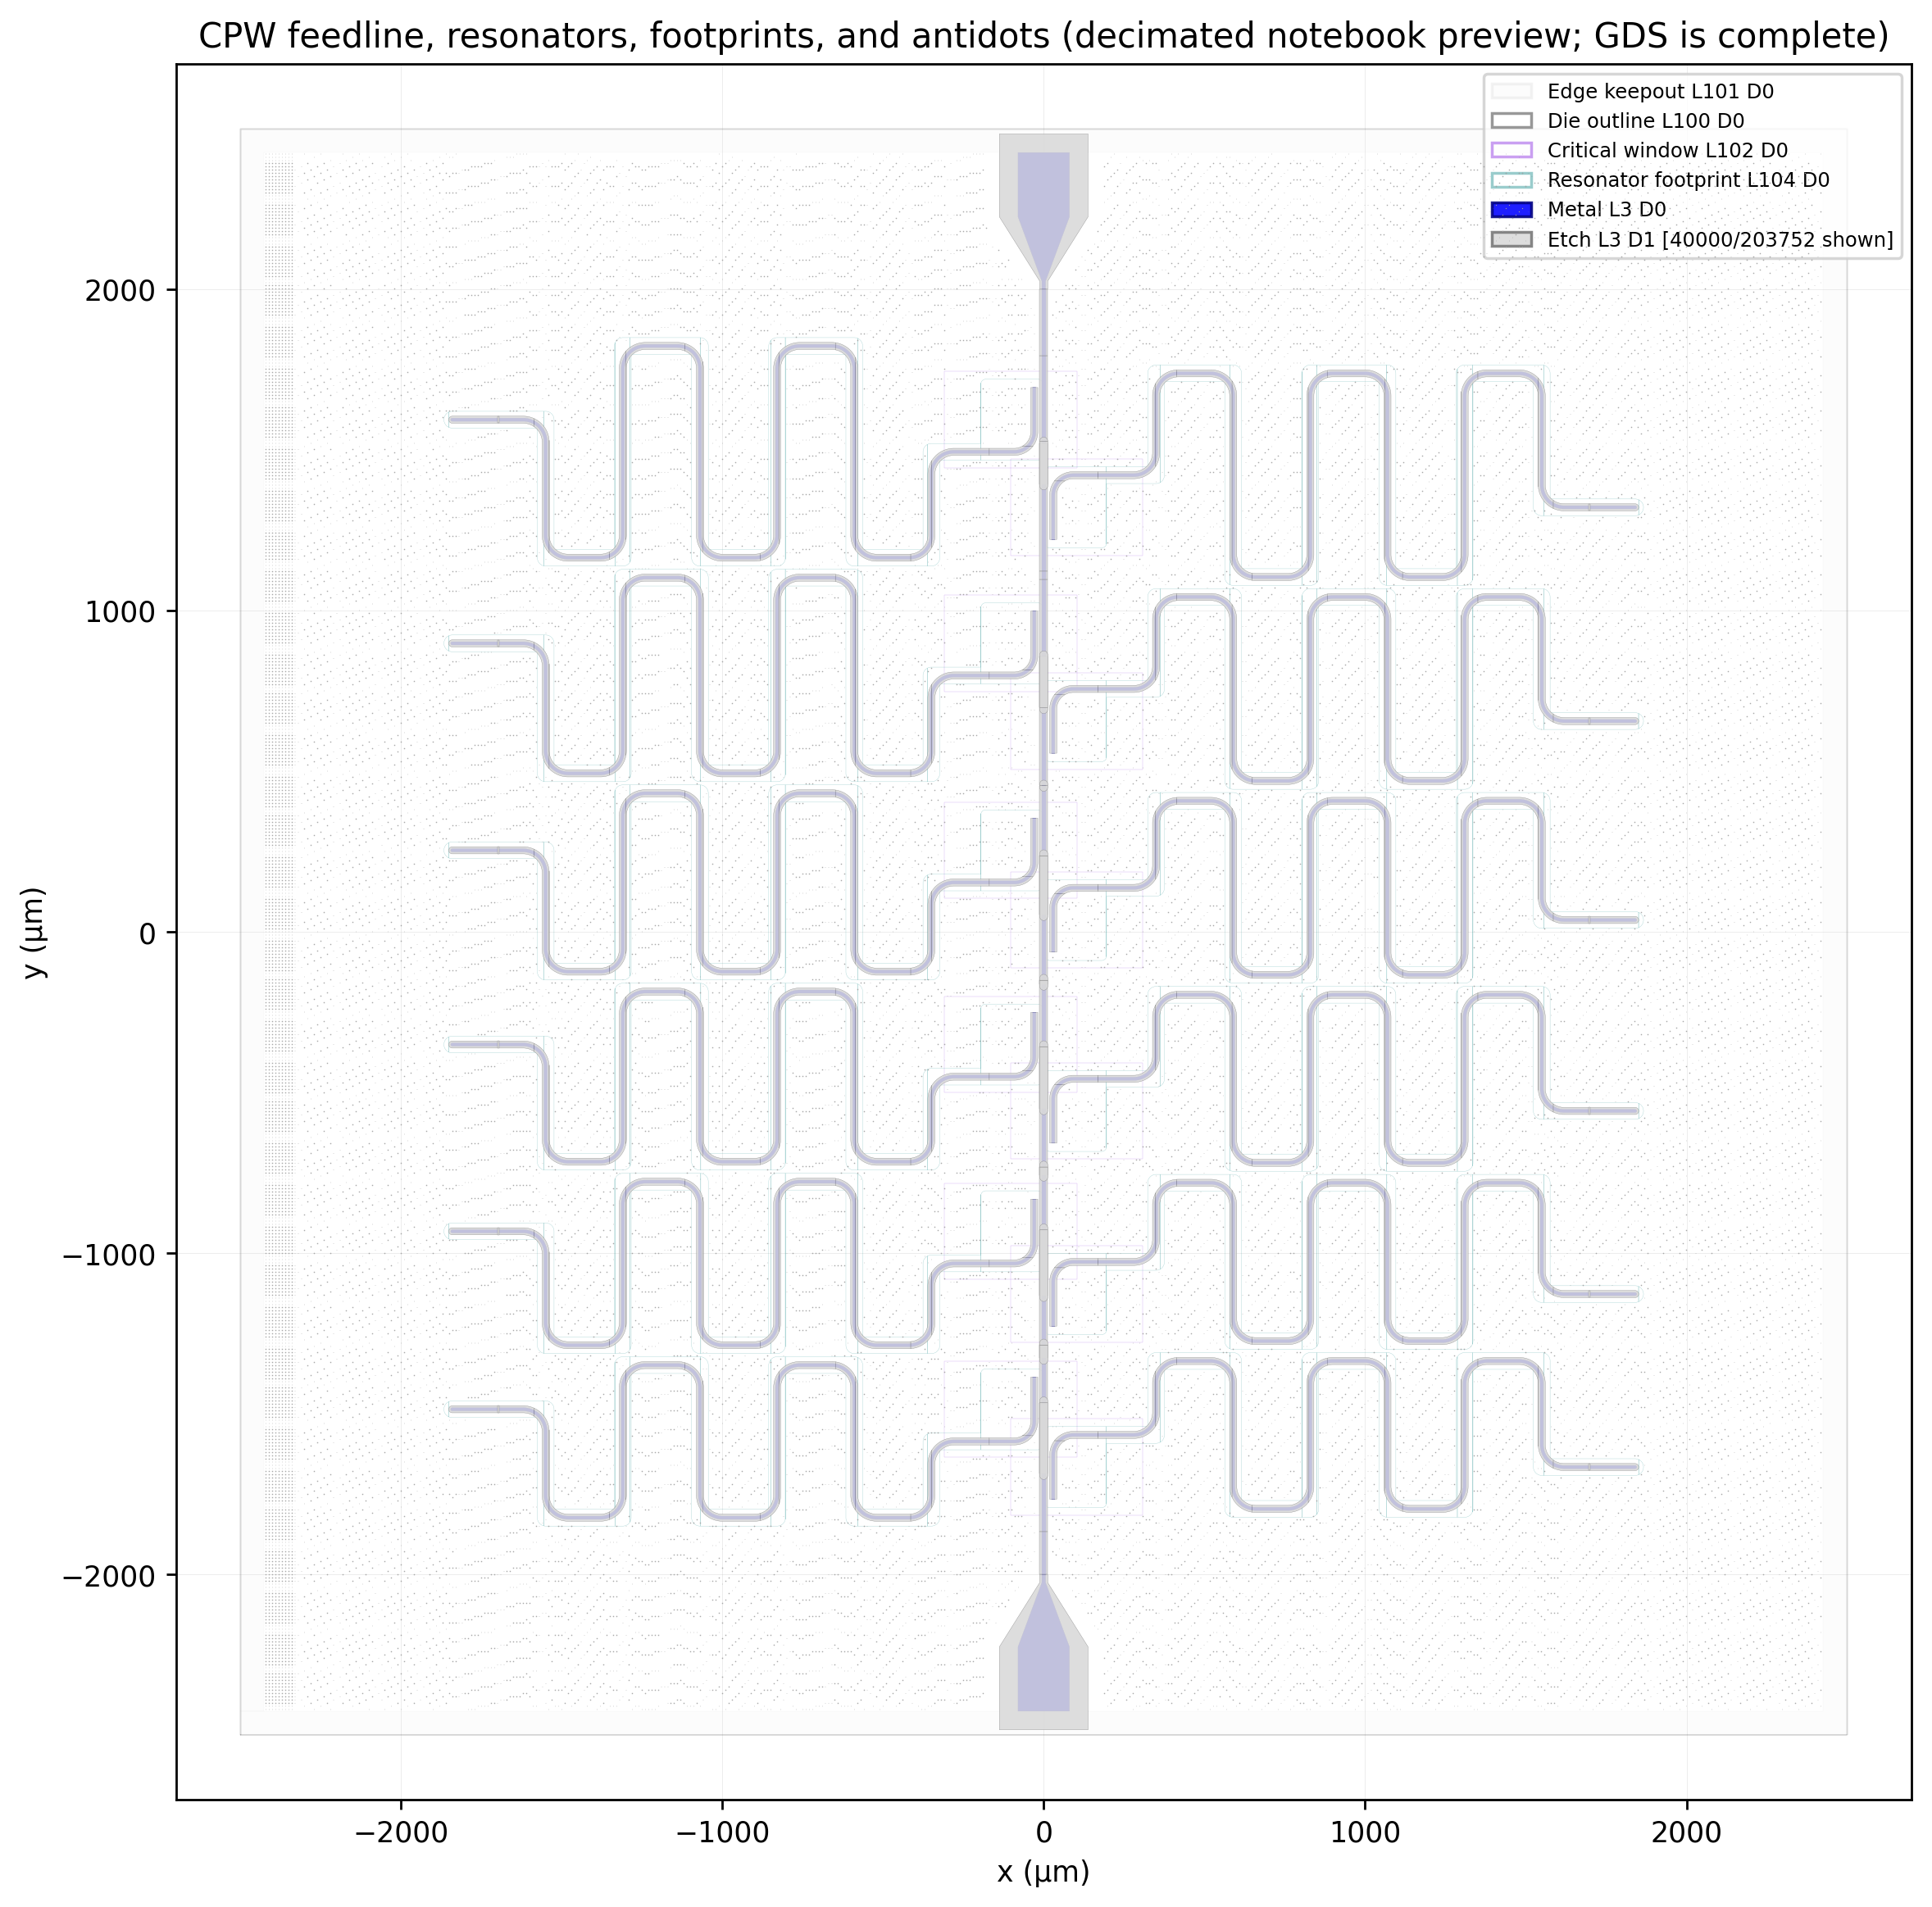

In [4]:
"""Build a fabrication-rule-aware Quantum Metal microwave layout.

The generator creates two pocketed wirebond launchers, an adaptive feedline,
frequency-selected hanger resonators, selectable quarter-wave or half-wave
electrical lengths, open or short terminations, resonator safety footprints,
and a pruned antidot lattice. NetworkX supplies rectilinear obstacle routing
and footprint-conflict management, while CuPy accelerates bulk integer-grid
cheesing, broad-phase spacing searches, and dense grid audits. A pre-export
rule deck audits impedance,
minimum dimensions, bend radius, die clearance, connectivity, footprint
clearance, and global-grid alignment before a flattened GDSII file is written
and re-imported for verification.
"""

import math
import time
import warnings
from collections import OrderedDict
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Any, Final

warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

try:
    import cupy as cp
except ImportError:
    cp = None
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import GeometryCollection
from shapely.geometry import LineString
from shapely.geometry import MultiLineString
from shapely.geometry import MultiPolygon
from shapely.geometry import Point
from shapely.geometry import Polygon
from shapely.affinity import translate as translate_shapely
from shapely.geometry import box

try:
    from shapely import contains_xy
except ImportError:
    contains_xy = None

from shapely.ops import nearest_points
from shapely.ops import transform
from shapely.ops import unary_union
from shapely.prepared import prep
from scipy.special import ellipk

from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/resonator_feedline_cheesing_quantum_metal.gds"
)

WRITE_GDS: Final[bool] = True
RENDER_GDS: Final[bool] = True
FAST_RENDER_PREVIEW: Final[bool] = True
RENDER_MAX_POLYGONS_PER_LAYER: Final[int] = 40_000
RENDER_PRESERVE_HEAD_POLYGONS: Final[int] = 5_000
FAIL_ON_DRC_ERROR: Final[bool] = True
SHOW_QGEOMETRY_SUMMARY: Final[bool] = True
SHOW_COMPONENT_PIN_AUDIT: Final[bool] = True
SHOW_FILLET_AUDIT: Final[bool] = True
SHOW_DRC_AUDIT: Final[bool] = True
SHOW_GDS_VERIFICATION: Final[bool] = True
SHOW_ROUTING_AUDIT: Final[bool] = True
SHOW_IMPEDANCE_AUDIT: Final[bool] = True
SHOW_SPACING_DIAGNOSTIC: Final[bool] = True
SHOW_GPU_AUDIT: Final[bool] = True

USE_CUPY: Final[bool] = True
GPU_AUTO_ADAPT: Final[bool] = True
GPU_ANTIDOT_PRUNING: Final[bool] = True
GPU_SPACING_BROAD_PHASE: Final[bool] = True
GPU_FOOTPRINT_BROAD_PHASE: Final[bool] = True
GPU_GRID_AUDIT: Final[bool] = True
GPU_MEMORY_FRACTION: Final[float] = 0.25
GPU_RELEASE_MEMORY_AFTER_STAGE: Final[bool] = False
GPU_MIN_ANTIDOT_CANDIDATES: Final[int] = 10_000
GPU_MIN_METAL_FEATURES: Final[int] = 32
GPU_MIN_FOOTPRINTS: Final[int] = 24
GPU_MIN_GRID_VERTICES: Final[int] = 100_000
GPU_MAX_PAIR_MATRIX_FEATURES: Final[int] = 4096
GPU_POINT_TILE_SIZE: Final[int] = 32_768
GPU_BBOX_TILE_SIZE: Final[int] = 64

AUTO_REPAIR_MIN_SPACE: Final[bool] = True
MAX_DRC_REPAIR_ITERATIONS: Final[int] = 6
MIN_SPACE_REPAIR_MARGIN_UM: Final[float] = 0.50
COUPLING_SPACE_REPAIR_STEP_UM: Final[float] = 0.25
MAX_COUPLING_SPACE_UM: Final[float] = 10.0

DESIRED_RESONATOR_COUNT: Final[int] = 12
STAGGER_RESONATORS: Final[bool] = True
STAGGER_START_SIDE: Final[str] = "left"
UNSTAGGERED_RESONATOR_SIDE: Final[str] = "left"

TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    5.820,
    5.965,
    6.116,
    6.353,
    6.472,
    6.568,
    6.655,
    6.704,
    6.812,
    6.940,
    7.085,
    7.210,
)

RESONATOR_TOPOLOGY: Final[str] = "quarter"
COUPLER_END_TERMINATION: Final[str] = "short"
FAR_END_TERMINATION: Final[str] = "open"
FREQUENCY_SOLVER_TOLERANCE_HZ: Final[float] = 1.0e3
FREQUENCY_SOLVER_MAX_ITERATIONS: Final[int] = 80
ELECTRICAL_END_CORRECTION_UM: Final[float] = 0.0

SPEED_OF_LIGHT_M_PER_S: Final[float] = 299_792_458.0
CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8
CPW_EFFECTIVE_PERMITTIVITY: Final[float] = (
    SPEED_OF_LIGHT_M_PER_S / CPW_PHASE_VELOCITY_M_PER_S
) ** 2
TARGET_CPW_IMPEDANCE_OHM: Final[float] = 50.0
AUTO_TUNE_FEEDLINE_GAP: Final[bool] = True
AUTO_TUNE_RESONATOR_GAP: Final[bool] = False
ACCOUNT_FOR_TEE_CENTERLINE_LENGTH: Final[bool] = True

RESONATOR_ARRAY_CENTER_Y_UM: Final[float] = 0.0
RESONATOR_ARRAY_SPAN_Y_UM: Final[float] = 3000.0
RESONATOR_OPEN_END_X_UM: Final[float] = 1700.0
RESONATOR_MEANDER_ASYMMETRY: Final[str] = "0um"
MAX_PLACEMENT_ITERATIONS: Final[int] = 8
PLACEMENT_NUDGE_PADDING_UM: Final[float] = 10.0
RESONATOR_SITE_Y_LIMIT_UM: Final[float] = 1775.0

ENABLE_ANTIDOTS: Final[bool] = True
ANTIDOT_PITCH_UM: Final[float] = 10.0
ANTIDOT_SIZE_UM: Final[float] = 2.0
ANTIDOT_OFFSET_X_UM: Final[float] = 9.0
ANTIDOT_OFFSET_Y_UM: Final[float] = 0.0
ANTIDOT_EXTENSION_Y_UM: Final[float] = 60.0
ANTIDOT_KEEPOUT_UM: Final[float] = 15.0
LAUNCHPAD_KEEPOUT_UM: Final[float] = 45.0

EXPORT_GUIDE_LAYERS: Final[bool] = True
EXPORT_RESONATOR_FOOTPRINTS: Final[bool] = True
EXPORT_COUPLING_WINDOWS: Final[bool] = True
COUPLING_WINDOW_MARGIN_UM: Final[float] = 50.0
DIE_OUTLINE_WIDTH_UM: Final[float] = 2.0

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 11.0

CHIP_SIZE_X: Final[str] = "5mm"
CHIP_SIZE_Y: Final[str] = "5mm"

COORD_SCALE_TO_UM: Final[float] = 1000.0
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9
GDS_MAX_POINTS: Final[int] = 199
GRID_UM: Final[float] = 0.005

METAL_LAYER: Final[int] = 3
JUNCTION_LAYER: Final[int] = 9
VIA_LAYER: Final[int] = 10
PASSIVATION_LAYER: Final[int] = 11
DIE_OUTLINE_LAYER: Final[int] = 100
EDGE_KEEPOUT_LAYER: Final[int] = 101
CRITICAL_WINDOW_LAYER: Final[int] = 102
DRC_KEEPOUT_LAYER: Final[int] = 103
RESONATOR_FOOTPRINT_LAYER: Final[int] = 104

SUBTRACT_DATATYPE: Final[int] = 1
NORMAL_DATATYPE: Final[int] = 0
GUIDE_DATATYPE: Final[int] = 0

PHYSICAL_LAYER_MAP: Final[dict[str, tuple[int, int]]] = {
    "ground_and_signal_metal": (METAL_LAYER, NORMAL_DATATYPE),
    "cpw_etch": (METAL_LAYER, SUBTRACT_DATATYPE),
    "junction_metal": (JUNCTION_LAYER, NORMAL_DATATYPE),
    "via": (VIA_LAYER, NORMAL_DATATYPE),
    "passivation": (PASSIVATION_LAYER, NORMAL_DATATYPE),
}

GUIDE_LAYER_MAP: Final[dict[str, tuple[int, int]]] = {
    "die_outline": (DIE_OUTLINE_LAYER, GUIDE_DATATYPE),
    "edge_keepout": (EDGE_KEEPOUT_LAYER, GUIDE_DATATYPE),
    "critical_window": (CRITICAL_WINDOW_LAYER, GUIDE_DATATYPE),
    "drc_keepout": (DRC_KEEPOUT_LAYER, GUIDE_DATATYPE),
    "resonator_footprint": (RESONATOR_FOOTPRINT_LAYER, GUIDE_DATATYPE),
}

DRAW_ORDER: Final[tuple[str, ...]] = (
    "passivation",
    "ground_and_signal_metal",
    "junction_metal",
    "via",
    "cpw_etch",
    "edge_keepout",
    "die_outline",
    "critical_window",
    "drc_keepout",
    "resonator_footprint",
)

FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7
FEEDLINE_TRACE_GAP_UM: Final[float] = 5.1
ROUTE_TRACE_WIDTH_UM: Final[float] = 10.0
ROUTE_TRACE_GAP_UM: Final[float] = 6.0

RESONATOR_FILLET_UM: Final[float] = 70.0
RESONATOR_MEANDER_SPACING_UM: Final[float] = 240.0
RESONATOR_LEAD_START_UM: Final[float] = 180.0
RESONATOR_LEAD_END_UM: Final[float] = 140.0

DEFAULT_COUPLING_LENGTH_UM: Final[float] = 200.0
DEFAULT_COUPLING_SPACE_UM: Final[float] = 6.0
DEFAULT_DOWN_LENGTH_UM: Final[float] = 140.0
DEFAULT_COUPLER_FILLET_UM: Final[float] = 60.0
DEFAULT_ROUTE_FILLET_UM: Final[float] = 70.0
MIN_FILLET_RADIUS_UM: Final[float] = 8.0
SAMPLES_PER_FILLET: Final[int] = 64
BUFFER_RESOLUTION: Final[int] = 64

LAUNCHPAD_CENTER_Y_UM: Final[float] = 2025.0
LAUNCHPAD_LEAD_LENGTH_UM: Final[float] = 25.0
LAUNCHPAD_WIDTH_UM: Final[float] = 160.0
LAUNCHPAD_HEIGHT_UM: Final[float] = 200.0
LAUNCHPAD_GAP_UM: Final[float] = 58.0
LAUNCHPAD_TAPER_HEIGHT_UM: Final[float] = 200.0

ROUTER_CLEARANCE_UM: Final[float] = 25.0
ROUTER_FILLET_UM: Final[float] = 70.0
FIXED_ROUTING_KEEPOUTS_UM: Final[
    tuple[tuple[float, float, float, float], ...]
] = ()

LAYER_STYLE_MAP: Final[dict[tuple[int, int], dict[str, Any]]] = {
    (METAL_LAYER, NORMAL_DATATYPE): {
        "facecolor": "#0000FF",
        "edgecolor": "#000080",
        "label": "Metal",
        "alpha": 0.88,
        "zorder": 20,
    },
    (METAL_LAYER, SUBTRACT_DATATYPE): {
        "facecolor": "#D9D9D9",
        "edgecolor": "#777777",
        "label": "Etch",
        "alpha": 0.88,
        "zorder": 30,
    },
    (DIE_OUTLINE_LAYER, GUIDE_DATATYPE): {
        "facecolor": "none",
        "edgecolor": "#444444",
        "label": "Die outline",
        "alpha": 0.55,
        "zorder": 2,
    },
    (EDGE_KEEPOUT_LAYER, GUIDE_DATATYPE): {
        "facecolor": "#EAEAEA",
        "edgecolor": "#AAAAAA",
        "label": "Edge keepout",
        "alpha": 0.14,
        "zorder": 1,
    },
    (CRITICAL_WINDOW_LAYER, GUIDE_DATATYPE): {
        "facecolor": "none",
        "edgecolor": "#8A2BE2",
        "label": "Critical window",
        "alpha": 0.45,
        "zorder": 5,
    },
    (DRC_KEEPOUT_LAYER, GUIDE_DATATYPE): {
        "facecolor": "none",
        "edgecolor": "#C04040",
        "label": "DRC keepout",
        "alpha": 0.55,
        "zorder": 6,
    },
    (RESONATOR_FOOTPRINT_LAYER, GUIDE_DATATYPE): {
        "facecolor": "none",
        "edgecolor": "#008080",
        "label": "Resonator footprint",
        "alpha": 0.40,
        "zorder": 7,
    },
}

DEFAULT_STYLE: Final[dict[str, Any]] = {
    "facecolor": "#A0A0A0",
    "edgecolor": "#505050",
    "label": "Other",
    "alpha": 0.55,
    "zorder": 10,
}

mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["figure.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# -----------------------------------------------------------------------------
# Data structures
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class DesignRules:
    """Fabrication and microwave rules expressed in micrometers and degrees."""

    min_width_um: float = 2.0
    min_space_um: float = 2.0
    critical_width_um: float = 0.10
    junction_enclosure_um: float = 0.20
    die_keepout_um: float = 75.0
    taper_min_angle_deg: float = 12.0
    res_min_space_um: float = 15.0
    cpw_min_gap_um: float = 2.0
    bend_radius_factor: float = 2.5
    impedance_tolerance_fraction: float = 0.05


RULES: Final[DesignRules] = DesignRules()


@dataclass(frozen=True)
class LayoutDimensions:
    """Resolved dimensions after impedance tuning and grid snapping."""

    feedline_width_um: float
    feedline_gap_um: float
    resonator_width_um: float
    resonator_gap_um: float
    resonator_fillet_um: float
    meander_spacing_um: float
    lead_start_um: float
    lead_end_um: float
    coupling_length_um: float
    coupling_space_um: float
    down_length_um: float
    coupler_fillet_um: float


@dataclass(frozen=True)
class ResonatorSite:
    """Resolved geometric placement for one resonator."""

    index: int
    name: str
    y_um: float
    side: str
    tee_orientation_deg: int
    open_end_x_um: float
    open_orientation_deg: int


@dataclass(frozen=True)
class ComponentHandles:
    """Created Quantum Metal component references."""

    wirebonds: list[Any]
    tees: list[Any]
    terminations: list[Any]
    resonators: list[Any]
    feedline_segments: list[Any]


@dataclass(frozen=True)
class ExportBundle:
    """In-memory GDS library and its audit tables before file writing."""

    library: gdstk.Library
    top_cell: gdstk.Cell
    polygons: list[gdstk.Polygon]
    export_table: pd.DataFrame
    fillet_table: pd.DataFrame
    metal_features: tuple[dict[str, Any], ...]


@dataclass(frozen=True)
class DrcFinding:
    """One pre-export rule-check result."""

    category: str
    rule: str
    status: str
    measured: str
    limit: str
    details: str


# -----------------------------------------------------------------------------
# CuPy acceleration helpers
# -----------------------------------------------------------------------------


GPU_STAGE_STATS: list[dict[str, Any]] = []
_GPU_READY_CACHE: bool | None = None


def configure_cupy() -> bool:
    """Initialize the optional CUDA backend and apply its memory limit."""
    global _GPU_READY_CACHE

    if _GPU_READY_CACHE is not None:
        return _GPU_READY_CACHE
    if USE_CUPY is False or cp is None:
        _GPU_READY_CACHE = False
        return False

    try:
        if int(cp.cuda.runtime.getDeviceCount()) <= 0:
            _GPU_READY_CACHE = False
            return False

        cp.get_default_memory_pool().set_limit(
            fraction=GPU_MEMORY_FRACTION
        )
        cp.zeros(1, dtype=cp.uint8)
        cp.cuda.Stream.null.synchronize()
    except Exception as exc:
        warnings.warn(
            f"CuPy is installed but CUDA initialization failed: {exc}",
            RuntimeWarning,
        )
        _GPU_READY_CACHE = False
        return False

    _GPU_READY_CACHE = True
    return True


def gpu_device_name() -> str:
    """Return a concise CUDA device name for notebook diagnostics."""
    if configure_cupy() is False:
        return "CPU fallback"

    try:
        device_id = int(cp.cuda.runtime.getDevice())
        properties = cp.cuda.runtime.getDeviceProperties(device_id)
        name = properties.get("name", "CUDA GPU")
        if isinstance(name, bytes):
            name = name.decode(errors="replace")
        return str(name)
    except Exception:
        return "CUDA GPU"


def gpu_should_use(
    enabled: bool,
    work_items: int,
    threshold: int,
) -> bool:
    """Return whether one workload should dispatch to CuPy."""
    if enabled is False or configure_cupy() is False:
        return False
    if GPU_AUTO_ADAPT:
        return int(work_items) >= int(threshold)
    return True


def record_acceleration_stage(
    stage: str,
    backend: str,
    work_items: int,
    output_items: int,
    elapsed_s: float,
    details: str,
) -> None:
    """Record one CPU or GPU stage for the acceleration audit table."""
    GPU_STAGE_STATS.append(
        {
            "stage": stage,
            "backend": backend,
            "work_items": int(work_items),
            "output_items": int(output_items),
            "elapsed_s": float(elapsed_s),
            "details": details,
        }
    )


def release_gpu_memory_if_requested() -> None:
    """Release cached CuPy memory after a bulk stage when requested."""
    if GPU_RELEASE_MEMORY_AFTER_STAGE is False or cp is None:
        return
    try:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    except Exception:
        pass


def acceleration_audit_table() -> pd.DataFrame:
    """Return accumulated hybrid CPU and GPU workload diagnostics."""
    return pd.DataFrame(GPU_STAGE_STATS)


def gpu_overlapping_aabb_pairs(
    bounds_um: np.ndarray,
) -> list[tuple[int, int]]:
    """Return GPU-pruned pairs whose axis-aligned bounds overlap."""
    bounds = np.asarray(bounds_um, dtype=np.float64)
    count = int(bounds.shape[0])
    if count < 2:
        return []

    started = time.perf_counter()
    bounds_gpu = cp.asarray(bounds)
    x_overlap = (
        (bounds_gpu[:, None, 0] <= bounds_gpu[None, :, 2])
        & (bounds_gpu[None, :, 0] <= bounds_gpu[:, None, 2])
    )
    y_overlap = (
        (bounds_gpu[:, None, 1] <= bounds_gpu[None, :, 3])
        & (bounds_gpu[None, :, 1] <= bounds_gpu[:, None, 3])
    )
    upper = cp.triu(cp.ones((count, count), dtype=cp.bool_), k=1)
    pair_indices = cp.argwhere(x_overlap & y_overlap & upper)
    cp.cuda.Stream.null.synchronize()
    pairs_cpu = cp.asnumpy(pair_indices)
    elapsed = time.perf_counter() - started
    pair_count = count * (count - 1) // 2
    record_acceleration_stage(
        stage="footprint AABB broad phase",
        backend="CuPy",
        work_items=pair_count,
        output_items=len(pairs_cpu),
        elapsed_s=elapsed,
        details="Exact Shapely intersections run only on AABB-overlap pairs.",
    )
    release_gpu_memory_if_requested()
    return [(int(first), int(second)) for first, second in pairs_cpu]


def gpu_ordered_aabb_distance_pairs(
    bounds_um: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Order all unique AABB pairs by their GPU-computed distance floor."""
    bounds = np.asarray(bounds_um, dtype=np.float64)
    count = int(bounds.shape[0])
    if count < 2:
        empty_i = np.empty(0, dtype=np.int64)
        empty_d = np.empty(0, dtype=np.float64)
        return empty_i, empty_i.copy(), empty_d

    started = time.perf_counter()
    b = cp.asarray(bounds)
    x_min = b[:, 0]
    y_min = b[:, 1]
    x_max = b[:, 2]
    y_max = b[:, 3]

    dx = cp.maximum(
        cp.maximum(
            x_min[None, :] - x_max[:, None],
            x_min[:, None] - x_max[None, :],
        ),
        0.0,
    )
    dy = cp.maximum(
        cp.maximum(
            y_min[None, :] - y_max[:, None],
            y_min[:, None] - y_max[None, :],
        ),
        0.0,
    )
    lower_bound = cp.hypot(dx, dy)
    upper = cp.triu(cp.ones((count, count), dtype=cp.bool_), k=1)
    lower_bound = cp.where(upper, lower_bound, cp.inf)

    pair_count = count * (count - 1) // 2
    flat_order = cp.argsort(lower_bound.ravel())[:pair_count]
    ordered_lower = lower_bound.ravel()[flat_order]
    first_indices = flat_order // count
    second_indices = flat_order % count
    cp.cuda.Stream.null.synchronize()

    first_cpu = cp.asnumpy(first_indices).astype(np.int64, copy=False)
    second_cpu = cp.asnumpy(second_indices).astype(np.int64, copy=False)
    lower_cpu = cp.asnumpy(ordered_lower).astype(np.float64, copy=False)
    elapsed = time.perf_counter() - started
    record_acceleration_stage(
        stage="metal-spacing AABB broad phase",
        backend="CuPy",
        work_items=pair_count,
        output_items=pair_count,
        elapsed_s=elapsed,
        details="Pairs are exact-checked by Shapely in lower-bound order.",
    )
    release_gpu_memory_if_requested()
    return first_cpu, second_cpu, lower_cpu


# -----------------------------------------------------------------------------
# Selection and numeric helpers
# -----------------------------------------------------------------------------


def snap_um(value_um: float) -> float:
    """Snap one scalar coordinate or dimension to the global fabrication grid."""
    return round(float(value_um) / GRID_UM) * GRID_UM


def snap_points_um(points: np.ndarray) -> np.ndarray:
    """Snap an array of x-y coordinates to the global fabrication grid."""
    values = np.asarray(points, dtype=np.float64)
    return np.round(values / GRID_UM) * GRID_UM


def um_string(value_um: float, digits: int = 6) -> str:
    """Format one snapped micrometer value for Quantum Metal options."""
    return f"{snap_um(value_um):.{digits}f}um"


def chip_dimension_um(value: str) -> float:
    """Parse the configured chip size string into micrometers."""
    cleaned = value.strip().lower()
    if cleaned.endswith("mm"):
        return float(cleaned[:-2]) * 1000.0
    if cleaned.endswith("um"):
        return float(cleaned[:-2])
    raise ValueError(f"Unsupported chip dimension {value!r}.")


def normalize_side(side: str) -> str:
    """Normalize a resonator-side control to left or right."""
    normalized = side.strip().lower()
    if normalized in {"left", "right"}:
        return normalized
    raise ValueError(
        f"Resonator side must be 'left' or 'right'; received {side!r}."
    )


def normalize_topology(topology: str) -> str:
    """Normalize a resonator electrical topology control."""
    normalized = topology.strip().lower().replace("-", "_")
    aliases = {
        "quarter": "quarter",
        "quarter_wave": "quarter",
        "lambda4": "quarter",
        "lambda_4": "quarter",
        "half": "half",
        "half_wave": "half",
        "lambda2": "half",
        "lambda_2": "half",
    }
    if normalized in aliases:
        return aliases[normalized]
    raise ValueError(
        "RESONATOR_TOPOLOGY must select quarter-wave or half-wave behavior."
    )


def normalize_termination(value: str) -> str:
    """Normalize an open-circuit or short-circuit termination control."""
    normalized = value.strip().lower()
    if normalized in {"open", "short"}:
        return normalized
    raise ValueError("Termination controls must be 'open' or 'short'.")


def selected_target_frequencies() -> tuple[float, ...]:
    """Select the leading target frequencies allowed by the count knob."""
    if DESIRED_RESONATOR_COUNT < 0:
        raise ValueError("DESIRED_RESONATOR_COUNT must be zero or greater.")

    available_count = len(TARGET_RESONATOR_FREQUENCIES_GHZ)
    selected_count = min(DESIRED_RESONATOR_COUNT, available_count)

    if DESIRED_RESONATOR_COUNT > available_count:
        warnings.warn(
            "Requested resonator count exceeds the target-frequency list; "
            f"building the {available_count} frequency-backed resonators available.",
            RuntimeWarning,
        )

    return TARGET_RESONATOR_FREQUENCIES_GHZ[:selected_count]


def cpw_impedance_ohm(
    width_um: float,
    gap_um: float,
    epsilon_eff: float = CPW_EFFECTIVE_PERMITTIVITY,
) -> float:
    """Return the quasi-static CPW characteristic impedance in ohms.

    The conformal-mapping expression uses the complete elliptic integrals
    K(k) and K(k') with k = w / (w + 2g). The supplied effective
    permittivity captures the substrate and field-participation model chosen
    for this reduced-order layout audit.
    """
    width = float(width_um)
    gap = float(gap_um)
    if width <= 0.0 or gap <= 0.0 or epsilon_eff <= 0.0:
        raise ValueError("CPW width, gap, and effective permittivity must be positive.")

    modulus = width / (width + 2.0 * gap)
    parameter = modulus * modulus
    complementary_parameter = 1.0 - parameter
    return float(
        30.0
        * math.pi
        / math.sqrt(epsilon_eff)
        * ellipk(complementary_parameter)
        / ellipk(parameter)
    )


def solve_cpw_gap_um(
    width_um: float,
    target_impedance_ohm: float,
    epsilon_eff: float = CPW_EFFECTIVE_PERMITTIVITY,
) -> float:
    """Solve and grid-snap the CPW gap that matches a target impedance."""
    lower = max(RULES.cpw_min_gap_um, GRID_UM)
    upper = max(20.0 * width_um, lower + GRID_UM)

    z_lower = cpw_impedance_ohm(width_um, lower, epsilon_eff)
    z_upper = cpw_impedance_ohm(width_um, upper, epsilon_eff)
    if target_impedance_ohm < z_lower or target_impedance_ohm > z_upper:
        raise ValueError(
            "Target CPW impedance lies outside the numerical gap-search bracket."
        )

    for _ in range(100):
        midpoint = 0.5 * (lower + upper)
        z_midpoint = cpw_impedance_ohm(width_um, midpoint, epsilon_eff)
        if z_midpoint < target_impedance_ohm:
            lower = midpoint
        else:
            upper = midpoint

    solved = snap_um(0.5 * (lower + upper))
    if solved < RULES.cpw_min_gap_um:
        raise ValueError("Solved CPW gap violates the minimum CPW gap rule.")
    return solved


def required_bend_radius_um(width_um: float, gap_um: float) -> float:
    """Return the bend-radius floor derived from the full CPW envelope."""
    envelope_um = width_um + 2.0 * gap_um
    return snap_um(RULES.bend_radius_factor * envelope_um)


def resolve_layout_dimensions(
    coupling_space_override_um: float | None = None,
) -> LayoutDimensions:
    """Resolve all microwave dimensions before component creation."""
    feedline_width = snap_um(FEEDLINE_TRACE_WIDTH_UM)
    resonator_width = snap_um(ROUTE_TRACE_WIDTH_UM)

    if AUTO_TUNE_FEEDLINE_GAP:
        feedline_gap = solve_cpw_gap_um(
            feedline_width,
            TARGET_CPW_IMPEDANCE_OHM,
        )
    else:
        feedline_gap = snap_um(FEEDLINE_TRACE_GAP_UM)

    if AUTO_TUNE_RESONATOR_GAP:
        resonator_gap = solve_cpw_gap_um(
            resonator_width,
            TARGET_CPW_IMPEDANCE_OHM,
        )
    else:
        resonator_gap = snap_um(ROUTE_TRACE_GAP_UM)

    resonator_radius_floor = required_bend_radius_um(
        resonator_width,
        resonator_gap,
    )
    feedline_radius_floor = required_bend_radius_um(
        feedline_width,
        feedline_gap,
    )

    return LayoutDimensions(
        feedline_width_um=feedline_width,
        feedline_gap_um=feedline_gap,
        resonator_width_um=resonator_width,
        resonator_gap_um=resonator_gap,
        resonator_fillet_um=max(
            snap_um(RESONATOR_FILLET_UM),
            resonator_radius_floor,
        ),
        meander_spacing_um=snap_um(RESONATOR_MEANDER_SPACING_UM),
        lead_start_um=snap_um(RESONATOR_LEAD_START_UM),
        lead_end_um=snap_um(RESONATOR_LEAD_END_UM),
        coupling_length_um=snap_um(DEFAULT_COUPLING_LENGTH_UM),
        coupling_space_um=snap_um(
            DEFAULT_COUPLING_SPACE_UM
            if coupling_space_override_um is None
            else coupling_space_override_um
        ),
        down_length_um=snap_um(DEFAULT_DOWN_LENGTH_UM),
        coupler_fillet_um=max(
            snap_um(DEFAULT_COUPLER_FILLET_UM),
            resonator_radius_floor,
            feedline_radius_floor,
        ),
    )


def resonator_side_for_index(index: int) -> str:
    """Return the physical feedline side for one resonator index."""
    if STAGGER_RESONATORS:
        first_side = normalize_side(STAGGER_START_SIDE)
        if index % 2 == 0:
            return first_side
        return "right" if first_side == "left" else "left"
    return normalize_side(UNSTAGGERED_RESONATOR_SIDE)


def resonator_y_positions_um(count: int) -> np.ndarray:
    """Return centered resonator y positions spanning the configured array."""
    if count <= 0:
        return np.empty(0, dtype=np.float64)
    if count == 1:
        return np.asarray(
            [snap_um(RESONATOR_ARRAY_CENTER_Y_UM)],
            dtype=np.float64,
        )

    half_span = 0.5 * RESONATOR_ARRAY_SPAN_Y_UM
    upper = RESONATOR_ARRAY_CENTER_Y_UM + half_span
    lower = RESONATOR_ARRAY_CENTER_Y_UM - half_span
    raw = np.linspace(upper, lower, count, dtype=np.float64)
    return snap_points_um(raw[:, None])[:, 0]


def build_sites_from_y(y_positions_um: np.ndarray) -> tuple[ResonatorSite, ...]:
    """Build resonator sites from an ordered set of y coordinates."""
    sites: list[ResonatorSite] = []
    for index, y_um in enumerate(np.asarray(y_positions_um, dtype=float)):
        side = resonator_side_for_index(index)
        side_sign = -1.0 if side == "left" else 1.0
        tee_orientation = -90 if side == "left" else 90
        open_orientation = 0 if side == "left" else 180
        sites.append(
            ResonatorSite(
                index=index,
                name=f"R{index + 1:02d}",
                y_um=snap_um(float(y_um)),
                side=side,
                tee_orientation_deg=tee_orientation,
                open_end_x_um=snap_um(
                    side_sign * abs(RESONATOR_OPEN_END_X_UM)
                ),
                open_orientation_deg=open_orientation,
            )
        )
    return tuple(sites)


def build_resonator_sites(count: int) -> tuple[ResonatorSite, ...]:
    """Build deterministic initial resonator placements from the controls."""
    return build_sites_from_y(resonator_y_positions_um(count))


def resonance_frequency_ghz(
    electrical_length_um: float,
    topology: str,
) -> float:
    """Evaluate the reduced-order resonance model for one centerline length."""
    normalized = normalize_topology(topology)
    divisor = 4.0 if normalized == "quarter" else 2.0
    corrected_length_m = (
        electrical_length_um + ELECTRICAL_END_CORRECTION_UM
    ) * 1.0e-6
    if corrected_length_m <= 0.0:
        raise ValueError("Electrical resonator length must be positive.")
    frequency_hz = CPW_PHASE_VELOCITY_M_PER_S / (
        divisor * corrected_length_m
    )
    return frequency_hz * 1.0e-9


def solve_resonator_length_um(
    target_frequency_ghz: float,
    topology: str,
) -> tuple[float, int, float]:
    """Iteratively solve centerline length for one target resonance."""
    normalized = normalize_topology(topology)
    divisor = 4.0 if normalized == "quarter" else 2.0
    target_hz = float(target_frequency_ghz) * 1.0e9
    analytic_um = (
        CPW_PHASE_VELOCITY_M_PER_S / (divisor * target_hz) * 1.0e6
        - ELECTRICAL_END_CORRECTION_UM
    )
    lower = max(0.25 * analytic_um, GRID_UM)
    upper = 2.0 * analytic_um
    solved = analytic_um
    iterations = 0

    for iterations in range(1, FREQUENCY_SOLVER_MAX_ITERATIONS + 1):
        solved = 0.5 * (lower + upper)
        frequency_hz = resonance_frequency_ghz(solved, normalized) * 1.0e9
        error_hz = frequency_hz - target_hz
        if abs(error_hz) <= FREQUENCY_SOLVER_TOLERANCE_HZ:
            break
        if error_hz > 0.0:
            lower = solved
        else:
            upper = solved

    solved = snap_um(solved)
    final_error_hz = (
        resonance_frequency_ghz(solved, normalized) * 1.0e9 - target_hz
    )
    return solved, iterations, final_error_hz


def qmetal_value_um(design: Any, value: Any) -> float:
    """Parse a Quantum Metal value and return micrometers."""
    return float(design.parse_value(value)) * COORD_SCALE_TO_UM


def build_resonator_length_plan(
    design: Any,
    frequencies_ghz: tuple[float, ...],
    dimensions: LayoutDimensions,
) -> pd.DataFrame:
    """Build frequency-solved electrical lengths and RouteMeander lengths."""
    fixed_tee_length_um = 0.0
    if ACCOUNT_FOR_TEE_CENTERLINE_LENGTH:
        fixed_tee_length_um = (
            dimensions.coupling_length_um + dimensions.down_length_um
        )

    records: list[dict[str, Any]] = []
    for frequency_ghz in frequencies_ghz:
        electrical_length_um, iterations, error_hz = solve_resonator_length_um(
            target_frequency_ghz=frequency_ghz,
            topology=RESONATOR_TOPOLOGY,
        )
        route_length_um = snap_um(electrical_length_um - fixed_tee_length_um)
        if route_length_um <= 0.0:
            raise ValueError(
                "A target frequency produced a nonpositive meander route length."
            )
        records.append(
            {
                "target_frequency_ghz": frequency_ghz,
                "topology": normalize_topology(RESONATOR_TOPOLOGY),
                "solved_electrical_length_um": electrical_length_um,
                "tee_centerline_length_um": fixed_tee_length_um,
                "route_length_um": route_length_um,
                "route_total_length": um_string(route_length_um),
                "solver_iterations": iterations,
                "frequency_error_hz_after_grid_snap": error_hz,
            }
        )
    return pd.DataFrame(records)


# -----------------------------------------------------------------------------
# Quantum Metal build
# -----------------------------------------------------------------------------


def create_design(dimensions: LayoutDimensions) -> Any:
    """Create a renderer-free planar design with grid-resolved CPW variables."""
    design = designs.DesignPlanar(
        overwrite_enabled=True,
        enable_renderers=False,
    )

    try:
        design.chips.main.size.size_x = CHIP_SIZE_X
        design.chips.main.size.size_y = CHIP_SIZE_Y
    except Exception:
        design._chips["main"]["size"]["size_x"] = CHIP_SIZE_X
        design._chips["main"]["size"]["size_y"] = CHIP_SIZE_Y

    design.variables["cpw_width"] = um_string(dimensions.resonator_width_um)
    design.variables["cpw_gap"] = um_string(dimensions.resonator_gap_um)
    return design


def select_component_pin(
    component: Any,
    preferred: str,
    fallbacks: tuple[str, ...],
) -> str:
    """Return a valid pin name from a component."""
    pin_names = list(component.pins.keys())
    if preferred in pin_names:
        return preferred
    for candidate in fallbacks:
        if candidate in pin_names:
            return candidate
    raise ValueError(
        f"Could not find a usable pin on {component.name}. "
        f"Available pins are {pin_names}."
    )


def pin_middle_um(component: Any, pin_name: str) -> np.ndarray:
    """Return one Quantum Metal pin center in micrometers."""
    middle = np.asarray(component.pins[pin_name]["middle"], dtype=float)
    return snap_points_um(middle * COORD_SCALE_TO_UM)


def create_wirebond(
    design: Any,
    dimensions: LayoutDimensions,
    name: str,
    pos_y_um: float,
    orientation: str,
) -> Any:
    """Create a feedline wirebond launch pad with a pocketed transition."""
    return LaunchpadWirebond(
        design,
        name,
        options=Dict(
            pos_x="0um",
            pos_y=um_string(pos_y_um),
            orientation=orientation,
            trace_width=um_string(dimensions.feedline_width_um),
            trace_gap=um_string(dimensions.feedline_gap_um),
            lead_length=um_string(LAUNCHPAD_LEAD_LENGTH_UM),
            pad_width=um_string(LAUNCHPAD_WIDTH_UM),
            pad_height=um_string(LAUNCHPAD_HEIGHT_UM),
            pad_gap=um_string(LAUNCHPAD_GAP_UM),
            taper_height=um_string(LAUNCHPAD_TAPER_HEIGHT_UM),
            layer=str(METAL_LAYER),
        ),
    )


def create_coupled_line_tee(
    design: Any,
    dimensions: LayoutDimensions,
    site: ResonatorSite,
) -> Any:
    """Create one feedline-side hanger coupler with geometric coupling controls."""
    coupler_open = normalize_termination(COUPLER_END_TERMINATION) == "open"
    return CoupledLineTee(
        design,
        f"clt_{site.name}",
        options=Dict(
            pos_x="0um",
            pos_y=um_string(site.y_um),
            orientation=str(site.tee_orientation_deg),
            prime_width=um_string(dimensions.feedline_width_um),
            prime_gap=um_string(dimensions.feedline_gap_um),
            second_width=um_string(dimensions.resonator_width_um),
            second_gap=um_string(dimensions.resonator_gap_um),
            coupling_space=um_string(dimensions.coupling_space_um),
            coupling_length=um_string(dimensions.coupling_length_um),
            down_length=um_string(dimensions.down_length_um),
            fillet=um_string(dimensions.coupler_fillet_um),
            mirror=False,
            open_termination=coupler_open,
            layer=str(METAL_LAYER),
        ),
    )


def select_tee_output_pin(tee: Any) -> str:
    """Return the hanger-output pin on a coupled-line tee."""
    pin_names = tuple(tee.pins.keys())
    for candidate in ("second_end", "second", "out"):
        if candidate in pin_names:
            return candidate
    for pin_name in pin_names:
        if "second" in pin_name:
            return pin_name
    raise ValueError(
        f"Could not find a tee output pin on {tee.name}. "
        f"Available pins are {list(pin_names)}."
    )


def tee_vertical_pin_names(tee: Any) -> tuple[str, str]:
    """Return the geometrically upper and lower feedline pins of a tee."""
    prime_names = [
        name for name in ("prime_start", "prime_end") if name in tee.pins
    ]
    if len(prime_names) != 2:
        raise ValueError(
            f"Expected two prime pins on {tee.name}; received {prime_names}."
        )
    ordered = sorted(
        prime_names,
        key=lambda name: float(tee.pins[name]["middle"][1]),
        reverse=True,
    )
    return ordered[0], ordered[1]


def routing_obstacle_polygons_um() -> tuple[Polygon, ...]:
    """Convert fixed axis-aligned routing keepouts into Shapely polygons."""
    polygons: list[Polygon] = []
    for bounds in FIXED_ROUTING_KEEPOUTS_UM:
        if len(bounds) != 4:
            raise ValueError("Each routing keepout requires xmin, ymin, xmax, ymax.")
        x_min, y_min, x_max, y_max = map(snap_um, bounds)
        if x_max <= x_min or y_max <= y_min:
            raise ValueError(f"Invalid routing keepout bounds {bounds!r}.")
        polygons.append(box(x_min, y_min, x_max, y_max))
    return tuple(polygons)


def segment_clear_of_obstacles(
    start_um: tuple[float, float],
    end_um: tuple[float, float],
    obstacles: tuple[Polygon, ...],
) -> bool:
    """Return whether one rectilinear segment clears all routing obstacles."""
    segment = LineString([start_um, end_um])
    for obstacle in obstacles:
        if segment.intersects(obstacle):
            return False
    return True


def simplify_rectilinear_path(
    points_um: list[tuple[float, float]],
) -> list[tuple[float, float]]:
    """Remove redundant collinear waypoints from a Manhattan path."""
    if len(points_um) <= 2:
        return points_um
    simplified = [points_um[0]]
    for index in range(1, len(points_um) - 1):
        previous = np.asarray(simplified[-1], dtype=float)
        current = np.asarray(points_um[index], dtype=float)
        following = np.asarray(points_um[index + 1], dtype=float)
        first = current - previous
        second = following - current
        cross_value = first[0] * second[1] - first[1] * second[0]
        if abs(cross_value) > 1.0e-9:
            simplified.append(tuple(current))
    simplified.append(points_um[-1])
    return simplified


def networkx_manhattan_path_um(
    start_um: np.ndarray,
    end_um: np.ndarray,
    obstacles: tuple[Polygon, ...],
) -> list[tuple[float, float]]:
    """Find a shortest legal Manhattan path with a NetworkX visibility graph."""
    start = tuple(snap_points_um(np.asarray(start_um)[None, :])[0])
    end = tuple(snap_points_um(np.asarray(end_um)[None, :])[0])
    expanded = tuple(
        obstacle.buffer(
            ROUTER_CLEARANCE_UM,
            cap_style=3,
            join_style=2,
        )
        for obstacle in obstacles
    )

    x_values = {start[0], end[0]}
    y_values = {start[1], end[1]}
    offset = max(GRID_UM, snap_um(ROUTER_CLEARANCE_UM * 0.05))
    for obstacle in expanded:
        x_min, y_min, x_max, y_max = obstacle.bounds
        x_values.update({snap_um(x_min - offset), snap_um(x_max + offset)})
        y_values.update({snap_um(y_min - offset), snap_um(y_max + offset)})

    candidates: list[tuple[float, float]] = []
    for x_coord in sorted(x_values):
        for y_coord in sorted(y_values):
            point = Point(x_coord, y_coord)
            blocked = any(
                obstacle.contains(point) or obstacle.touches(point)
                for obstacle in expanded
            )
            if blocked is False:
                candidates.append((x_coord, y_coord))

    for endpoint in (start, end):
        if endpoint not in candidates:
            candidates.append(endpoint)

    graph = nx.Graph()
    graph.add_nodes_from(candidates)

    by_x: dict[float, list[tuple[float, float]]] = {}
    by_y: dict[float, list[tuple[float, float]]] = {}
    for point in candidates:
        by_x.setdefault(point[0], []).append(point)
        by_y.setdefault(point[1], []).append(point)

    for points in by_x.values():
        ordered = sorted(points, key=lambda point: point[1])
        for first, second in zip(ordered[:-1], ordered[1:]):
            if segment_clear_of_obstacles(first, second, expanded):
                graph.add_edge(
                    first,
                    second,
                    weight=abs(second[1] - first[1]),
                )

    for points in by_y.values():
        ordered = sorted(points, key=lambda point: point[0])
        for first, second in zip(ordered[:-1], ordered[1:]):
            if segment_clear_of_obstacles(first, second, expanded):
                graph.add_edge(
                    first,
                    second,
                    weight=abs(second[0] - first[0]),
                )

    def heuristic(first: tuple[float, float], second: tuple[float, float]) -> float:
        return abs(first[0] - second[0]) + abs(first[1] - second[1])

    try:
        route = nx.astar_path(
            graph,
            start,
            end,
            heuristic=heuristic,
            weight="weight",
        )
    except nx.NetworkXNoPath as exc:
        raise RuntimeError(
            f"No legal Manhattan route exists between {start} and {end}."
        ) from exc

    return simplify_rectilinear_path(route)


def create_feedline_route(
    design: Any,
    dimensions: LayoutDimensions,
    name: str,
    start_component: Any,
    start_pin: str,
    end_component: Any,
    end_pin: str,
) -> Any:
    """Create one feedline section using NetworkX obstacle-aware routing."""
    start_um = pin_middle_um(start_component, start_pin)
    end_um = pin_middle_um(end_component, end_pin)
    path_um = networkx_manhattan_path_um(
        start_um=start_um,
        end_um=end_um,
        obstacles=routing_obstacle_polygons_um(),
    )

    base_options = Dict(
        pin_inputs=Dict(
            start_pin=Dict(component=start_component.name, pin=start_pin),
            end_pin=Dict(component=end_component.name, pin=end_pin),
        ),
        trace_width=um_string(dimensions.feedline_width_um),
        trace_gap=um_string(dimensions.feedline_gap_um),
        layer=str(METAL_LAYER),
    )

    if len(path_um) <= 2:
        return RouteStraight(design, name, options=base_options)

    anchors = OrderedDict(
        (
            index,
            np.asarray(point_um, dtype=float) / COORD_SCALE_TO_UM,
        )
        for index, point_um in enumerate(path_um[1:-1], start=1)
    )
    base_options["anchors"] = anchors
    base_options["fillet"] = um_string(
        max(
            ROUTER_FILLET_UM,
            required_bend_radius_um(
                dimensions.feedline_width_um,
                dimensions.feedline_gap_um,
            ),
        )
    )
    base_options["advanced"] = Dict(avoid_collision="false")
    return RouteAnchors(design, name, options=base_options)


def create_segmented_feedline(
    design: Any,
    dimensions: LayoutDimensions,
    top_launch: Any,
    bottom_launch: Any,
    tees: list[Any],
) -> list[Any]:
    """Connect launchers and tee primary segments into one adaptive feedline."""
    top_launch_pin = select_component_pin(top_launch, "tie", ("in", "out"))
    bottom_launch_pin = select_component_pin(bottom_launch, "tie", ("in", "out"))

    if len(tees) == 0:
        return [
            create_feedline_route(
                design=design,
                dimensions=dimensions,
                name="feedline_01",
                start_component=top_launch,
                start_pin=top_launch_pin,
                end_component=bottom_launch,
                end_pin=bottom_launch_pin,
            )
        ]

    sorted_tees = sorted(
        tees,
        key=lambda tee: max(
            float(tee.pins[pin_name]["middle"][1])
            for pin_name in ("prime_start", "prime_end")
        ),
        reverse=True,
    )

    feedline_segments: list[Any] = []
    route_index = 1
    first_top_pin, _ = tee_vertical_pin_names(sorted_tees[0])
    feedline_segments.append(
        create_feedline_route(
            design=design,
            dimensions=dimensions,
            name=f"feedline_{route_index:02d}",
            start_component=top_launch,
            start_pin=top_launch_pin,
            end_component=sorted_tees[0],
            end_pin=first_top_pin,
        )
    )
    route_index += 1

    for upper_tee, lower_tee in zip(sorted_tees[:-1], sorted_tees[1:]):
        _, upper_bottom_pin = tee_vertical_pin_names(upper_tee)
        lower_top_pin, _ = tee_vertical_pin_names(lower_tee)
        feedline_segments.append(
            create_feedline_route(
                design=design,
                dimensions=dimensions,
                name=f"feedline_{route_index:02d}",
                start_component=upper_tee,
                start_pin=upper_bottom_pin,
                end_component=lower_tee,
                end_pin=lower_top_pin,
            )
        )
        route_index += 1

    _, final_bottom_pin = tee_vertical_pin_names(sorted_tees[-1])
    feedline_segments.append(
        create_feedline_route(
            design=design,
            dimensions=dimensions,
            name=f"feedline_{route_index:02d}",
            start_component=sorted_tees[-1],
            start_pin=final_bottom_pin,
            end_component=bottom_launch,
            end_pin=bottom_launch_pin,
        )
    )
    return feedline_segments


def create_termination(
    design: Any,
    dimensions: LayoutDimensions,
    site: ResonatorSite,
) -> Any:
    """Create the selected open-circuit or slot-closure resonator termination."""
    termination = normalize_termination(FAR_END_TERMINATION)
    common = Dict(
        pos_x=um_string(site.open_end_x_um),
        pos_y=um_string(site.y_um),
        orientation=str(site.open_orientation_deg),
        width=um_string(dimensions.resonator_width_um),
        layer=str(METAL_LAYER),
    )
    if termination == "open":
        common["gap"] = um_string(dimensions.resonator_gap_um)
        common["termination_gap"] = um_string(dimensions.resonator_gap_um)
        return OpenToGround(design, f"open_{site.name}", options=common)
    return ShortToGround(design, f"short_{site.name}", options=common)


def select_termination_pin(termination: Any) -> str:
    """Return the active pin name for an open or short termination."""
    preferred = (
        "open"
        if normalize_termination(FAR_END_TERMINATION) == "open"
        else "short"
    )
    return select_component_pin(
        termination,
        preferred,
        tuple(termination.pins.keys()),
    )


def create_resonator(
    design: Any,
    dimensions: LayoutDimensions,
    site: ResonatorSite,
    tee: Any,
    termination: Any,
    total_length: str,
) -> Any:
    """Create one frequency-solved meander between a tee and termination."""
    tee_pin = select_tee_output_pin(tee)
    termination_pin = select_termination_pin(termination)
    return RouteMeander(
        design,
        f"rr_{site.name}",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=tee.name, pin=tee_pin),
                end_pin=Dict(
                    component=termination.name,
                    pin=termination_pin,
                ),
            ),
            lead=Dict(
                start_straight=um_string(dimensions.lead_start_um),
                end_straight=um_string(dimensions.lead_end_um),
            ),
            fillet=um_string(dimensions.resonator_fillet_um),
            total_length=total_length,
            trace_width=um_string(dimensions.resonator_width_um),
            trace_gap=um_string(dimensions.resonator_gap_um),
            meander=Dict(
                spacing=um_string(dimensions.meander_spacing_um),
                asymmetry=RESONATOR_MEANDER_ASYMMETRY,
            ),
            prevent_short_edges="true",
            snap="true",
            layer=str(METAL_LAYER),
        ),
    )


def build_chip_once(
    frequencies: tuple[float, ...],
    sites: tuple[ResonatorSite, ...],
    dimensions: LayoutDimensions,
) -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build one candidate chip placement before footprint collision checks."""
    design = create_design(dimensions)
    length_plan = build_resonator_length_plan(
        design,
        frequencies,
        dimensions,
    )

    top_launch = create_wirebond(
        design=design,
        dimensions=dimensions,
        name="wb_top",
        pos_y_um=LAUNCHPAD_CENTER_Y_UM,
        orientation="-90",
    )
    bottom_launch = create_wirebond(
        design=design,
        dimensions=dimensions,
        name="wb_bottom",
        pos_y_um=-LAUNCHPAD_CENTER_Y_UM,
        orientation="90",
    )

    tees = [
        create_coupled_line_tee(design, dimensions, site)
        for site in sites
    ]
    feedline_segments = create_segmented_feedline(
        design=design,
        dimensions=dimensions,
        top_launch=top_launch,
        bottom_launch=bottom_launch,
        tees=tees,
    )

    terminations: list[Any] = []
    resonators: list[Any] = []
    summary_records: list[dict[str, Any]] = []

    for site, tee, length_row in zip(
        sites,
        tees,
        length_plan.to_dict(orient="records"),
    ):
        termination = create_termination(design, dimensions, site)
        resonator = create_resonator(
            design=design,
            dimensions=dimensions,
            site=site,
            tee=tee,
            termination=termination,
            total_length=str(length_row["route_total_length"]),
        )
        terminations.append(termination)
        resonators.append(resonator)
        summary_records.append(
            {
                "resonator": site.name,
                "side": site.side,
                "y_um": site.y_um,
                "target_frequency_ghz": length_row["target_frequency_ghz"],
                "topology": length_row["topology"],
                "near_end_termination": normalize_termination(
                    COUPLER_END_TERMINATION
                ),
                "far_end_termination": normalize_termination(
                    FAR_END_TERMINATION
                ),
                "solved_electrical_length_um": length_row[
                    "solved_electrical_length_um"
                ],
                "tee_centerline_length_um": length_row[
                    "tee_centerline_length_um"
                ],
                "route_total_length": length_row["route_total_length"],
                "frequency_error_hz_after_grid_snap": length_row[
                    "frequency_error_hz_after_grid_snap"
                ],
                "tee_orientation_deg": site.tee_orientation_deg,
                "open_end_x_um": site.open_end_x_um,
                "staggered": STAGGER_RESONATORS,
                "coupling_space_um": dimensions.coupling_space_um,
                "parallel_coupling_length_um": dimensions.coupling_length_um,
            }
        )

    handles = ComponentHandles(
        wirebonds=[top_launch, bottom_launch],
        tees=tees,
        terminations=terminations,
        resonators=resonators,
        feedline_segments=feedline_segments,
    )
    return design, handles, pd.DataFrame(summary_records)


def component_rows(design: Any, component: Any) -> list[pd.Series]:
    """Collect qgeometry rows owned by one component."""
    component_id = getattr(component, "id", getattr(component, "_id", None))
    rows: list[pd.Series] = []
    if component_id is None:
        return rows
    for table in design.qgeometry.tables.values():
        if table is None or table.empty:
            continue
        for _, row in table.iterrows():
            try:
                matches = int(row.get("component")) == int(component_id)
            except Exception:
                matches = str(row.get("component")) == component.name
            if matches:
                rows.append(row)
    return rows


def qgeometry_row_envelope_um(
    design: Any,
    row: pd.Series,
    component: Any,
) -> Any:
    """Convert one qgeometry row to its planar CPW or polygon envelope."""
    geometry = row.get("geometry")
    if geometry is None or geometry.is_empty:
        return GeometryCollection()
    if isinstance(geometry, LineString):
        width_um = trace_width_um(design, row, component)
        line_um = scale_geometry_to_um(geometry)
        return line_um.buffer(
            0.5 * width_um,
            cap_style=2,
            join_style=1,
            resolution=BUFFER_RESOLUTION,
        )
    if isinstance(geometry, MultiLineString):
        width_um = trace_width_um(design, row, component)
        buffered = [
            scale_geometry_to_um(line).buffer(
                0.5 * width_um,
                cap_style=2,
                join_style=1,
                resolution=BUFFER_RESOLUTION,
            )
            for line in geometry.geoms
        ]
        return unary_union(buffered)
    return scale_geometry_to_um(geometry)


def component_envelope_um(design: Any, component: Any) -> Any:
    """Return the union of all qgeometry belonging to one component."""
    geometries = [
        qgeometry_row_envelope_um(design, row, component)
        for row in component_rows(design, component)
    ]
    geometries = [geometry for geometry in geometries if geometry.is_empty is False]
    if len(geometries) == 0:
        return GeometryCollection()
    return unary_union(geometries)


def coupler_resonator_region_um(
    site: ResonatorSite,
    dimensions: LayoutDimensions,
) -> Polygon:
    """Approximate the secondary-line coupler envelope without the feedline prime."""
    sign = -1.0 if site.side == "left" else 1.0
    feedline_envelope = (
        dimensions.feedline_width_um + 2.0 * dimensions.feedline_gap_um
    )
    resonator_envelope = (
        dimensions.resonator_width_um + 2.0 * dimensions.resonator_gap_um
    )
    center_offset = (
        0.5 * feedline_envelope
        + dimensions.coupling_space_um
        + 0.5 * resonator_envelope
    )
    near_x = sign * center_offset
    far_x = sign * (center_offset + dimensions.down_length_um)
    x_min = min(near_x, far_x) - 0.5 * resonator_envelope
    x_max = max(near_x, far_x) + 0.5 * resonator_envelope
    y_half = 0.5 * dimensions.coupling_length_um + 0.5 * resonator_envelope
    return box(
        snap_um(x_min),
        snap_um(site.y_um - y_half),
        snap_um(x_max),
        snap_um(site.y_um + y_half),
    )


def build_resonator_footprints(
    design: Any,
    handles: ComponentHandles,
    sites: tuple[ResonatorSite, ...],
    dimensions: LayoutDimensions,
) -> dict[str, Polygon]:
    """Build actual resonator footprint polygons with the safety dilation."""
    footprints: dict[str, Polygon] = {}
    for site, route, termination in zip(
        sites,
        handles.resonators,
        handles.terminations,
    ):
        route_geometry = component_envelope_um(design, route)
        termination_geometry = component_envelope_um(design, termination)
        coupler_geometry = coupler_resonator_region_um(site, dimensions)
        source = unary_union(
            [
                geometry
                for geometry in (
                    route_geometry,
                    termination_geometry,
                    coupler_geometry,
                )
                if geometry.is_empty is False
            ]
        )
        footprint = source.buffer(
            RULES.res_min_space_um,
            join_style=1,
            resolution=BUFFER_RESOLUTION,
        )
        footprints[site.name] = footprint
    return footprints


def resonator_conflict_graph(
    footprints: dict[str, Polygon],
) -> nx.Graph:
    """Build a collision graph with an adaptive GPU AABB broad phase."""
    graph = nx.Graph()
    graph.add_nodes_from(footprints.keys())
    names = list(footprints)
    count = len(names)

    use_gpu = (
        count <= GPU_MAX_PAIR_MATRIX_FEATURES
        and gpu_should_use(
            GPU_FOOTPRINT_BROAD_PHASE,
            count,
            GPU_MIN_FOOTPRINTS,
        )
    )
    if use_gpu:
        bounds = np.asarray(
            [footprints[name].bounds for name in names],
            dtype=np.float64,
        )
        candidate_pairs = gpu_overlapping_aabb_pairs(bounds)
    else:
        candidate_pairs = [
            (first_index, second_index)
            for first_index in range(count)
            for second_index in range(first_index + 1, count)
        ]

    for first_index, second_index in candidate_pairs:
        first_name = names[first_index]
        second_name = names[second_index]
        first = footprints[first_name]
        second = footprints[second_name]
        intersection = first.intersection(second)
        if intersection.is_empty is False and intersection.area > GRID_UM**2:
            graph.add_edge(
                first_name,
                second_name,
                overlap_area_um2=float(intersection.area),
            )
    return graph


def translated_footprint_um(
    footprint: Any,
    original_site_y_um: float,
    new_site_y_um: float,
) -> Any:
    """Translate one footprint by the change in its resonator site y position."""
    return translate_shapely(
        footprint,
        xoff=0.0,
        yoff=float(new_site_y_um - original_site_y_um),
    )


def packed_site_y_positions_um(
    sites: tuple[ResonatorSite, ...],
    footprints: dict[str, Polygon],
) -> dict[str, float]:
    """Pack resonators monotonically using their actual footprint polygons.

    Resonators are processed from top to bottom. Each site begins at its
    requested coordinate. If its translated footprint intersects a footprint
    that was already placed, only the current resonator moves downward until
    its upper footprint edge clears the lower edge of every blocking footprint.
    The process repeats for newly encountered blockers. No already solved site
    moves during this pass, so the placement cannot oscillate.

    A NetworkX directed graph records every encountered ordering constraint.
    All edges point from an earlier upper site to a later lower site, making the
    graph acyclic by construction. A final common translation recenters the
    complete footprint envelope and preserves every solved clearance.
    """
    if len(sites) == 0:
        return {}

    site_by_name = {site.name: site for site in sites}
    ordered = sorted(sites, key=lambda site: site.y_um, reverse=True)
    packed: dict[str, float] = {}
    placed_geometry: dict[str, Any] = {}
    placed_order: list[str] = []
    constraint_graph = nx.DiGraph()
    constraint_graph.add_nodes_from(site.name for site in ordered)

    for current_site in ordered:
        name = current_site.name
        source = footprints[name]
        source_upper_extent = max(
            0.0,
            float(source.bounds[3] - current_site.y_um),
        )
        candidate_y = float(current_site.y_um)

        for _ in range(len(placed_order) + 1):
            candidate_geometry = translated_footprint_um(
                source,
                original_site_y_um=current_site.y_um,
                new_site_y_um=candidate_y,
            )
            blockers = [
                previous_name
                for previous_name in placed_order
                if candidate_geometry.intersects(placed_geometry[previous_name])
            ]
            if len(blockers) == 0:
                break

            maximum_allowed_y = candidate_y
            for previous_name in blockers:
                previous_geometry = placed_geometry[previous_name]
                previous_bottom_y = float(previous_geometry.bounds[1])
                allowed_y = (
                    previous_bottom_y
                    - source_upper_extent
                    - PLACEMENT_NUDGE_PADDING_UM
                )
                maximum_allowed_y = min(maximum_allowed_y, allowed_y)
                constraint_graph.add_edge(
                    previous_name,
                    name,
                    clearance_um=PLACEMENT_NUDGE_PADDING_UM,
                )

            moved_y = snap_um(maximum_allowed_y)
            if moved_y >= candidate_y - 0.5 * GRID_UM:
                moved_y = snap_um(candidate_y - GRID_UM)
            candidate_y = moved_y
        else:
            raise RuntimeError(
                f"Monotonic placement could not clear blockers for {name}."
            )

        final_geometry = translated_footprint_um(
            source,
            original_site_y_um=current_site.y_um,
            new_site_y_um=candidate_y,
        )
        unresolved = [
            previous_name
            for previous_name in placed_order
            if final_geometry.intersects(placed_geometry[previous_name])
        ]
        if unresolved:
            raise RuntimeError(
                f"Placement of {name} still intersects {unresolved} after "
                "monotonic conflict resolution."
            )

        packed[name] = snap_um(candidate_y)
        placed_geometry[name] = final_geometry
        placed_order.append(name)

    if not nx.is_directed_acyclic_graph(constraint_graph):
        raise RuntimeError(
            "Internal placement error: resonator constraint graph "
            "contains a cycle."
        )

    footprint_y_min = min(
        float(geometry.bounds[1]) for geometry in placed_geometry.values()
    )
    footprint_y_max = max(
        float(geometry.bounds[3]) for geometry in placed_geometry.values()
    )
    chip_half_y = 0.5 * chip_dimension_um(CHIP_SIZE_Y)
    usable_y_min = -chip_half_y + RULES.die_keepout_um
    usable_y_max = chip_half_y - RULES.die_keepout_um

    required_span_um = footprint_y_max - footprint_y_min
    available_span_um = usable_y_max - usable_y_min
    if required_span_um > available_span_um + GRID_UM:
        raise RuntimeError(
            "The requested resonator array cannot fit inside the die-edge "
            "keepout after footprint-safe packing. "
            f"Required vertical span is {required_span_um:.3f} um; "
            f"available span is {available_span_um:.3f} um. "
            "Reduce DESIRED_RESONATOR_COUNT, RESONATOR_MEANDER_SPACING_UM, "
            "RULES.res_min_space_um, or increase the die size."
        )

    desired_center = snap_um(RESONATOR_ARRAY_CENTER_Y_UM)
    footprint_center = 0.5 * (footprint_y_min + footprint_y_max)
    desired_shift = desired_center - footprint_center
    minimum_shift = usable_y_min - footprint_y_min
    maximum_shift = usable_y_max - footprint_y_max
    common_shift = min(max(desired_shift, minimum_shift), maximum_shift)
    common_shift = snap_um(common_shift)

    for name in packed:
        packed[name] = snap_um(packed[name] + common_shift)

    maximum_site = max((abs(value) for value in packed.values()), default=0.0)
    if maximum_site > RESONATOR_SITE_Y_LIMIT_UM + GRID_UM:
        warnings.warn(
            "Footprint-safe placement exceeded the soft "
            "RESONATOR_SITE_Y_LIMIT_UM center limit. The physical footprint "
            "still fits inside the die-edge keepout; continuing with the "
            "geometry-based result.",
            RuntimeWarning,
        )

    return packed


def nudge_sites_from_conflicts(
    sites: tuple[ResonatorSite, ...],
    footprints: dict[str, Polygon],
    conflicts: nx.Graph,
) -> tuple[ResonatorSite, ...]:
    """Resolve footprint conflicts with monotonic physical-polygon packing."""
    if conflicts.number_of_edges() == 0:
        return sites

    packed = packed_site_y_positions_um(sites, footprints)
    ordered_y = np.asarray(
        [packed[site.name] for site in sites],
        dtype=np.float64,
    )
    return build_sites_from_y(ordered_y)


def build_chip(
    dimensions: LayoutDimensions | None = None,
) -> tuple[
    Any,
    ComponentHandles,
    pd.DataFrame,
    dict[str, Polygon],
    pd.DataFrame,
    LayoutDimensions,
    tuple[ResonatorSite, ...],
]:
    """Build, collision-check, and automatically settle the resonator array."""
    frequencies = selected_target_frequencies()
    if dimensions is None:
        dimensions = resolve_layout_dimensions()
    sites = build_resonator_sites(len(frequencies))
    placement_records: list[dict[str, Any]] = []

    for iteration in range(1, MAX_PLACEMENT_ITERATIONS + 1):
        design, handles, summary = build_chip_once(
            frequencies=frequencies,
            sites=sites,
            dimensions=dimensions,
        )
        footprints = build_resonator_footprints(
            design=design,
            handles=handles,
            sites=sites,
            dimensions=dimensions,
        )
        conflicts = resonator_conflict_graph(footprints)
        placement_records.append(
            {
                "iteration": iteration,
                "conflict_edges": conflicts.number_of_edges(),
                "largest_conflict_component": max(
                    (len(group) for group in nx.connected_components(conflicts)),
                    default=0,
                ),
                "y_min_um": min((site.y_um for site in sites), default=np.nan),
                "y_max_um": max((site.y_um for site in sites), default=np.nan),
            }
        )
        if conflicts.number_of_edges() == 0:
            return (
                design,
                handles,
                summary,
                footprints,
                pd.DataFrame(placement_records),
                dimensions,
                sites,
            )
        sites = nudge_sites_from_conflicts(sites, footprints, conflicts)

    final_conflicts = resonator_conflict_graph(footprints)
    conflict_pairs = sorted(
        f"{first}<->{second}" for first, second in final_conflicts.edges()
    )
    raise RuntimeError(
        "Resonator footprint placement did not converge after the monotonic "
        f"constraint packer ran {MAX_PLACEMENT_ITERATIONS} iterations. "
        f"Residual conflicts: {conflict_pairs}."
    )


# -----------------------------------------------------------------------------
# Direct qgeometry to circular-fillet GDSTK export
# -----------------------------------------------------------------------------


def parse_bool(value: Any) -> bool:
    """Parse a possible bool-like qgeometry value."""
    if isinstance(value, bool):
        return value
    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}
    try:
        return bool(value)
    except Exception:
        return False


def parse_layer(value: Any, fallback: int = METAL_LAYER) -> int:
    """Parse a qgeometry layer value."""
    try:
        if pd.isna(value):
            return fallback
    except Exception:
        pass
    try:
        return int(value)
    except Exception:
        return fallback


def parse_value_mm(
    design: Any,
    value: Any,
    fallback_mm: float,
) -> float:
    """Parse a Quantum Metal value into millimeters."""
    if value is None:
        return fallback_mm
    try:
        if pd.isna(value):
            return fallback_mm
    except Exception:
        pass
    try:
        return float(design.parse_value(value))
    except Exception:
        pass
    try:
        return float(value)
    except Exception:
        return fallback_mm


def parse_value_um(
    design: Any,
    value: Any,
    fallback_um: float,
) -> float:
    """Parse a Quantum Metal value into micrometers."""
    value_mm = parse_value_mm(
        design=design,
        value=value,
        fallback_mm=fallback_um / COORD_SCALE_TO_UM,
    )
    return value_mm * COORD_SCALE_TO_UM


def component_lookup_by_id(design: Any) -> dict[int, Any]:
    """Map Quantum Metal component IDs to component objects."""
    lookup: dict[int, Any] = {}
    for component in design.components.values():
        component_id = getattr(component, "id", None)
        if component_id is None:
            component_id = getattr(component, "_id", None)
        if component_id is None:
            continue
        try:
            lookup[int(component_id)] = component
        except Exception:
            continue
    return lookup


def component_for_row(
    design: Any,
    row: pd.Series,
    lookup: dict[int, Any],
) -> Any | None:
    """Return the component associated with a qgeometry row."""
    component_value = row.get("component")
    try:
        return lookup.get(int(component_value))
    except Exception:
        pass
    if isinstance(component_value, str):
        try:
            return design.components[component_value]
        except Exception:
            return None
    return None


def get_option(component: Any | None, key: str) -> Any | None:
    """Read a component option if present."""
    if component is None:
        return None
    options = getattr(component, "options", None)
    if options is None:
        return None
    try:
        return options[key]
    except Exception:
        pass
    try:
        return options.get(key)
    except Exception:
        return None


def trace_width_um(
    design: Any,
    row: pd.Series,
    component: Any | None,
) -> float:
    """Return the physical width represented by a LineString qgeometry row."""
    row_width = row.get("width")
    if row_width is None:
        for key in ("trace_width", "second_width", "prime_width", "width"):
            value = get_option(component, key)
            if value is None:
                continue
            return parse_value_um(
                design=design,
                value=value,
                fallback_um=10.0,
            )
        return 10.0
    return parse_value_um(
        design=design,
        value=row_width,
        fallback_um=10.0,
    )


def component_cpw_width_gap_um(
    design: Any,
    row: pd.Series,
    component: Any | None,
) -> tuple[float, float]:
    """Resolve the center width and CPW gap associated with one route row."""
    if component is None:
        return ROUTE_TRACE_WIDTH_UM, ROUTE_TRACE_GAP_UM

    class_name = component.__class__.__name__
    row_name = str(row.get("name", "")).lower()
    if class_name == "CoupledLineTee":
        prefix = "prime" if "prime" in row_name else "second"
        width_value = get_option(component, f"{prefix}_width")
        gap_value = get_option(component, f"{prefix}_gap")
    else:
        width_value = get_option(component, "trace_width")
        gap_value = get_option(component, "trace_gap")
        if width_value is None:
            width_value = get_option(component, "width")
        if gap_value is None:
            gap_value = get_option(component, "gap")

    width_um = parse_value_um(
        design,
        width_value,
        fallback_um=ROUTE_TRACE_WIDTH_UM,
    )
    gap_um = parse_value_um(
        design,
        gap_value,
        fallback_um=ROUTE_TRACE_GAP_UM,
    )
    return width_um, gap_um


def requested_fillet_um(
    design: Any,
    component: Any | None,
) -> float:
    """Return the intended microwave-route fillet in micrometers."""
    class_name = "" if component is None else component.__class__.__name__
    option_value = get_option(component, "fillet")
    if option_value is None:
        if "Route" in class_name:
            return DEFAULT_ROUTE_FILLET_UM
        if "CoupledLineTee" in class_name:
            return DEFAULT_COUPLER_FILLET_UM
        return 0.0
    return parse_value_um(
        design=design,
        value=option_value,
        fallback_um=DEFAULT_ROUTE_FILLET_UM,
    )


def scale_geometry_to_um(geometry: Any) -> Any:
    """Scale Shapely geometry from millimeters to micrometers."""
    return transform(
        lambda x_coord, y_coord, z_coord=None: (
            x_coord * COORD_SCALE_TO_UM,
            y_coord * COORD_SCALE_TO_UM,
        ),
        geometry,
    )


def clean_coords(coords: Any) -> np.ndarray:
    """Return snapped polygon coordinates without duplicate closure vertices."""
    points = snap_points_um(np.asarray(coords, dtype=float))
    if len(points) >= 2 and np.allclose(
        points[0],
        points[-1],
        atol=GRID_UM * 0.1,
    ):
        points = points[:-1]

    cleaned: list[np.ndarray] = []
    for point in points:
        if len(cleaned) == 0:
            cleaned.append(point)
            continue
        if np.linalg.norm(point - cleaned[-1]) >= 0.5 * GRID_UM:
            cleaned.append(point)

    result = np.asarray(cleaned, dtype=float)
    if result.shape[0] >= 2 and np.allclose(
        result[0],
        result[-1],
        atol=GRID_UM * 0.1,
    ):
        result = result[:-1]
    return result


def clean_line_points(points: np.ndarray) -> np.ndarray:
    """Remove repeated consecutive centerline points and snap to the grid."""
    cleaned: list[np.ndarray] = []
    for point in snap_points_um(np.asarray(points, dtype=float)):
        if len(cleaned) == 0:
            cleaned.append(point)
            continue
        if np.linalg.norm(point - cleaned[-1]) >= 0.5 * GRID_UM:
            cleaned.append(point)
    return np.asarray(cleaned, dtype=float)


def corner_turn_angle_rad(
    incoming_unit: np.ndarray,
    outgoing_unit: np.ndarray,
) -> float:
    """Return the absolute heading change between two unit direction vectors."""
    cosine_angle = float(np.clip(np.dot(incoming_unit, outgoing_unit), -1.0, 1.0))
    return math.acos(cosine_angle)


def safe_corner_radius_um(
    points: np.ndarray,
    requested_radius_um: float,
    minimum_radius_um: float,
) -> float:
    """Select one circular-fillet radius that fits every centerline corner."""
    if points.shape[0] < 3 or requested_radius_um <= 0.0:
        return 0.0

    maximum_radii: list[float] = []
    has_corner = False
    for index in range(1, points.shape[0] - 1):
        incoming = points[index] - points[index - 1]
        outgoing = points[index + 1] - points[index]
        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))
        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue
        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length
        turn = corner_turn_angle_rad(incoming_unit, outgoing_unit)
        if turn <= 1.0e-8 or abs(math.pi - turn) <= 1.0e-8:
            continue
        has_corner = True
        tangent_factor = math.tan(0.5 * turn)
        available_trim = 0.48 * min(incoming_length, outgoing_length)
        maximum_radii.append(available_trim / tangent_factor)

    if has_corner is False:
        return 0.0

    maximum_allowed = min(maximum_radii)
    requested = max(requested_radius_um, minimum_radius_um, MIN_FILLET_RADIUS_UM)
    used = min(requested, maximum_allowed)
    if used + GRID_UM < minimum_radius_um:
        raise RuntimeError(
            "A CPW corner lacks enough straight length for the required bend radius. "
            f"Required >= {minimum_radius_um:.3f} um; available {used:.3f} um."
        )
    return snap_um(used)


def circular_arc_points(
    entry_point: np.ndarray,
    corner_point: np.ndarray,
    exit_point: np.ndarray,
    incoming_unit: np.ndarray,
    outgoing_unit: np.ndarray,
    radius_um: float,
) -> np.ndarray:
    """Sample a tangent circular fillet between two straight centerline segments."""
    cross_value = (
        incoming_unit[0] * outgoing_unit[1]
        - incoming_unit[1] * outgoing_unit[0]
    )
    if abs(cross_value) <= 1.0e-12:
        return np.vstack([entry_point, exit_point])

    left_normal = np.asarray([-incoming_unit[1], incoming_unit[0]])
    normal = left_normal if cross_value > 0.0 else -left_normal
    center = entry_point + radius_um * normal

    start_angle = math.atan2(
        entry_point[1] - center[1],
        entry_point[0] - center[0],
    )
    end_angle = math.atan2(
        exit_point[1] - center[1],
        exit_point[0] - center[0],
    )

    if cross_value > 0.0:
        while end_angle <= start_angle:
            end_angle += 2.0 * math.pi
    else:
        while end_angle >= start_angle:
            end_angle -= 2.0 * math.pi

    angles = np.linspace(
        start_angle,
        end_angle,
        SAMPLES_PER_FILLET + 2,
    )
    arc = np.column_stack(
        [
            center[0] + radius_um * np.cos(angles),
            center[1] + radius_um * np.sin(angles),
        ]
    )
    return snap_points_um(arc)


def rounded_centerline_um(
    line: LineString,
    requested_radius_um: float,
    minimum_radius_um: float,
) -> tuple[np.ndarray, float]:
    """Return a centerline with tangent circular arcs at every legal corner."""
    raw_points = np.asarray(line.coords, dtype=float) * COORD_SCALE_TO_UM
    points = clean_line_points(raw_points)
    if points.shape[0] <= 2:
        return points, 0.0

    radius_um = safe_corner_radius_um(
        points=points,
        requested_radius_um=requested_radius_um,
        minimum_radius_um=minimum_radius_um,
    )
    if radius_um <= 0.0:
        return points, 0.0

    output: list[np.ndarray] = [points[0]]
    for index in range(1, points.shape[0] - 1):
        previous_point = points[index - 1]
        corner_point = points[index]
        next_point = points[index + 1]
        incoming = corner_point - previous_point
        outgoing = next_point - corner_point
        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))
        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length
        turn = corner_turn_angle_rad(incoming_unit, outgoing_unit)
        if turn <= 1.0e-8 or abs(math.pi - turn) <= 1.0e-8:
            output.append(corner_point)
            continue

        trim_um = radius_um * math.tan(0.5 * turn)
        entry_point = corner_point - incoming_unit * trim_um
        exit_point = corner_point + outgoing_unit * trim_um
        entry_point = snap_points_um(entry_point[None, :])[0]
        exit_point = snap_points_um(exit_point[None, :])[0]
        if np.linalg.norm(output[-1] - entry_point) >= 0.5 * GRID_UM:
            output.append(entry_point)

        arc = circular_arc_points(
            entry_point=entry_point,
            corner_point=corner_point,
            exit_point=exit_point,
            incoming_unit=incoming_unit,
            outgoing_unit=outgoing_unit,
            radius_um=radius_um,
        )
        for arc_point in arc[1:]:
            if np.linalg.norm(output[-1] - arc_point) >= 0.5 * GRID_UM:
                output.append(arc_point)

    if np.linalg.norm(output[-1] - points[-1]) >= 0.5 * GRID_UM:
        output.append(points[-1])
    return clean_line_points(np.asarray(output, dtype=float)), radius_um


def line_to_rounded_polygon(
    line: LineString,
    width_um: float,
    requested_radius_um: float,
    minimum_radius_um: float,
) -> tuple[Polygon, float]:
    """Convert a centerline into a CPW row polygon with circular bends."""
    centerline, used_radius_um = rounded_centerline_um(
        line=line,
        requested_radius_um=requested_radius_um,
        minimum_radius_um=minimum_radius_um,
    )
    if centerline.shape[0] < 2:
        return Polygon(), used_radius_um
    trace = LineString(centerline).buffer(
        0.5 * width_um,
        cap_style=2,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )
    return trace, used_radius_um


def snap_gdstk_polygon(polygon: gdstk.Polygon) -> gdstk.Polygon | None:
    """Return a new raw GDS polygon whose vertices lie on the global grid."""
    points = clean_coords(polygon.points)
    if points.shape[0] < 3:
        return None
    candidate = gdstk.Polygon(
        points,
        layer=int(polygon.layer),
        datatype=int(polygon.datatype),
    )
    if abs(candidate.area()) <= GRID_UM**2:
        return None
    return candidate


def polygon_to_gdstk(
    polygon: Polygon,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert a Shapely polygon, including holes, into snapped GDS polygons."""
    if polygon.is_empty or polygon.area <= 0.0:
        return []

    outer_points = clean_coords(polygon.exterior.coords)
    if outer_points.shape[0] < 3:
        return []
    outer = gdstk.Polygon(
        outer_points,
        layer=layer,
        datatype=datatype,
    )
    holes = []
    for interior in polygon.interiors:
        points = clean_coords(interior.coords)
        if points.shape[0] >= 3:
            holes.append(gdstk.Polygon(points, layer=layer, datatype=datatype))

    if len(holes) == 0:
        snapped = snap_gdstk_polygon(outer)
        return [] if snapped is None else [snapped]

    result = gdstk.boolean(
        [outer],
        holes,
        "not",
        precision=GRID_UM,
        layer=layer,
        datatype=datatype,
    )
    snapped_result: list[gdstk.Polygon] = []
    for item in result:
        snapped = snap_gdstk_polygon(item)
        if snapped is not None:
            snapped_result.append(snapped)
    return snapped_result


def geometry_to_gdstk(
    geometry: Any,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert Shapely polygonal geometry into snapped GDS polygons."""
    if geometry.is_empty:
        return []
    if isinstance(geometry, Polygon):
        return polygon_to_gdstk(geometry, layer, datatype)
    if isinstance(geometry, MultiPolygon):
        polygons: list[gdstk.Polygon] = []
        for polygon in geometry.geoms:
            polygons.extend(polygon_to_gdstk(polygon, layer, datatype))
        return polygons
    if isinstance(geometry, GeometryCollection):
        polygons: list[gdstk.Polygon] = []
        for item in geometry.geoms:
            polygons.extend(geometry_to_gdstk(item, layer, datatype))
        return polygons
    return []


def row_geometry_to_polygons(
    design: Any,
    table_name: str,
    row: pd.Series,
    lookup: dict[int, Any],
    fillet_records: list[dict[str, Any]],
) -> list[gdstk.Polygon]:
    """Convert one qgeometry row to one or more snapped GDSTK polygons."""
    geometry = row.get("geometry")
    if geometry is None or geometry.is_empty:
        return []

    component = component_for_row(design, row, lookup)
    component_name = "unknown" if component is None else component.name
    component_class = "unknown" if component is None else component.__class__.__name__
    layer = parse_layer(row.get("layer"), fallback=METAL_LAYER)
    subtract = parse_bool(row.get("subtract", False))
    datatype = SUBTRACT_DATATYPE if subtract else NORMAL_DATATYPE

    if isinstance(geometry, (LineString, MultiLineString)):
        width_um = trace_width_um(design, row, component)
        cpw_width_um, cpw_gap_um = component_cpw_width_gap_um(
            design,
            row,
            component,
        )
        minimum_radius = required_bend_radius_um(cpw_width_um, cpw_gap_um)
        fillet_um = max(
            requested_fillet_um(design, component),
            minimum_radius,
        )
        lines = [geometry] if isinstance(geometry, LineString) else list(geometry.geoms)
        polygons: list[gdstk.Polygon] = []
        for line in lines:
            rounded_geometry, used_radius = line_to_rounded_polygon(
                line=line,
                width_um=width_um,
                requested_radius_um=fillet_um,
                minimum_radius_um=minimum_radius,
            )
            polygons.extend(
                geometry_to_gdstk(rounded_geometry, layer, datatype)
            )
            fillet_records.append(
                {
                    "table": table_name,
                    "component": component_name,
                    "class": component_class,
                    "row_name": str(row.get("name", "")),
                    "width_um": width_um,
                    "cpw_width_um": cpw_width_um,
                    "cpw_gap_um": cpw_gap_um,
                    "required_bend_radius_um": minimum_radius,
                    "requested_fillet_um": fillet_um,
                    "used_fillet_um": used_radius,
                }
            )
        return polygons

    scaled_geometry = scale_geometry_to_um(geometry)
    return geometry_to_gdstk(scaled_geometry, layer, datatype)


def gdstk_polygons_to_shapely(polygons: list[gdstk.Polygon]) -> Any:
    """Convert raw GDS polygons to a Shapely union for keepout operations."""
    geometries = [
        Polygon(np.asarray(polygon.points, dtype=float))
        for polygon in polygons
        if len(polygon.points) >= 3
    ]
    if len(geometries) == 0:
        return GeometryCollection()
    return unary_union(geometries)


def polygonal_geometry_parts(geometry: Any) -> list[Polygon]:
    """Return polygonal pieces from a Shapely polygonal geometry."""
    if geometry.is_empty:
        return []
    if isinstance(geometry, Polygon):
        return [geometry]
    if isinstance(geometry, MultiPolygon):
        return list(geometry.geoms)
    if isinstance(geometry, GeometryCollection):
        parts: list[Polygon] = []
        for item in geometry.geoms:
            parts.extend(polygonal_geometry_parts(item))
        return parts
    return []


def keepout_bounds_ticks(keepout: Any) -> np.ndarray:
    """Return conservative integer-grid bounds for keepout components."""
    bounds: list[tuple[int, int, int, int]] = []
    for part in polygonal_geometry_parts(keepout):
        x_min, y_min, x_max, y_max = part.bounds
        bounds.append(
            (
                math.floor(x_min / GRID_UM) - 1,
                math.floor(y_min / GRID_UM) - 1,
                math.ceil(x_max / GRID_UM) + 1,
                math.ceil(y_max / GRID_UM) + 1,
            )
        )
    if len(bounds) == 0:
        return np.empty((0, 4), dtype=np.int32)
    return np.asarray(bounds, dtype=np.int32)


def candidate_mask_inside_bounds_cpu(
    x_ticks: np.ndarray,
    y_ticks: np.ndarray,
    bounds_ticks: np.ndarray,
) -> np.ndarray:
    """Return CPU broad-phase membership in any keepout bounding box."""
    count = len(x_ticks)
    mask = np.zeros(count, dtype=bool)
    if len(bounds_ticks) == 0 or count == 0:
        return mask

    for point_start in range(0, count, GPU_POINT_TILE_SIZE):
        point_stop = min(point_start + GPU_POINT_TILE_SIZE, count)
        x_tile = x_ticks[point_start:point_stop]
        y_tile = y_ticks[point_start:point_stop]
        local = np.zeros(len(x_tile), dtype=bool)

        for box_start in range(0, len(bounds_ticks), GPU_BBOX_TILE_SIZE):
            box_stop = min(box_start + GPU_BBOX_TILE_SIZE, len(bounds_ticks))
            boxes = bounds_ticks[box_start:box_stop]
            inside = (
                (x_tile[:, None] >= boxes[None, :, 0])
                & (x_tile[:, None] <= boxes[None, :, 2])
                & (y_tile[:, None] >= boxes[None, :, 1])
                & (y_tile[:, None] <= boxes[None, :, 3])
            )
            local |= np.any(inside, axis=1)
            if bool(np.all(local)):
                break

        mask[point_start:point_stop] = local
    return mask


def antidot_candidate_ticks(
    x_limit_um: float,
    y_limit_um: float,
    pitch_um: float,
    bounds_ticks: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Generate lattice ticks and a GPU or CPU keepout broad-phase mask."""
    pitch_ticks = max(1, int(round(pitch_um / GRID_UM)))
    x_start_ticks = int(round(snap_um(ANTIDOT_OFFSET_X_UM) / GRID_UM))
    y_start_ticks = int(round(snap_um(ANTIDOT_OFFSET_Y_UM) / GRID_UM))
    x_limit_ticks = int(math.floor((x_limit_um + GRID_UM) / GRID_UM))
    y_limit_ticks = int(math.floor((y_limit_um + GRID_UM) / GRID_UM))

    x_count = max(0, (x_limit_ticks - x_start_ticks) // pitch_ticks + 1)
    y_count = max(0, (y_limit_ticks - y_start_ticks) // pitch_ticks + 1)
    estimated = max(1, 4 * x_count * y_count)
    use_gpu = gpu_should_use(
        GPU_ANTIDOT_PRUNING,
        estimated,
        GPU_MIN_ANTIDOT_CANDIDATES,
    )
    started = time.perf_counter()

    if use_gpu:
        x_positive = cp.arange(
            x_start_ticks,
            x_limit_ticks + 1,
            pitch_ticks,
            dtype=cp.int32,
        )
        y_positive = cp.arange(
            y_start_ticks,
            y_limit_ticks + 1,
            pitch_ticks,
            dtype=cp.int32,
        )
        x_ticks_gpu = cp.unique(cp.concatenate((-x_positive, x_positive)))
        y_ticks_gpu = cp.unique(cp.concatenate((-y_positive, y_positive)))
        x_grid, y_grid = cp.meshgrid(
            x_ticks_gpu,
            y_ticks_gpu,
            indexing="ij",
        )
        x_flat = x_grid.ravel()
        y_flat = y_grid.ravel()
        broad_mask = cp.zeros(x_flat.size, dtype=cp.bool_)

        if len(bounds_ticks) > 0:
            bounds_gpu = cp.asarray(bounds_ticks, dtype=cp.int32)
            for point_start in range(0, x_flat.size, GPU_POINT_TILE_SIZE):
                point_stop = min(
                    point_start + GPU_POINT_TILE_SIZE,
                    int(x_flat.size),
                )
                x_tile = x_flat[point_start:point_stop]
                y_tile = y_flat[point_start:point_stop]
                local = cp.zeros(x_tile.size, dtype=cp.bool_)

                for box_start in range(
                    0,
                    len(bounds_ticks),
                    GPU_BBOX_TILE_SIZE,
                ):
                    box_stop = min(
                        box_start + GPU_BBOX_TILE_SIZE,
                        len(bounds_ticks),
                    )
                    boxes = bounds_gpu[box_start:box_stop]
                    inside = (
                        (x_tile[:, None] >= boxes[None, :, 0])
                        & (x_tile[:, None] <= boxes[None, :, 2])
                        & (y_tile[:, None] >= boxes[None, :, 1])
                        & (y_tile[:, None] <= boxes[None, :, 3])
                    )
                    local |= cp.any(inside, axis=1)

                broad_mask[point_start:point_stop] = local

        cp.cuda.Stream.null.synchronize()
        x_cpu = cp.asnumpy(x_flat)
        y_cpu = cp.asnumpy(y_flat)
        mask_cpu = cp.asnumpy(broad_mask)
        backend = "CuPy"
    else:
        x_positive = np.arange(
            x_start_ticks,
            x_limit_ticks + 1,
            pitch_ticks,
            dtype=np.int32,
        )
        y_positive = np.arange(
            y_start_ticks,
            y_limit_ticks + 1,
            pitch_ticks,
            dtype=np.int32,
        )
        x_ticks = np.unique(np.concatenate((-x_positive, x_positive)))
        y_ticks = np.unique(np.concatenate((-y_positive, y_positive)))
        x_grid, y_grid = np.meshgrid(x_ticks, y_ticks, indexing="ij")
        x_cpu = x_grid.ravel()
        y_cpu = y_grid.ravel()
        mask_cpu = candidate_mask_inside_bounds_cpu(
            x_cpu,
            y_cpu,
            bounds_ticks,
        )
        backend = "NumPy"

    elapsed = time.perf_counter() - started
    record_acceleration_stage(
        stage="antidot lattice broad phase",
        backend=backend,
        work_items=len(x_cpu),
        output_items=int(np.count_nonzero(mask_cpu)),
        elapsed_s=elapsed,
        details=(
            "Integer 0.005 um grid; output_items are candidates requiring "
            "exact keepout testing."
        ),
    )
    release_gpu_memory_if_requested()
    return x_cpu, y_cpu, mask_cpu


def build_antidot_polygons(
    default_keepout_sources: list[gdstk.Polygon],
    launcher_keepout_sources: list[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Generate cheesing with GPU broad phase and exact CPU keepout checks."""
    if ENABLE_ANTIDOTS is False:
        return []

    chip_width = chip_dimension_um(CHIP_SIZE_X)
    chip_height = chip_dimension_um(CHIP_SIZE_Y)
    default_source = gdstk_polygons_to_shapely(default_keepout_sources)
    launcher_source = gdstk_polygons_to_shapely(launcher_keepout_sources)
    keepout_geometries: list[Any] = []
    if default_source.is_empty is False:
        keepout_geometries.append(
            default_source.buffer(
                ANTIDOT_KEEPOUT_UM,
                join_style=1,
                resolution=BUFFER_RESOLUTION,
            )
        )
    if launcher_source.is_empty is False:
        keepout_geometries.append(
            launcher_source.buffer(
                LAUNCHPAD_KEEPOUT_UM,
                join_style=1,
                resolution=BUFFER_RESOLUTION,
            )
        )
    keepout = (
        unary_union(keepout_geometries)
        if len(keepout_geometries) > 0
        else GeometryCollection()
    )

    pitch = snap_um(ANTIDOT_PITCH_UM)
    half_size = 0.5 * snap_um(ANTIDOT_SIZE_UM)
    edge_guard = max(RULES.die_keepout_um, half_size)
    x_limit = 0.5 * chip_width - edge_guard
    y_limit = 0.5 * chip_height - edge_guard

    bounds_ticks = keepout_bounds_ticks(keepout)
    x_ticks, y_ticks, broad_mask = antidot_candidate_ticks(
        x_limit_um=x_limit,
        y_limit_um=y_limit,
        pitch_um=pitch,
        bounds_ticks=bounds_ticks,
    )

    accepted = np.ones(len(x_ticks), dtype=bool)
    exact_indices = np.flatnonzero(broad_mask)
    started_exact = time.perf_counter()
    exact_backend = "Shapely prepared CPU"
    if keepout.is_empty is False and len(exact_indices) > 0:
        exact_x_um = x_ticks[exact_indices].astype(np.float64) * GRID_UM
        exact_y_um = y_ticks[exact_indices].astype(np.float64) * GRID_UM
        if contains_xy is not None:
            inside = np.asarray(
                contains_xy(keepout, exact_x_um, exact_y_um),
                dtype=bool,
            )
            accepted[exact_indices[inside]] = False
            exact_backend = "Shapely vectorized CPU"
        else:
            prepared_keepout = prep(keepout)
            for index in exact_indices:
                center = Point(
                    float(x_ticks[index]) * GRID_UM,
                    float(y_ticks[index]) * GRID_UM,
                )
                if prepared_keepout.contains(center):
                    accepted[index] = False

    record_acceleration_stage(
        stage="antidot exact keepout",
        backend=exact_backend,
        work_items=len(exact_indices),
        output_items=int(np.count_nonzero(accepted)),
        elapsed_s=time.perf_counter() - started_exact,
        details="Prepared geometry preserves exact buffered keepout semantics.",
    )

    accepted_indices = np.flatnonzero(accepted)
    x_um = x_ticks[accepted_indices].astype(np.float64) * GRID_UM
    y_um = y_ticks[accepted_indices].astype(np.float64) * GRID_UM

    started_materialization = time.perf_counter()
    antidots: list[gdstk.Polygon] = []
    materialization_backend = "GDSTK repetition CPU"
    if len(accepted_indices) > 0:
        first_x = float(x_um[0])
        first_y = float(y_um[0])
        base = gdstk.rectangle(
            (first_x - half_size, first_y - half_size),
            (first_x + half_size, first_y + half_size),
            layer=METAL_LAYER,
            datatype=SUBTRACT_DATATYPE,
        )
        antidots = [base]

        if len(accepted_indices) > 1:
            offsets = np.column_stack(
                (
                    x_um[1:] - first_x,
                    y_um[1:] - first_y,
                )
            )
            try:
                base.repetition = gdstk.Repetition(offsets=offsets)
                antidots.extend(base.apply_repetition())
            except Exception:
                materialization_backend = "GDSTK rectangle CPU fallback"
                antidots = [
                    gdstk.rectangle(
                        (x_coord - half_size, y_coord - half_size),
                        (x_coord + half_size, y_coord + half_size),
                        layer=METAL_LAYER,
                        datatype=SUBTRACT_DATATYPE,
                    )
                    for x_coord, y_coord in zip(x_um, y_um)
                ]

    record_acceleration_stage(
        stage="antidot polygon materialization",
        backend=materialization_backend,
        work_items=len(accepted_indices),
        output_items=len(antidots),
        elapsed_s=time.perf_counter() - started_materialization,
        details=(
            "Repetition expands the irregular accepted-center offset list in "
            "GDSTK before the final flattened export."
        ),
    )
    return antidots


def make_die_outline_polygons() -> list[gdstk.Polygon]:
    """Create a thin non-fabrication ring marking the die outline."""
    chip_width = chip_dimension_um(CHIP_SIZE_X)
    chip_height = chip_dimension_um(CHIP_SIZE_Y)
    half_x = 0.5 * chip_width
    half_y = 0.5 * chip_height
    width = max(snap_um(DIE_OUTLINE_WIDTH_UM), GRID_UM)
    outer = gdstk.rectangle(
        (-half_x, -half_y),
        (half_x, half_y),
        layer=DIE_OUTLINE_LAYER,
        datatype=GUIDE_DATATYPE,
    )
    inner = gdstk.rectangle(
        (-half_x + width, -half_y + width),
        (half_x - width, half_y - width),
        layer=DIE_OUTLINE_LAYER,
        datatype=GUIDE_DATATYPE,
    )
    return gdstk.boolean(
        [outer],
        [inner],
        "not",
        precision=GRID_UM,
        layer=DIE_OUTLINE_LAYER,
        datatype=GUIDE_DATATYPE,
    )


def make_edge_keepout_polygons() -> list[gdstk.Polygon]:
    """Create the non-fabrication die-edge keepout ring."""
    chip_width = chip_dimension_um(CHIP_SIZE_X)
    chip_height = chip_dimension_um(CHIP_SIZE_Y)
    half_x = 0.5 * chip_width
    half_y = 0.5 * chip_height
    inset = snap_um(RULES.die_keepout_um)
    outer = gdstk.rectangle(
        (-half_x, -half_y),
        (half_x, half_y),
        layer=EDGE_KEEPOUT_LAYER,
        datatype=GUIDE_DATATYPE,
    )
    inner = gdstk.rectangle(
        (-half_x + inset, -half_y + inset),
        (half_x - inset, half_y - inset),
        layer=EDGE_KEEPOUT_LAYER,
        datatype=GUIDE_DATATYPE,
    )
    return gdstk.boolean(
        [outer],
        [inner],
        "not",
        precision=GRID_UM,
        layer=EDGE_KEEPOUT_LAYER,
        datatype=GUIDE_DATATYPE,
    )


def make_critical_window_polygons(
    sites: tuple[ResonatorSite, ...],
    dimensions: LayoutDimensions,
) -> list[gdstk.Polygon]:
    """Create non-fabrication coupling windows around every hanger coupler."""
    if EXPORT_COUPLING_WINDOWS is False:
        return []
    polygons: list[gdstk.Polygon] = []
    x_half = (
        dimensions.down_length_um
        + dimensions.coupling_space_um
        + dimensions.resonator_width_um
        + COUPLING_WINDOW_MARGIN_UM
    )
    y_half = 0.5 * dimensions.coupling_length_um + COUPLING_WINDOW_MARGIN_UM
    for site in sites:
        sign = -1.0 if site.side == "left" else 1.0
        center_x = 0.5 * sign * x_half
        polygons.append(
            gdstk.rectangle(
                (snap_um(center_x - x_half), snap_um(site.y_um - y_half)),
                (snap_um(center_x + x_half), snap_um(site.y_um + y_half)),
                layer=CRITICAL_WINDOW_LAYER,
                datatype=GUIDE_DATATYPE,
            )
        )
    return polygons


def make_routing_keepout_polygons() -> list[gdstk.Polygon]:
    """Create guide-layer copies of fixed NetworkX routing obstacles."""
    polygons: list[gdstk.Polygon] = []
    for obstacle in routing_obstacle_polygons_um():
        x_min, y_min, x_max, y_max = obstacle.bounds
        polygons.append(
            gdstk.rectangle(
                (snap_um(x_min), snap_um(y_min)),
                (snap_um(x_max), snap_um(y_max)),
                layer=DRC_KEEPOUT_LAYER,
                datatype=GUIDE_DATATYPE,
            )
        )
    return polygons


def make_footprint_guide_polygons(
    footprints: dict[str, Polygon],
) -> list[gdstk.Polygon]:
    """Convert resonator safety footprints into guide-layer polygons."""
    if EXPORT_RESONATOR_FOOTPRINTS is False:
        return []
    polygons: list[gdstk.Polygon] = []
    for footprint in footprints.values():
        polygons.extend(
            geometry_to_gdstk(
                footprint,
                RESONATOR_FOOTPRINT_LAYER,
                GUIDE_DATATYPE,
            )
        )
    return polygons


def normalize_export_polygons(
    polygons: list[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Snap and pre-fracture every raw polygon to GDSII vertex limits."""
    normalized: list[gdstk.Polygon] = []
    for polygon in polygons:
        snapped = snap_gdstk_polygon(polygon)
        if snapped is None:
            continue
        if len(snapped.points) <= GDS_MAX_POINTS:
            normalized.append(snapped)
            continue

        pieces = snapped.fracture(
            max_points=GDS_MAX_POINTS,
            precision=GRID_UM,
        )
        for piece in pieces:
            piece_snapped = snap_gdstk_polygon(piece)
            if piece_snapped is not None:
                normalized.append(piece_snapped)
    return normalized


def build_gds_bundle(
    design: Any,
    footprints: dict[str, Polygon],
    sites: tuple[ResonatorSite, ...],
    dimensions: LayoutDimensions,
    include_antidots: bool = True,
    include_guides: bool = True,
) -> ExportBundle:
    """Build a flattened, grid-snapped in-memory GDS library for pre-DRC checks."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("TOP")
    all_polygons: list[gdstk.Polygon] = []
    export_records: list[dict[str, Any]] = []
    fillet_records: list[dict[str, Any]] = []
    metal_features: list[dict[str, Any]] = []
    lookup = component_lookup_by_id(design)

    default_keepout_sources: list[gdstk.Polygon] = []
    launcher_keepout_sources: list[gdstk.Polygon] = []

    for table_name, table in design.qgeometry.tables.items():
        if table is None or table.empty:
            continue
        for _, row in table.iterrows():
            component = component_for_row(design, row, lookup)
            component_class = (
                "unknown"
                if component is None
                else component.__class__.__name__
            )
            polygons = row_geometry_to_polygons(
                design=design,
                table_name=table_name,
                row=row,
                lookup=lookup,
                fillet_records=fillet_records,
            )
            all_polygons.extend(polygons)

            component_name = (
                "unknown" if component is None else component.name
            )
            row_name = str(row.get("name", ""))
            for polygon_index, polygon in enumerate(polygons):
                if (
                    int(polygon.layer) == METAL_LAYER
                    and int(polygon.datatype) == NORMAL_DATATYPE
                    and len(polygon.points) >= 3
                ):
                    metal_features.append(
                        {
                            "component": component_name,
                            "class": component_class,
                            "table": table_name,
                            "row_name": row_name,
                            "polygon_index": polygon_index,
                            "geometry": Polygon(
                                np.asarray(polygon.points, dtype=float)
                            ),
                        }
                    )

            if component_class == "LaunchpadWirebond":
                launcher_keepout_sources.extend(polygons)
            else:
                default_keepout_sources.extend(polygons)

    antidot_polygons = (
        build_antidot_polygons(
            default_keepout_sources=default_keepout_sources,
            launcher_keepout_sources=launcher_keepout_sources,
        )
        if include_antidots
        else []
    )

    if EXPORT_GUIDE_LAYERS and include_guides:
        all_polygons.extend(make_die_outline_polygons())
        all_polygons.extend(make_edge_keepout_polygons())
        all_polygons.extend(make_critical_window_polygons(sites, dimensions))
        all_polygons.extend(make_routing_keepout_polygons())
        all_polygons.extend(make_footprint_guide_polygons(footprints))

    all_polygons = normalize_export_polygons(all_polygons)
    all_polygons.extend(antidot_polygons)
    if len(all_polygons) == 0:
        raise RuntimeError("No qgeometry polygons were produced for GDSTK export.")

    for polygon in all_polygons:
        export_records.append(
            {
                "layer": int(polygon.layer),
                "datatype": int(polygon.datatype),
                "vertices": int(len(polygon.points)),
                "area_um2": float(abs(polygon.area())),
            }
        )

    top_cell.add(*all_polygons)
    return ExportBundle(
        library=library,
        top_cell=top_cell,
        polygons=all_polygons,
        export_table=pd.DataFrame(export_records),
        fillet_table=pd.DataFrame(fillet_records),
        metal_features=tuple(metal_features),
    )


def write_gds_bundle(bundle: ExportBundle, output_path: Path) -> None:
    """Write a pre-audited in-memory GDS library to disk."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    bundle.library.write_gds(
        str(output_path),
        max_points=GDS_MAX_POINTS,
    )


# -----------------------------------------------------------------------------
# Audit, verification, and render
# -----------------------------------------------------------------------------


def audit_component_pins(design: Any) -> pd.DataFrame:
    """Return a table of component names and pin names."""
    records: list[dict[str, str]] = []
    for name, component in design.components.items():
        records.append(
            {
                "component": name,
                "class": component.__class__.__name__,
                "pins": ",".join(component.pins.keys()),
            }
        )
    return pd.DataFrame(records).sort_values("component").reset_index(drop=True)


def summarize_export(export_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize the flattened direct GDSTK export by layer and datatype."""
    return (
        export_table.groupby(["layer", "datatype"], as_index=False)
        .agg(
            polygon_count=("area_um2", "size"),
            total_area_um2=("area_um2", "sum"),
            min_vertices=("vertices", "min"),
            max_vertices=("vertices", "max"),
        )
        .sort_values(["layer", "datatype"])
        .reset_index(drop=True)
    )


def summarize_fillets(fillet_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize circular bend radii by component class."""
    if fillet_table.empty:
        return pd.DataFrame()
    return (
        fillet_table.groupby(["class"], as_index=False)
        .agg(
            line_count=("used_fillet_um", "size"),
            width_min_um=("width_um", "min"),
            width_max_um=("width_um", "max"),
            required_bend_radius_max_um=("required_bend_radius_um", "max"),
            requested_fillet_max_um=("requested_fillet_um", "max"),
            used_fillet_min_um=("used_fillet_um", "min"),
            used_fillet_max_um=("used_fillet_um", "max"),
        )
        .sort_values("class")
        .reset_index(drop=True)
    )


def build_impedance_audit(dimensions: LayoutDimensions) -> pd.DataFrame:
    """Evaluate the quasi-static CPW impedance of every line family."""
    rows = [
        (
            "feedline / coupler prime",
            dimensions.feedline_width_um,
            dimensions.feedline_gap_um,
        ),
        (
            "resonator / coupler second",
            dimensions.resonator_width_um,
            dimensions.resonator_gap_um,
        ),
    ]
    records: list[dict[str, Any]] = []
    tolerance = RULES.impedance_tolerance_fraction * TARGET_CPW_IMPEDANCE_OHM
    for name, width_um, gap_um in rows:
        impedance = cpw_impedance_ohm(
            width_um,
            gap_um,
            CPW_EFFECTIVE_PERMITTIVITY,
        )
        records.append(
            {
                "line_family": name,
                "width_um": width_um,
                "gap_um": gap_um,
                "epsilon_eff": CPW_EFFECTIVE_PERMITTIVITY,
                "z0_ohm": impedance,
                "target_ohm": TARGET_CPW_IMPEDANCE_OHM,
                "error_percent": 100.0
                * (impedance - TARGET_CPW_IMPEDANCE_OHM)
                / TARGET_CPW_IMPEDANCE_OHM,
                "within_tolerance": abs(
                    impedance - TARGET_CPW_IMPEDANCE_OHM
                )
                <= tolerance,
            }
        )
    return pd.DataFrame(records)


def build_routing_audit(handles: ComponentHandles) -> pd.DataFrame:
    """Report route classes and the NetworkX-derived anchor count used by each."""
    records: list[dict[str, Any]] = []
    for route in handles.feedline_segments:
        anchors = get_option(route, "anchors")
        anchor_count = 0
        try:
            anchor_count = len(anchors)
        except Exception:
            pass
        records.append(
            {
                "route": route.name,
                "class": route.__class__.__name__,
                "networkx_anchor_count": anchor_count,
                "obstacle_count": len(FIXED_ROUTING_KEEPOUTS_UM),
            }
        )
    return pd.DataFrame(records)


def build_connectivity_graph(handles: ComponentHandles) -> nx.Graph:
    """Build a component-routing graph from every QRoute pin reference."""
    graph = nx.Graph()
    components = (
        handles.wirebonds
        + handles.tees
        + handles.terminations
        + handles.resonators
        + handles.feedline_segments
    )
    graph.add_nodes_from(component.name for component in components)

    for route in handles.feedline_segments + handles.resonators:
        pin_inputs = get_option(route, "pin_inputs")
        if pin_inputs is None:
            continue
        try:
            start_component = pin_inputs["start_pin"]["component"]
            end_component = pin_inputs["end_pin"]["component"]
        except Exception:
            continue
        graph.add_edge(route.name, str(start_component))
        graph.add_edge(route.name, str(end_component))
    return graph


def route_continuity_audit(
    design: Any,
    handles: ComponentHandles,
) -> tuple[bool, list[str]]:
    """Check that each routed component forms one contiguous planar envelope."""
    broken: list[str] = []
    for route in handles.feedline_segments + handles.resonators:
        geometry = component_envelope_um(design, route)
        if geometry.is_empty:
            broken.append(route.name)
            continue
        if isinstance(geometry, MultiPolygon) and len(geometry.geoms) > 1:
            broken.append(route.name)
    return len(broken) == 0, broken


def metal_polygons_shapely(bundle: ExportBundle) -> list[Polygon]:
    """Return fabrication metal polygons as Shapely geometries."""
    return [
        feature["geometry"]
        for feature in bundle.metal_features
        if feature["geometry"].is_empty is False
    ]


def minimum_disjoint_metal_spacing_diagnostic(
    bundle: ExportBundle,
) -> dict[str, Any]:
    """Locate the closest disjoint metal pair with GPU AABB ordering."""
    features = list(bundle.metal_features)
    best: dict[str, Any] = {
        "distance_um": math.inf,
        "component_a": "",
        "class_a": "",
        "row_a": "",
        "component_b": "",
        "class_b": "",
        "row_b": "",
        "nearest_a_x_um": math.nan,
        "nearest_a_y_um": math.nan,
        "nearest_b_x_um": math.nan,
        "nearest_b_y_um": math.nan,
        "midpoint_x_um": math.nan,
        "midpoint_y_um": math.nan,
    }

    feature_count = len(features)
    use_gpu = (
        feature_count <= GPU_MAX_PAIR_MATRIX_FEATURES
        and gpu_should_use(
            GPU_SPACING_BROAD_PHASE,
            feature_count,
            GPU_MIN_METAL_FEATURES,
        )
    )

    if use_gpu:
        bounds = np.asarray(
            [feature["geometry"].bounds for feature in features],
            dtype=np.float64,
        )
        first_indices, second_indices, lower_bounds = (
            gpu_ordered_aabb_distance_pairs(bounds)
        )
        ordered_pairs = zip(first_indices, second_indices, lower_bounds)
    else:
        ordered_pairs = (
            (first_index, second_index, 0.0)
            for first_index in range(feature_count)
            for second_index in range(first_index + 1, feature_count)
        )

    started_exact = time.perf_counter()
    exact_checks = 0
    for first_index, second_index, lower_bound in ordered_pairs:
        if use_gpu and float(lower_bound) >= float(best["distance_um"]):
            break

        first_feature = features[int(first_index)]
        second_feature = features[int(second_index)]
        first = first_feature["geometry"]
        second = second_feature["geometry"]

        if use_gpu is False:
            first_bounds = first.bounds
            second_bounds = second.bounds
            bbox_dx = max(
                second_bounds[0] - first_bounds[2],
                first_bounds[0] - second_bounds[2],
                0.0,
            )
            bbox_dy = max(
                second_bounds[1] - first_bounds[3],
                first_bounds[1] - second_bounds[3],
                0.0,
            )
            if math.hypot(bbox_dx, bbox_dy) >= best["distance_um"]:
                continue

        exact_checks += 1
        if first.intersects(second):
            continue

        distance = float(first.distance(second))
        if distance <= 2.0 * GRID_UM:
            continue
        if distance >= best["distance_um"]:
            continue

        first_nearest, second_nearest = nearest_points(first, second)
        midpoint_x = 0.5 * (first_nearest.x + second_nearest.x)
        midpoint_y = 0.5 * (first_nearest.y + second_nearest.y)

        best = {
            "distance_um": distance,
            "component_a": str(first_feature["component"]),
            "class_a": str(first_feature["class"]),
            "row_a": str(first_feature["row_name"]),
            "component_b": str(second_feature["component"]),
            "class_b": str(second_feature["class"]),
            "row_b": str(second_feature["row_name"]),
            "nearest_a_x_um": float(first_nearest.x),
            "nearest_a_y_um": float(first_nearest.y),
            "nearest_b_x_um": float(second_nearest.x),
            "nearest_b_y_um": float(second_nearest.y),
            "midpoint_x_um": float(midpoint_x),
            "midpoint_y_um": float(midpoint_y),
        }

    record_acceleration_stage(
        stage="metal-spacing exact narrow phase",
        backend="Shapely CPU",
        work_items=exact_checks,
        output_items=1 if math.isfinite(best["distance_um"]) else 0,
        elapsed_s=time.perf_counter() - started_exact,
        details=(
            "CuPy ordering is exact-safe: checking stops only after the next "
            "AABB distance floor cannot beat the current exact minimum."
            if use_gpu
            else "CPU fallback uses the original exact distance semantics."
        ),
    )
    return best


def minimum_disjoint_metal_spacing_um(bundle: ExportBundle) -> float:
    """Return the smallest positive distance between source metal features."""
    return float(
        minimum_disjoint_metal_spacing_diagnostic(bundle)["distance_um"]
    )


def spacing_diagnostic_table(
    bundle: ExportBundle,
    diagnostic: dict[str, Any] | None = None,
) -> pd.DataFrame:
    """Return one closest-metal-pair diagnostic table without recomputing."""
    if diagnostic is None:
        diagnostic = minimum_disjoint_metal_spacing_diagnostic(bundle)
    return pd.DataFrame([diagnostic])


def spacing_location_is_coupler_region(
    diagnostic: dict[str, Any],
    sites: tuple[ResonatorSite, ...],
    dimensions: LayoutDimensions,
) -> bool:
    """Return whether the closest spacing point lies in a coupler repair zone."""
    if not math.isfinite(float(diagnostic["distance_um"])):
        return False

    point = Point(
        float(diagnostic["midpoint_x_um"]),
        float(diagnostic["midpoint_y_um"]),
    )
    guard = max(
        RULES.min_space_um + MIN_SPACE_REPAIR_MARGIN_UM,
        dimensions.resonator_gap_um,
    )

    for site in sites:
        region = coupler_resonator_region_um(site, dimensions).buffer(
            guard,
            cap_style=3,
            join_style=2,
        )
        if region.covers(point):
            return True

    same_coupler = (
        diagnostic["class_a"] == "CoupledLineTee"
        and diagnostic["class_b"] == "CoupledLineTee"
        and diagnostic["component_a"] == diagnostic["component_b"]
    )
    return bool(same_coupler)


def repaired_coupling_space_dimensions(
    dimensions: LayoutDimensions,
    measured_spacing_um: float,
) -> LayoutDimensions:
    """Increase coupler spacing enough to clear min-space with margin."""
    target_spacing = RULES.min_space_um + MIN_SPACE_REPAIR_MARGIN_UM
    deficit = max(0.0, target_spacing - measured_spacing_um)
    increase = max(COUPLING_SPACE_REPAIR_STEP_UM, deficit)
    new_space = snap_um(dimensions.coupling_space_um + increase)

    if new_space > MAX_COUPLING_SPACE_UM + GRID_UM:
        raise RuntimeError(
            "Automatic coupler-spacing repair reached its configured limit. "
            f"Required next coupling space is {new_space:.3f} um; "
            f"MAX_COUPLING_SPACE_UM is {MAX_COUPLING_SPACE_UM:.3f} um."
        )

    return replace(dimensions, coupling_space_um=new_space)

def bulk_grid_alignment_error_um(points_um: np.ndarray) -> float:
    """Return grid error from one bulk CPU or GPU vertex array."""
    points = np.asarray(points_um, dtype=np.float64)
    if points.size == 0:
        return 0.0

    vertex_count = int(points.shape[0])
    use_gpu = gpu_should_use(
        GPU_GRID_AUDIT,
        vertex_count,
        GPU_MIN_GRID_VERTICES,
    )
    started = time.perf_counter()
    if use_gpu:
        points_gpu = cp.asarray(points)
        snapped_gpu = cp.rint(points_gpu / GRID_UM) * GRID_UM
        error = float(cp.max(cp.abs(points_gpu - snapped_gpu)).get())
        cp.cuda.Stream.null.synchronize()
        backend = "CuPy"
    else:
        snapped = np.rint(points / GRID_UM) * GRID_UM
        error = float(np.max(np.abs(points - snapped)))
        backend = "NumPy"

    record_acceleration_stage(
        stage="bulk grid alignment",
        backend=backend,
        work_items=vertex_count,
        output_items=1,
        elapsed_s=time.perf_counter() - started,
        details="Maximum deviation from the 0.005 um fabrication grid.",
    )
    release_gpu_memory_if_requested()
    return error


def grid_alignment_error_um(bundle: ExportBundle) -> float:
    """Return the maximum vertex deviation from the global grid."""
    blocks = [
        np.asarray(polygon.points, dtype=np.float64)
        for polygon in bundle.polygons
        if len(polygon.points) > 0
    ]
    if len(blocks) == 0:
        return 0.0
    return bulk_grid_alignment_error_um(np.vstack(blocks))


def metal_die_edge_clearance_um(bundle: ExportBundle) -> float:
    """Return the smallest metal-to-die-edge clearance."""
    chip_half_x = 0.5 * chip_dimension_um(CHIP_SIZE_X)
    chip_half_y = 0.5 * chip_dimension_um(CHIP_SIZE_Y)
    minimum = math.inf
    for polygon in metal_polygons_shapely(bundle):
        x_min, y_min, x_max, y_max = polygon.bounds
        clearance = min(
            x_min + chip_half_x,
            chip_half_x - x_max,
            y_min + chip_half_y,
            chip_half_y - y_max,
        )
        minimum = min(minimum, float(clearance))
    return minimum


def launcher_taper_angle_deg(dimensions: LayoutDimensions) -> float:
    """Return the half-angle of the launcher metal taper in degrees."""
    transverse_change = 0.5 * (
        LAUNCHPAD_WIDTH_UM - dimensions.feedline_width_um
    )
    return math.degrees(
        math.atan2(transverse_change, LAUNCHPAD_TAPER_HEIGHT_UM)
    )


def minimum_feature_width_from_design_um(
    design: Any,
    dimensions: LayoutDimensions,
) -> float:
    """Return the smallest controlled metal width used by this layout."""
    widths = [
        dimensions.feedline_width_um,
        dimensions.resonator_width_um,
        LAUNCHPAD_WIDTH_UM,
    ]
    lookup = component_lookup_by_id(design)
    for table in design.qgeometry.tables.values():
        if table is None or table.empty:
            continue
        for _, row in table.iterrows():
            geometry = row.get("geometry")
            if isinstance(geometry, (LineString, MultiLineString)):
                component = component_for_row(design, row, lookup)
                widths.append(trace_width_um(design, row, component))
    return min(widths)


def topology_is_consistent() -> bool:
    """Check whether endpoint boundary types agree with the selected wave topology."""
    topology = normalize_topology(RESONATOR_TOPOLOGY)
    near = normalize_termination(COUPLER_END_TERMINATION)
    far = normalize_termination(FAR_END_TERMINATION)
    if topology == "quarter":
        return near != far
    return near == far


def append_finding(
    findings: list[DrcFinding],
    category: str,
    rule: str,
    passed: bool,
    measured: str,
    limit: str,
    details: str,
) -> None:
    """Append one PASS or FAIL result to the DRC finding list."""
    findings.append(
        DrcFinding(
            category=category,
            rule=rule,
            status="PASS" if passed else "FAIL",
            measured=measured,
            limit=limit,
            details=details,
        )
    )


def run_pre_drc_audit(
    design: Any,
    handles: ComponentHandles,
    footprints: dict[str, Polygon],
    bundle: ExportBundle,
    dimensions: LayoutDimensions,
    spacing_diagnostic: dict[str, Any] | None = None,
) -> pd.DataFrame:
    """Run electrical, physical, clearance, connectivity, bend, and grid checks."""
    findings: list[DrcFinding] = []

    impedance = build_impedance_audit(dimensions)
    for row in impedance.to_dict(orient="records"):
        append_finding(
            findings,
            "Electrical",
            f"Z0 {row['line_family']}",
            bool(row["within_tolerance"]),
            f"{row['z0_ohm']:.3f} ohm",
            f"{TARGET_CPW_IMPEDANCE_OHM:.1f} ohm +/- "
            f"{100.0 * RULES.impedance_tolerance_fraction:.1f}%",
            "Quasi-static conformal-mapping CPW audit.",
        )

    minimum_width = minimum_feature_width_from_design_um(design, dimensions)
    append_finding(
        findings,
        "Metal",
        "min_width",
        minimum_width + GRID_UM >= RULES.min_width_um,
        f"{minimum_width:.3f} um",
        f">= {RULES.min_width_um:.3f} um",
        "Smallest controlled path or pad metal width.",
    )

    controlled_spaces = [
        dimensions.feedline_gap_um,
        dimensions.resonator_gap_um,
        dimensions.coupling_space_um,
    ]
    minimum_controlled_space = min(controlled_spaces)
    if spacing_diagnostic is None:
        spacing_diagnostic = minimum_disjoint_metal_spacing_diagnostic(bundle)
    geometric_space = float(spacing_diagnostic["distance_um"])
    measured_space = min(minimum_controlled_space, geometric_space)

    if math.isfinite(geometric_space):
        spacing_details = (
            "Closest exported positive-metal source pair: "
            f"{spacing_diagnostic['component_a']}"
            f"/{spacing_diagnostic['row_a']} <-> "
            f"{spacing_diagnostic['component_b']}"
            f"/{spacing_diagnostic['row_b']}; "
            "midpoint = "
            f"({spacing_diagnostic['midpoint_x_um']:.3f}, "
            f"{spacing_diagnostic['midpoint_y_um']:.3f}) um."
        )
    else:
        spacing_details = (
            "No disjoint positive-metal feature pair was found; "
            "controlled CPW and coupler spaces set the result."
        )

    append_finding(
        findings,
        "Metal",
        "min_space",
        measured_space + GRID_UM >= RULES.min_space_um,
        f"{measured_space:.3f} um",
        f">= {RULES.min_space_um:.3f} um",
        spacing_details,
    )

    minimum_gap = min(
        dimensions.feedline_gap_um,
        dimensions.resonator_gap_um,
    )
    append_finding(
        findings,
        "CPW",
        "minimum_gap",
        minimum_gap + GRID_UM >= RULES.cpw_min_gap_um,
        f"{minimum_gap:.3f} um",
        f">= {RULES.cpw_min_gap_um:.3f} um",
        "Checks the narrowest CPW dielectric gap control.",
    )

    edge_clearance = metal_die_edge_clearance_um(bundle)
    append_finding(
        findings,
        "Edges",
        "die_keepout",
        edge_clearance + GRID_UM >= RULES.die_keepout_um,
        f"{edge_clearance:.3f} um",
        f">= {RULES.die_keepout_um:.3f} um",
        "Minimum positive-metal clearance to the 5 mm x 5 mm die boundary.",
    )

    taper_angle = launcher_taper_angle_deg(dimensions)
    append_finding(
        findings,
        "Tapers",
        "min_angle",
        taper_angle + 1.0e-12 >= RULES.taper_min_angle_deg,
        f"{taper_angle:.3f} deg",
        f">= {RULES.taper_min_angle_deg:.3f} deg",
        "Wirebond launcher half-angle from pad width to feedline width.",
    )

    conflicts = resonator_conflict_graph(footprints)
    append_finding(
        findings,
        "Resonators",
        "res_min_space / footprint overlap",
        conflicts.number_of_edges() == 0,
        f"{conflicts.number_of_edges()} overlap edges",
        "0 overlap edges",
        "Footprints already include the configured resonator safety dilation.",
    )

    bend_failures = 0
    if bundle.fillet_table.empty is False:
        for row in bundle.fillet_table.to_dict(orient="records"):
            used = float(row["used_fillet_um"])
            required = float(row["required_bend_radius_um"])
            if used > 0.0 and used + GRID_UM < required:
                bend_failures += 1
    append_finding(
        findings,
        "CPW",
        "minimum_bend_radius",
        bend_failures == 0,
        f"{bend_failures} violations",
        "0 violations",
        f"Radius floor = {RULES.bend_radius_factor:.2f} x CPW envelope.",
    )

    graph = build_connectivity_graph(handles)
    connected = graph.number_of_nodes() == 0 or nx.is_connected(graph)
    isolated = list(nx.isolates(graph))
    component_count = (
        nx.number_connected_components(graph)
        if graph.number_of_nodes()
        else 0
    )
    append_finding(
        findings,
        "Connectivity",
        "route graph",
        connected and len(isolated) == 0,
        f"{component_count} components",
        "1 routed component graph",
        f"Isolated component objects: {isolated}",
    )

    routes_contiguous, broken_routes = route_continuity_audit(design, handles)
    append_finding(
        findings,
        "Connectivity",
        "path continuity / islands",
        routes_contiguous,
        f"{len(broken_routes)} broken routes",
        "0 broken routes",
        f"Disconnected routed components: {broken_routes}",
    )

    grid_error = grid_alignment_error_um(bundle)
    append_finding(
        findings,
        "Grid",
        "grid_um",
        grid_error <= 1.0e-9,
        f"max error {grid_error:.3e} um",
        f"vertices on {GRID_UM:.3f} um grid",
        "Audit is applied to the flattened raw polygons before GDS writing.",
    )

    append_finding(
        findings,
        "Resonators",
        "topology termination consistency",
        topology_is_consistent(),
        f"{normalize_termination(COUPLER_END_TERMINATION)} / "
        f"{normalize_termination(FAR_END_TERMINATION)}",
        f"consistent with {normalize_topology(RESONATOR_TOPOLOGY)} wave",
        "Quarter-wave uses unlike endpoint types; half-wave uses like endpoint types.",
    )

    findings.append(
        DrcFinding(
            category="Junction",
            rule="critical_width / enclosure",
            status="N/A",
            measured="no junction geometry",
            limit=(
                f"critical width >= {RULES.critical_width_um:.3f} um; "
                f"enclosure >= {RULES.junction_enclosure_um:.3f} um"
            ),
            details=(
                "Reserved junction layer is present; this resonator-only "
                "layout has no junctions."
            ),
        )
    )

    table = pd.DataFrame([finding.__dict__ for finding in findings])
    return table


def load_exported_polygons(gds_path: Path) -> list[gdstk.Polygon]:
    """Load flattened polygons from the exported GDS."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()
    if len(top_cells) == 0:
        raise RuntimeError("The exported GDS has no top-level cells.")
    return top_cells[0].get_polygons(depth=None)


def verify_exported_gds(
    gds_path: Path,
    expected_bundle: ExportBundle,
) -> pd.DataFrame:
    """Re-import the GDS and verify hierarchy, polygon counts, and grid alignment."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()
    if len(top_cells) != 1:
        raise RuntimeError(
            f"Expected one top-level GDS cell; received {len(top_cells)}."
        )
    top = top_cells[0]
    polygons = top.get_polygons(depth=None)
    references = len(top.references)
    actual_counts: dict[tuple[int, int], int] = {}
    point_blocks: list[np.ndarray] = []
    for polygon in polygons:
        key = (int(polygon.layer), int(polygon.datatype))
        actual_counts[key] = actual_counts.get(key, 0) + 1
        points = np.asarray(polygon.points, dtype=np.float64)
        if points.size > 0:
            point_blocks.append(points)

    reimport_grid_error_um = (
        bulk_grid_alignment_error_um(np.vstack(point_blocks))
        if len(point_blocks) > 0
        else 0.0
    )

    expected_counts = (
        expected_bundle.export_table.groupby(["layer", "datatype"])
        .size()
        .to_dict()
    )
    all_keys = sorted(set(expected_counts) | set(actual_counts))
    records: list[dict[str, Any]] = []
    for key in all_keys:
        records.append(
            {
                "layer": key[0],
                "datatype": key[1],
                "expected_polygons": int(expected_counts.get(key, 0)),
                "reimported_polygons": int(actual_counts.get(key, 0)),
                "count_matches": int(expected_counts.get(key, 0))
                == int(actual_counts.get(key, 0)),
                "top_level_cells": len(top_cells),
                "top_references": references,
                "reimport_grid_error_um": reimport_grid_error_um,
            }
        )

    verification = pd.DataFrame(records)
    if references != 0:
        raise RuntimeError("Flattened GDS verification found cell references in TOP.")
    if reimport_grid_error_um > 1.0e-9:
        raise RuntimeError(
            "Re-imported GDS contains vertices that moved off the fabrication grid."
        )
    if verification.empty is False and verification["count_matches"].all() is False:
        raise RuntimeError(
            "Re-imported GDS polygon counts differ from the pre-export bundle."
        )
    return verification


def style_for_polygon(polygon: gdstk.Polygon) -> dict[str, Any]:
    """Return notebook rendering style for one layer and datatype."""
    return LAYER_STYLE_MAP.get(
        (int(polygon.layer), int(polygon.datatype)),
        DEFAULT_STYLE,
    )


def render_polygon_subset(
    polygons: list[gdstk.Polygon],
) -> tuple[list[gdstk.Polygon], bool]:
    """Return a bounded render-only polygon subset for dense GDS layers."""
    if (
        FAST_RENDER_PREVIEW is False
        or len(polygons) <= RENDER_MAX_POLYGONS_PER_LAYER
    ):
        return polygons, False

    preserve = min(RENDER_PRESERVE_HEAD_POLYGONS, len(polygons))
    head = polygons[:preserve]
    remaining_budget = max(0, RENDER_MAX_POLYGONS_PER_LAYER - preserve)
    tail = polygons[preserve:]
    if remaining_budget == 0 or len(tail) == 0:
        return head, True

    indices = np.linspace(
        0,
        len(tail) - 1,
        num=min(remaining_budget, len(tail)),
        dtype=int,
    )
    sampled_tail = [tail[int(index)] for index in np.unique(indices)]
    return head + sampled_tail, True


def render_exported_gds(gds_path: Path) -> None:
    """Render the verified GDS directly in the notebook environment."""
    polygons = load_exported_polygons(gds_path)
    if len(polygons) == 0:
        raise RuntimeError("No polygons were found in the exported GDS.")

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    legend_entries: dict[tuple[int, int], Patch] = {}
    keys = sorted(
        {(int(poly.layer), int(poly.datatype)) for poly in polygons},
        key=lambda key: LAYER_STYLE_MAP.get(key, DEFAULT_STYLE)["zorder"],
    )

    rendered_polygons: list[gdstk.Polygon] = []
    preview_decimated = False
    for key in keys:
        full_key_polygons = [
            poly
            for poly in polygons
            if (int(poly.layer), int(poly.datatype)) == key
        ]
        key_polygons, decimated = render_polygon_subset(full_key_polygons)
        preview_decimated |= decimated
        rendered_polygons.extend(key_polygons)
        style = style_for_polygon(key_polygons[0])
        patches = [
            MplPolygon(np.asarray(poly.points), closed=True)
            for poly in key_polygons
        ]
        collection = PatchCollection(
            patches,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.10,
            alpha=style["alpha"],
            zorder=style["zorder"],
        )
        ax.add_collection(collection)
        preview_note = (
            f" [{len(key_polygons)}/{len(full_key_polygons)} shown]"
            if decimated
            else ""
        )
        legend_entries[key] = Patch(
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            label=(
                f'{style["label"]} L{key[0]} D{key[1]}'
                f"{preview_note}"
            ),
            alpha=style["alpha"],
        )

    all_points = np.vstack(
        [np.asarray(poly.points) for poly in rendered_polygons]
    )
    x_min = float(np.min(all_points[:, 0]))
    x_max = float(np.max(all_points[:, 0]))
    y_min = float(np.min(all_points[:, 1]))
    y_max = float(np.max(all_points[:, 1]))
    span = max(x_max - x_min, y_max - y_min)
    margin = 0.04 * span

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    title = "CPW feedline, resonators, footprints, and antidots"
    if preview_decimated:
        title += " (decimated notebook preview; GDS is complete)"
    ax.set_title(title)
    ax.grid(True, linewidth=0.25, alpha=0.25)
    ax.legend(
        handles=list(legend_entries.values()),
        fontsize=7,
        loc="upper right",
    )
    plt.show()


# -----------------------------------------------------------------------------
# Main execution
# -----------------------------------------------------------------------------


def design_rules_table() -> pd.DataFrame:
    """Return the active rule deck as a compact notebook table."""
    return pd.DataFrame(
        [
            ("Metal", "min_width", RULES.min_width_um, "um"),
            ("Metal", "min_space", RULES.min_space_um, "um"),
            ("Junction", "critical_width", RULES.critical_width_um, "um"),
            ("Junction", "enclosure", RULES.junction_enclosure_um, "um"),
            ("Edges", "die_keepout", RULES.die_keepout_um, "um"),
            ("Tapers", "min_angle", RULES.taper_min_angle_deg, "deg"),
            ("Resonators", "res_min_space", RULES.res_min_space_um, "um"),
            ("CPW", "min_gap", RULES.cpw_min_gap_um, "um"),
            ("CPW", "bend_radius_factor", RULES.bend_radius_factor, "x envelope"),
            (
                "Electrical",
                "Z0_tolerance",
                100.0 * RULES.impedance_tolerance_fraction,
                "%",
            ),
            ("Global", "grid", GRID_UM, "um"),
        ],
        columns=["category", "rule", "value", "units"],
    )


def resolved_dimension_table(dimensions: LayoutDimensions) -> pd.DataFrame:
    """Return the impedance-resolved and grid-snapped geometry controls."""
    return pd.DataFrame(
        [
            ("feedline_width", dimensions.feedline_width_um),
            ("feedline_gap", dimensions.feedline_gap_um),
            ("resonator_width", dimensions.resonator_width_um),
            ("resonator_gap", dimensions.resonator_gap_um),
            ("resonator_fillet", dimensions.resonator_fillet_um),
            ("meander_spacing", dimensions.meander_spacing_um),
            ("coupling_length", dimensions.coupling_length_um),
            ("coupling_space", dimensions.coupling_space_um),
            ("down_length", dimensions.down_length_um),
            ("coupler_fillet", dimensions.coupler_fillet_um),
        ],
        columns=["dimension", "value_um"],
    )


def main() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build, repair, audit, export, re-import, and render the layout."""
    GPU_STAGE_STATS.clear()
    gpu_ready = configure_cupy()
    selected_frequencies = selected_target_frequencies()

    print("Creating DesignPlanar with enable_renderers=False.")
    print(
        "CuPy acceleration: "
        + (f"enabled on {gpu_device_name()}" if gpu_ready else "CPU fallback")
    )
    print(
        "Requested resonators: "
        f"{DESIRED_RESONATOR_COUNT}; frequency-backed resonators: "
        f"{len(selected_frequencies)}."
    )
    print(f"Selected target frequencies (GHz): {selected_frequencies}")
    print(f"Stagger resonators: {STAGGER_RESONATORS}")
    print(
        "Topology / terminations: "
        f"{normalize_topology(RESONATOR_TOPOLOGY)} / "
        f"{normalize_termination(COUPLER_END_TERMINATION)} -> "
        f"{normalize_termination(FAR_END_TERMINATION)}"
    )

    print("\nActive design rules")
    display(design_rules_table())

    dimensions = resolve_layout_dimensions()
    previous_spacing = -math.inf
    repair_history: list[dict[str, Any]] = []

    built_dimensions: LayoutDimensions | None = None
    for repair_iteration in range(1, MAX_DRC_REPAIR_ITERATIONS + 1):
        (
            design,
            handles,
            summary,
            footprints,
            placement_audit,
            built_dimensions,
            sites,
        ) = build_chip(dimensions=dimensions)
        dimensions = built_dimensions

        repair_bundle = build_gds_bundle(
            design=design,
            footprints=footprints,
            sites=sites,
            dimensions=dimensions,
            include_antidots=False,
            include_guides=False,
        )
        spacing_diagnostic = minimum_disjoint_metal_spacing_diagnostic(
            repair_bundle
        )
        measured_spacing = min(
            dimensions.feedline_gap_um,
            dimensions.resonator_gap_um,
            dimensions.coupling_space_um,
            float(spacing_diagnostic["distance_um"]),
        )
        spacing_passes = (
            measured_spacing + GRID_UM >= RULES.min_space_um
        )

        repair_history.append(
            {
                "iteration": repair_iteration,
                "coupling_space_um": dimensions.coupling_space_um,
                "measured_min_space_um": measured_spacing,
                "closest_component_a": spacing_diagnostic["component_a"],
                "closest_row_a": spacing_diagnostic["row_a"],
                "closest_component_b": spacing_diagnostic["component_b"],
                "closest_row_b": spacing_diagnostic["row_b"],
                "midpoint_x_um": spacing_diagnostic["midpoint_x_um"],
                "midpoint_y_um": spacing_diagnostic["midpoint_y_um"],
                "status": "PASS" if spacing_passes else "REPAIR",
            }
        )

        if spacing_passes:
            break

        can_repair = (
            AUTO_REPAIR_MIN_SPACE
            and math.isfinite(measured_spacing)
            and spacing_location_is_coupler_region(
                spacing_diagnostic,
                sites,
                dimensions,
            )
        )
        if can_repair is False:
            break

        if (
            math.isfinite(previous_spacing)
            and measured_spacing <= previous_spacing + 0.5 * GRID_UM
        ):
            warnings.warn(
                "Increasing coupling space no longer improves the closest "
                "metal spacing. Stopping automatic repair so the DRC can "
                "report the exact offending feature pair.",
                RuntimeWarning,
            )
            break

        previous_spacing = measured_spacing
        repaired_dimensions = repaired_coupling_space_dimensions(
            dimensions,
            measured_spacing,
        )
        print(
            "\nAuto-repairing coupler clearance: "
            f"minimum metal spacing {measured_spacing:.3f} um < "
            f"{RULES.min_space_um:.3f} um. "
            f"Coupling space {dimensions.coupling_space_um:.3f} -> "
            f"{repaired_dimensions.coupling_space_um:.3f} um."
        )
        dimensions = repaired_dimensions
    else:
        warnings.warn(
            "Maximum DRC repair iterations reached; using the final "
            "candidate for the rule audit.",
            RuntimeWarning,
        )

    if built_dimensions != dimensions:
        (
            design,
            handles,
            summary,
            footprints,
            placement_audit,
            dimensions,
            sites,
        ) = build_chip(dimensions=dimensions)

    bundle = build_gds_bundle(
        design=design,
        footprints=footprints,
        sites=sites,
        dimensions=dimensions,
        include_antidots=True,
        include_guides=True,
    )
    spacing_diagnostic = minimum_disjoint_metal_spacing_diagnostic(bundle)
    drc_table = run_pre_drc_audit(
        design=design,
        handles=handles,
        footprints=footprints,
        bundle=bundle,
        dimensions=dimensions,
        spacing_diagnostic=spacing_diagnostic,
    )

    print("\nResolved grid-snapped dimensions")
    display(
        resolved_dimension_table(dimensions).style.format(
            {"value_um": "{:.3f}"}
        )
    )

    print("\nResonator and feedline plan")
    display(
        summary.style.format(
            {
                "y_um": "{:.3f}",
                "target_frequency_ghz": "{:.6f}",
                "solved_electrical_length_um": "{:.3f}",
                "tee_centerline_length_um": "{:.3f}",
                "frequency_error_hz_after_grid_snap": "{:.3f}",
                "coupling_space_um": "{:.3f}",
                "parallel_coupling_length_um": "{:.3f}",
            }
        )
    )

    print("\nNetworkX resonator placement audit")
    display(placement_audit)

    print("\nMinimum-spacing repair history")
    display(
        pd.DataFrame(repair_history).style.format(
            {
                "coupling_space_um": "{:.3f}",
                "measured_min_space_um": "{:.3f}",
                "midpoint_x_um": "{:.3f}",
                "midpoint_y_um": "{:.3f}",
            }
        )
    )

    if SHOW_COMPONENT_PIN_AUDIT:
        print("\nComponent pin audit")
        display(audit_component_pins(design))

    if SHOW_IMPEDANCE_AUDIT:
        print("\nCPW impedance audit")
        display(
            build_impedance_audit(dimensions).style.format(
                {
                    "width_um": "{:.3f}",
                    "gap_um": "{:.3f}",
                    "epsilon_eff": "{:.6f}",
                    "z0_ohm": "{:.3f}",
                    "target_ohm": "{:.3f}",
                    "error_percent": "{:.3f}",
                }
            )
        )

    if SHOW_ROUTING_AUDIT:
        print("\nNetworkX feedline routing audit")
        display(build_routing_audit(handles))

    if SHOW_SPACING_DIAGNOSTIC:
        print("\nClosest positive-metal spacing diagnostic")
        display(
            spacing_diagnostic_table(
                bundle, spacing_diagnostic
            ).style.format(
                {
                    "distance_um": "{:.3f}",
                    "nearest_a_x_um": "{:.3f}",
                    "nearest_a_y_um": "{:.3f}",
                    "nearest_b_x_um": "{:.3f}",
                    "nearest_b_y_um": "{:.3f}",
                    "midpoint_x_um": "{:.3f}",
                    "midpoint_y_um": "{:.3f}",
                }
            )
        )

    if SHOW_QGEOMETRY_SUMMARY:
        print("\nFlattened pre-export polygon summary")
        display(
            summarize_export(bundle.export_table).style.format(
                {"total_area_um2": "{:.6e}"}
            )
        )

    if SHOW_FILLET_AUDIT:
        print("\nCircular-fillet audit")
        fillet_summary = summarize_fillets(bundle.fillet_table)
        if fillet_summary.empty:
            display(fillet_summary)
        else:
            display(
                fillet_summary.style.format(
                    {
                        "width_min_um": "{:.3f}",
                        "width_max_um": "{:.3f}",
                        "required_bend_radius_max_um": "{:.3f}",
                        "requested_fillet_max_um": "{:.3f}",
                        "used_fillet_min_um": "{:.3f}",
                        "used_fillet_max_um": "{:.3f}",
                    }
                )
            )

    if SHOW_DRC_AUDIT:
        print("\nPre-export DRC audit")
        display(drc_table)

    if SHOW_GPU_AUDIT:
        print("\nHybrid CPU/GPU acceleration audit")
        gpu_audit = acceleration_audit_table()
        if gpu_audit.empty:
            display(gpu_audit)
        else:
            display(
                gpu_audit.style.format(
                    {
                        "elapsed_s": "{:.6f}",
                    }
                )
            )

    failures = drc_table[drc_table["status"] == "FAIL"]
    if FAIL_ON_DRC_ERROR and failures.empty is False:
        failure_text = "; ".join(
            f"{row['category']}/{row['rule']} ({row['measured']})"
            for row in failures.to_dict(orient="records")
        )

        spacing_failure = failures[
            (failures["category"] == "Metal")
            & (failures["rule"] == "min_space")
        ]
        if spacing_failure.empty is False:
            diagnostic = spacing_diagnostic
            failure_text += (
                "; closest pair "
                f"{diagnostic['component_a']}/{diagnostic['row_a']} <-> "
                f"{diagnostic['component_b']}/{diagnostic['row_b']} at "
                f"({diagnostic['midpoint_x_um']:.3f}, "
                f"{diagnostic['midpoint_y_um']:.3f}) um"
            )

        raise RuntimeError(f"Pre-export DRC failed: {failure_text}")

    if WRITE_GDS:
        write_gds_bundle(bundle, OUTPUT_GDS_PATH)
        print(f"\nWrote verified-rule candidate GDS: {OUTPUT_GDS_PATH}")

        verification = verify_exported_gds(
            gds_path=OUTPUT_GDS_PATH,
            expected_bundle=bundle,
        )
        if SHOW_GDS_VERIFICATION:
            print("\nGDS re-import verification")
            display(verification)

    if RENDER_GDS:
        if WRITE_GDS is False:
            raise RuntimeError(
                "RENDER_GDS requires WRITE_GDS=True for file-based rendering."
            )
        render_exported_gds(OUTPUT_GDS_PATH)

    return design, handles, summary

design, component_handles, resonator_plan = main()

CuPy / CUDA runtime diagnostic
  CuPy version                : 14.0.1
  Installed CuPy package(s)   : cupy-cuda12x==14.0.1
  nvidia-smi GPU              : NVIDIA L4
  nvidia-smi driver           : 580.82.07
  libcuda discovery           : libcuda.so.1
  libcudart discovery         : libcudart.so.12
  CuPy local CUDA runtime    : 12.8 (12080)
  CUDA Runtime API version   : 12.9 (12090)
  CUDA Driver API version    : 13.0 (13000)
  CUDA devices               : 1
  CUDA Runtime status        : available
  RawKernel CUDA available   : True
  RawKernel diagnostic       : RawKernel allocation, compilation, and execution passed
  Sparse CUDA available      : True
  Selected compute backend    : CUDA

Extracting GDS conductor centerlines on CUDA.
  Metal decomposition        : native disconnected GDS conductors

Quantum Metal GDS geometry audit
  GDS file                    : /content/resonator_feedline_cheesing_quantum_metal.gds
  Topology                    : quarter_wave
  Endpoint terminat

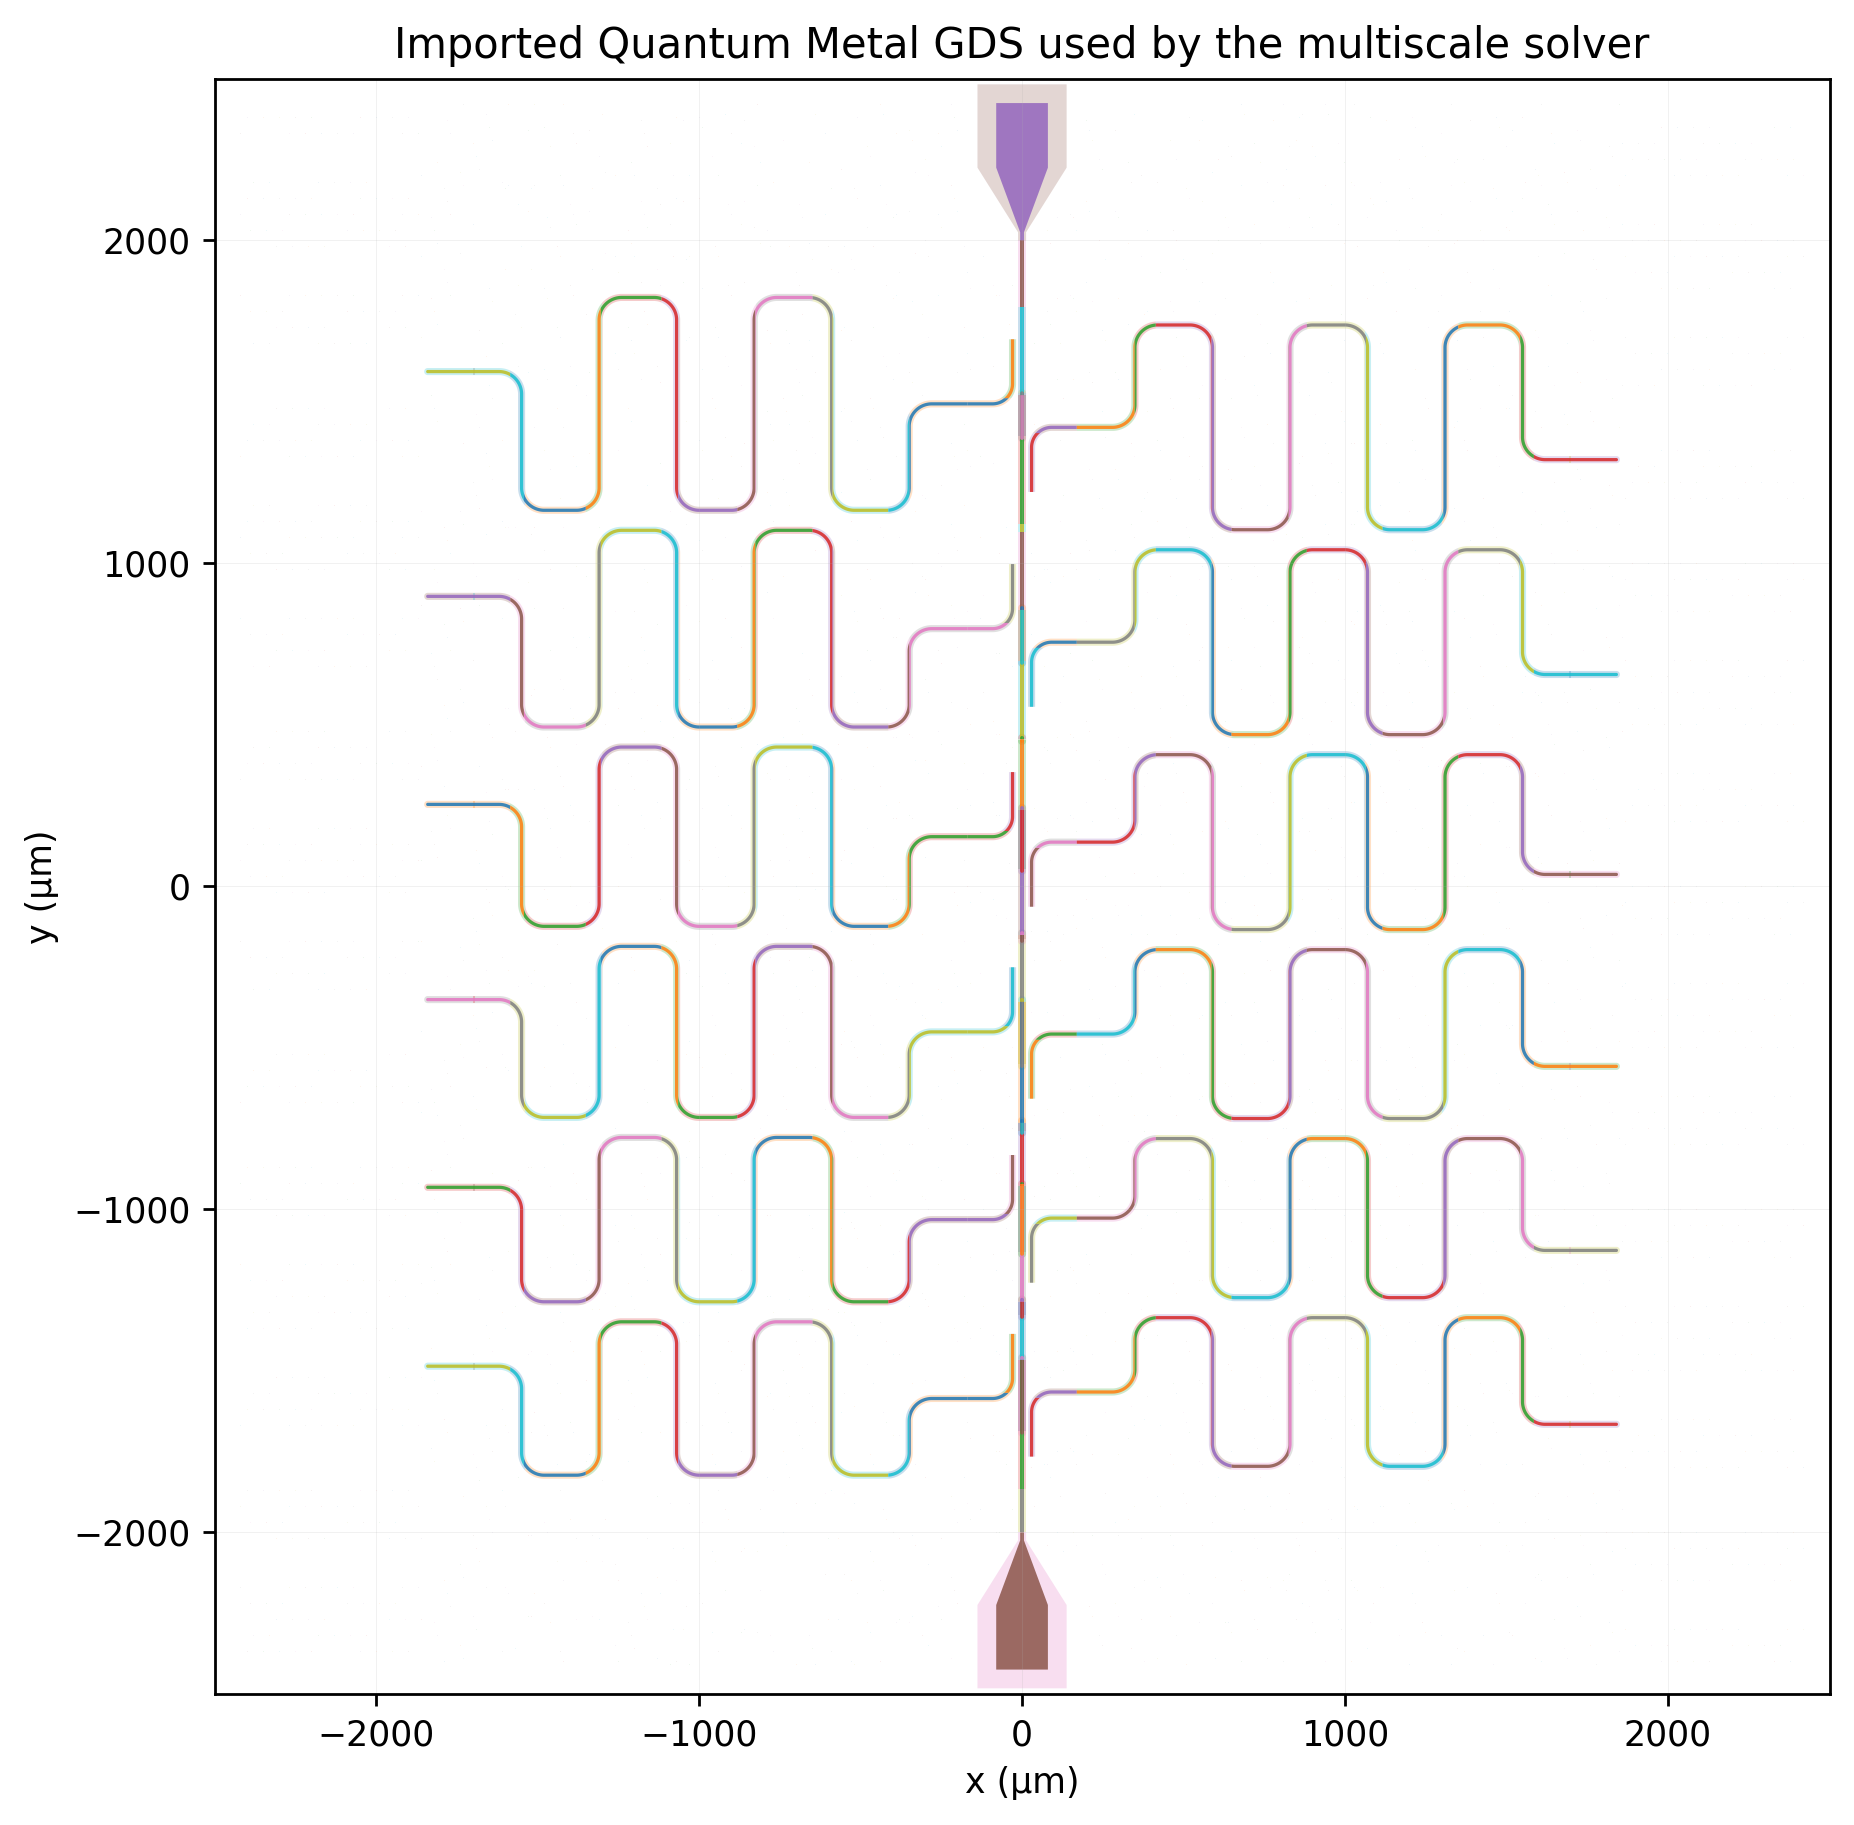


Array frequency sweep
  Frequency span              : 5.600 to 7.600 GHz
  GDS resonators recovered    : 12
  Uniform sweep points        : 200,001

Screening R1/12 (layout target 5.820000 GHz)
GPU CPW cross-section solve: 0.851 s on NVIDIA L4 | CSR + Jacobi-PCG (float64) | physical substrate
GPU CPW cross-section solve: 0.177 s on NVIDIA L4 | CSR + Jacobi-PCG (float64) | vacuum reference
Graph-FDTD broadband discovery: 0.157 s on NVIDIA L4
  Out-of-band model resonance : 5.577068 GHz

Screening R2/12 (layout target 5.965000 GHz)
  Transverse calibration      : reused cached CPW solution
Graph-FDTD broadband discovery: 0.075 s on NVIDIA L4
  In-band modeled resonance   : 5.718183 GHz | Ql=327,011

Screening R3/12 (layout target 6.116000 GHz)
  Transverse calibration      : reused cached CPW solution
Graph-FDTD broadband discovery: 0.075 s on NVIDIA L4
  In-band modeled resonance   : 5.870877 GHz | Ql=360,644

Screening R4/12 (layout target 6.353000 GHz)
  Transverse calibration      :

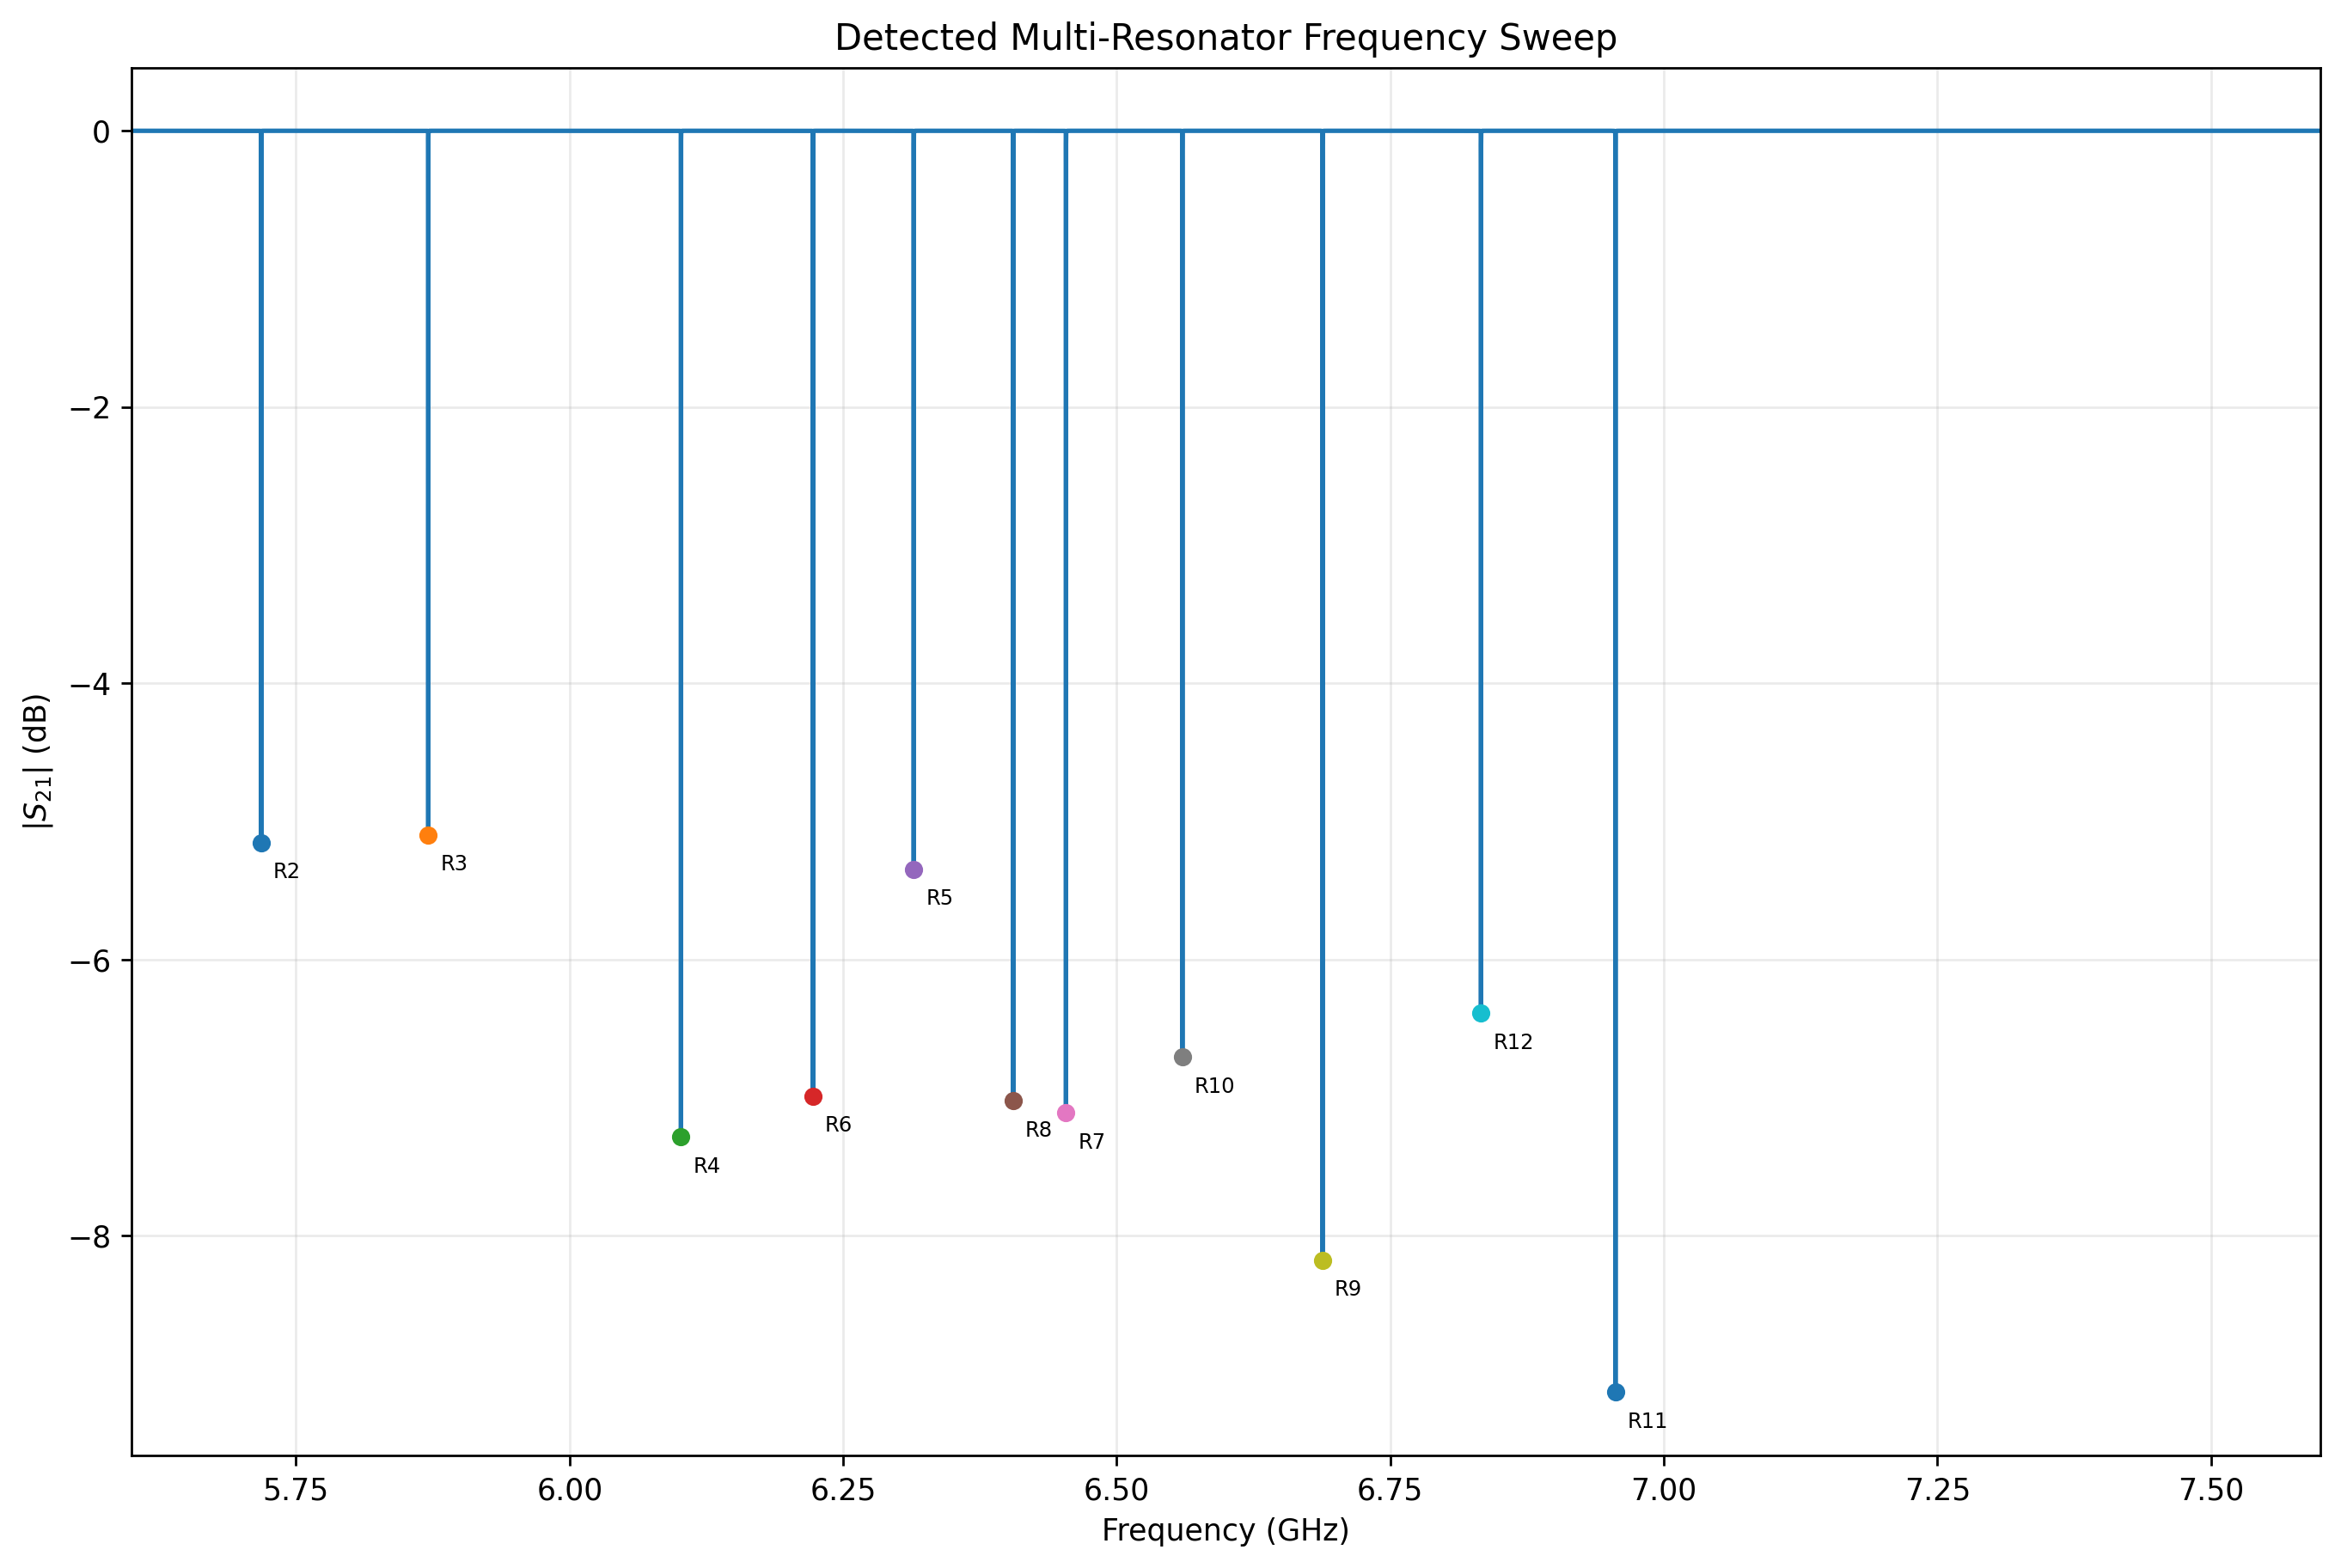


Detected 11 resonance responses from 11 in-band GDS resonators.

Snapshot 1/11: R2 at 5.718183 GHz
Graph-FDTD phasor accumulation: 0.322 s on NVIDIA L4


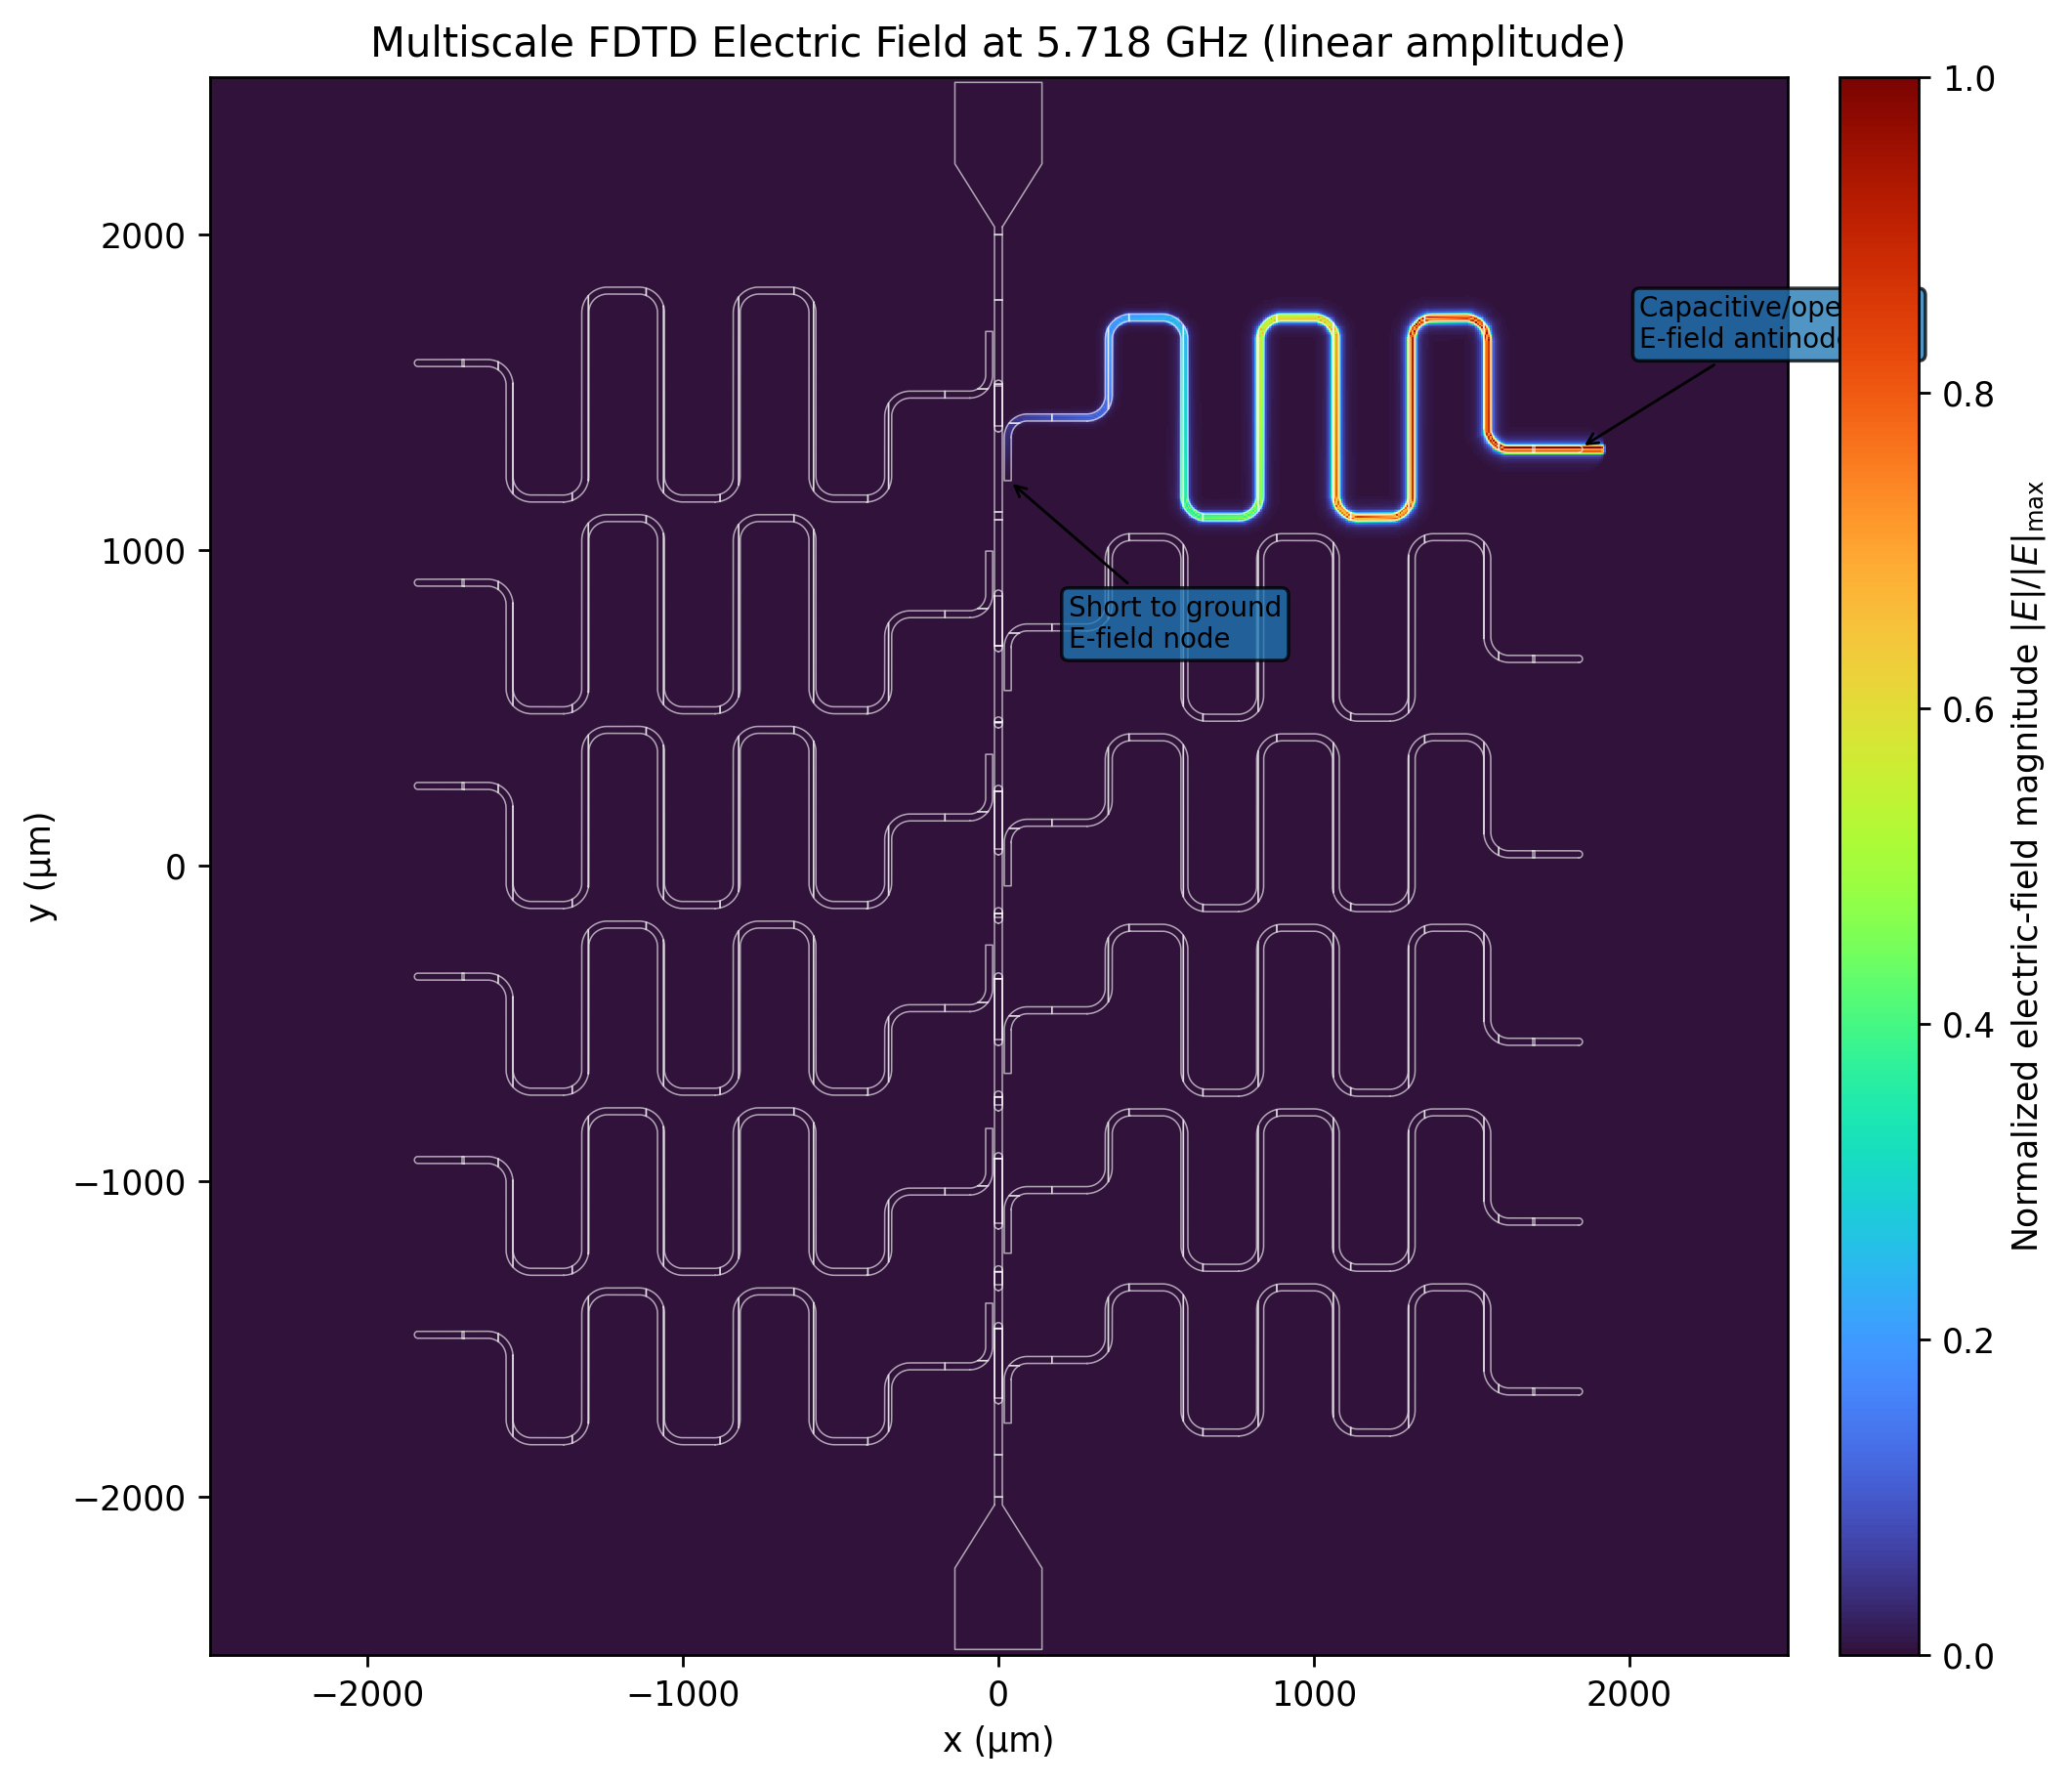


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -42.882 to -1.878
  arrows                      : 558
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 5.70 degrees

Snapshot 2/11: R3 at 5.870877 GHz
Graph-FDTD phasor accumulation: 0.202 s on NVIDIA L4


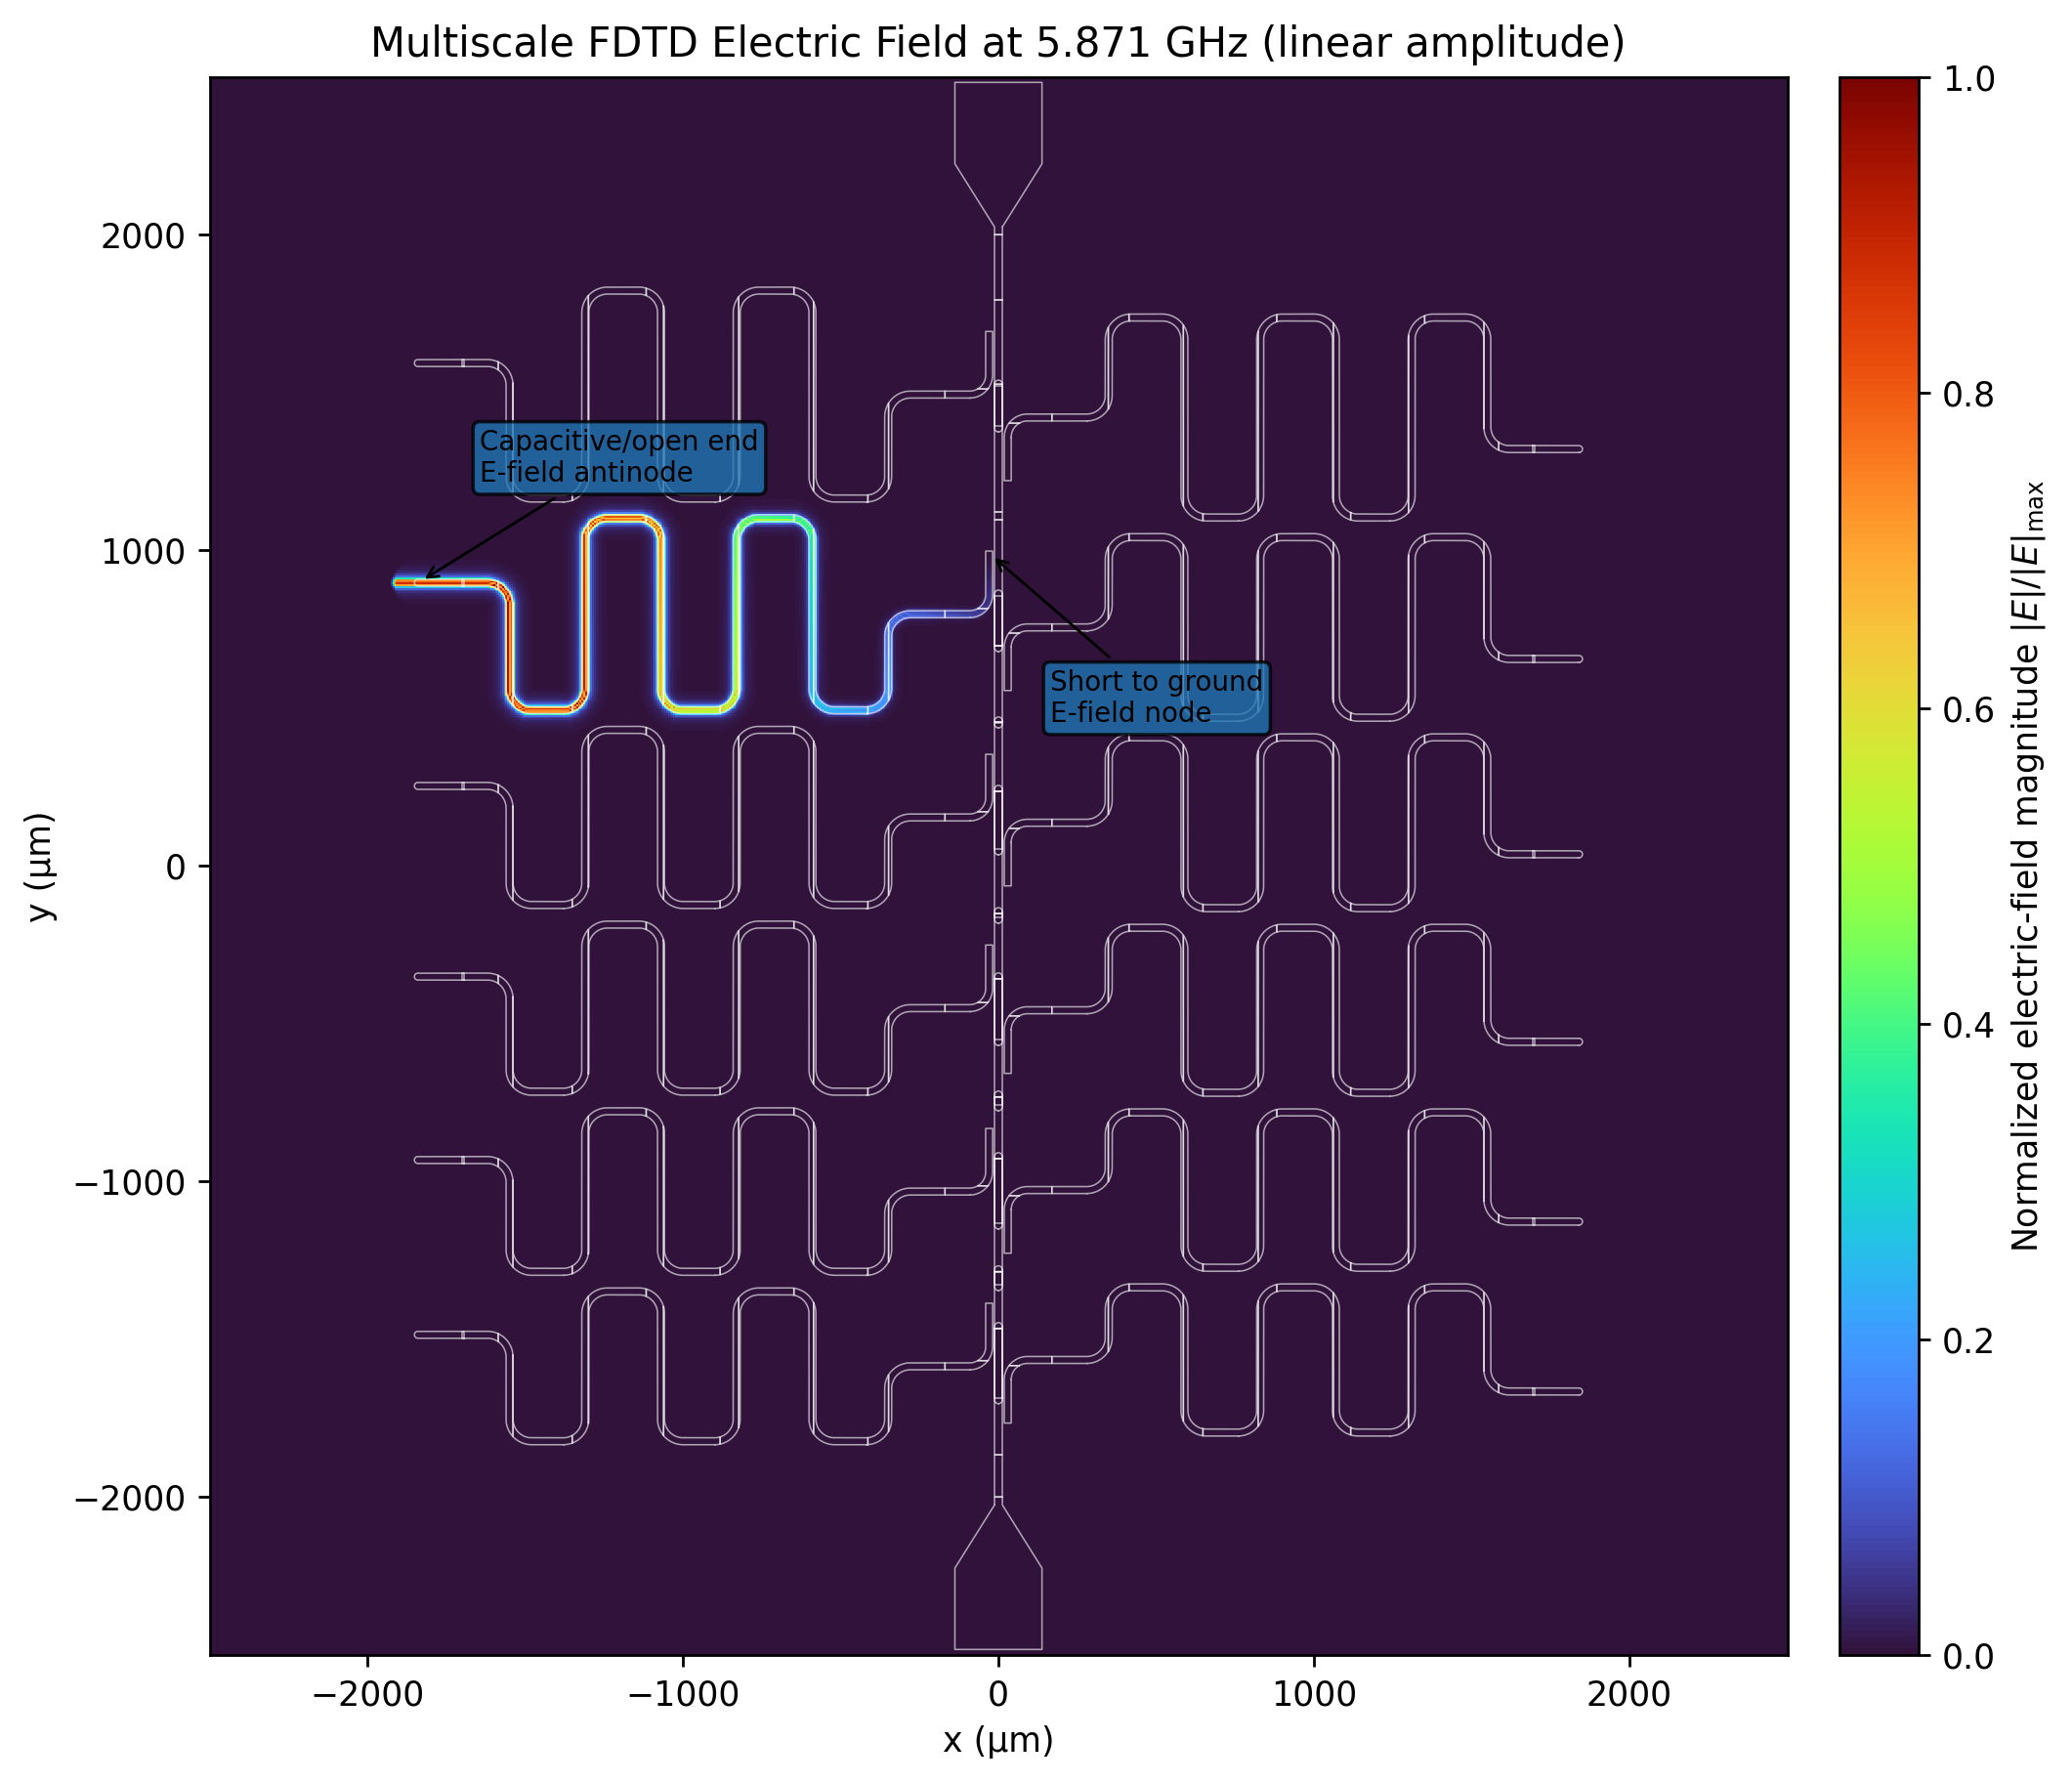


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -41.378 to -0.407
  arrows                      : 616
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 6.03 degrees

Snapshot 3/11: R4 at 6.101818 GHz
Graph-FDTD phasor accumulation: 0.199 s on NVIDIA L4


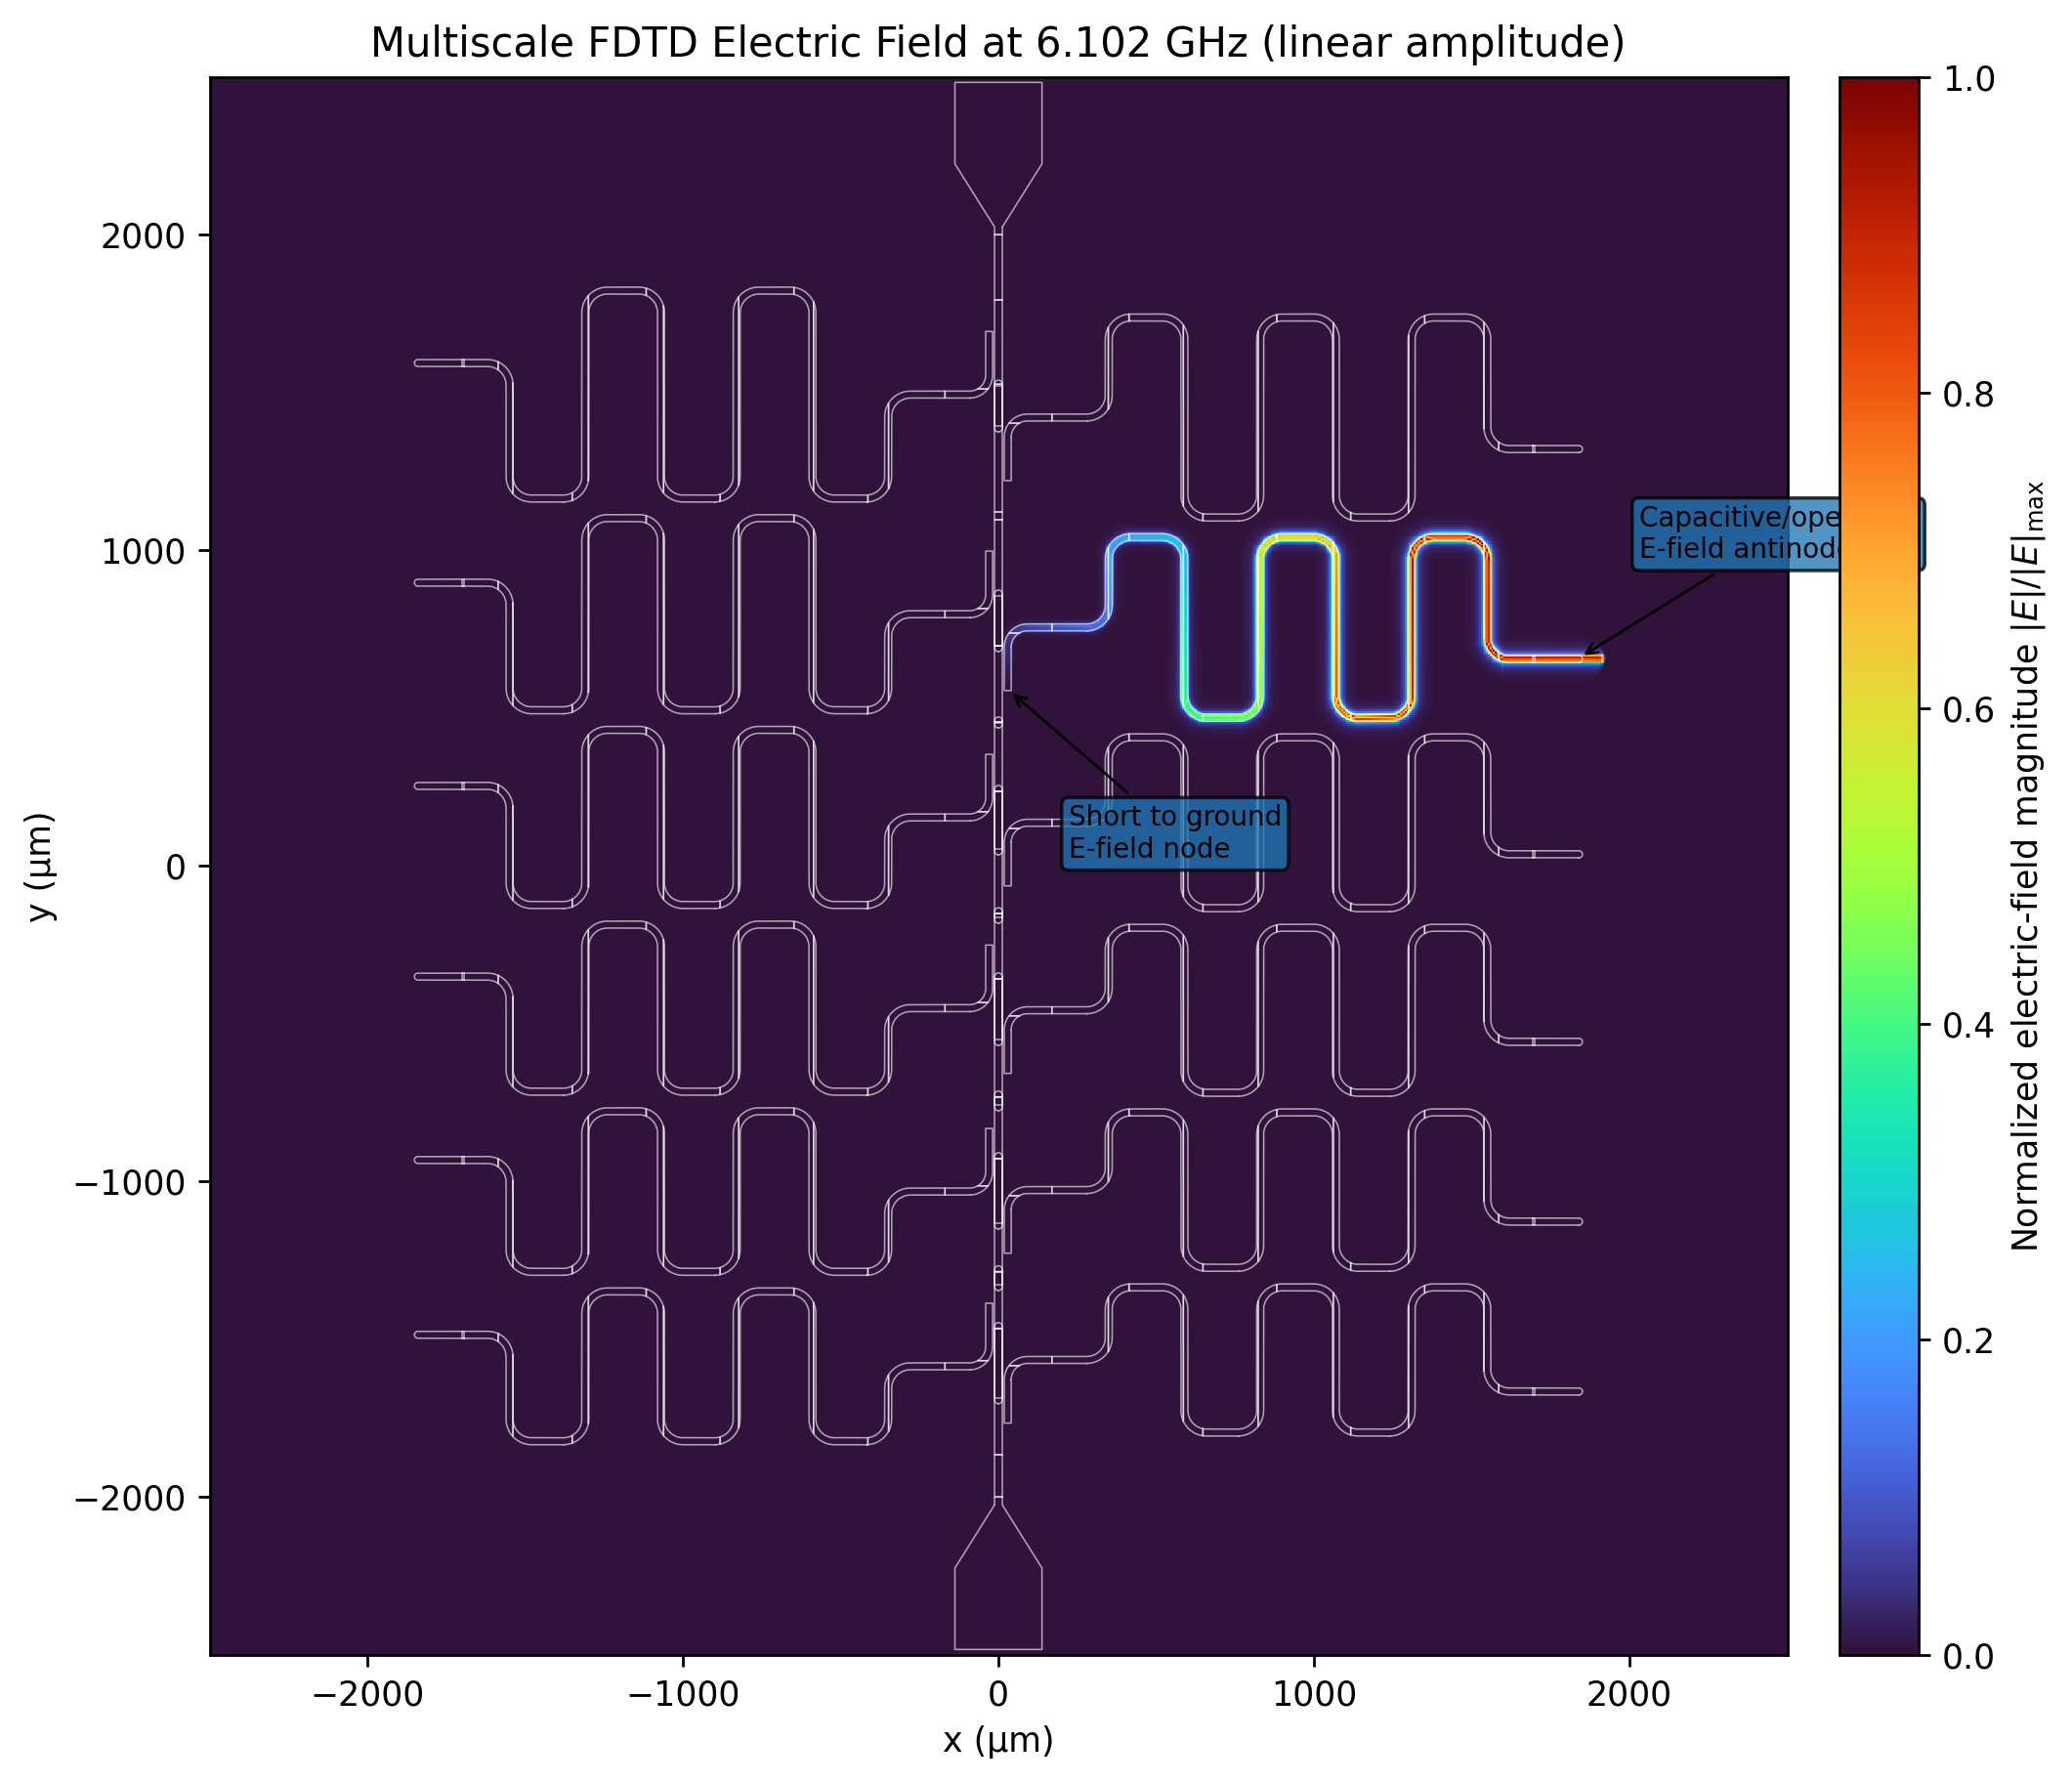


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -49.682 to -0.180
  arrows                      : 578
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 6.60 degrees

Snapshot 4/11: R6 at 6.222389 GHz
Graph-FDTD phasor accumulation: 0.197 s on NVIDIA L4


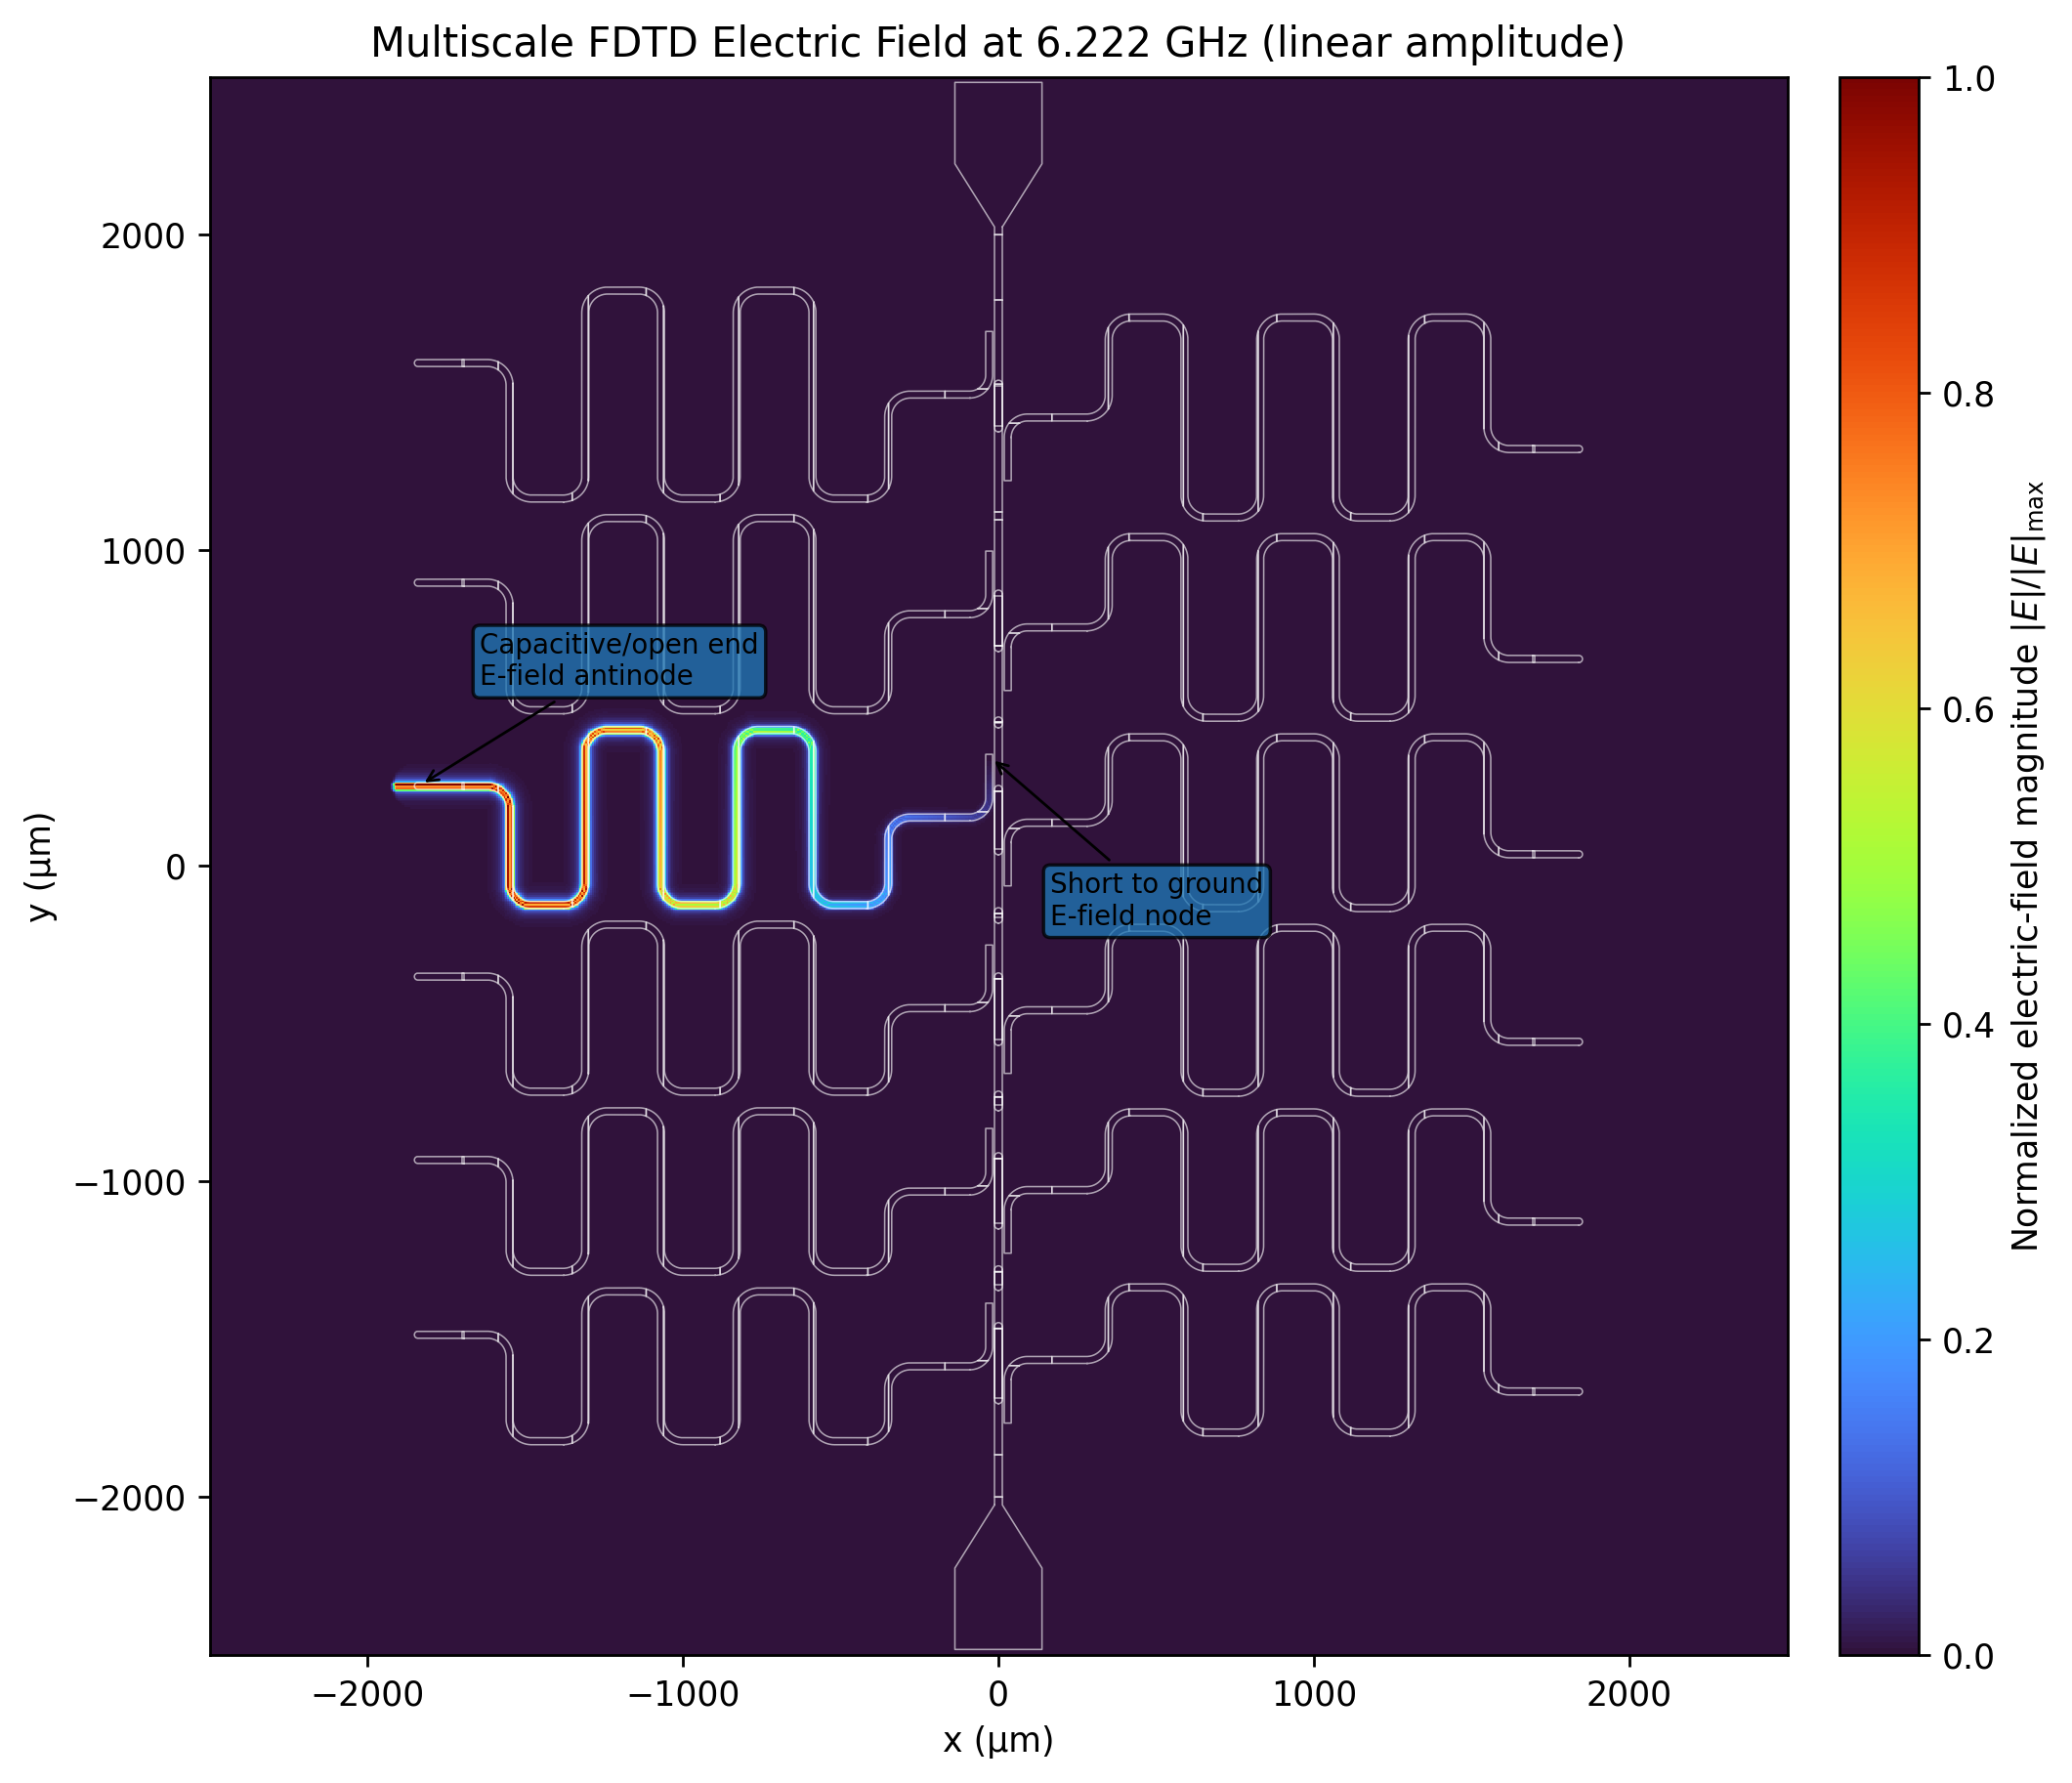


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -43.296 to -0.539
  arrows                      : 562
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 7.32 degrees

Snapshot 5/11: R5 at 6.314545 GHz
Graph-FDTD phasor accumulation: 0.198 s on NVIDIA L4


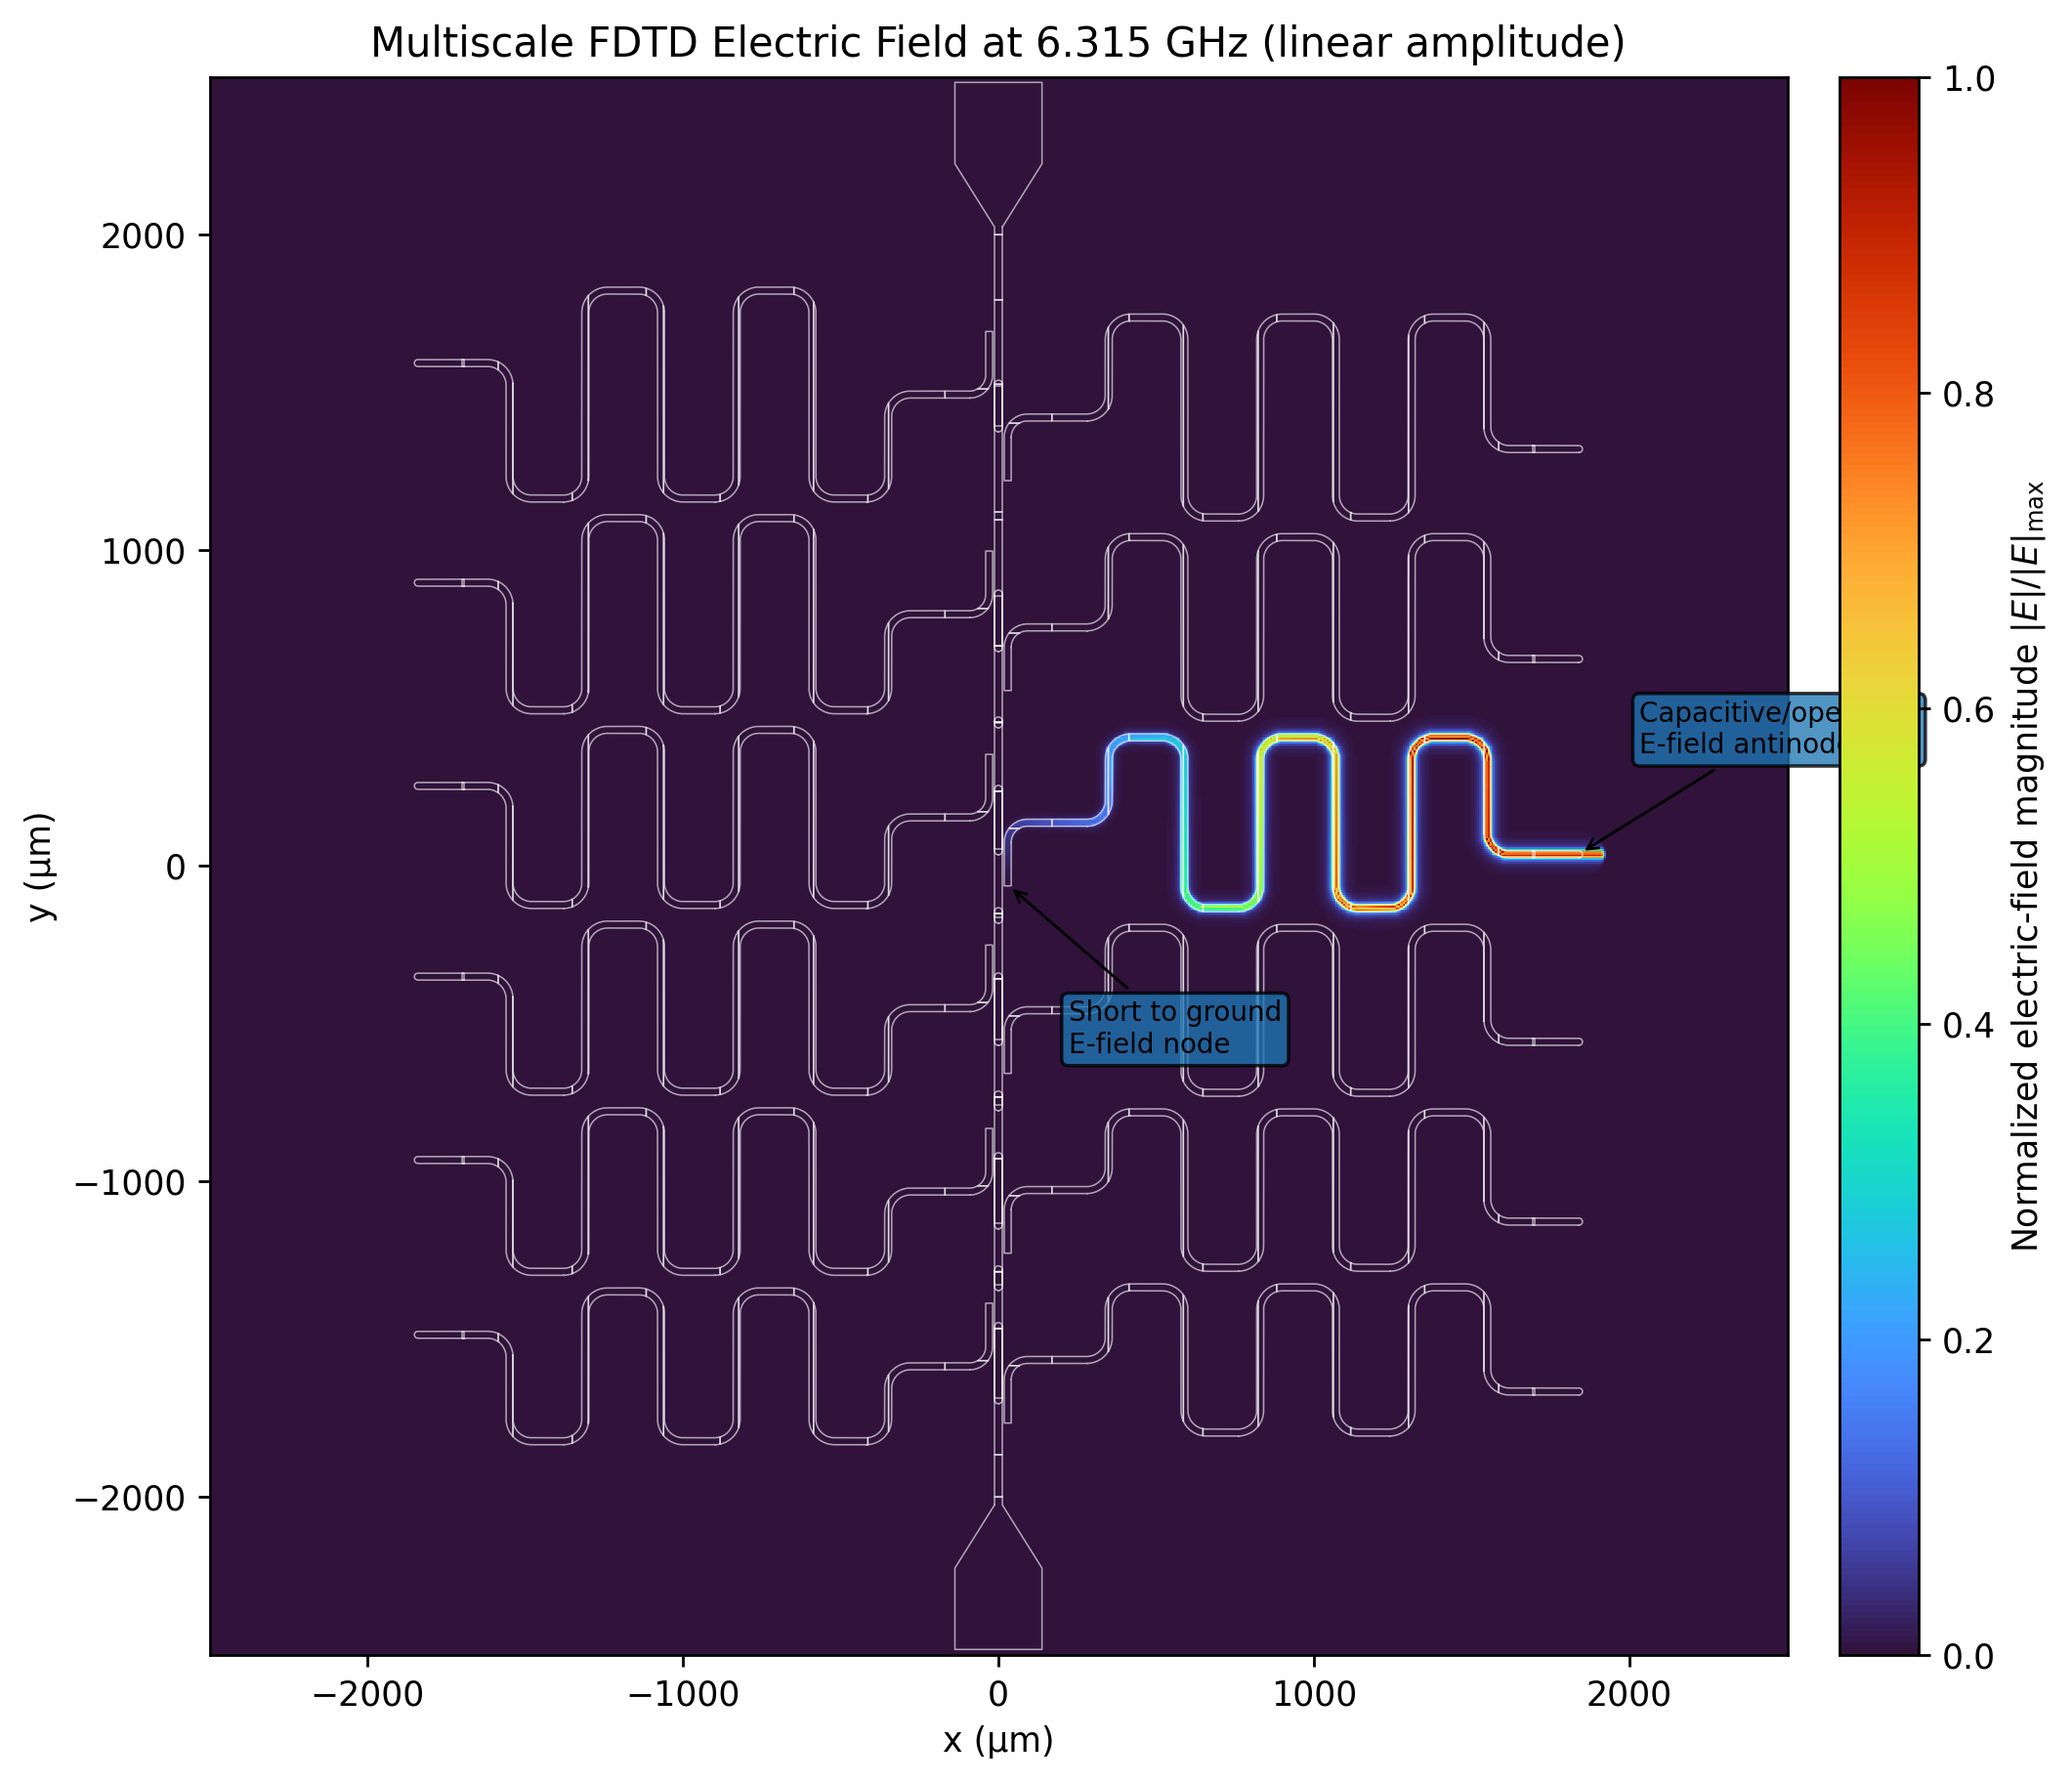


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -48.392 to -0.423
  arrows                      : 556
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 7.04 degrees

Snapshot 6/11: R8 at 6.405419 GHz
Graph-FDTD phasor accumulation: 0.195 s on NVIDIA L4


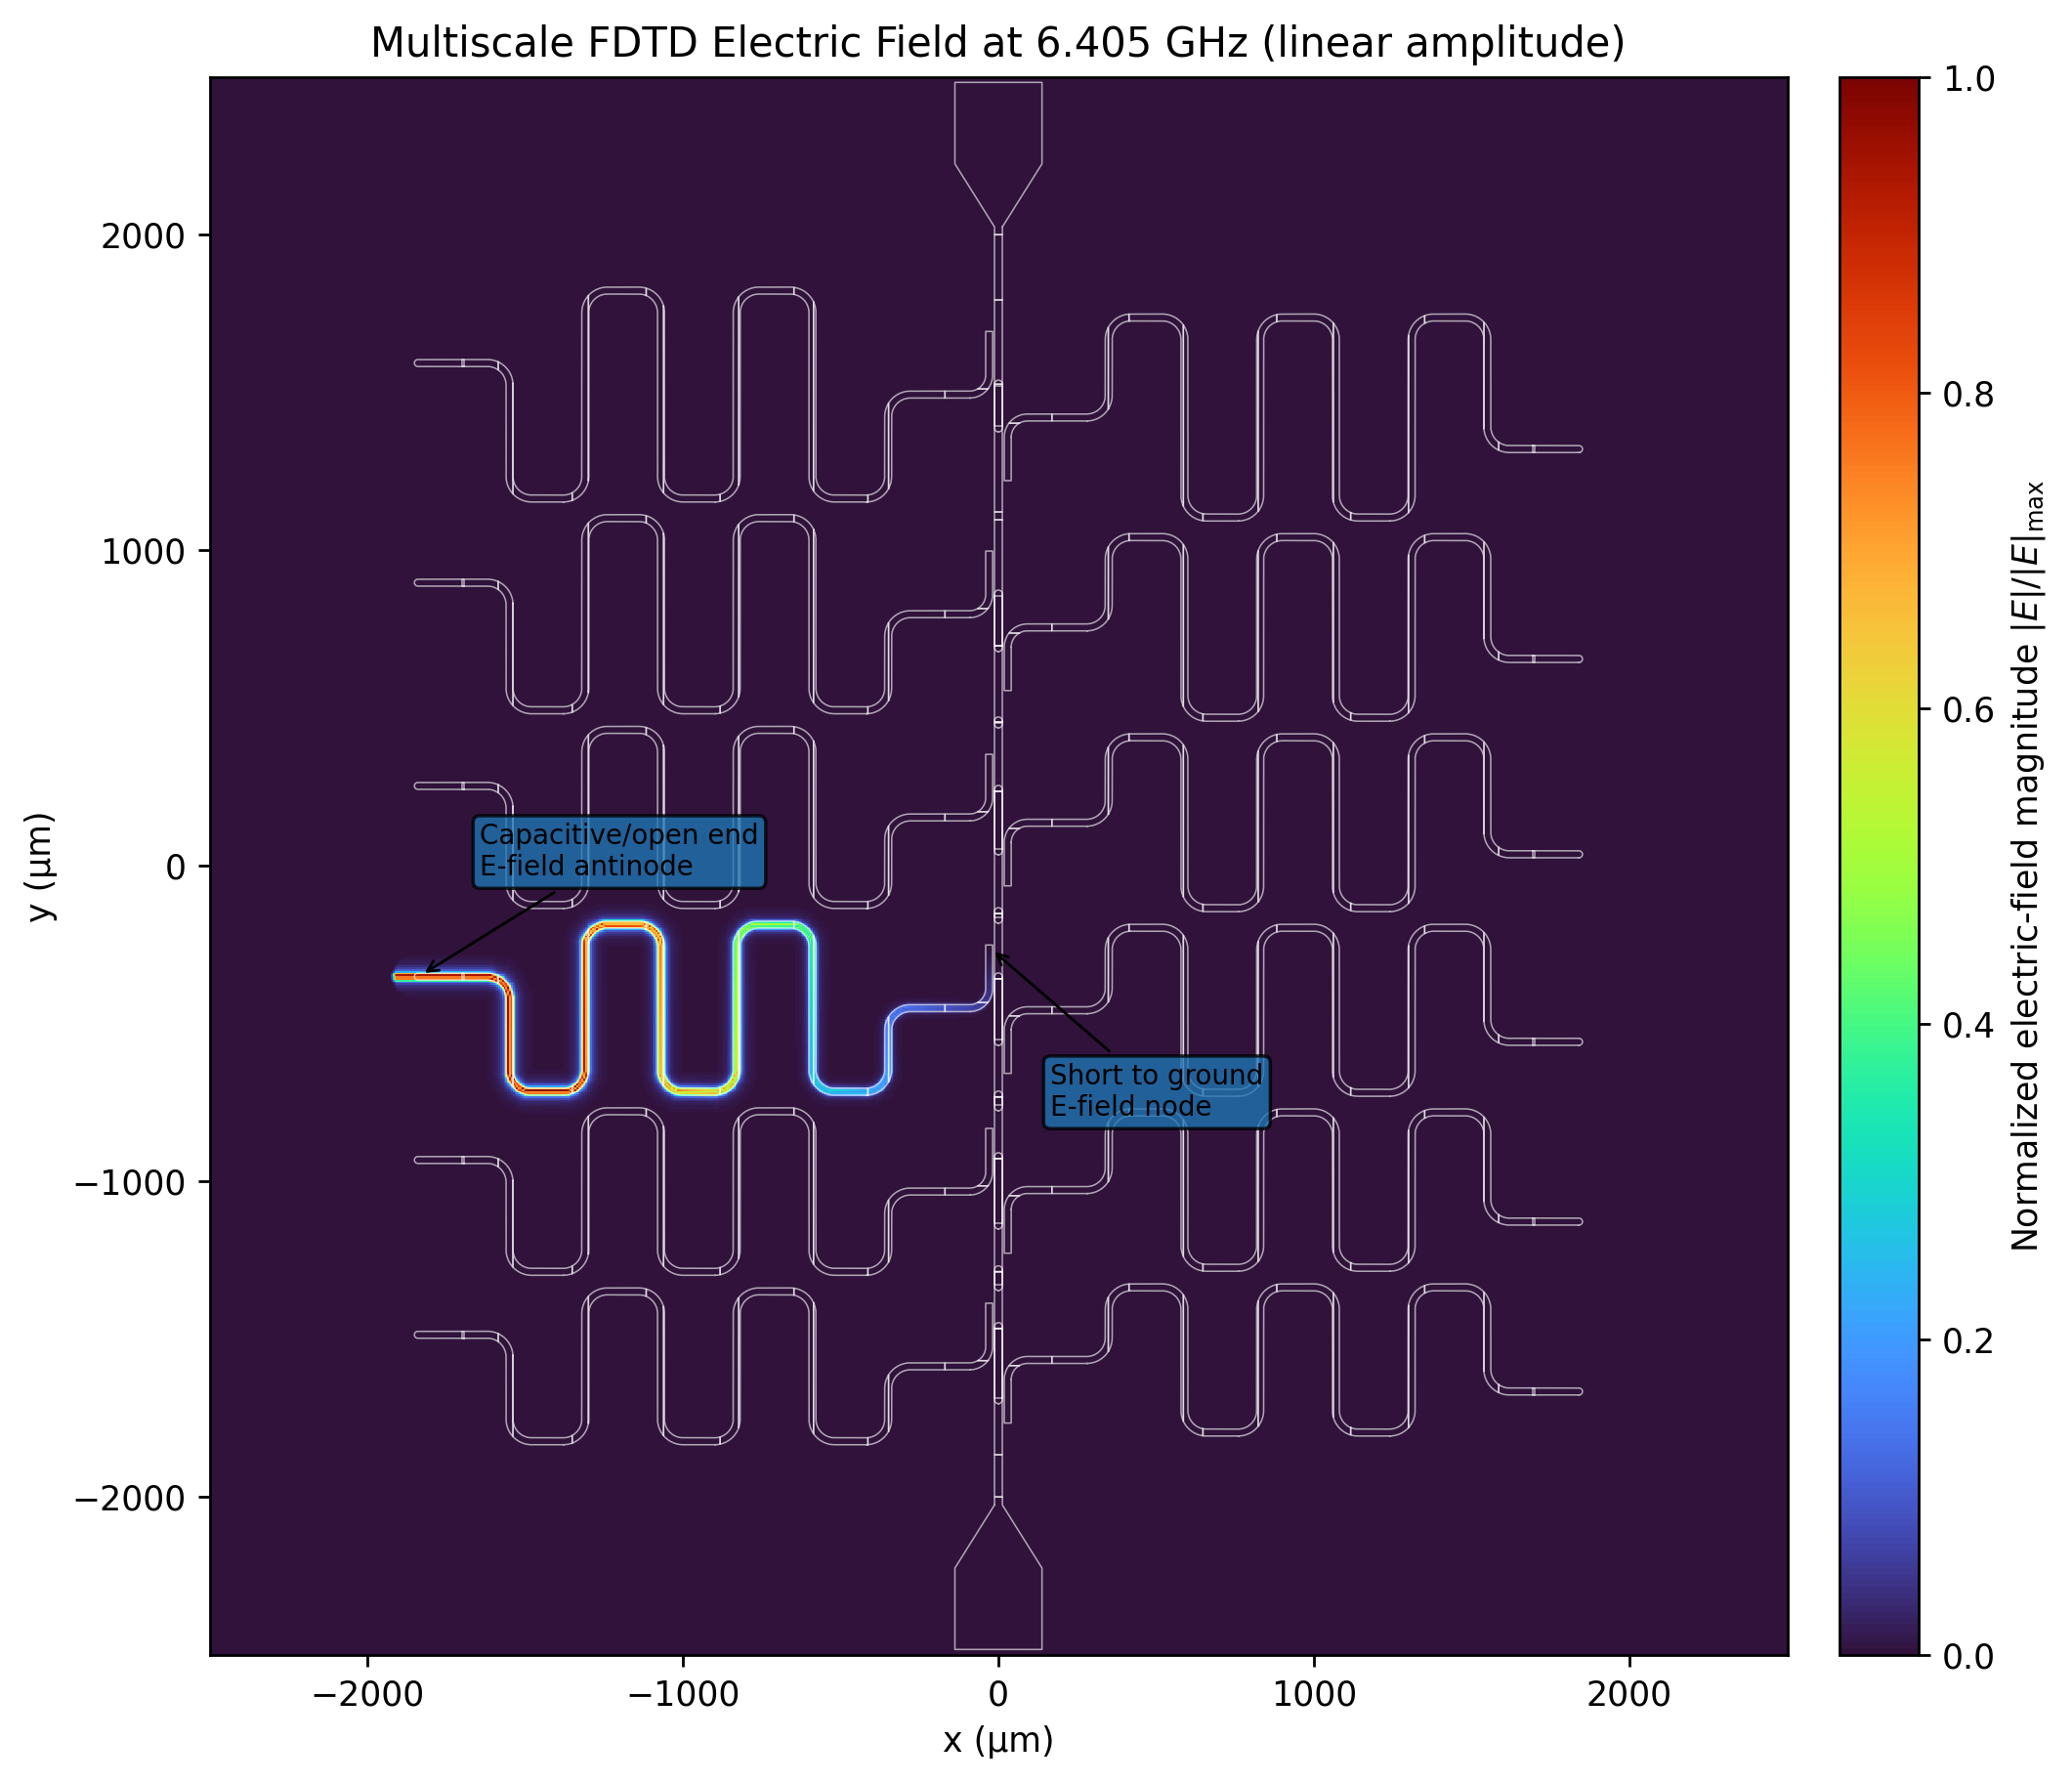


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -54.305 to -0.150
  arrows                      : 571
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 7.80 degrees

Snapshot 7/11: R7 at 6.453652 GHz
Graph-FDTD phasor accumulation: 0.196 s on NVIDIA L4


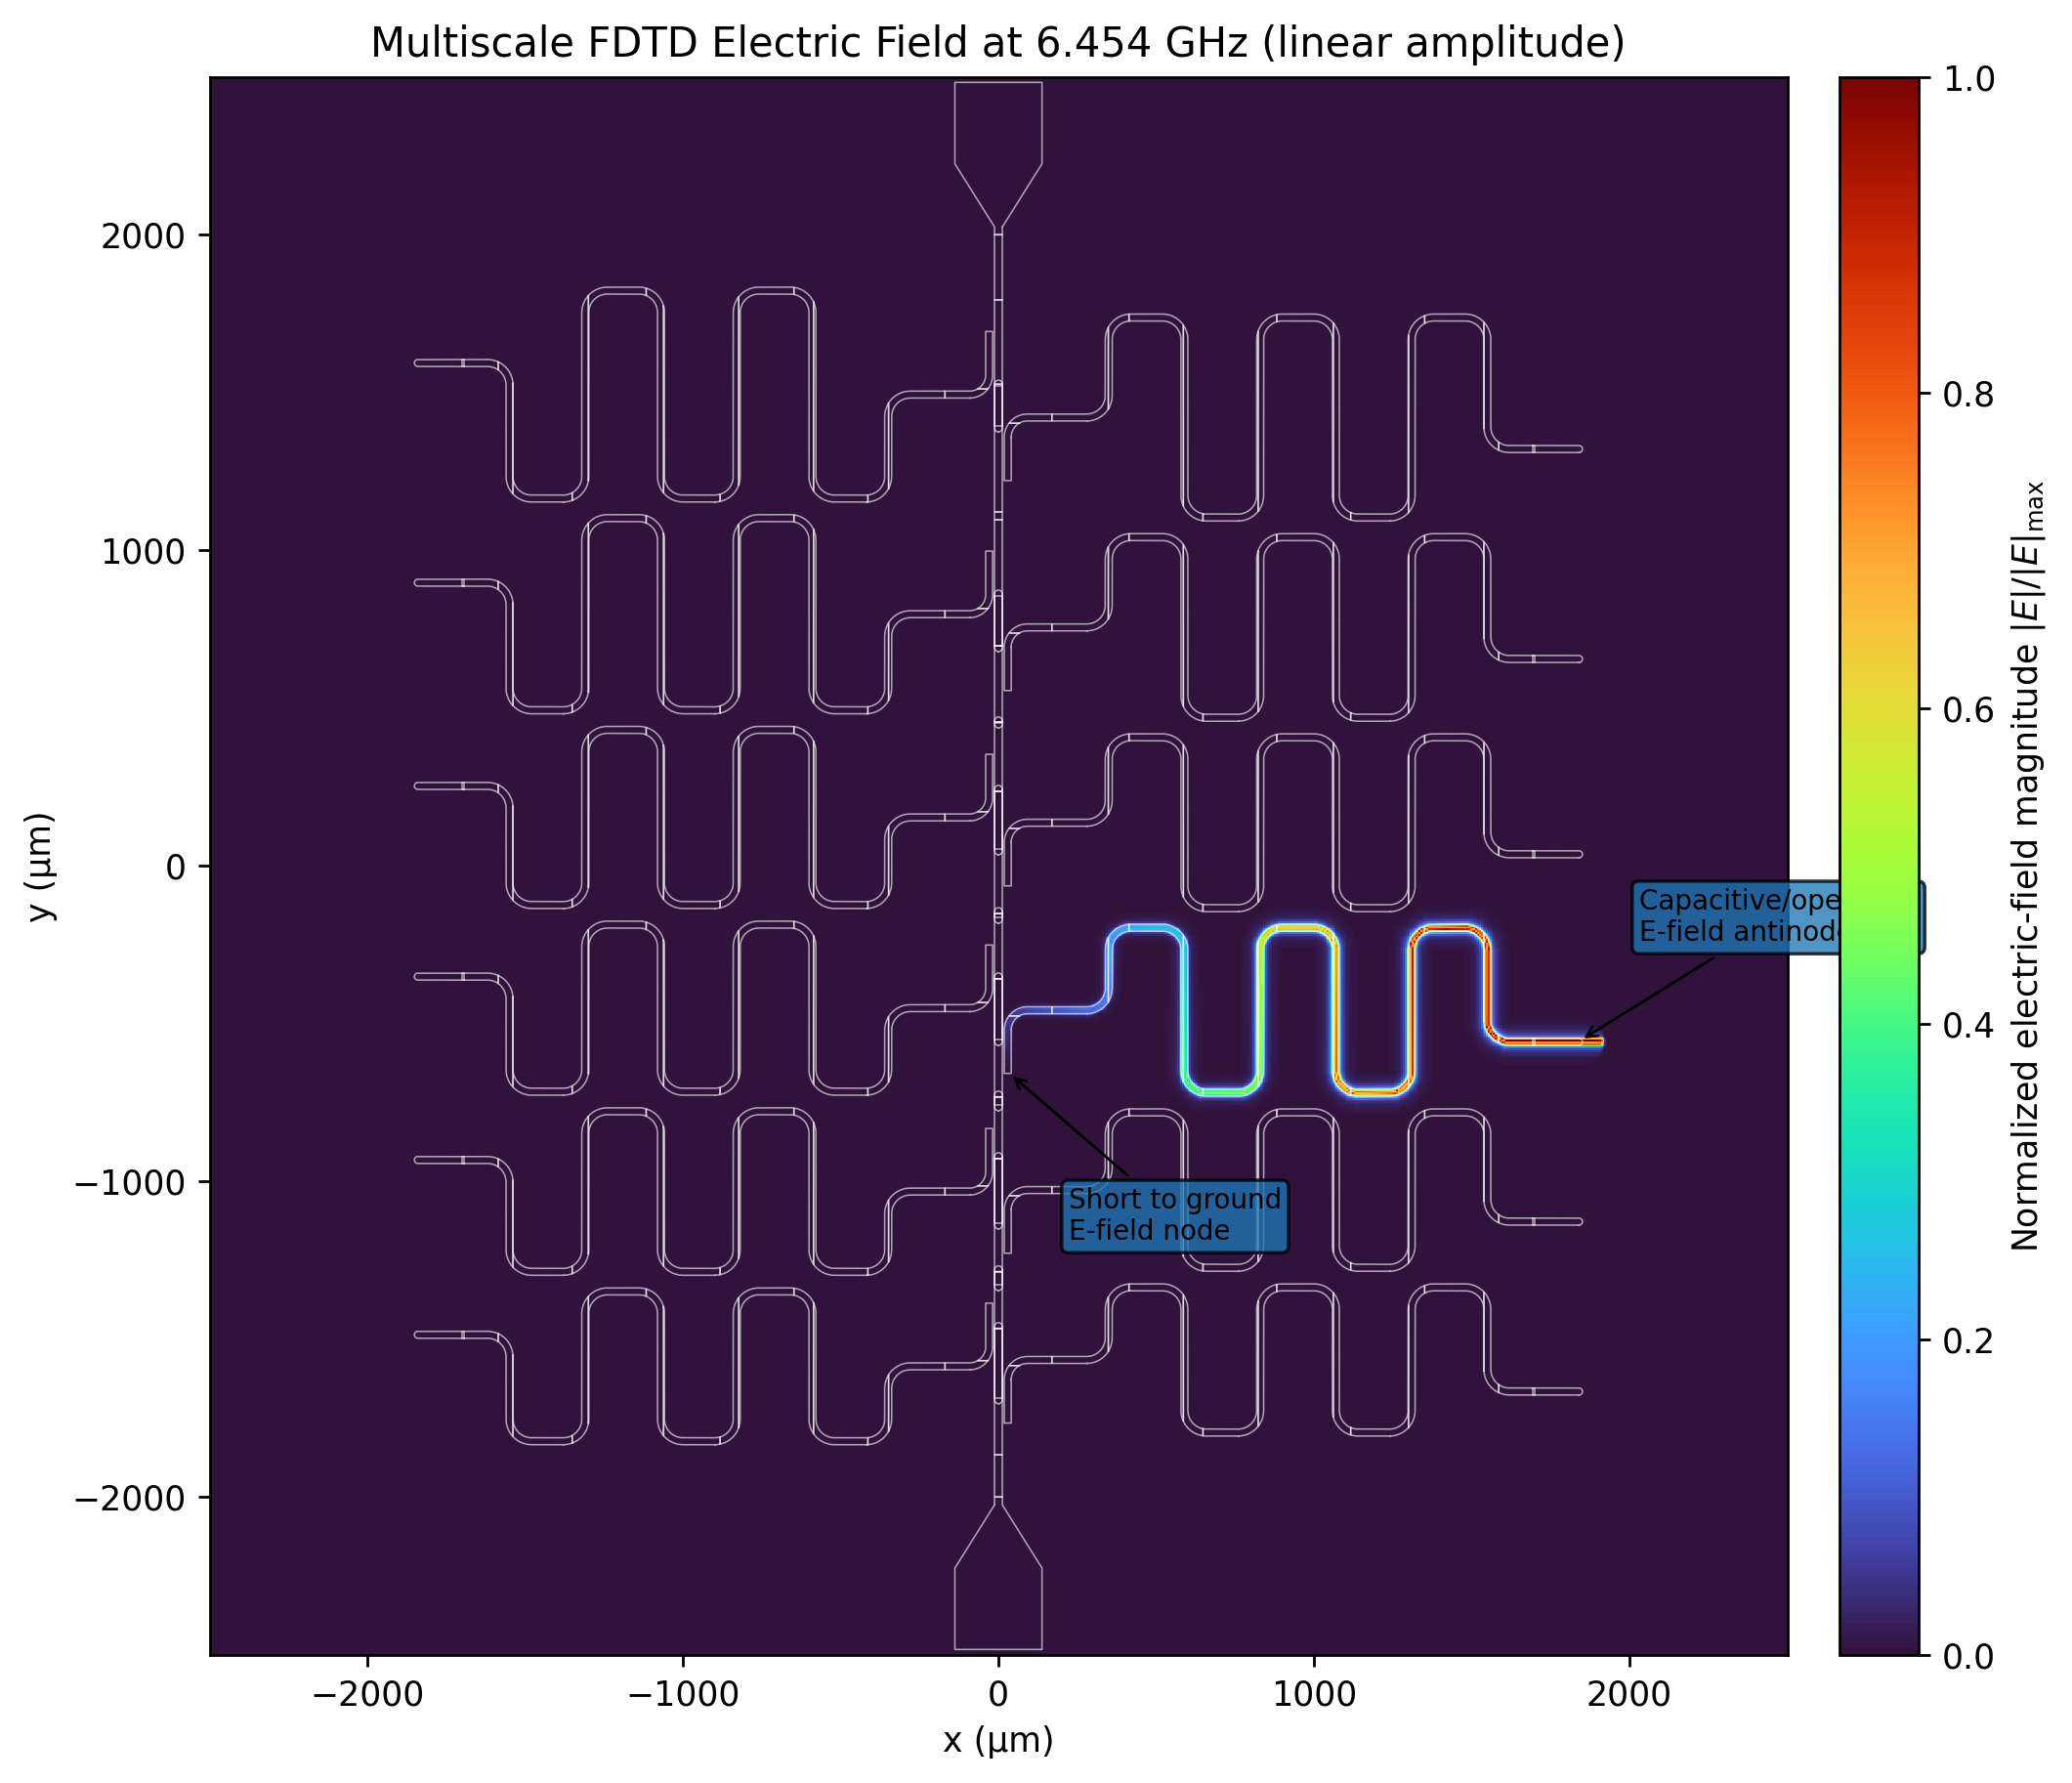


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -55.245 to -0.374
  arrows                      : 552
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 7.51 degrees

Snapshot 8/11: R10 at 6.560028 GHz
Graph-FDTD phasor accumulation: 0.193 s on NVIDIA L4


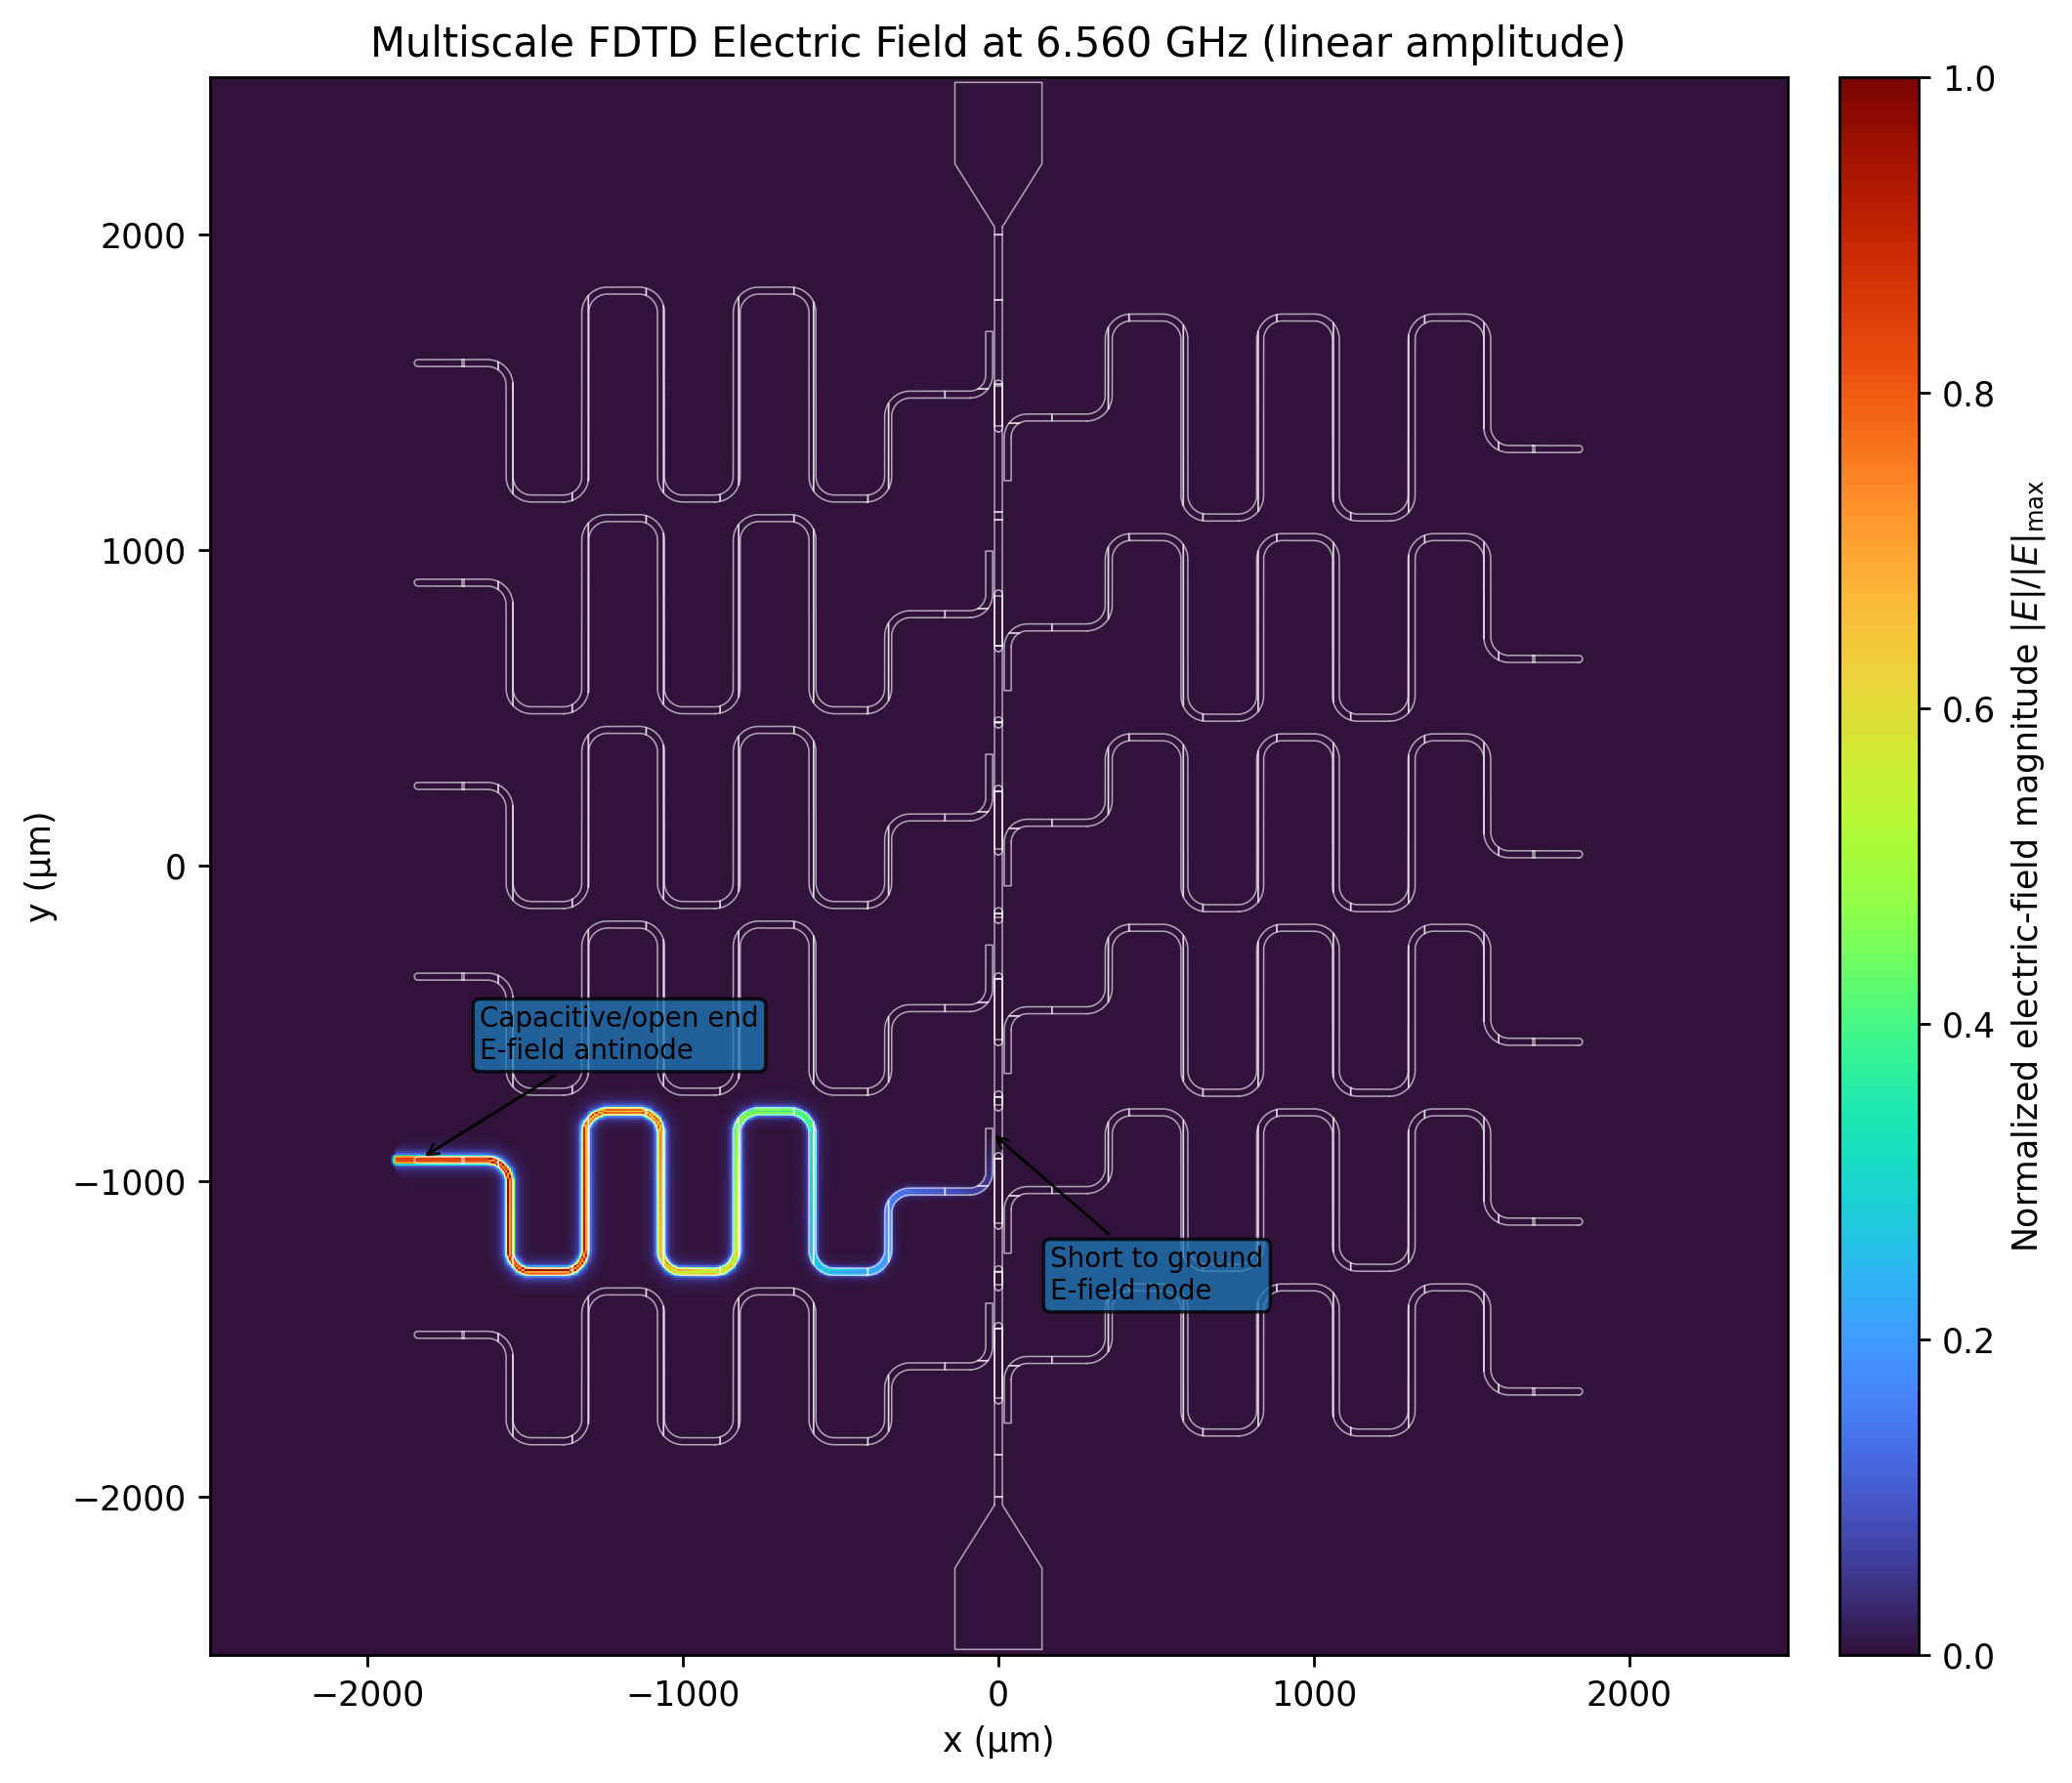


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -46.840 to -0.367
  arrows                      : 532
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 8.58 degrees

Snapshot 9/11: R9 at 6.688081 GHz
Graph-FDTD phasor accumulation: 0.194 s on NVIDIA L4


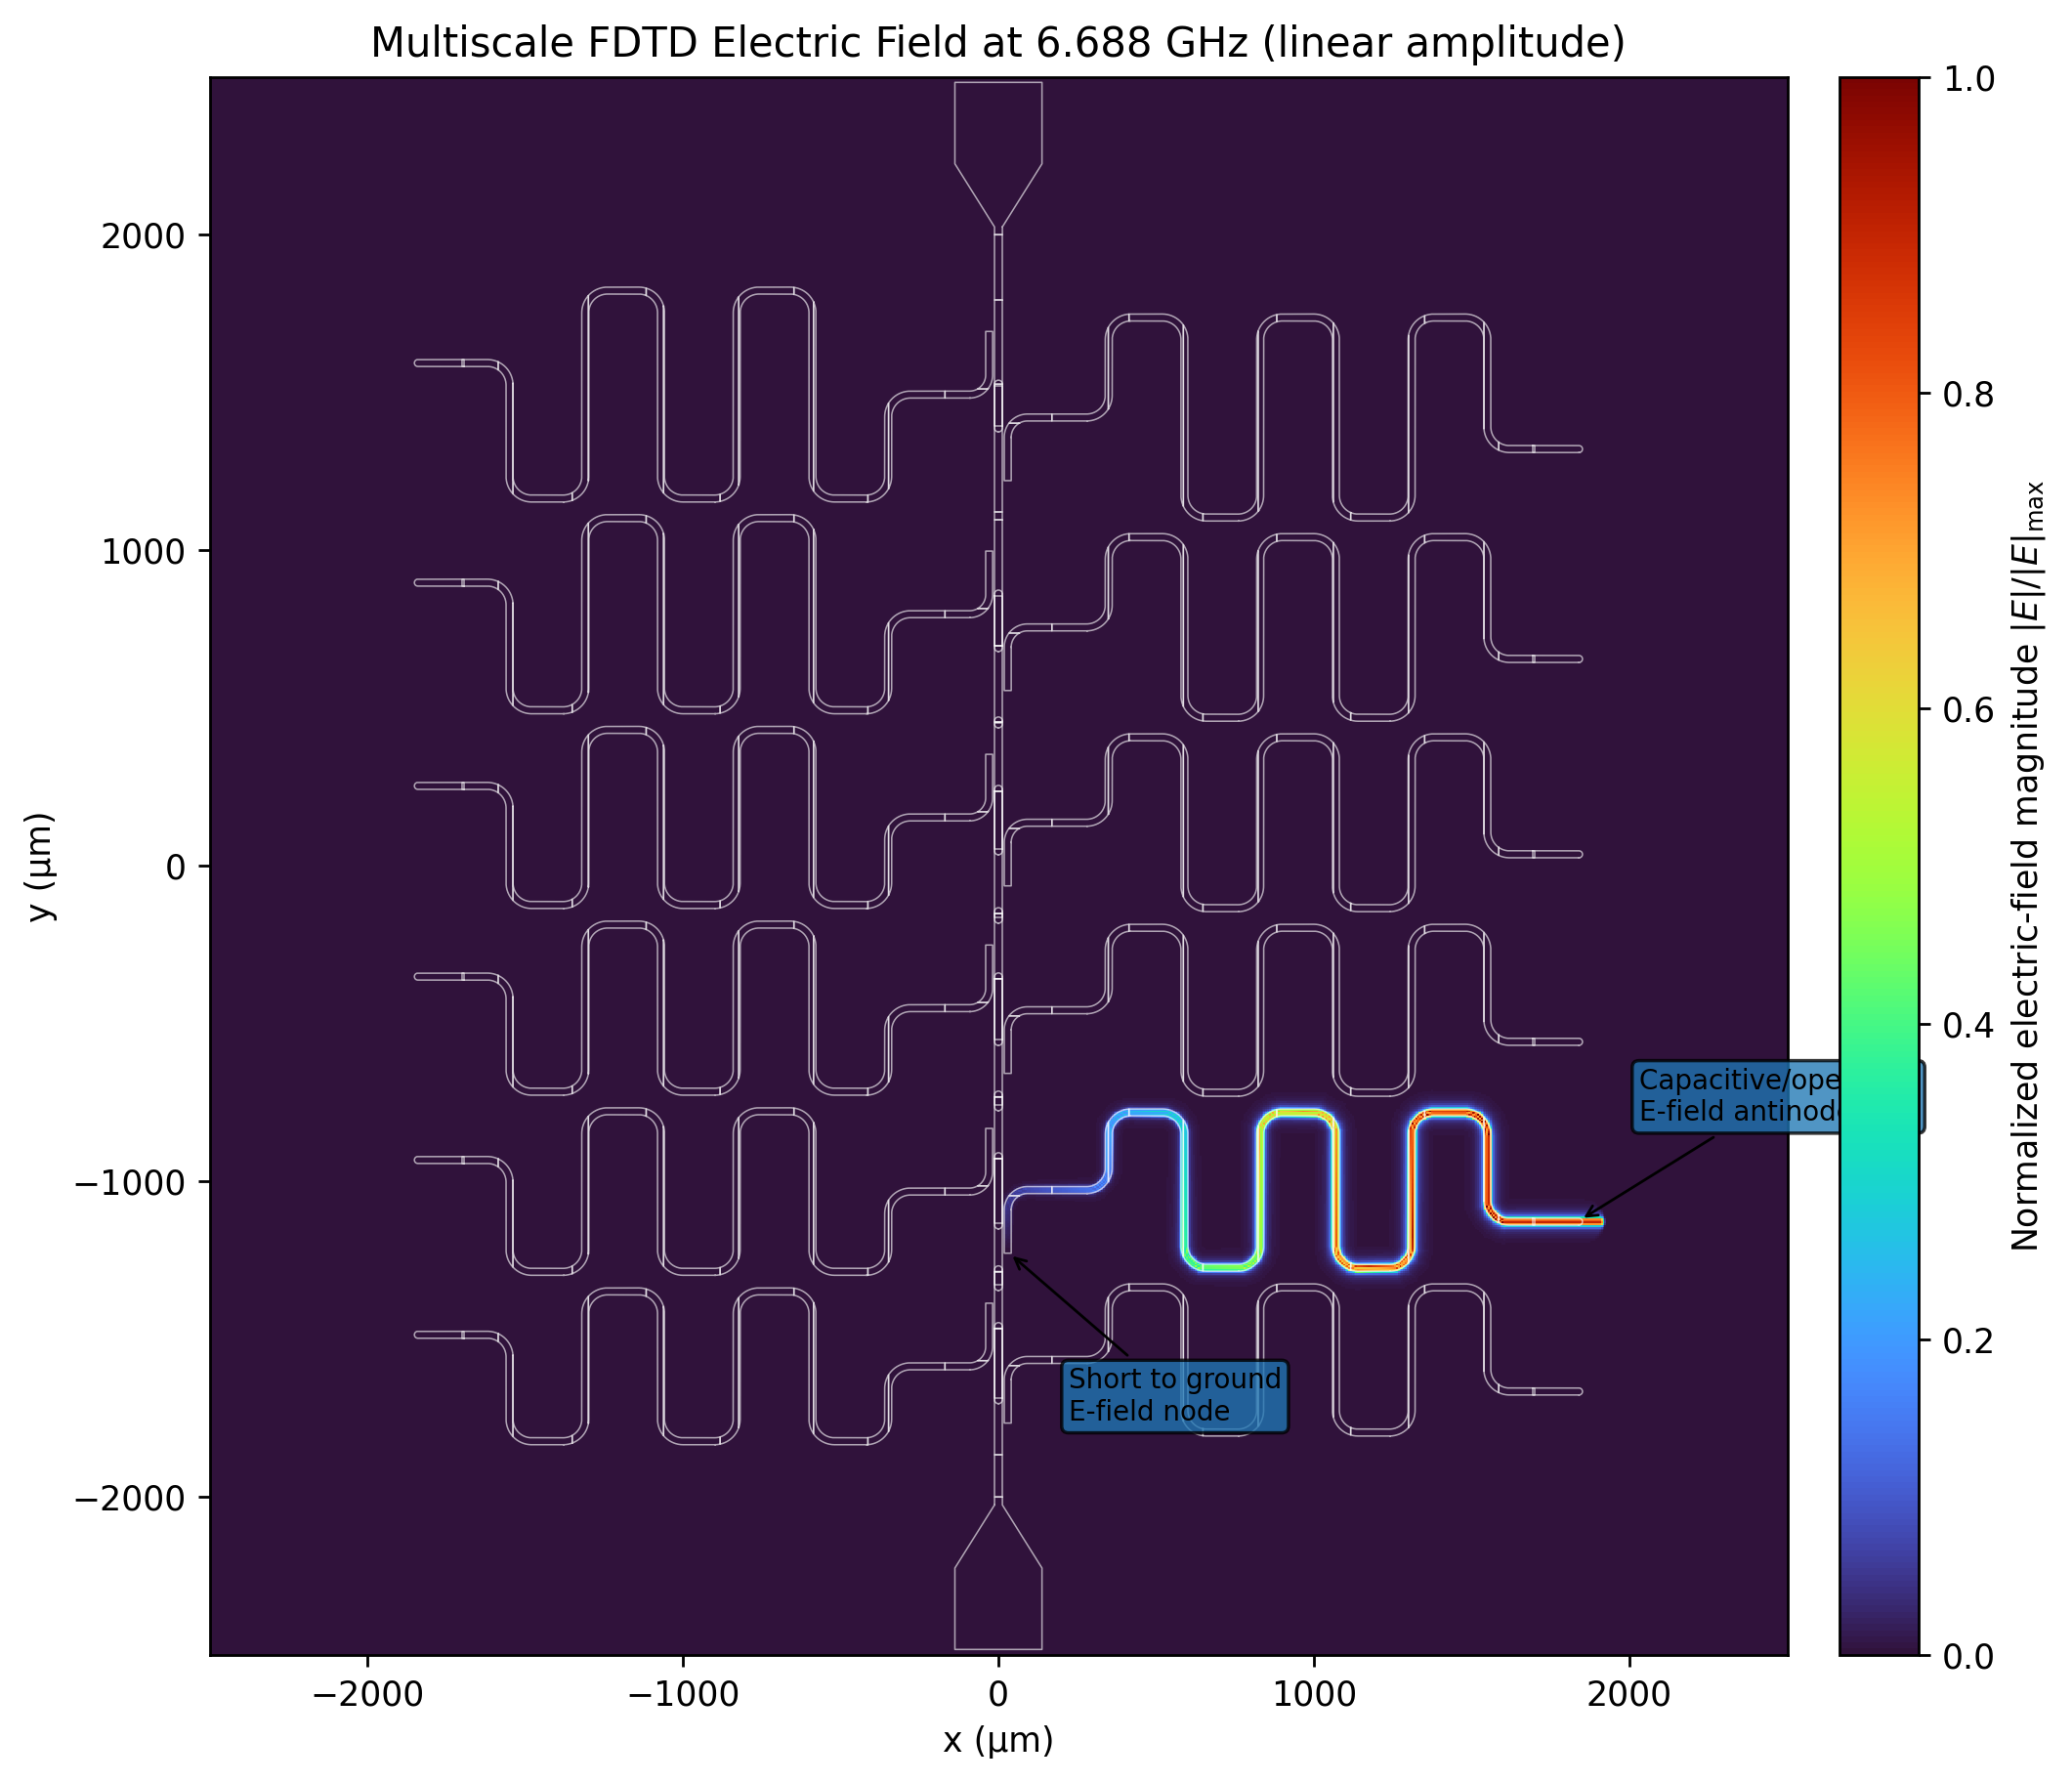


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -44.030 to -0.394
  arrows                      : 577
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 8.11 degrees

Snapshot 10/11: R12 at 6.832933 GHz
Graph-FDTD phasor accumulation: 0.190 s on NVIDIA L4


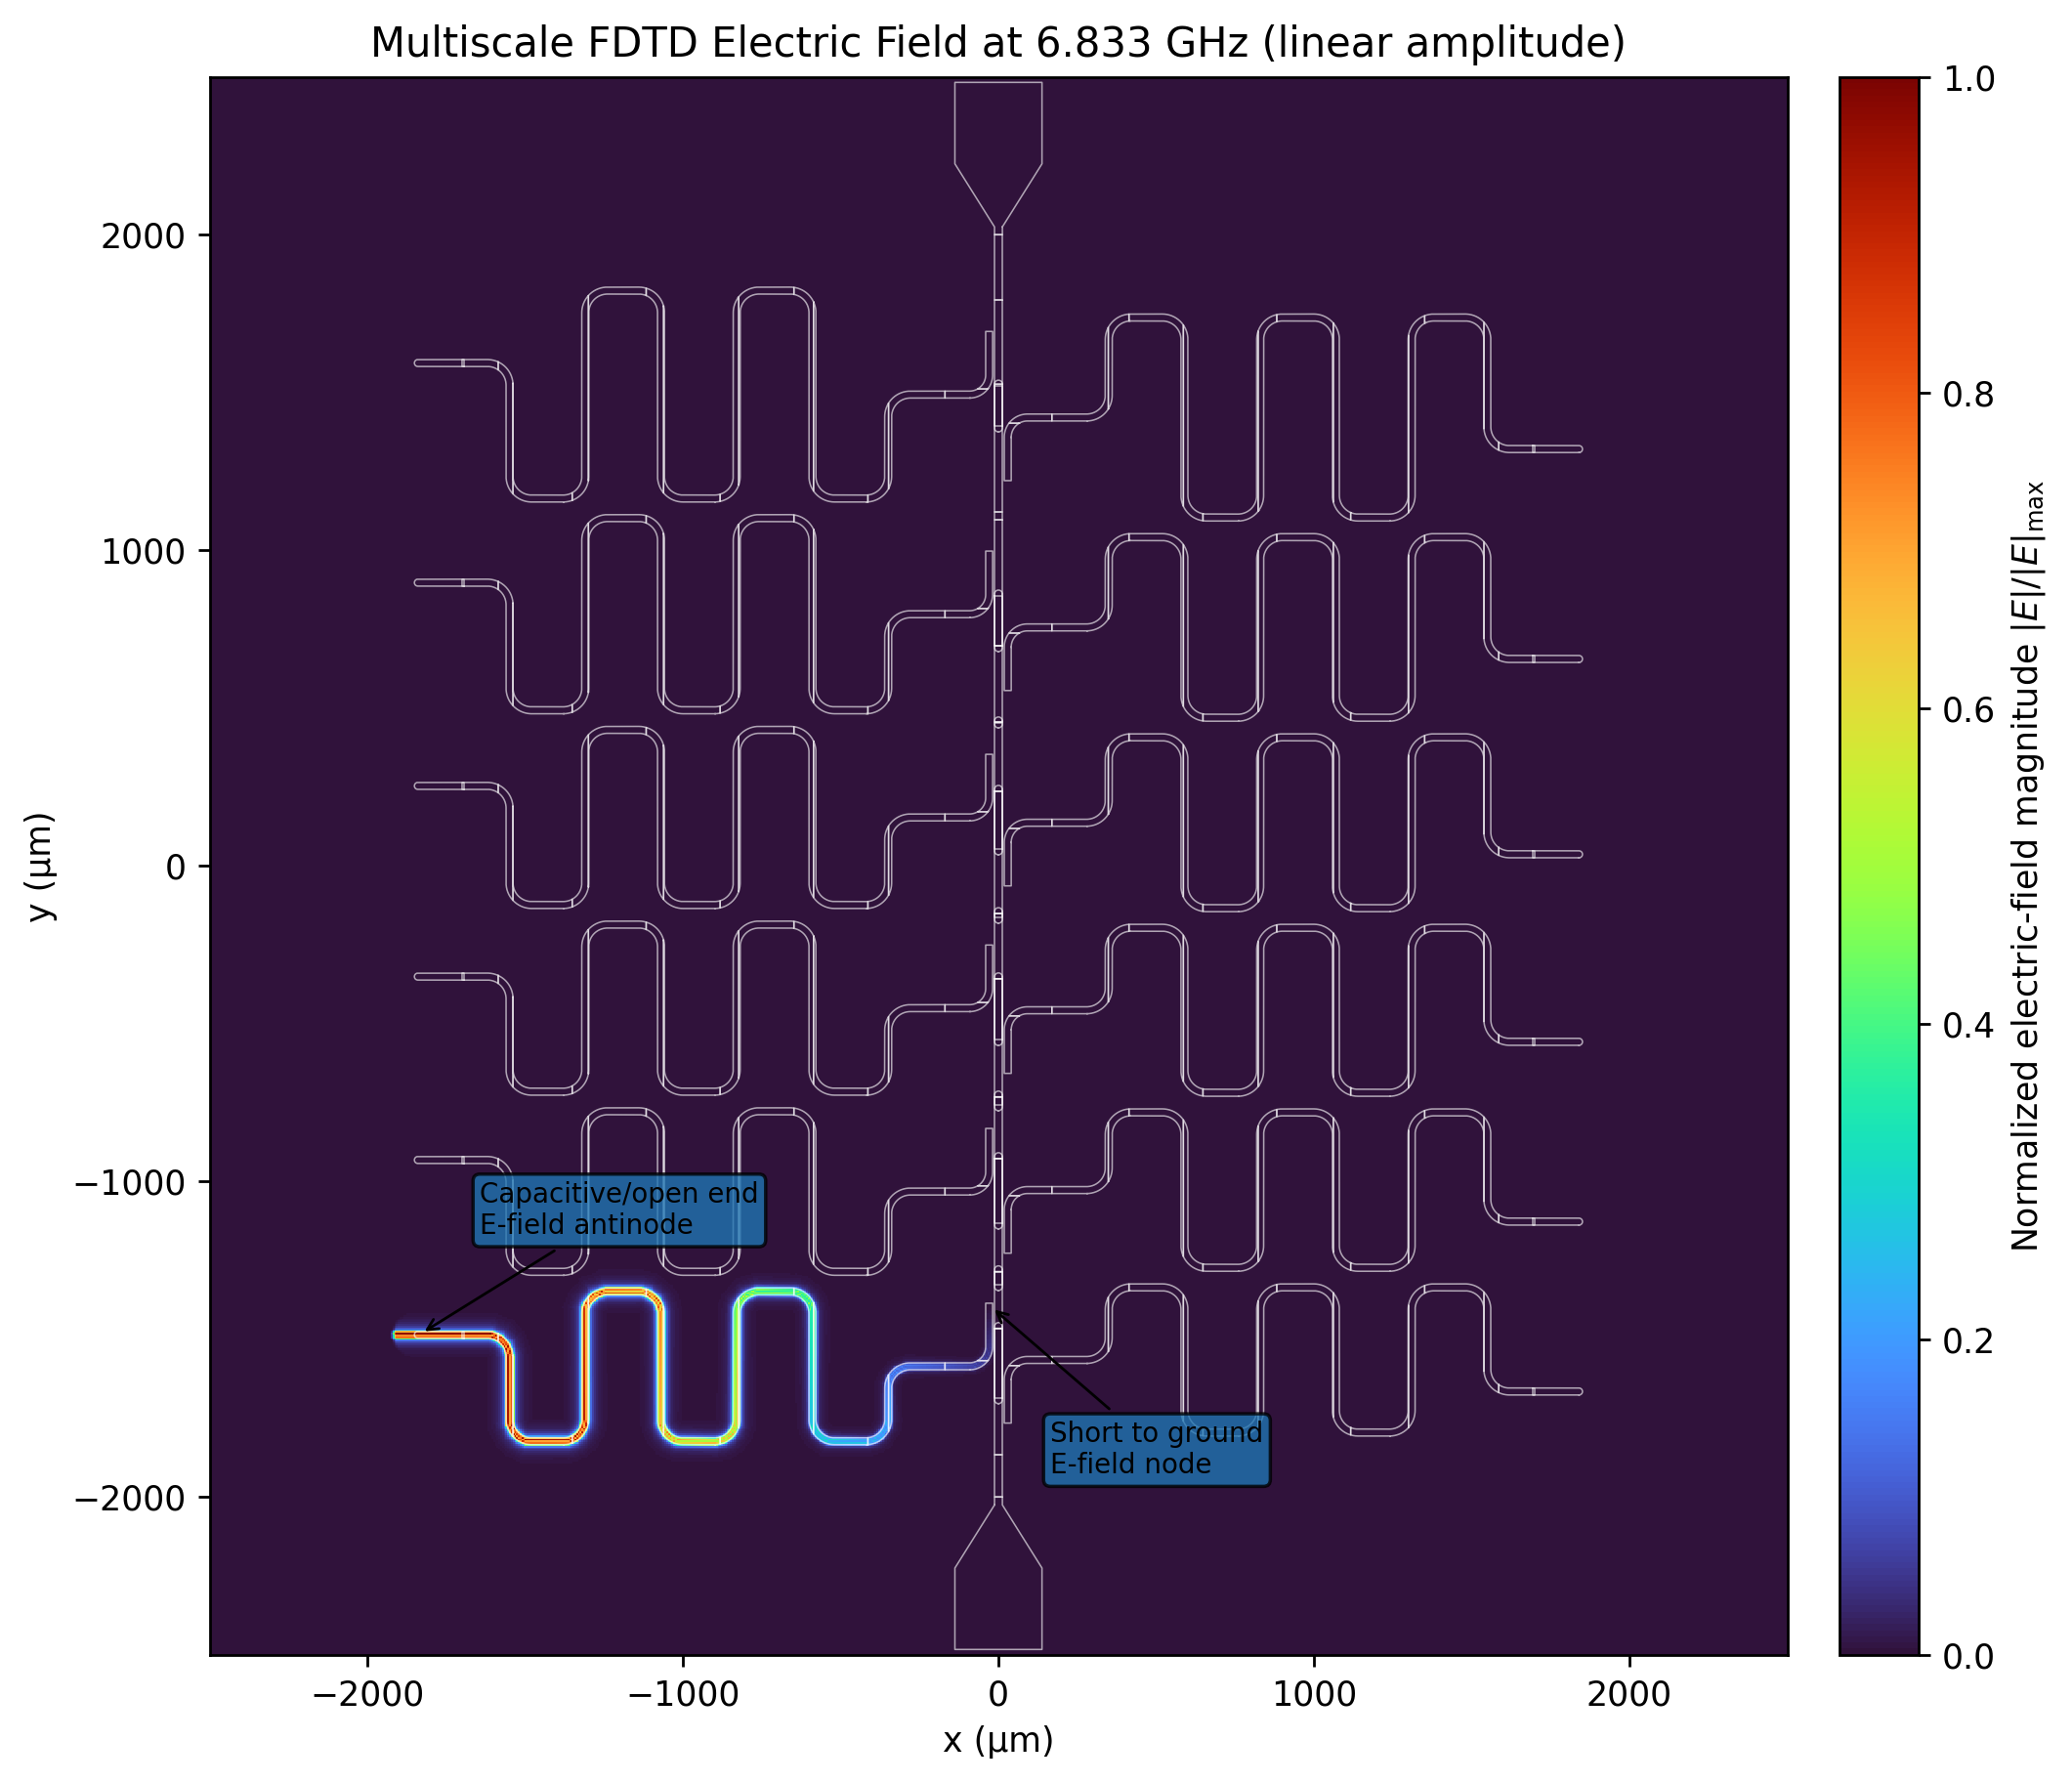


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -53.183 to -0.232
  arrows                      : 563
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 9.43 degrees

Snapshot 11/11: R11 at 6.955811 GHz
Graph-FDTD phasor accumulation: 0.191 s on NVIDIA L4


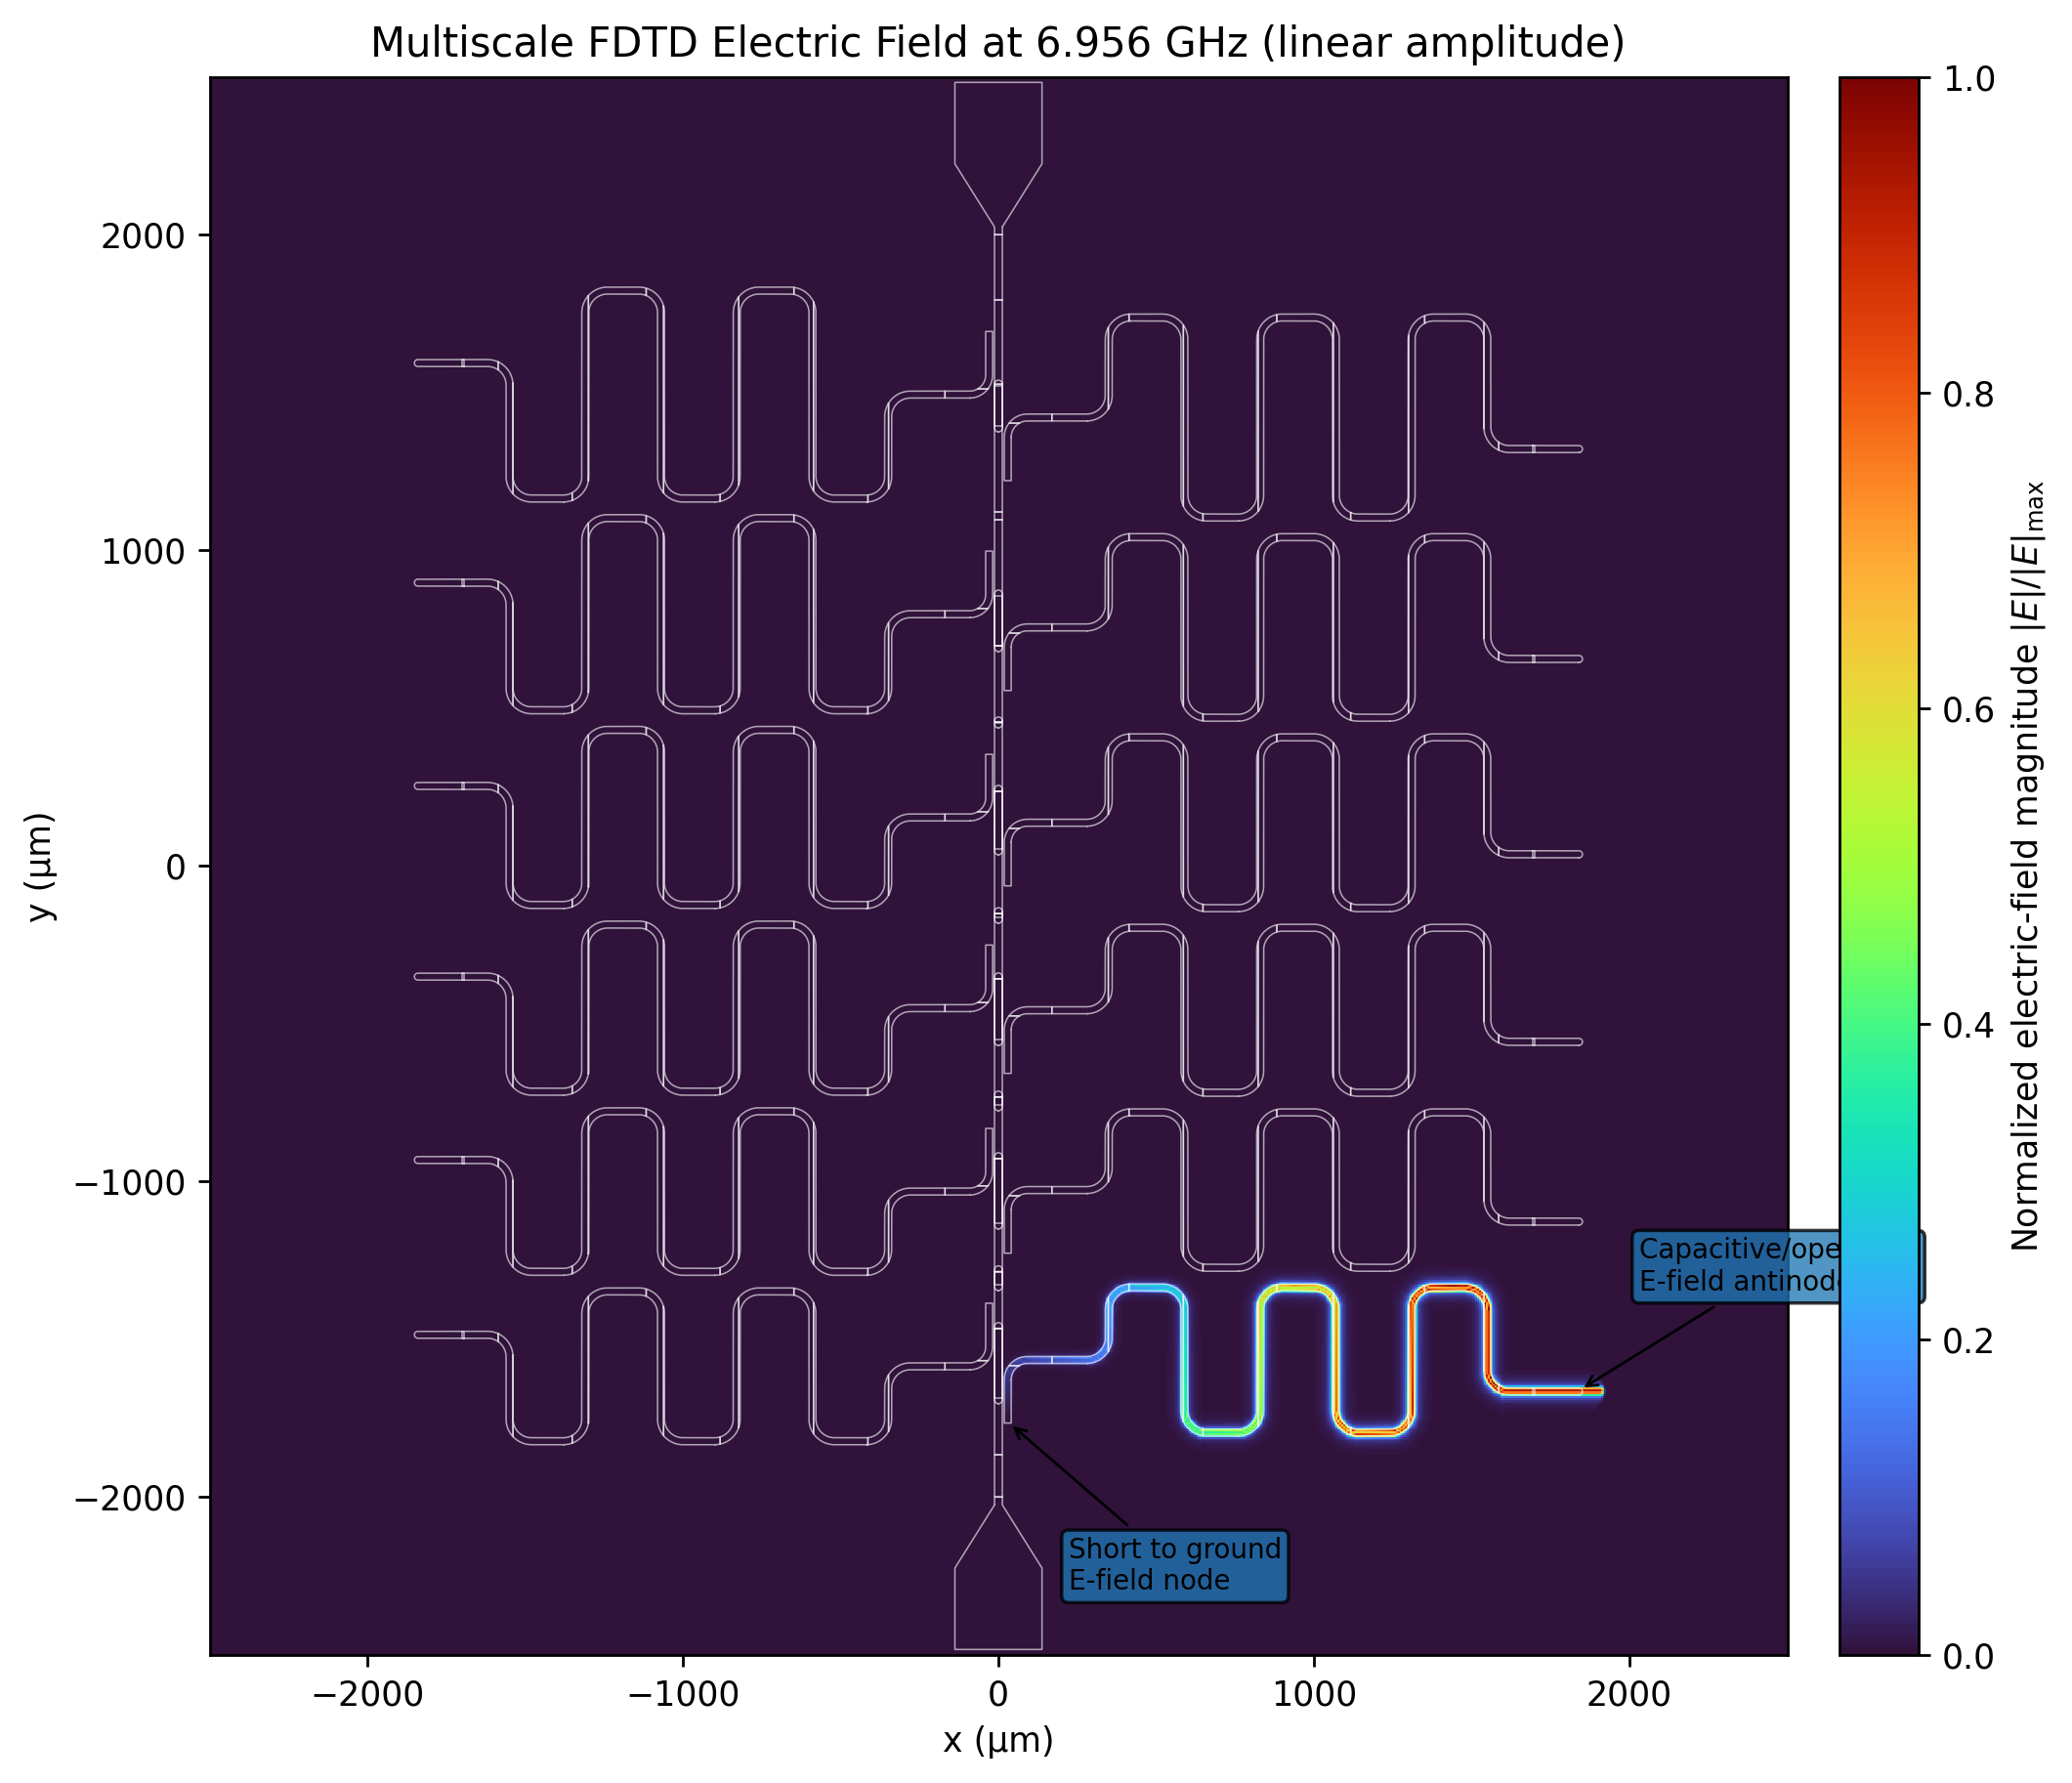


K3D electric-vector field
  glyph mode                  : closed_mesh
  vector color mode           : magnitude_db
  vector color scalar         : Normalized electric-field magnitude (dB)
  vector scalar range         : -48.496 to -0.515
  arrows                      : 569
  browser heatmap grid        : 448 × 448
  z layers                    : (2.0, 5.3, 12.0, 25.0)
  RF display phase            : 8.98 degrees

Detected resonance snapshot table


,resonator,layout_target_ghz,fdtd_discovered_ghz,fdtd_selected_ghz,model_resonance_ghz,sweep_peak_ghz,prominence_db,detection_source,peak_to_median,Qi,Qc,Ql,linewidth_khz,notch_min_db,heatmap_path,k3d_html_path,touchstone_path
0,R2,5.965000,5.863282,5.863282,5.718183,5.718183,7.1033,global S21 notch + local refinement,5506425.12,"740,845","585,416","327,011",17.486,-7.1033,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R02_5p718183GHz/electric_field_mode_gpu_fdtd.png,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R02_5p718183GHz/electric_field_mode_gpu_fdtd_k3d.html,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R02_5p718183GHz/predicted_hanger_resonator_R2_Nb.s2p
1,R3,6.116000,6.019851,6.019851,5.870877,5.870877,6.2714,global S21 notch + local refinement,5412628.11,"742,416","701,330","360,644",16.279,-6.2714,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R03_5p870877GHz/electric_field_mode_gpu_fdtd.png,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R03_5p870877GHz/electric_field_mode_gpu_fdtd_k3d.html,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R03_5p870877GHz/predicted_hanger_resonator_R3_Nb.s2p
2,R4,6.353000,6.256652,6.256652,6.101818,6.101818,7.7798,global S21 notch + local refinement,5485539.56,"744,654","513,908","304,064",20.068,-7.7798,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R04_6p101818GHz/electric_field_mode_gpu_fdtd.png,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R04_6p101818GHz/electric_field_mode_gpu_fdtd_k3d.html,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R04_6p101818GHz/predicted_hanger_resonator_R4_Nb.s2p
3,R6,6.568000,6.380282,6.380282,6.222389,6.222389,7.0674,global S21 notch + local refinement,4830329.37,"745,762","593,681","330,544",18.825,-7.0674,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R06_6p222389GHz/electric_field_mode_gpu_fdtd.png,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R06_6p222389GHz/electric_field_mode_gpu_fdtd_k3d.html,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R06_6p222389GHz/predicted_hanger_resonator_R6_Nb.s2p
4,R5,6.472000,6.474777,6.474777,6.314545,6.314545,8.1550,global S21 notch + local refinement,5924059.61,"746,581","479,466","291,963",21.628,-8.1550,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R05_6p314545GHz/electric_field_mode_gpu_fdtd.png,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R05_6p314545GHz/electric_field_mode_gpu_fdtd_k3d.html,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R05_6p314545GHz/predicted_hanger_resonator_R5_Nb.s2p
5,R8,6.704000,6.567957,6.567957,6.405419,6.405419,7.1218,global S21 notch + local refinement,5145920.25,"747,369","588,321","329,188",19.458,-7.1218,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R08_6p405419GHz/electric_field_mode_gpu_fdtd.png,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R08_6p405419GHz/electric_field_mode_gpu_fdtd_k3d.html,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R08_6p405419GHz/predicted_hanger_resonator_R8_Nb.s2p
6,R7,6.655000,6.617414,6.617414,6.453652,6.453652,8.1346,global S21 notch + local refinement,5838163.88,"747,778","482,095","293,120",22.017,-8.1346,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R07_6p453652GHz/electric_field_mode_gpu_fdtd.png,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R07_6p453652GHz/electric_field_mode_gpu_fdtd_k3d.html,/content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/R07_6p453652GHz/predicted_hanger_resonator_R7_Nb.s2p
7,R10,6.940000,6.726488,6.726488,6.560028,6.560028,7.6125,global S21 notch + local refinement,4448186.92,"748,661","533,889","311,646",21.050,-7.61


K3D resonance snapshot viewers
  R02_5p718183GHz/electric_field_mode_gpu_fdtd_k3d.html


  R03_5p870877GHz/electric_field_mode_gpu_fdtd_k3d.html


  R04_6p101818GHz/electric_field_mode_gpu_fdtd_k3d.html


...

  R10_6p560028GHz/electric_field_mode_gpu_fdtd_k3d.html


  R09_6p688081GHz/electric_field_mode_gpu_fdtd_k3d.html


  R12_6p832933GHz/electric_field_mode_gpu_fdtd_k3d.html


  R11_6p955811GHz/electric_field_mode_gpu_fdtd_k3d.html



Array sweep artifacts
  Composite S21              : /content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/array_frequency_sweep_s21.png
  Resonance table CSV        : /content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/detected_resonances.csv
  Snapshot gallery           : /content/gpu_fdtd_cpw_fundamental_mode/frequency_sweep_5.600_7.600_GHz/resonance_snapshot_gallery.html
  Heatmap snapshots          : 11
  K3D snapshots              : 11


In [5]:
"""Solve an exported Quantum Metal CPW resonator GDS with CuPy and scikit-rf.

Run this cell after the Quantum Metal layout cell has written ``OUTPUT_GDS_PATH``.
The GDS file is the authoritative spatial source. The solver reads the configured
metal and subtract datatypes, separates the feedline and resonator geometry,
extracts centerlines with an adaptive CUDA/CPU skeletonization stage, measures CPW
dimensions from GDS cross sections, and adapts the multiscale solver to the recovered
layout.

The numerical workflow follows the reference multiscale solver architecture:

1. A nearest-neighbor graph FDTD solve advances the longitudinal quasi-TEM
   voltage/current state in a CUDA kernel and discovers the fundamental resonance.
2. An adaptive transverse electrostatic solve extracts C', epsilon_eff, phase velocity,
   and Z0 from physical and vacuum CPW cross sections measured from the GDS.
3. An exact structured path-graph eigenspectrum independently checks the fundamental.
4. An optional CUDA/NumPy Metropolis-Hastings layer calibrates a reduced-order
   resonance
   surrogate only when an observed frequency is supplied or explicitly enabled.
5. A complex electric-field phasor is reconstructed across the complete chip from
   the GDS-extracted resonator centerline and the solved transverse field.
6. scikit-rf produces a complex two-port hanger S21 model, diagnostic plots, and
   an optional Touchstone file using GDS-derived coupling geometry.
7. K3D renders a full-chip heatmap plane plus magnitude-gradient vector arrows at
   several z layers, with arrow x-y locations filtered to the physical GDS CPW gaps.

The GDS determines all planar dimensions used by the electromagnetic model. The
substrate dielectric constant, superconducting material parameters, temperature,
and boundary-condition interpretation remain physical control knobs because those
quantities are absent from a standard GDS file.
"""

from __future__ import annotations

import ctypes.util
import heapq
import importlib.metadata as importlib_metadata
import math
import shutil
import socket
import subprocess
import threading
import time
import warnings
from contextlib import nullcontext
from dataclasses import dataclass, replace
from functools import partial
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path
from typing import Any, Final, Iterable
from urllib.parse import quote

_CUPY_IMPORT_ERROR: Exception | None = None
try:
    import cupy as cp
except Exception as error:
    cp = None
    _CUPY_IMPORT_ERROR = error

import gdstk
import k3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import ndimage as scipy_ndimage
from scipy import special as scipy_special
from scipy.signal import find_peaks
from scipy.spatial import cKDTree

try:
    from shapely import contains_xy
except ImportError:
    from shapely.vectorized import contains as contains_xy
from shapely.geometry import GeometryCollection
from shapely.geometry import LineString
from shapely.geometry import MultiPolygon
from shapely.geometry import Point
from shapely.geometry import Polygon as ShapelyPolygon
from shapely.ops import unary_union

try:
    import skrf as rf
except ImportError as error:
    raise ImportError(
        "scikit-rf is required for the S-parameter stage. In Colab, run "
        "`!uv pip install -q scikit-rf` before this cell."
    ) from error

from IPython.display import IFrame, display
from k3d.colormaps import matplotlib_color_maps
from k3d.helpers import map_colors


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

# Select one GDS-extracted resonator from the imported layout. Numbering is
# one-based to match the R1, R2, ... labels printed by the layout cell. If the
# layout contains exactly one resonator, R1 is selected automatically.
RESONATOR_NUMBER_TO_SOLVE: Final[int] = 1

# Array-frequency-sweep controls. In array mode the GDS is imported once, every
# recovered resonator is screened against the global sweep, and each detected
# in-band resonance receives an independent field snapshot.
ENABLE_ARRAY_FREQUENCY_SWEEP: Final[bool] = True
FREQUENCY_SWEEP_START_GHZ: Final[float] = 5.6
FREQUENCY_SWEEP_STOP_GHZ: Final[float] = 7.6
FREQUENCY_SWEEP_POINTS: Final[int] = 200_001
FREQUENCY_SWEEP_PEAK_PROMINENCE_DB: Final[float] = 0.010
FREQUENCY_SWEEP_MIN_PEAK_SEPARATION_MHZ: Final[float] = 8.0
FREQUENCY_SWEEP_MATCH_TOLERANCE_MHZ: Final[float] = 30.0
FREQUENCY_SWEEP_LOCAL_SEARCH_MHZ: Final[float] = 20.0
FREQUENCY_SWEEP_LOCAL_REFINEMENT_POINTS: Final[int] = 4001
FREQUENCY_SWEEP_MIN_LOCAL_DEPTH_DB: Final[float] = 0.002
FREQUENCY_SWEEP_MAX_SNAPSHOTS: Final[int | None] = None
FREQUENCY_SWEEP_CAPTURE_HEATMAPS: Final[bool] = True
FREQUENCY_SWEEP_CAPTURE_K3D: Final[bool] = True
FREQUENCY_SWEEP_DISPLAY_K3D_VIEWERS: Final[bool] = True
FREQUENCY_SWEEP_RENDER_AUXILIARY_DIAGNOSTICS: Final[bool] = False
FREQUENCY_SWEEP_RUN_CONVERGENCE_STUDIES: Final[bool] = False
FREQUENCY_SWEEP_SAVE_PER_RESONATOR_TOUCHSTONE: Final[bool] = True
FREQUENCY_SWEEP_REUSE_TRANSVERSE_CALIBRATION: Final[bool] = True
FREQUENCY_SWEEP_CROSS_SECTION_CACHE_TOLERANCE_UM: Final[float] = 0.02
FREQUENCY_SWEEP_RELEASE_FIELD_AFTER_SNAPSHOT: Final[bool] = True
FREQUENCY_SWEEP_USE_CUPY_RESPONSE: Final[bool] = True
FREQUENCY_SWEEP_SHOW_RESPONSE_PLOT: Final[bool] = True
FREQUENCY_SWEEP_SHOW_RESONANCE_TABLE: Final[bool] = True

# Compute-backend controls. ``auto`` prefers CUDA and falls back to a complete
# NumPy/SciPy implementation if the active notebook has no usable CUDA runtime.
# Set ``cuda`` to make a broken GPU environment fatal, or ``cpu`` to bypass CUDA.
COMPUTE_BACKEND: Final[str] = "auto"
VALID_COMPUTE_BACKENDS: Final[tuple[str, ...]] = ("auto", "cuda", "cpu")
ALLOW_CPU_FALLBACK: Final[bool] = True
CPU_FALLBACK_NEAREST_SEGMENT_CANDIDATES: Final[int] = 8
CPU_FALLBACK_NEAREST_PATH_CHUNK_POINTS: Final[int] = 100_000


# The exported Quantum Metal GDS is the sole planar geometry source.
GDS_PATH: Final[Path] = Path(
    globals().get(
        "OUTPUT_GDS_PATH",
        "/content/resonator_feedline_cheesing_quantum_metal.gds",
    )
)
GDS_METAL_LAYER: Final[int] = int(globals().get("METAL_LAYER", 3))
GDS_NORMAL_DATATYPE: Final[int] = int(globals().get("NORMAL_DATATYPE", 0))
GDS_SUBTRACT_DATATYPE: Final[int] = int(
    globals().get("SUBTRACT_DATATYPE", 1)
)
GDS_ANTIDOT_SIZE_UM: Final[float] = float(
    globals().get("ANTIDOT_SIZE_UM", 2.0)
)
GDS_EXPECTED_FEEDLINE_X_UM: Final[float] = 0.0
GDS_NATIVE_CUT_METAL_OVERLAP_THRESHOLD: Final[float] = 0.02
GDS_MIN_RESONATOR_METAL_AREA_UM2: Final[float] = 2_000.0
GDS_MIN_RESONATOR_SPAN_UM: Final[float] = 450.0
GDS_MAX_RESONATORS: Final[int] = max(
    16,
    int(globals().get("DESIRED_RESONATOR_COUNT", 16)),
)

# Adaptive centerline recovery and GDS dimensional metrology.
GDS_CENTERLINE_RASTER_UM: Final[float] = 2.0
GDS_CENTERLINE_SIMPLIFY_UM: Final[float] = 2.5
GDS_CENTERLINE_RESAMPLE_UM: Final[float] = 4.0
GDS_CENTERLINE_THINNING_MAX_ITERATIONS: Final[int] = 512
GDS_CENTERLINE_MORPHOLOGICAL_CLOSING: Final[bool] = True
GDS_CENTERLINE_CLOSING_RADIUS_PIXELS: Final[int] = 1
GDS_CENTERLINE_CLOSING_ITERATIONS: Final[int] = 1
GDS_WIDTH_SAMPLE_COUNT: Final[int] = 180
GDS_CROSS_SECTION_PROBE_HALF_LENGTH_UM: Final[float] = 80.0
GDS_RESONATOR_WIDTH_QUANTILE: Final[float] = 0.30
GDS_FEEDLINE_WIDTH_QUANTILE: Final[float] = 0.15

# Connected-metal recovery handles exporters that numerically bridge a tee.
GDS_CONNECTED_SPLIT_HALF_WIDTHS_UM: Final[tuple[float, ...]] = (
    10.0,
    14.0,
    18.0,
    24.0,
    32.0,
)
GDS_CONNECTED_SPLIT_SUBTRACT_EPSILON_UM: Final[float] = 0.05

# Coupling length and conductor-edge spacing are measured from the GDS.
GDS_COUPLING_SAMPLE_SPACING_UM: Final[float] = 4.0
GDS_COUPLING_DISTANCE_TOLERANCE_UM: Final[float] = 8.0
GDS_MIN_COUPLING_LENGTH_UM: Final[float] = 20.0
GDS_MIN_COUPLING_SPACE_UM: Final[float] = 0.5

SHOW_GDS_INPUT_PREVIEW: Final[bool] = True
GDS_INPUT_PREVIEW_SHOW_ANTIDOTS: Final[bool] = True
K3D_FILTER_ARROWS_TO_GDS_GAPS: Final[bool] = True

OUTPUT_DIRECTORY_ROOT: Final[Path] = Path(
    "/content/gpu_fdtd_cpw_fundamental_mode"
)
SWEEP_OUTPUT_DIRECTORY: Final[Path] = (
    OUTPUT_DIRECTORY_ROOT
    / f"frequency_sweep_{FREQUENCY_SWEEP_START_GHZ:.3f}_"
    f"{FREQUENCY_SWEEP_STOP_GHZ:.3f}_GHz"
)
SWEEP_S21_PATH: Final[Path] = SWEEP_OUTPUT_DIRECTORY / "array_frequency_sweep_s21.png"
SWEEP_RESONANCE_TABLE_PATH: Final[Path] = (
    SWEEP_OUTPUT_DIRECTORY / "detected_resonances.csv"
)
SWEEP_GALLERY_PATH: Final[Path] = (
    SWEEP_OUTPUT_DIRECTORY / "resonance_snapshot_gallery.html"
)
S21_TOUCHSTONE_STEM: Final[str] = "predicted_hanger_resonator"

# These paths are intentionally mutable. Array mode changes their output context
# before each resonator snapshot so the existing rendering functions can be
# reused without duplicating their scientific visualization logic.
OUTPUT_DIRECTORY = OUTPUT_DIRECTORY_ROOT / f"resonator_{RESONATOR_NUMBER_TO_SOLVE:02d}"
HEATMAP_PATH = OUTPUT_DIRECTORY / "electric_field_mode_gpu_fdtd.png"
K3D_HTML_PATH = OUTPUT_DIRECTORY / "electric_field_mode_gpu_fdtd_k3d.html"
LONGITUDINAL_AMPLITUDE_PATH = (
    OUTPUT_DIRECTORY / "longitudinal_standing_wave_amplitude.png"
)
LONGITUDINAL_PHASE_PATH = OUTPUT_DIRECTORY / "longitudinal_standing_wave_phase.png"
GRAPH_CONVERGENCE_PATH = OUTPUT_DIRECTORY / "graph_frequency_convergence.png"
TRANSVERSE_EPS_CONVERGENCE_PATH = (
    OUTPUT_DIRECTORY / "transverse_effective_permittivity_convergence.png"
)
TRANSVERSE_Z0_CONVERGENCE_PATH = (
    OUTPUT_DIRECTORY / "transverse_impedance_convergence.png"
)
S21_MAGNITUDE_PATH = OUTPUT_DIRECTORY / "s21_notch_magnitude.png"
S21_PHASE_PATH = OUTPUT_DIRECTORY / "s21_notch_phase.png"
FDTD_SPECTRUM_PATH = OUTPUT_DIRECTORY / "graph_fdtd_resonance_spectrum.png"
CROSS_SECTION_FIELD_PATH = OUTPUT_DIRECTORY / "cpw_cross_section_electric_field.png"
GDS_INPUT_PREVIEW_PATH = OUTPUT_DIRECTORY / "imported_quantum_metal_gds.png"


def set_output_directory(directory: Path) -> None:
    """Redirect all single-resonator artifact paths to one directory."""
    global OUTPUT_DIRECTORY
    global HEATMAP_PATH
    global K3D_HTML_PATH
    global LONGITUDINAL_AMPLITUDE_PATH
    global LONGITUDINAL_PHASE_PATH
    global GRAPH_CONVERGENCE_PATH
    global TRANSVERSE_EPS_CONVERGENCE_PATH
    global TRANSVERSE_Z0_CONVERGENCE_PATH
    global S21_MAGNITUDE_PATH
    global S21_PHASE_PATH
    global FDTD_SPECTRUM_PATH
    global CROSS_SECTION_FIELD_PATH
    global GDS_INPUT_PREVIEW_PATH

    OUTPUT_DIRECTORY = Path(directory)
    HEATMAP_PATH = OUTPUT_DIRECTORY / "electric_field_mode_gpu_fdtd.png"
    K3D_HTML_PATH = OUTPUT_DIRECTORY / "electric_field_mode_gpu_fdtd_k3d.html"
    LONGITUDINAL_AMPLITUDE_PATH = (
        OUTPUT_DIRECTORY / "longitudinal_standing_wave_amplitude.png"
    )
    LONGITUDINAL_PHASE_PATH = (
        OUTPUT_DIRECTORY / "longitudinal_standing_wave_phase.png"
    )
    GRAPH_CONVERGENCE_PATH = OUTPUT_DIRECTORY / "graph_frequency_convergence.png"
    TRANSVERSE_EPS_CONVERGENCE_PATH = (
        OUTPUT_DIRECTORY / "transverse_effective_permittivity_convergence.png"
    )
    TRANSVERSE_Z0_CONVERGENCE_PATH = (
        OUTPUT_DIRECTORY / "transverse_impedance_convergence.png"
    )
    S21_MAGNITUDE_PATH = OUTPUT_DIRECTORY / "s21_notch_magnitude.png"
    S21_PHASE_PATH = OUTPUT_DIRECTORY / "s21_notch_phase.png"
    FDTD_SPECTRUM_PATH = OUTPUT_DIRECTORY / "graph_fdtd_resonance_spectrum.png"
    CROSS_SECTION_FIELD_PATH = OUTPUT_DIRECTORY / "cpw_cross_section_electric_field.png"
    GDS_INPUT_PREVIEW_PATH = OUTPUT_DIRECTORY / "imported_quantum_metal_gds.png"


def frequency_filename_tag(frequency_ghz: float) -> str:
    """Return a filesystem-safe GHz tag for one resonance snapshot."""
    return f"{float(frequency_ghz):.6f}".replace(".", "p") + "GHz"


def configure_resonator_output_context(
    resonator_number: int,
    frequency_ghz: float,
) -> Path:
    """Select a unique artifact directory for one resonator peak."""
    directory = SWEEP_OUTPUT_DIRECTORY / (
        f"R{int(resonator_number):02d}_{frequency_filename_tag(frequency_ghz)}"
    )
    set_output_directory(directory)
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    return directory


# Automatic planning is the default. The currently implemented backend is the
# multiscale quasi-TEM graph-FDTD solver selected for this CPW regime.
SOLVER_MODE: Final[str] = "auto"
VALID_SOLVER_MODES: Final[tuple[str, ...]] = (
    "auto",
    "graph_tem_gpu",
)

# Set any of these to a number to override the automatic planner.
FORCE_MODE_FREQUENCY_GHZ: Final[float | None] = None
FORCE_GRAPH_NODES: Final[int | None] = None
FORCE_LOADED_Q: Final[float | None] = None
FORCE_FIELD_GRID_NX: Final[int | None] = None
FORCE_FIELD_GRID_NY: Final[int | None] = None
FORCE_CROSS_SECTION_NU: Final[int | None] = None
FORCE_CROSS_SECTION_NZ: Final[int | None] = None

DEFAULT_TARGET_FREQUENCY_GHZ: Final[float] = 6.45

SUBSTRATE_EPS_R: Final[float] = 11.45
USE_LAYOUT_PHASE_VELOCITY: Final[bool] = True
PHASE_VELOCITY_OVERRIDE_M_PER_S: Final[float | None] = None

# Quasi-TEM calibration and scientific diagnostics.
#
# The physical and vacuum cross-sections are solved on the same grid. Their
# capacitance ratio gives epsilon_eff = C / C0, which provides a numerical phase
# velocity independent of the initial half-space estimate used by the planner.
USE_TRANSVERSE_QTEM_PHASE_VELOCITY: Final[bool] = True
RUN_GRAPH_CONVERGENCE_STUDY: Final[bool] = True
GRAPH_CONVERGENCE_NODES: Final[tuple[int, ...]] = (
    96,
    128,
    192,
    256,
    384,
    512,
    768,
)
RUN_TRANSVERSE_CONVERGENCE_STUDY: Final[bool] = True
TRANSVERSE_CONVERGENCE_GRID_SIZES: Final[tuple[int, ...]] = (
    129,
    193,
    257,
    321,
)
STANDING_WAVE_PHASE_MASK_FRACTION: Final[float] = 0.05

SHOW_FDTD_SPECTRUM_PLOT: Final[bool] = True
SHOW_CROSS_SECTION_FIELD_PLOT: Final[bool] = True

# Graph-FDTD controls.
GRAPH_CFL: Final[float] = 0.92
GRAPH_MIN_NODES: Final[int] = 128
GRAPH_MAX_NODES: Final[int] = 768
GRAPH_TARGET_NODES_PER_GUIDED_WAVELENGTH: Final[int] = 140
GRAPH_MIN_NODES_PER_GEOMETRIC_SEGMENT: Final[int] = 12

DISCOVERY_CYCLES: Final[float] = 42.0
DISCOVERY_SEARCH_MIN_RATIO: Final[float] = 0.55
DISCOVERY_SEARCH_MAX_RATIO: Final[float] = 1.45
DISCOVERY_ZERO_PAD_FACTOR: Final[int] = 8
DISCOVERY_MIN_PEAK_TO_MEDIAN: Final[float] = 8.0

DRIVE_WARMUP_CYCLES: Final[float] = 22.0
DRIVE_RINGUP_TIME_CONSTANTS: Final[float] = 2.5
DRIVE_MAX_WARMUP_CYCLES: Final[float] = 180.0
DRIVE_ACCUMULATION_CYCLES: Final[float] = 12.0
DRIVE_SOURCE_AMPLITUDE: Final[float] = 0.05
DISCOVERY_SOURCE_AMPLITUDE: Final[float] = 0.10

# Place the voltage source away from a forced voltage node. A source only a few
# graph cells from a short can contaminate the driven spatial phasor before the
# resonator has fully rung up.
GRAPH_SOURCE_FRACTION_SHORT_OPEN: Final[float] = 0.70
GRAPH_SOURCE_FRACTION_OPEN_OPEN: Final[float] = 0.25
GRAPH_SOURCE_FRACTION_SHORT_SHORT: Final[float] = 0.50

# ``adaptive_projection`` keeps the raw graph-FDTD phasor whenever it already
# follows the fundamental eigenfunction, then removes residual source/ring-up
# contamination only as needed. The physical E-field node at a grounded short
# is preserved.
MODE_SHAPE_STABILIZATION: Final[str] = "adaptive_projection"
VALID_MODE_SHAPE_STABILIZATION: Final[tuple[str, ...]] = (
    "raw_fdtd",
    "adaptive_projection",
    "modal_projection",
)
MODE_SHAPE_TARGET_CORRELATION: Final[float] = 0.995
MODE_SHAPE_FULL_PROJECTION_CORRELATION: Final[float] = 0.92

# Cross-sectional finite-difference electrostatic solve.
CROSS_SECTION_CELLS_PER_GAP: Final[float] = 7.0
CROSS_SECTION_HALF_SPAN_FACTOR: Final[float] = 8.0
CROSS_SECTION_MIN_HALF_SPAN_UM: Final[float] = 90.0
CROSS_SECTION_AIR_HEIGHT_FACTOR: Final[float] = 8.0
CROSS_SECTION_SUBSTRATE_DEPTH_FACTOR: Final[float] = 8.0
CROSS_SECTION_MIN_VERTICAL_SPAN_UM: Final[float] = 90.0
CROSS_SECTION_MIN_NU: Final[int] = 129
CROSS_SECTION_MAX_NU: Final[int] = 321
CROSS_SECTION_MIN_NZ: Final[int] = 129
CROSS_SECTION_MAX_NZ: Final[int] = 321
CROSS_SECTION_SOR_OMEGA: Final[float] = 1.84
CROSS_SECTION_MIN_ITERATIONS: Final[int] = 900
CROSS_SECTION_MAX_ITERATIONS: Final[int] = 2600

# Sparse GPU linear-algebra controls.
#
# ``auto`` uses sparse matrices only for the transverse electrostatic solve
# after the problem is large enough to justify CSR assembly. The longitudinal
# path-graph eigenfrequency uses its exact discrete closed form and never needs
# cuBLAS. If optional CuPy sparse linear algebra cannot load, ``auto`` and ``on``
# fall back to the RawKernel red-black SOR solver unless strict mode is enabled.
SPARSE_MATRIX_MODE: Final[str] = "auto"
SPARSE_CUDA_STRICT: Final[bool] = False
RUN_CUDA_STARTUP_RAWKERNEL_PROBE: Final[bool] = True
CUDA_DIAGNOSTIC_QUERY_NVIDIA_SMI: Final[bool] = True
CUDA_DIAGNOSTIC_QUERY_NVCC: Final[bool] = True
CUDA_DIAGNOSTIC_COMMAND_TIMEOUT_S: Final[float] = 5.0
VALID_SPARSE_MATRIX_MODES: Final[tuple[str, ...]] = (
    "auto",
    "on",
    "off",
)
SPARSE_ADJACENCY_MIN_NODES: Final[int] = 320
SPARSE_CROSS_SECTION_MIN_UNKNOWNS: Final[int] = 8_000
SPARSE_MAX_GPU_MEMORY_FRACTION: Final[float] = 0.15
SPARSE_EIGSH_TOLERANCE: Final[float] = 1.0e-10
SPARSE_CG_USE_FLOAT64: Final[bool] = True
SPARSE_CG_RTOL: Final[float] = 1.0e-9
SPARSE_CG_ATOL: Final[float] = 0.0
SPARSE_CG_MAX_ITERATIONS: Final[int] = 3_000
SPARSE_CG_FALLBACK_TO_SOR: Final[bool] = True

# GPU Metropolis-Hastings calibration controls.
#
# The MCMC layer is a reduced-order calibration/uncertainty calculation. It
# does not replace FDTD or the transverse field solve. In ``auto`` mode it is
# enabled only when an external measured frequency is supplied. Reusing the
# deterministic result as its own observation is disabled by default because it
# does not provide independent uncertainty information.
MCMC_MODE: Final[str] = "auto"
VALID_MCMC_MODES: Final[tuple[str, ...]] = (
    "auto",
    "on",
    "off",
)
MCMC_OBSERVED_FREQUENCY_GHZ: Final[float | None] = None
MCMC_USE_NUMERICAL_FREQUENCY_AS_OBSERVATION: Final[bool] = False
MCMC_CHAINS: Final[int] = 64
MCMC_STEPS: Final[int] = 320
MCMC_BURN_IN: Final[int] = 96
MCMC_THIN: Final[int] = 2
MCMC_RANDOM_SEED: Final[int] = 20260824
MCMC_PHASE_VELOCITY_PRIOR_SIGMA: Final[float] = 0.020
MCMC_LENGTH_PRIOR_SIGMA: Final[float] = 0.0035
MCMC_PROPOSAL_SIGMA_PHASE_VELOCITY: Final[float] = 0.0030
MCMC_PROPOSAL_SIGMA_LENGTH: Final[float] = 0.0012
MCMC_MIN_OBSERVATION_SIGMA_MHZ: Final[float] = 8.0
MCMC_LINEWIDTH_SIGMA_FRACTION: Final[float] = 0.25

# Reconstructed field-grid controls.
#
# ``chip`` evaluates the reconstructed mode over the complete lithographic chip
# footprint recovered for the imported Quantum Metal GDS. ``active_region`` keeps
# the earlier resonator-local window for rapid diagnostic runs.
FIELD_DOMAIN_MODE: Final[str] = "chip"
VALID_FIELD_DOMAIN_MODES: Final[tuple[str, ...]] = (
    "chip",
    "active_region",
)
FIELD_CHIP_EDGE_PADDING_UM: Final[float] = 0.0
FIELD_ACTIVE_MARGIN_FACTOR: Final[float] = 5.0
FIELD_ACTIVE_MIN_MARGIN_UM: Final[float] = 90.0

# The full 5 mm × 5 mm chip needs more samples than the earlier local window.
# The planner keeps a finite pixel budget and preserves the square chip extent.
FIELD_TARGET_PIXEL_COUNT: Final[int] = 800_000
FIELD_MIN_AXIS_POINTS: Final[int] = 360
FIELD_MAX_AXIS_POINTS: Final[int] = 900
FIELD_HEIGHT_UM: Final[float] = 2.0
FIELD_DB_FLOOR: Final[float] = -42.0

# The transverse quasi-TEM solution is local to the CPW. A cosine taper based
# on the true Euclidean distance to the resonator path suppresses endpoint
# wedges and prevents clipped cross-section values from leaking across the chip.
FIELD_PATH_SUPPORT_RADIUS_FACTOR: Final[float] = 1.0
FIELD_PATH_TAPER_START_FRACTION: Final[float] = 0.78

# K3D controls.
K3D_BACKGROUND_COLOR: Final[int] = 0xFFFFFF
K3D_GRID_COLOR: Final[int] = 0xD5D5D5
K3D_LABEL_COLOR: Final[int] = 0x303030
K3D_SLOT_OUTLINE_COLOR: Final[int] = 0x404040
K3D_COMPRESSION_LEVEL: Final[int] = 6
K3D_ANTIALIAS_LEVEL: Final[int] = 3
K3D_SCREENSHOT_SCALE: Final[float] = 2.0
K3D_PLOT_HEIGHT: Final[int] = 850
K3D_SHOW_REFERENCE_GRID: Final[bool] = True
K3D_SHOW_AXIS_LABELS: Final[bool] = False
K3D_HEATMAP_OPACITY: Final[float] = 0.72
K3D_HEATMAP_Z_OFFSET_UM: Final[float] = 0.20
K3D_HEATMAP_MAX_AXIS_POINTS: Final[int] = 480
K3D_ARROW_THRESHOLD_DB: Final[float] = -32.0
K3D_MAX_ARROWS: Final[int] = 2_400
K3D_ARROW_MAX_LENGTH_UM: Final[float] = 38.0
K3D_ARROW_MAGNITUDE_EXPONENT: Final[float] = 0.42
K3D_RANDOM_SEED: Final[int] = 20260824
K3D_Z_LAYERS_UM: Final[tuple[float, ...] | None] = None
# Color arrows by normalized field magnitude by default. This restores the
# original Turbo gradient across the vector glyphs. Phase coloring remains an
# optional diagnostic, although a short-open fundamental can have an almost
# uniform longitudinal phase and can consequently appear nearly monochromatic.
K3D_VECTOR_COLOR_MODE: Final[str] = "magnitude_db"
VALID_K3D_VECTOR_COLOR_MODES: Final[tuple[str, ...]] = (
    "phase",
    "magnitude_db",
)
K3D_PHASE_COLOR_RANGE_DEG: Final[tuple[float, float]] = (-180.0, 180.0)

# Vector-glyph controls. ``closed_mesh`` reproduces the successful K3D style
# used in the earlier vector-field notebooks: a watertight cylindrical shaft
# plus an explicit cone with a capped base. ``builtin`` keeps k3d.vectors as a
# lighter browser fallback.
K3D_ARROW_GLYPH_MODE: Final[str] = "closed_mesh"
VALID_K3D_ARROW_GLYPH_MODES: Final[tuple[str, ...]] = (
    "closed_mesh",
    "builtin",
)
K3D_ARROW_LINE_WIDTH: Final[float] = 0.65
K3D_ARROW_HEAD_SIZE: Final[float] = 1.0
K3D_SHAFT_DIAMETER_UM: Final[float] = 1.20
K3D_SHAFT_RADIAL_SEGMENTS: Final[int] = 6
K3D_SHAFT_SHININESS: Final[float] = 28.0
K3D_CONE_LENGTH_MAX_UM: Final[float] = 7.5
K3D_CONE_LENGTH_FRACTION: Final[float] = 0.28
K3D_CONE_RADIUS_UM: Final[float] = 1.55
K3D_CONE_RADIAL_SEGMENTS: Final[int] = 8
K3D_CONE_SHININESS: Final[float] = 35.0
K3D_MIN_RENDER_VECTOR_LENGTH_UM: Final[float] = 0.35
K3D_KEEP_ARROWS_ABOVE_SURFACE: Final[bool] = True
K3D_ARROW_SURFACE_CLEARANCE_UM: Final[float] = 0.75

# Matplotlib controls.
FIGURE_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 7.4
SHOW_LAYOUT_OUTLINES_2D: Final[bool] = True
SHOW_TERMINATION_ANNOTATIONS_2D: Final[bool] = True

# A logarithmic color scale makes the mathematically smooth voltage node at a
# grounded quarter-wave end look visually abrupt. ``linear_amplitude`` is the
# default diagnostic view; ``db`` retains the original dynamic-range plot.
HEATMAP_DISPLAY_SCALE: Final[str] = "linear_amplitude"
VALID_HEATMAP_DISPLAY_SCALES: Final[tuple[str, ...]] = (
    "linear_amplitude",
    "db",
)

# scikit-rf superconducting-material and S21 controls.
ENABLE_SKRF_S21: Final[bool] = True
SUPERCONDUCTOR_MATERIAL: Final[str] = "Nb"
SUPPORTED_SUPERCONDUCTOR_MATERIALS: Final[tuple[str, ...]] = (
    "Nb",
    "Al",
    "NbN",
    "grAl",
    "TiN",
    "MgB2",
    "NbTiN",
    "Ta",
)
SUPERCONDUCTOR_TEMPERATURE_K: Final[float] = 0.020

# None selects the representative library value. These overrides are the main
# calibration hooks for a specific deposition run.
SUPERCONDUCTOR_FILM_THICKNESS_NM: Final[float | None] = None
SUPERCONDUCTOR_TC_OVERRIDE_K: Final[float | None] = None
SUPERCONDUCTOR_RHO_N_OVERRIDE_UOHM_CM: Final[float | None] = None
SUPERCONDUCTOR_GAP_RATIO_OVERRIDE: Final[float | None] = None
SUPERCONDUCTOR_RESIDUAL_RS_OVERRIDE_N_OHM: Final[float | None] = None
S21_INTERNAL_Q_OVERRIDE: Final[float | None] = None
S21_EXTERNAL_Q_OVERRIDE: Final[float | None] = None
S21_COUPLING_CAPACITANCE_OVERRIDE_FF: Final[float | None] = None

# The local transverse solve returns the geometric quasi-TEM line parameters.
# This multiplier maps film sheet kinetic inductance into CPW inductance per
# unit length and absorbs center-strip plus ground-return current crowding.
KINETIC_INDUCTANCE_GEOMETRY_FACTOR: Final[float] = 1.00

# Internal-loss model. The material library supplies a resonator-level prior,
# then conductor and dielectric channels are combined through inverse Q.
S21_DIELECTRIC_LOSS_TANGENT: Final[float] = 2.0e-6
S21_DIELECTRIC_PARTICIPATION: Final[float] = 0.12

# Reduced-order distributed side-coupler model. The mutual-capacitance fraction
# is referenced to the existing layout's conductor-edge coupling gap.
S21_COUPLING_MUTUAL_FRACTION_AT_REFERENCE_GAP: Final[float] = 0.10
S21_COUPLING_REFERENCE_GAP_UM: Final[float] = 6.0
S21_COUPLING_DECAY_UM: Final[float] = 8.0
S21_COUPLING_MIN_MUTUAL_FRACTION: Final[float] = 0.004
S21_COUPLING_MAX_MUTUAL_FRACTION: Final[float] = 0.30

S21_SWEEP_SPAN_MHZ: Final[float] = 120.0
S21_SWEEP_POINTS: Final[int] = 4001
S21_PORT_IMPEDANCE_OHM: Final[float] = 50.0
S21_NOTCH_ASYMMETRY_PHASE_DEG: Final[float] = 0.0
S21_BASELINE_AMPLITUDE_DB: Final[float] = 0.0
S21_BASELINE_PHASE_DEG: Final[float] = 0.0
S21_ELECTRICAL_DELAY_NS: Final[float] = 0.0
S21_SAVE_TOUCHSTONE: Final[bool] = True
S21_SHOW_PHASE_PLOT: Final[bool] = True

# Physical constants.
C_0_M_PER_S: Final[float] = 299_792_458.0
EPSILON_0_F_PER_M: Final[float] = 8.854_187_8128e-12
MU_0_H_PER_M: Final[float] = 1.256_637_062_12e-6
K_B_J_PER_K: Final[float] = 1.380_649e-23
HBAR_J_S: Final[float] = 1.054_571_817e-34


# ------------------------------------------------------------
# OPTIONAL CUDA LIBRARY CAPABILITIES
# ------------------------------------------------------------


class SparseCudaUnavailable(RuntimeError):
    """Signal that optional CuPy sparse linear algebra cannot be loaded."""


_CUPY_SPARSE_IMPORT_ATTEMPTED = False
_CUPY_SPARSE_MODULES: tuple[Any, Any] | None = None
_CUPY_SPARSE_IMPORT_ERROR: Exception | None = None
_CUDA_RUNTIME_STATUS_CACHE: dict[str, object] | None = None
_ACTIVE_COMPUTE_BACKEND = "uninitialized"


def using_cuda_backend() -> bool:
    """Return whether the current execution path is using CuPy CUDA arrays."""
    return _ACTIVE_COMPUTE_BACKEND == "cuda"


def using_cpu_backend() -> bool:
    """Return whether the current execution path is using NumPy/SciPy arrays."""
    return _ACTIVE_COMPUTE_BACKEND == "cpu"


def array_module():
    """Return CuPy for CUDA execution and NumPy for CPU fallback execution."""
    if using_cuda_backend():
        if cp is None:
            raise RuntimeError("CUDA backend selected but CuPy is unavailable.")
        return cp
    return np


def to_numpy_array(value: object) -> np.ndarray:
    """Return a NumPy view/copy for either a CuPy or NumPy array."""
    if cp is not None and isinstance(value, cp.ndarray):
        return cp.asnumpy(value)
    return np.asarray(value)


def backend_scalar(value: object) -> float:
    """Return one scalar from a NumPy/CuPy scalar or zero-dimensional array."""
    if cp is not None and isinstance(value, cp.ndarray):
        return float(value.get())
    getter = getattr(value, "get", None)
    if callable(getter):
        return float(getter())
    return float(value)


def compute_device_context():
    """Return the CUDA device context or a no-op CPU context manager."""
    if using_cuda_backend():
        if cp is None:
            raise RuntimeError("CUDA backend selected but CuPy is unavailable.")
        return cp.cuda.Device(0)
    return nullcontext()


def load_optional_cupy_sparse() -> tuple[Any, Any] | None:
    """Lazy-load CuPy sparse modules without making them a cell dependency."""
    global _CUPY_SPARSE_IMPORT_ATTEMPTED
    global _CUPY_SPARSE_MODULES
    global _CUPY_SPARSE_IMPORT_ERROR

    if cp is None:
        if _CUPY_SPARSE_IMPORT_ERROR is None:
            _CUPY_SPARSE_IMPORT_ERROR = _CUPY_IMPORT_ERROR or RuntimeError(
                "CuPy is not importable"
            )
        _CUPY_SPARSE_IMPORT_ATTEMPTED = True
        return None

    if _CUPY_SPARSE_IMPORT_ATTEMPTED:
        return _CUPY_SPARSE_MODULES

    _CUPY_SPARSE_IMPORT_ATTEMPTED = True
    try:
        import cupyx.scipy.sparse as sparse_module
        import cupyx.scipy.sparse.linalg as sparse_linalg_module
    except Exception as error:
        _CUPY_SPARSE_IMPORT_ERROR = error
        _CUPY_SPARSE_MODULES = None
        return None

    _CUPY_SPARSE_MODULES = (sparse_module, sparse_linalg_module)
    return _CUPY_SPARSE_MODULES


def cupy_sparse_available() -> bool:
    """Return whether optional CSR and sparse linear algebra can be imported."""
    return load_optional_cupy_sparse() is not None


def run_environment_command(command: tuple[str, ...]) -> str:
    """Return compact command output without making diagnostics depend on it."""
    if not command or shutil.which(command[0]) is None:
        return "unavailable"

    try:
        completed = subprocess.run(
            command,
            check=False,
            capture_output=True,
            text=True,
            timeout=max(float(CUDA_DIAGNOSTIC_COMMAND_TIMEOUT_S), 0.1),
        )
    except Exception as error:
        return f"{type(error).__name__}: {error}"

    output = (completed.stdout or completed.stderr or "").strip()
    if completed.returncode != 0:
        suffix = output if output else "no command output"
        return f"exit {completed.returncode}: {suffix}"
    return output if output else "no command output"


def installed_cupy_distributions() -> tuple[str, ...]:
    """Return installed CuPy package names and versions from Python metadata."""
    records: list[str] = []
    try:
        for distribution in importlib_metadata.distributions():
            name = str(distribution.metadata.get("Name", "")).strip()
            normalized = name.lower().replace("_", "-")
            if normalized == "cupy" or normalized.startswith("cupy-cuda"):
                records.append(f"{name}=={distribution.version}")
    except Exception:
        return ()
    return tuple(sorted(set(records)))


def parse_nvidia_driver_major(nvidia_smi_driver: str) -> int | None:
    """Return the leading NVIDIA driver version component when available."""
    text = str(nvidia_smi_driver).strip()
    if not text or text == "unavailable" or text.startswith("exit "):
        return None
    first_line = text.splitlines()[0].strip()
    first_token = first_line.split(",", maxsplit=1)[0].strip()
    try:
        return int(first_token.split(".", maxsplit=1)[0])
    except (TypeError, ValueError):
        return None


def classify_cuda_runtime_error(error: Exception) -> str:
    """Classify common CUDA Runtime startup failures from their stable names."""
    message = f"{type(error).__name__}: {error}"
    lowered = message.lower()
    if "cudaerrorinsufficientdriver" in lowered or "insufficient driver" in lowered:
        return "insufficient_driver"
    if (
        "cudaerrorsystemdrivermismatch" in lowered
        or "system driver mismatch" in lowered
    ):
        return "system_driver_mismatch"
    if "cudaerrornodevice" in lowered or "no cuda-capable device" in lowered:
        return "no_device"
    if "cudaerrorinitializationerror" in lowered:
        return "initialization_error"
    return "cuda_runtime_error"


def recommended_cupy_environment_action(
    nvidia_smi_driver: str,
    installed_distributions: tuple[str, ...],
    error_kind: str = "",
    local_runtime_error: str = "",
) -> str:
    """Return a targeted Colab repair action for the observed CUDA failure."""
    driver_major = parse_nvidia_driver_major(nvidia_smi_driver)
    installed = ", ".join(installed_distributions) or "unknown CuPy distribution"
    uninstall = "!pip uninstall -y cupy cupy-cuda12x cupy-cuda13x"

    cuda13_installed = any("cuda13" in item.lower() for item in installed_distributions)
    cuda12_installed = any("cuda12" in item.lower() for item in installed_distributions)
    preferred_family = "13x" if cuda13_installed else "12x"

    if error_kind == "no_gpu_runtime":
        return (
            f"Detected {installed}, but no NVIDIA driver is visible to the notebook. "
            "In Google Colab, enable a GPU hardware accelerator and verify that "
            "`!nvidia-smi` succeeds before rerunning the solver. If CuPy then reports "
            "missing CUDA component libraries, reinstall the matching wheel with the "
            "[ctk] extra."
        )

    if error_kind == "missing_cuda_runtime_library" or "libcudart" in str(
        local_runtime_error
    ).lower():
        wheel = "cupy-cuda13x" if preferred_family == "13x" else "cupy-cuda12x"
        return (
            f"Detected {installed}. CuPy is importable, but its CUDA Runtime library "
            "is missing. Install the CUDA component wheels bundled by CuPy's [ctk] "
            "extra in a separate Colab cell:\n"
            f"  {uninstall}\n"
            f"  !pip install -U \"{wheel}[ctk]\"\n"
            "Then restart the runtime. A GPU driver must also be visible via "
            "`!nvidia-smi` for CUDA execution."
        )

    if driver_major is not None and driver_major >= 580:
        install = '!pip install -U "cupy-cuda13x[ctk]"'
        reason = (
            f"NVIDIA driver {driver_major}.x supports the CUDA 13.x driver family."
        )
    elif driver_major is not None and driver_major >= 525:
        install = '!pip install -U "cupy-cuda12x[ctk]"'
        reason = (
            f"NVIDIA driver {driver_major}.x supports the CUDA 12.x compatibility "
            "family."
        )
    elif driver_major is not None:
        return (
            f"Detected {installed}. NVIDIA driver {driver_major}.x is below the "
            "current CUDA 12.x compatibility family. In Google Colab, switch to a "
            "GPU runtime exposing a newer NVIDIA driver."
        )
    else:
        return (
            f"Detected {installed}, but the NVIDIA driver version could not be read. "
            "Verify `!nvidia-smi`. If it is unavailable, enable a Colab GPU runtime. "
            "If it succeeds, reinstall the CuPy wheel matching that driver with the "
            "[ctk] extra so CUDA Runtime libraries are included."
        )

    return (
        f"Detected {installed}. {reason}\n"
        "Run these commands in a separate Colab cell:\n"
        f"  {uninstall}\n"
        f"  {install}\n"
        "Then restart the Colab runtime before importing CuPy again."
    )

def probe_cupy_rawkernel_runtime() -> tuple[bool, str]:
    """Verify that core CuPy allocation and RawKernel execution are available."""
    if cp is None:
        detail = "CuPy import failed"
        if _CUPY_IMPORT_ERROR is not None:
            detail += f": {type(_CUPY_IMPORT_ERROR).__name__}: {_CUPY_IMPORT_ERROR}"
        return False, detail
    if not RUN_CUDA_STARTUP_RAWKERNEL_PROBE:
        return True, "startup probe disabled"

    source = (
        'extern "C" __global__ void cupy_runtime_probe(float* value) {'
        ' if (blockIdx.x == 0 && threadIdx.x == 0) {'
        ' value[0] = 2.0f * value[0] + 1.0f; } }'
    )
    try:
        probe_kernel = cp.RawKernel(source, "cupy_runtime_probe")
        value = cp.ones(1, dtype=cp.float32)
        probe_kernel((1,), (1,), (value,))
        cp.cuda.Stream.null.synchronize()
        result = float(value.get()[0])
        if not math.isclose(result, 3.0, rel_tol=0.0, abs_tol=1.0e-6):
            return False, f"unexpected RawKernel probe result {result!r}"
        return True, "RawKernel allocation, compilation, and execution passed"
    except Exception as error:
        return False, f"{type(error).__name__}: {error}"


def cuda_runtime_diagnostic(force_refresh: bool = False) -> dict[str, object]:
    """Return CUDA status without misclassifying missing runtime libraries."""
    global _CUDA_RUNTIME_STATUS_CACHE

    if _CUDA_RUNTIME_STATUS_CACHE is not None and not force_refresh:
        return dict(_CUDA_RUNTIME_STATUS_CACHE)

    cupy_distributions = installed_cupy_distributions()
    nvidia_smi_driver = "unavailable"
    nvidia_smi_gpu = "unavailable"
    if CUDA_DIAGNOSTIC_QUERY_NVIDIA_SMI:
        nvidia_smi_driver = run_environment_command(
            (
                "nvidia-smi",
                "--query-gpu=driver_version",
                "--format=csv,noheader",
            )
        )
        nvidia_smi_gpu = run_environment_command(
            (
                "nvidia-smi",
                "--query-gpu=name",
                "--format=csv,noheader",
            )
        )

    nvcc_version = "unavailable"
    if CUDA_DIAGNOSTIC_QUERY_NVCC:
        nvcc_version = run_environment_command(("nvcc", "--version"))

    libcuda = ctypes.util.find_library("cuda") or "unavailable"
    libcudart = ctypes.util.find_library("cudart") or "unavailable"
    status: dict[str, object] = {
        "cupy_version": (
            "unavailable" if cp is None else str(getattr(cp, "__version__", "unknown"))
        ),
        "cupy_distributions": cupy_distributions,
        "device_count": 0,
        "cuda_runtime_version": None,
        "cuda_local_runtime_version": None,
        "cuda_local_runtime_error": "",
        "cuda_driver_version": None,
        "nvidia_smi_driver": nvidia_smi_driver,
        "nvidia_smi_gpu": nvidia_smi_gpu,
        "nvcc_version": nvcc_version,
        "libcuda": libcuda,
        "libcudart": libcudart,
        "cuda_runtime_error_kind": "",
        "cuda_runtime_error": "",
        "driver_runtime_mismatch": False,
        "rawkernel_cuda_available": False,
        "rawkernel_cuda_detail": "not probed because CUDA Runtime is unavailable",
        "sparse_cuda_available": False,
        "sparse_cuda_error": "not probed because CUDA Runtime is unavailable",
        "environment_action": "",
    }

    if cp is None:
        status["cuda_runtime_error_kind"] = "cupy_import_error"
        status["cuda_runtime_error"] = (
            "CuPy import failed"
            if _CUPY_IMPORT_ERROR is None
            else f"{type(_CUPY_IMPORT_ERROR).__name__}: {_CUPY_IMPORT_ERROR}"
        )
        status["environment_action"] = (
            "CuPy is unavailable. If CUDA execution is required, select a GPU runtime "
            "and install one CuPy wheel matching the active CUDA family. The solver "
            "can use its NumPy/SciPy fallback when COMPUTE_BACKEND='auto'."
        )
        _CUDA_RUNTIME_STATUS_CACHE = dict(status)
        return dict(status)

    local_runtime_error = ""
    try:
        local_runtime_getter = getattr(cp.cuda, "get_local_runtime_version", None)
        if callable(local_runtime_getter):
            status["cuda_local_runtime_version"] = int(local_runtime_getter())
    except Exception as error:
        local_runtime_error = f"{type(error).__name__}: {error}"
        status["cuda_local_runtime_error"] = local_runtime_error

    try:
        status["device_count"] = int(cp.cuda.runtime.getDeviceCount())
        status["cuda_runtime_version"] = int(cp.cuda.runtime.runtimeGetVersion())
        status["cuda_driver_version"] = int(cp.cuda.runtime.driverGetVersion())
    except Exception as error:
        runtime_error = f"{type(error).__name__}: {error}"
        combined = f"{local_runtime_error}\n{runtime_error}".lower()
        nvidia_visible = not (
            str(nvidia_smi_driver) == "unavailable"
            or str(nvidia_smi_driver).startswith("exit ")
        )

        if "libcudart" in combined and "cannot open shared object file" in combined:
            error_kind = "missing_cuda_runtime_library"
        elif not nvidia_visible and (
            "cudaerrorinsufficientdriver" in combined
            or "insufficient driver" in combined
            or "libcuda" in combined
        ):
            error_kind = "no_gpu_runtime"
        else:
            error_kind = classify_cuda_runtime_error(error)

        status["cuda_runtime_error_kind"] = error_kind
        status["cuda_runtime_error"] = runtime_error
        mismatch = error_kind in {
            "insufficient_driver",
            "system_driver_mismatch",
        }
        status["driver_runtime_mismatch"] = mismatch
        status["environment_action"] = recommended_cupy_environment_action(
            nvidia_smi_driver=nvidia_smi_driver,
            installed_distributions=cupy_distributions,
            error_kind=error_kind,
            local_runtime_error=local_runtime_error,
        )
        _CUDA_RUNTIME_STATUS_CACHE = dict(status)
        return dict(status)

    if int(status["device_count"]) > 0:
        rawkernel_ok, rawkernel_detail = probe_cupy_rawkernel_runtime()
        status["rawkernel_cuda_available"] = rawkernel_ok
        status["rawkernel_cuda_detail"] = rawkernel_detail

        if rawkernel_ok:
            sparse_ok = cupy_sparse_available()
            status["sparse_cuda_available"] = sparse_ok
            if sparse_ok:
                status["sparse_cuda_error"] = ""
            elif _CUPY_SPARSE_IMPORT_ERROR is not None:
                status["sparse_cuda_error"] = (
                    f"{type(_CUPY_SPARSE_IMPORT_ERROR).__name__}: "
                    f"{_CUPY_SPARSE_IMPORT_ERROR}"
                )
            else:
                status["sparse_cuda_error"] = (
                    "optional CuPy sparse linear algebra is unavailable"
                )

    _CUDA_RUNTIME_STATUS_CACHE = dict(status)
    return dict(status)

def format_cuda_version(value: object) -> str:
    """Format an integer CUDA API version without assuming it is available."""
    if not isinstance(value, (int, np.integer)):
        return "unavailable" if value is None else str(value)
    integer = int(value)
    major = integer // 1000
    minor = (integer % 1000) // 10
    return f"{major}.{minor} ({integer})"


def print_cuda_runtime_diagnostic() -> dict[str, object]:
    """Print and return the GPU runtime plus optional sparse status."""
    status = cuda_runtime_diagnostic()
    distributions = status.get("cupy_distributions", ())
    distribution_text = ", ".join(distributions) if distributions else "unknown"

    print("CuPy / CUDA runtime diagnostic")
    print(f"  CuPy version                : {status['cupy_version']}")
    print(f"  Installed CuPy package(s)   : {distribution_text}")
    print(f"  nvidia-smi GPU              : {status['nvidia_smi_gpu']}")
    print(f"  nvidia-smi driver           : {status['nvidia_smi_driver']}")
    print(f"  libcuda discovery           : {status['libcuda']}")
    print(f"  libcudart discovery         : {status['libcudart']}")
    print(
        "  CuPy local CUDA runtime    : "
        f"{format_cuda_version(status['cuda_local_runtime_version'])}"
    )
    if status.get("cuda_local_runtime_error"):
        print(
            "  Local runtime diagnostic   : "
            f"{status['cuda_local_runtime_error']}"
        )
    print(
        "  CUDA Runtime API version   : "
        f"{format_cuda_version(status['cuda_runtime_version'])}"
    )
    print(
        "  CUDA Driver API version    : "
        f"{format_cuda_version(status['cuda_driver_version'])}"
    )
    print(f"  CUDA devices               : {status['device_count']}")

    if status["cuda_runtime_error"]:
        print(
            "  CUDA Runtime status        : FAILED ("
            f"{status['cuda_runtime_error_kind']})"
        )
        print(f"  CUDA Runtime diagnostic    : {status['cuda_runtime_error']}")
    else:
        print("  CUDA Runtime status        : available")

    print(
        "  RawKernel CUDA available   : "
        f"{status['rawkernel_cuda_available']}"
    )
    print(f"  RawKernel diagnostic       : {status['rawkernel_cuda_detail']}")
    print(f"  Sparse CUDA available      : {status['sparse_cuda_available']}")
    if not bool(status["sparse_cuda_available"]):
        if bool(status["rawkernel_cuda_available"]):
            print("  Sparse CUDA fallback       : RawKernel red-black SOR")
        else:
            print("  Sparse CUDA status         : unavailable with CUDA runtime")
        if status["sparse_cuda_error"]:
            print(f"  Sparse import diagnostic   : {status['sparse_cuda_error']}")

    if status["environment_action"]:
        print("\nCUDA environment repair recommendation")
        print(status["environment_action"])
    return status


def require_core_cupy_cuda(status: dict[str, object] | None = None) -> None:
    """Require the CUDA features used by the RawKernel solver backend."""
    if status is None:
        status = cuda_runtime_diagnostic()
    if bool(status.get("rawkernel_cuda_available")):
        return
    error_kind = str(status.get("cuda_runtime_error_kind", ""))
    action = str(status.get("environment_action", "")).strip()
    diagnostic = str(status.get("cuda_runtime_error", "")).strip()
    rawkernel_detail = status.get("rawkernel_cuda_detail", "unknown")
    diagnostic_text = diagnostic or str(rawkernel_detail)
    raise RuntimeError(
        "CUDA BACKEND IS NOT AVAILABLE\n\n"
        f"Classification: {error_kind or 'rawkernel_unavailable'}\n"
        f"Diagnostic: {diagnostic_text}\n\n"
        f"{action}\n\n"
        "Use COMPUTE_BACKEND='auto' with ALLOW_CPU_FALLBACK=True to continue with "
        "the NumPy/SciPy backend, or repair the CUDA environment and restart the "
        "runtime before forcing COMPUTE_BACKEND='cuda'."
    )

def select_compute_backend(status: dict[str, object]) -> str:
    """Select CUDA or CPU execution from controls and the runtime preflight."""
    global _ACTIVE_COMPUTE_BACKEND

    requested = str(COMPUTE_BACKEND).strip().lower()
    if requested not in VALID_COMPUTE_BACKENDS:
        raise ValueError(
            f"COMPUTE_BACKEND must be one of {VALID_COMPUTE_BACKENDS}; "
            f"received {COMPUTE_BACKEND!r}."
        )

    cuda_ready = bool(status.get("rawkernel_cuda_available"))
    if requested == "cuda":
        require_core_cupy_cuda(status)
        _ACTIVE_COMPUTE_BACKEND = "cuda"
        return _ACTIVE_COMPUTE_BACKEND

    if requested == "cpu":
        _ACTIVE_COMPUTE_BACKEND = "cpu"
        return _ACTIVE_COMPUTE_BACKEND

    if cuda_ready:
        _ACTIVE_COMPUTE_BACKEND = "cuda"
        return _ACTIVE_COMPUTE_BACKEND

    if not ALLOW_CPU_FALLBACK:
        require_core_cupy_cuda(status)

    _ACTIVE_COMPUTE_BACKEND = "cpu"
    warnings.warn(
        "CUDA is unavailable, so the solver is using its NumPy/SciPy CPU fallback. "
        "The 5.6-7.6 GHz sweep and snapshot workflow remain enabled, although field "
        "reconstruction will be slower than on CUDA. Set COMPUTE_BACKEND='cuda' to "
        "make CUDA availability mandatory.",
        RuntimeWarning,
        stacklevel=2,
    )
    return _ACTIVE_COMPUTE_BACKEND


def release_cupy_memory_blocks() -> None:
    """Release unused CuPy and pinned-memory pool blocks after one array stage."""
    if cp is None or not using_cuda_backend():
        return
    try:
        cp.cuda.Stream.null.synchronize()
    except Exception:
        pass
    try:
        release_cupy_memory_blocks()
    except Exception:
        pass
    try:
        cp.get_default_pinned_memory_pool().free_all_blocks()
    except Exception:
        pass


# ------------------------------------------------------------
# MATPLOTLIB CONFIGURATION
# ------------------------------------------------------------

mpl.rcParams["figure.dpi"] = FIGURE_DPI
mpl.rcParams["savefig.dpi"] = FIGURE_DPI
mpl.rcParams["font.sans-serif"] = [
    "Tahoma",
    "DejaVu Sans",
]
mpl.rcParams["font.weight"] = "normal"


# ------------------------------------------------------------
# DATA STRUCTURES
# ------------------------------------------------------------


@dataclass(frozen=True)
class SuperconductorMaterial:
    """Store representative thin-film microwave material parameters.

    The entries are engineering priors, not universal constants. Thin-film
    resistivity, Tc, residual microwave loss, and grAl disorder vary strongly
    with deposition conditions. Use the control-knob overrides for measured
    film values whenever they are available.
    """

    name: str
    tc_k: float
    gap_ratio_2delta_over_kbtc: float
    rho_n_uohm_cm: float
    default_thickness_nm: float
    residual_surface_resistance_nohm: float
    resonator_qi_prior: float
    model_note: str


SUPERCONDUCTOR_LIBRARY: Final[dict[str, SuperconductorMaterial]] = {
    "Nb": SuperconductorMaterial(
        name="Nb",
        tc_k=9.25,
        gap_ratio_2delta_over_kbtc=3.80,
        rho_n_uohm_cm=15.0,
        default_thickness_nm=100.0,
        residual_surface_resistance_nohm=20.0,
        resonator_qi_prior=1.0e6,
        model_note="Conventional Nb thin-film engineering prior.",
    ),
    "Al": SuperconductorMaterial(
        name="Al",
        tc_k=1.20,
        gap_ratio_2delta_over_kbtc=3.53,
        rho_n_uohm_cm=2.7,
        default_thickness_nm=100.0,
        residual_surface_resistance_nohm=8.0,
        resonator_qi_prior=2.0e6,
        model_note="Clean-to-moderately-dirty Al thin-film engineering prior.",
    ),
    "NbN": SuperconductorMaterial(
        name="NbN",
        tc_k=14.5,
        gap_ratio_2delta_over_kbtc=4.00,
        rho_n_uohm_cm=120.0,
        default_thickness_nm=30.0,
        residual_surface_resistance_nohm=120.0,
        resonator_qi_prior=4.0e5,
        model_note="Disordered NbN; Tc and sheet inductance are thickness sensitive.",
    ),
    "grAl": SuperconductorMaterial(
        name="grAl",
        tc_k=2.10,
        gap_ratio_2delta_over_kbtc=3.53,
        rho_n_uohm_cm=4000.0,
        default_thickness_nm=25.0,
        residual_surface_resistance_nohm=1000.0,
        resonator_qi_prior=1.0e5,
        model_note=(
            "Granular Al is strongly disorder dependent; the single-gap dirty-limit "
            "model is a reduced-order surrogate."
        ),
    ),
    "TiN": SuperconductorMaterial(
        name="TiN",
        tc_k=4.5,
        gap_ratio_2delta_over_kbtc=3.53,
        rho_n_uohm_cm=100.0,
        default_thickness_nm=30.0,
        residual_surface_resistance_nohm=120.0,
        resonator_qi_prior=7.5e5,
        model_note="TiN properties depend strongly on stoichiometry and disorder.",
    ),
    "MgB2": SuperconductorMaterial(
        name="MgB2",
        tc_k=39.0,
        gap_ratio_2delta_over_kbtc=2.20,
        rho_n_uohm_cm=10.0,
        default_thickness_nm=100.0,
        residual_surface_resistance_nohm=250.0,
        resonator_qi_prior=2.5e5,
        model_note=(
            "MgB2 is multigap; the effective single-gap value targets the lower-gap "
            "microwave response and should be calibrated to film data."
        ),
    ),
    "NbTiN": SuperconductorMaterial(
        name="NbTiN",
        tc_k=14.5,
        gap_ratio_2delta_over_kbtc=4.00,
        rho_n_uohm_cm=100.0,
        default_thickness_nm=20.0,
        residual_surface_resistance_nohm=100.0,
        resonator_qi_prior=6.0e5,
        model_note="NbTiN thin-film engineering prior for microwave circuits.",
    ),
    "Ta": SuperconductorMaterial(
        name="Ta",
        tc_k=4.40,
        gap_ratio_2delta_over_kbtc=3.53,
        rho_n_uohm_cm=15.0,
        default_thickness_nm=100.0,
        residual_surface_resistance_nohm=12.0,
        resonator_qi_prior=1.5e6,
        model_note="Assumes superconducting alpha-Ta rather than beta-Ta.",
    ),
}


@dataclass(frozen=True)
class MaterialMicrowaveState:
    """Store the selected superconducting film's reduced-order microwave state."""

    material_name: str
    temperature_k: float
    tc_k: float
    film_thickness_nm: float
    rho_n_uohm_cm: float
    gap_j: float
    sigma1_over_sigma_n: float
    sigma2_over_sigma_n: float
    surface_resistance_ohm: float
    surface_reactance_ohm: float
    sheet_kinetic_inductance_h: float
    geometric_inductance_h_per_m: float
    kinetic_inductance_h_per_m: float
    kinetic_inductance_fraction: float
    material_resonance_hz: float
    conductor_q: float
    total_internal_q: float
    resonator_qi_prior: float
    model_note: str


@dataclass
class S21Result:
    """Store the scikit-rf hanger-resonator network and reduced-order parameters."""

    network: object
    material: MaterialMicrowaveState
    coupling_capacitance_f: float
    coupling_mutual_fraction: float
    effective_mode_capacitance_f: float
    external_q: float
    internal_q: float
    loaded_q: float
    resonance_frequency_hz: float
    linewidth_hz: float
    notch_min_db: float
    touchstone_path: Path | None


@dataclass
class ResonanceSweepMode:
    """Store one detected array resonance and its snapshot artifacts."""

    resonator_number: int
    resonator_name: str
    layout_target_frequency_ghz: float
    fdtd_discovered_frequency_ghz: float
    fdtd_selected_frequency_ghz: float
    model_resonance_frequency_ghz: float
    sweep_peak_frequency_ghz: float
    peak_prominence_db: float
    detection_source: str
    peak_to_median_ratio: float
    internal_q: float
    external_q: float
    loaded_q: float
    linewidth_khz: float
    notch_min_db: float
    heatmap_path: Path | None = None
    k3d_html_path: Path | None = None
    touchstone_path: Path | None = None


@dataclass
class SolverPlan:
    """Store automatic regime classification and numerical discretization."""

    backend: str
    regime: str

    resonator_number: int
    resonator_frequency_ghz: float
    topology: str
    coupler_termination: str
    far_termination: str
    boundary_condition: str
    mode_divisor: float

    target_frequency_hz: float
    analytic_frequency_hz: float
    adjacency_frequency_hz: float

    phase_velocity_m_per_s: float
    phase_velocity_source: str
    wavelength_0_um: float
    wavelength_g_um: float
    resonator_length_um: float
    minimum_feature_um: float
    scale_separation: float

    explicit_3d_dx_estimate_um: float
    explicit_3d_cells_estimate: int
    explicit_3d_steps_per_cycle_estimate: float

    graph_nodes: int
    graph_ds_um: float
    graph_dt_s: float
    graph_steps_per_cycle: float
    discovery_steps: int
    drive_steps: int
    accumulation_start_step: int
    loaded_q: float

    field_domain_mode: str
    chip_size_x_um: float
    chip_size_y_um: float
    field_x_min_um: float
    field_x_max_um: float
    field_y_min_um: float
    field_y_max_um: float
    field_nx: int
    field_ny: int

    cross_u_min_um: float
    cross_u_max_um: float
    cross_z_min_um: float
    cross_z_max_um: float
    cross_nu: int
    cross_nz: int
    cross_iterations: int

    sparse_matrix_mode: str
    use_sparse_adjacency: bool
    use_sparse_cross_section: bool
    sparse_cross_unknown_estimate: int
    sparse_cross_memory_mib_estimate: float

    gpu_name: str
    gpu_free_gib: float
    gpu_total_gib: float


@dataclass
class GraphFDTDResult:
    """Store the longitudinal FDTD spectrum and complex voltage mode."""

    discovered_frequency_hz: float
    selected_frequency_hz: float
    peak_to_median_ratio: float
    monitor_time_s: np.ndarray
    monitor_voltage: np.ndarray
    spectrum_frequency_hz: np.ndarray
    spectrum_power: np.ndarray
    graph_s_um: np.ndarray
    voltage_phasor: np.ndarray
    raw_voltage_phasor: np.ndarray
    mode_shape_correlation: float
    modal_projection_weight: float


@dataclass
class CrossSectionField:
    """Store one dimensional CPW electrostatic cross-section solution."""

    u_um: cp.ndarray
    z_um: cp.ndarray
    potential: cp.ndarray
    e_u_per_v: cp.ndarray
    e_z_per_v: cp.ndarray
    du_um: float
    dz_um: float
    substrate_epsilon_r: float
    capacitance_per_length_f_per_m: float
    boundary_field_ratio: float
    linear_solver: str
    linear_solver_info: int


@dataclass
class TransmissionLineBenchmark:
    """Store numerical and conformal quasi-TEM transmission-line parameters."""

    physical_capacitance_f_per_m: float
    vacuum_capacitance_f_per_m: float
    effective_permittivity: float
    phase_velocity_m_per_s: float
    characteristic_impedance_ohm: float
    conformal_vacuum_capacitance_f_per_m: float
    conformal_effective_permittivity: float
    conformal_phase_velocity_m_per_s: float
    conformal_characteristic_impedance_ohm: float
    vacuum_capacitance_error_percent: float


@dataclass
class StandingWaveDiagnostics:
    """Store quantitative fundamental mode-shape diagnostics."""

    mode_shape_correlation: float
    amplitude_rmse: float
    phase_scatter_degrees: float
    start_end_amplitude: float
    far_end_amplitude: float


@dataclass
class ConvergenceStudy:
    """Store graph and transverse numerical convergence data."""

    graph_nodes: np.ndarray
    graph_spacing_um: np.ndarray
    graph_frequency_hz: np.ndarray
    graph_relative_error: np.ndarray
    transverse_grid_size: np.ndarray
    transverse_effective_permittivity: np.ndarray
    transverse_impedance_ohm: np.ndarray


@dataclass
class MCMCResult:
    """Store GPU Metropolis-Hastings resonance calibration statistics."""

    enabled: bool
    observation_source: str
    observed_frequency_hz: float
    observation_sigma_hz: float
    posterior_frequency_mean_hz: float
    posterior_frequency_std_hz: float
    phase_velocity_scale_mean: float
    phase_velocity_scale_std: float
    length_scale_mean: float
    length_scale_std: float
    acceptance_rate: float
    retained_samples: int


@dataclass
class CenterlineGeometry:
    """Store a smoothed physical resonator centerline."""

    points_um: np.ndarray
    cumulative_s_um: np.ndarray
    total_length_um: float


@dataclass
class ReconstructedField:
    """Store one reconstructed complex electric-field plane."""

    x_um: np.ndarray
    y_um: np.ndarray
    e_complex_xyz: np.ndarray
    magnitude: np.ndarray
    magnitude_db: np.ndarray
    nearest_s_um: np.ndarray
    signed_u_um: np.ndarray
    normal_x: np.ndarray
    normal_y: np.ndarray


@dataclass(frozen=True)
class GDSConductorComponent:
    """Store one conductor recovered from the imported GDS."""

    name: str
    polygon: ShapelyPolygon
    centerline_xy_um: np.ndarray
    centerline_length_um: float
    trace_width_um: float
    trace_gap_um: float


@dataclass(frozen=True)
class GDSImportedResonator:
    """Expose one GDS resonator through the reference solver interface."""

    name: str
    frequency_ghz: float
    centerline_points: np.ndarray
    rounded_length_um: float
    fillet_um: float
    trace_width_um: float
    trace_gap_um: float
    coupling_length_um: float
    coupling_space_um: float


@dataclass(frozen=True)
class GDSImportedLayout:
    """Store the GDS geometry required by the multiscale solver."""

    gds_path: Path
    resonators: tuple[GDSImportedResonator, ...]
    feedline: GDSConductorComponent
    air_cut_polygons: tuple[gdstk.Polygon, ...]
    metal_polygons: tuple[gdstk.Polygon, ...]
    antidot_polygons: tuple[gdstk.Polygon, ...]
    gap_region: Any
    chip_size_x_um: float
    chip_size_y_um: float


def parse_layout_length_um(value: object, fallback_um: float) -> float:
    """Parse a layout length string or number into micrometers."""
    if value is None:
        return float(fallback_um)
    if isinstance(value, (int, float, np.number)):
        return float(value)

    text_value = (
        str(value)
        .strip()
        .lower()
        .replace("μ", "u")
        .replace("µ", "u")
    )
    factors = {
        "nm": 1.0e-3,
        "um": 1.0,
        "mm": 1.0e3,
        "cm": 1.0e4,
        "m": 1.0e6,
    }
    for suffix in sorted(factors, key=len, reverse=True):
        if text_value.endswith(suffix):
            try:
                return float(text_value[: -len(suffix)]) * factors[suffix]
            except ValueError:
                return float(fallback_um)
    try:
        return float(text_value)
    except ValueError:
        return float(fallback_um)


def imported_chip_dimensions_um() -> tuple[float, float]:
    """Return chip dimensions supplied by the Quantum Metal layout cell."""
    size_x = parse_layout_length_um(
        globals().get("CHIP_SIZE_X", globals().get("CHIP_SIZE_X_UM", 5000.0)),
        5000.0,
    )
    size_y = parse_layout_length_um(
        globals().get("CHIP_SIZE_Y", globals().get("CHIP_SIZE_Y_UM", 5000.0)),
        5000.0,
    )
    return float(size_x), float(size_y)


def is_gds_antidot_polygon(polygon: gdstk.Polygon) -> bool:
    """Return whether a subtract polygon matches the generated square antidot."""
    if int(polygon.layer) != GDS_METAL_LAYER:
        return False
    if int(polygon.datatype) != GDS_SUBTRACT_DATATYPE:
        return False

    points = np.asarray(polygon.points, dtype=np.float64)
    if points.shape[0] != 4:
        return False
    bounds = polygon.bounding_box()
    if bounds is None:
        return False

    bounds_array = np.asarray(bounds, dtype=np.float64)
    span_x = float(bounds_array[1, 0] - bounds_array[0, 0])
    span_y = float(bounds_array[1, 1] - bounds_array[0, 1])
    tolerance = max(0.02, 0.02 * GDS_ANTIDOT_SIZE_UM)
    return (
        abs(span_x - GDS_ANTIDOT_SIZE_UM) <= tolerance
        and abs(span_y - GDS_ANTIDOT_SIZE_UM) <= tolerance
    )


def load_quantum_metal_gds_layers(
    gds_path: Path,
) -> dict[str, list[gdstk.Polygon]]:
    """Read normal metal, CPW subtract, and antidot polygons from the GDS."""
    if not gds_path.exists():
        raise FileNotFoundError(
            f"The exported Quantum Metal GDS does not exist: {gds_path}."
        )

    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()
    if len(top_cells) == 0:
        raise RuntimeError(f"The GDS file {gds_path} has no top-level cell.")

    metal: list[gdstk.Polygon] = []
    cut: list[gdstk.Polygon] = []
    antidots: list[gdstk.Polygon] = []

    for polygon in top_cells[0].get_polygons(depth=None):
        layer = int(polygon.layer)
        datatype = int(polygon.datatype)
        if layer != GDS_METAL_LAYER:
            continue
        if datatype == GDS_NORMAL_DATATYPE:
            metal.append(polygon)
            continue
        if datatype != GDS_SUBTRACT_DATATYPE:
            continue
        if is_gds_antidot_polygon(polygon):
            antidots.append(polygon)
        else:
            cut.append(polygon)

    if len(metal) == 0:
        raise RuntimeError(
            "The configured GDS metal layer/datatype contains no normal geometry."
        )
    if len(cut) == 0:
        raise RuntimeError(
            "The configured GDS subtract datatype contains no CPW geometry after "
            "antidot filtering."
        )
    return {"metal": metal, "cut": cut, "antidots": antidots}


def gdstk_polygon_to_shapely(polygon: gdstk.Polygon) -> ShapelyPolygon:
    """Convert one GDSTK polygon to a cleaned Shapely polygon."""
    geometry = ShapelyPolygon(np.asarray(polygon.points, dtype=np.float64))
    if not geometry.is_valid:
        geometry = geometry.buffer(0.0)
    return geometry


def gdstk_polygon_union(polygons: Iterable[gdstk.Polygon]) -> Any:
    """Return a Shapely union for a collection of GDSTK polygons."""
    geometries = [
        gdstk_polygon_to_shapely(polygon)
        for polygon in polygons
        if len(polygon.points) >= 3
    ]
    if len(geometries) == 0:
        return GeometryCollection()
    return unary_union(geometries)


def iter_shapely_polygons(geometry: Any) -> Iterable[ShapelyPolygon]:
    """Yield polygonal parts from a Shapely geometry."""
    if isinstance(geometry, ShapelyPolygon):
        if not geometry.is_empty and geometry.area > 0.0:
            yield geometry
        return
    if isinstance(geometry, MultiPolygon):
        for polygon in geometry.geoms:
            if not polygon.is_empty and polygon.area > 0.0:
                yield polygon
        return
    if isinstance(geometry, GeometryCollection):
        for item in geometry.geoms:
            yield from iter_shapely_polygons(item)


def physical_gds_gap_region(metal_union: Any, cut_union: Any) -> Any:
    """Return the physical CPW slots represented by the imported GDS."""
    if cut_union.is_empty:
        return GeometryCollection()
    if metal_union.is_empty:
        return cut_union

    overlap = cut_union.intersection(metal_union)
    cut_area = max(float(cut_union.area), np.finfo(float).tiny)
    overlap_fraction = float(overlap.area) / cut_area
    if overlap_fraction >= GDS_NATIVE_CUT_METAL_OVERLAP_THRESHOLD:
        candidate = cut_union.difference(metal_union)
        if not candidate.is_empty and candidate.area > 0.0:
            return candidate
    return cut_union


def rasterize_polygon_local(
    polygon: ShapelyPolygon,
    spacing_um: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Rasterize one GDS conductor on a local grid for GPU thinning."""
    spacing = max(float(spacing_um), 0.25)
    x_min, y_min, x_max, y_max = polygon.bounds
    margin = 2.0 * spacing
    x_axis = np.arange(
        x_min - margin,
        x_max + margin + 0.5 * spacing,
        spacing,
        dtype=np.float64,
    )
    y_axis = np.arange(
        y_min - margin,
        y_max + margin + 0.5 * spacing,
        spacing,
        dtype=np.float64,
    )
    x_grid, y_grid = np.meshgrid(x_axis, y_axis, indexing="xy")
    mask = np.asarray(contains_xy(polygon, x_grid, y_grid), dtype=bool)
    return x_axis, y_axis, mask


def square_binary_dilation_gpu(mask: cp.ndarray, radius: int) -> cp.ndarray:
    """Dilate a binary raster by a square neighborhood using only CuPy core."""
    radius = max(0, int(radius))
    if radius == 0:
        return mask.copy()
    padded = cp.pad(mask, radius, mode="constant", constant_values=False)
    result = cp.zeros_like(mask, dtype=cp.bool_)
    height, width = mask.shape
    for row_offset in range(2 * radius + 1):
        for column_offset in range(2 * radius + 1):
            result |= padded[
                row_offset : row_offset + height,
                column_offset : column_offset + width,
            ]
    return result


def square_binary_erosion_gpu(mask: cp.ndarray, radius: int) -> cp.ndarray:
    """Erode a binary raster by a square neighborhood using only CuPy core."""
    radius = max(0, int(radius))
    if radius == 0:
        return mask.copy()
    padded = cp.pad(mask, radius, mode="constant", constant_values=False)
    result = cp.ones_like(mask, dtype=cp.bool_)
    height, width = mask.shape
    for row_offset in range(2 * radius + 1):
        for column_offset in range(2 * radius + 1):
            result &= padded[
                row_offset : row_offset + height,
                column_offset : column_offset + width,
            ]
    return result


def close_centerline_mask_gpu(mask: cp.ndarray) -> cp.ndarray:
    """Close one-pixel raster defects before skeletonization.

    This mask is used only for centerline extraction. The physical GDS polygons
    and dimensional metrology remain unchanged.
    """
    if not GDS_CENTERLINE_MORPHOLOGICAL_CLOSING:
        return mask

    radius = max(0, int(GDS_CENTERLINE_CLOSING_RADIUS_PIXELS))
    iterations = max(0, int(GDS_CENTERLINE_CLOSING_ITERATIONS))
    work = mask
    for _ in range(iterations):
        work = square_binary_dilation_gpu(work, radius)
        work = square_binary_erosion_gpu(work, radius)
    return work



def close_centerline_mask_cpu(mask: np.ndarray) -> np.ndarray:
    """Close small raster defects using SciPy for the CPU fallback path."""
    work = np.asarray(mask, dtype=bool)
    if not GDS_CENTERLINE_MORPHOLOGICAL_CLOSING:
        return work.copy()
    radius = max(0, int(GDS_CENTERLINE_CLOSING_RADIUS_PIXELS))
    iterations = max(0, int(GDS_CENTERLINE_CLOSING_ITERATIONS))
    if radius == 0 or iterations == 0:
        return work.copy()
    size = 2 * radius + 1
    structure = np.ones((size, size), dtype=bool)
    return scipy_ndimage.binary_closing(
        work,
        structure=structure,
        iterations=iterations,
        border_value=0,
    )


def zhang_suen_thinning_cpu(mask: np.ndarray) -> np.ndarray:
    """Skeletonize one conductor mask using vectorized NumPy Zhang-Suen thinning."""
    if mask.ndim != 2:
        raise ValueError("GDS skeletonization requires a two-dimensional mask.")
    work = np.pad(close_centerline_mask_cpu(mask), 1, mode="constant")
    max_iterations = max(8, int(GDS_CENTERLINE_THINNING_MAX_ITERATIONS))

    for _ in range(max_iterations):
        changed = False
        for subiteration in (0, 1):
            center = work[1:-1, 1:-1]
            p2 = work[:-2, 1:-1]
            p3 = work[:-2, 2:]
            p4 = work[1:-1, 2:]
            p5 = work[2:, 2:]
            p6 = work[2:, 1:-1]
            p7 = work[2:, :-2]
            p8 = work[1:-1, :-2]
            p9 = work[:-2, :-2]

            neighbor_count = (
                p2.astype(np.int8)
                + p3.astype(np.int8)
                + p4.astype(np.int8)
                + p5.astype(np.int8)
                + p6.astype(np.int8)
                + p7.astype(np.int8)
                + p8.astype(np.int8)
                + p9.astype(np.int8)
            )
            transitions = (
                ((~p2) & p3).astype(np.int8)
                + ((~p3) & p4).astype(np.int8)
                + ((~p4) & p5).astype(np.int8)
                + ((~p5) & p6).astype(np.int8)
                + ((~p6) & p7).astype(np.int8)
                + ((~p7) & p8).astype(np.int8)
                + ((~p8) & p9).astype(np.int8)
                + ((~p9) & p2).astype(np.int8)
            )
            removable = (
                center
                & (neighbor_count >= 2)
                & (neighbor_count <= 6)
                & (transitions == 1)
            )
            if subiteration == 0:
                removable &= ~(p2 & p4 & p6)
                removable &= ~(p4 & p6 & p8)
            else:
                removable &= ~(p2 & p4 & p8)
                removable &= ~(p2 & p6 & p8)

            if np.any(removable):
                center[removable] = False
                changed = True
        if not changed:
            break
    return work[1:-1, 1:-1]


def zhang_suen_thinning(mask: np.ndarray) -> np.ndarray:
    """Dispatch centerline thinning to CUDA or the NumPy/SciPy fallback."""
    if using_cuda_backend():
        return zhang_suen_thinning_gpu(mask)
    return zhang_suen_thinning_cpu(mask)


def zhang_suen_thinning_gpu(mask: np.ndarray) -> np.ndarray:
    """Skeletonize one conductor mask using CuPy Zhang-Suen thinning."""
    if mask.ndim != 2:
        raise ValueError("GDS skeletonization requires a two-dimensional mask.")

    mask_gpu = cp.asarray(mask, dtype=cp.bool_)
    mask_gpu = close_centerline_mask_gpu(mask_gpu)
    work = cp.pad(mask_gpu, 1, mode="constant")
    max_iterations = max(8, int(GDS_CENTERLINE_THINNING_MAX_ITERATIONS))

    for _ in range(max_iterations):
        changed = False
        for subiteration in (0, 1):
            center = work[1:-1, 1:-1]
            p2 = work[:-2, 1:-1]
            p3 = work[:-2, 2:]
            p4 = work[1:-1, 2:]
            p5 = work[2:, 2:]
            p6 = work[2:, 1:-1]
            p7 = work[2:, :-2]
            p8 = work[1:-1, :-2]
            p9 = work[:-2, :-2]

            neighbor_count = (
                p2.astype(cp.int8)
                + p3.astype(cp.int8)
                + p4.astype(cp.int8)
                + p5.astype(cp.int8)
                + p6.astype(cp.int8)
                + p7.astype(cp.int8)
                + p8.astype(cp.int8)
                + p9.astype(cp.int8)
            )
            transitions = (
                ((~p2) & p3).astype(cp.int8)
                + ((~p3) & p4).astype(cp.int8)
                + ((~p4) & p5).astype(cp.int8)
                + ((~p5) & p6).astype(cp.int8)
                + ((~p6) & p7).astype(cp.int8)
                + ((~p7) & p8).astype(cp.int8)
                + ((~p8) & p9).astype(cp.int8)
                + ((~p9) & p2).astype(cp.int8)
            )
            removable = (
                center
                & (neighbor_count >= 2)
                & (neighbor_count <= 6)
                & (transitions == 1)
            )
            if subiteration == 0:
                removable &= ~(p2 & p4 & p6)
                removable &= ~(p4 & p6 & p8)
            else:
                removable &= ~(p2 & p4 & p8)
                removable &= ~(p2 & p6 & p8)

            count = int(cp.count_nonzero(removable).get())
            if count > 0:
                center[removable] = False
                changed = True
        if not changed:
            break

    skeleton = cp.asnumpy(work[1:-1, 1:-1])
    del work
    cp.get_default_memory_pool().free_all_blocks()
    return skeleton


def skeleton_adjacency(
    skeleton: np.ndarray,
) -> tuple[np.ndarray, list[list[tuple[int, float]]]]:
    """Build an eight-connected weighted graph from a skeleton raster."""
    coordinates = np.argwhere(skeleton)
    if coordinates.shape[0] < 2:
        raise RuntimeError("A GDS conductor skeleton contains fewer than two pixels.")

    index_lookup = {
        (int(row), int(column)): index
        for index, (row, column) in enumerate(coordinates)
    }
    adjacency: list[list[tuple[int, float]]] = [
        [] for _ in range(coordinates.shape[0])
    ]
    offsets = (
        (-1, -1),
        (-1, 0),
        (-1, 1),
        (0, -1),
        (0, 1),
        (1, -1),
        (1, 0),
        (1, 1),
    )
    for index, (row, column) in enumerate(coordinates):
        row_int = int(row)
        column_int = int(column)
        for d_row, d_column in offsets:
            neighbor = index_lookup.get((row_int + d_row, column_int + d_column))
            if neighbor is None:
                continue
            weight = math.sqrt(2.0) if d_row and d_column else 1.0
            adjacency[index].append((neighbor, weight))
    return coordinates, adjacency


def largest_graph_component(
    adjacency: list[list[tuple[int, float]]],
) -> set[int]:
    """Return the largest connected skeleton component."""
    unseen = set(range(len(adjacency)))
    largest: set[int] = set()
    while unseen:
        start = unseen.pop()
        component = {start}
        stack = [start]
        while stack:
            node = stack.pop()
            for neighbor, _ in adjacency[node]:
                if neighbor in unseen:
                    unseen.remove(neighbor)
                    component.add(neighbor)
                    stack.append(neighbor)
        if len(component) > len(largest):
            largest = component
    return largest


def dijkstra_skeleton(
    start: int,
    adjacency: list[list[tuple[int, float]]],
    allowed: set[int],
) -> tuple[dict[int, float], dict[int, int]]:
    """Calculate weighted shortest paths on one skeleton component."""
    distances = {start: 0.0}
    previous: dict[int, int] = {}
    queue: list[tuple[float, int]] = [(0.0, start)]
    while queue:
        distance, node = heapq.heappop(queue)
        if distance > distances.get(node, math.inf):
            continue
        for neighbor, weight in adjacency[node]:
            if neighbor not in allowed:
                continue
            candidate = distance + weight
            if candidate >= distances.get(neighbor, math.inf):
                continue
            distances[neighbor] = candidate
            previous[neighbor] = node
            heapq.heappush(queue, (candidate, neighbor))
    return distances, previous


def longest_skeleton_path_pixels(skeleton: np.ndarray) -> np.ndarray:
    """Return the longest principal path of a thinned GDS conductor."""
    coordinates, adjacency = skeleton_adjacency(skeleton)
    allowed = largest_graph_component(adjacency)
    if len(allowed) < 2:
        raise RuntimeError("A connected GDS centerline could not be extracted.")

    endpoints = [
        node
        for node in allowed
        if sum(neighbor in allowed for neighbor, _ in adjacency[node]) <= 1
    ]
    seed = endpoints[0] if endpoints else next(iter(allowed))
    first_distances, _ = dijkstra_skeleton(seed, adjacency, allowed)
    first = max(first_distances, key=first_distances.get)
    second_distances, previous = dijkstra_skeleton(first, adjacency, allowed)
    second = max(second_distances, key=second_distances.get)

    path_indices = [second]
    cursor = second
    while cursor != first:
        cursor = previous[cursor]
        path_indices.append(cursor)
    path_indices.reverse()
    return coordinates[np.asarray(path_indices, dtype=np.int64)]


def resample_linestring(line: LineString, spacing_um: float) -> np.ndarray:
    """Resample a line at uniform physical arclength."""
    if line.is_empty or line.length <= 0.0:
        raise RuntimeError("An empty GDS centerline cannot be resampled.")
    spacing = max(float(spacing_um), 0.25)
    distances = np.arange(
        0.0,
        float(line.length) + 0.5 * spacing,
        spacing,
        dtype=np.float64,
    )
    distances = np.clip(distances, 0.0, float(line.length))
    distances = np.unique(distances)
    if distances[-1] < float(line.length):
        distances = np.append(distances, float(line.length))
    return np.asarray(
        [line.interpolate(float(value)).coords[0] for value in distances],
        dtype=np.float64,
    )


def extract_gds_centerline(polygon: ShapelyPolygon) -> np.ndarray:
    """Extract a principal conductor centerline solely from GDS geometry."""
    x_axis, y_axis, mask = rasterize_polygon_local(
        polygon,
        GDS_CENTERLINE_RASTER_UM,
    )
    if int(np.count_nonzero(mask)) < 2:
        raise RuntimeError("A GDS conductor rasterized to fewer than two cells.")

    skeleton = zhang_suen_thinning(mask)
    pixel_path = longest_skeleton_path_pixels(skeleton)
    xy = np.column_stack(
        (
            x_axis[pixel_path[:, 1]],
            y_axis[pixel_path[:, 0]],
        )
    )
    line = LineString(xy).simplify(
        GDS_CENTERLINE_SIMPLIFY_UM,
        preserve_topology=False,
    )
    return resample_linestring(line, GDS_CENTERLINE_RESAMPLE_UM)


def polyline_length_um(points_xy_um: np.ndarray) -> float:
    """Return the Euclidean length of one centerline."""
    points = np.asarray(points_xy_um, dtype=np.float64)
    if points.shape[0] < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(points, axis=0), axis=1)))


def orient_resonator_from_feedline(
    centerline_xy_um: np.ndarray,
    feedline_xy_um: np.ndarray,
) -> np.ndarray:
    """Store the GDS resonator with its feedline-coupled end first."""
    feedline = LineString(feedline_xy_um)
    first = Point(centerline_xy_um[0])
    last = Point(centerline_xy_um[-1])
    if feedline.distance(last) < feedline.distance(first):
        return centerline_xy_um[::-1].copy()
    return centerline_xy_um.copy()


def iter_linear_lengths(geometry: Any) -> list[float]:
    """Collect positive line lengths from a Shapely intersection."""
    if geometry is None or geometry.is_empty:
        return []
    if isinstance(geometry, LineString):
        return [float(geometry.length)] if geometry.length > 0.0 else []
    if hasattr(geometry, "geoms"):
        lengths: list[float] = []
        for item in geometry.geoms:
            lengths.extend(iter_linear_lengths(item))
        return lengths
    return []


def sample_centerline_for_gds_metrology(
    points_xy_um: np.ndarray,
    sample_s_um: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Sample centerline positions and tangents for GDS cross sections."""
    points = np.asarray(points_xy_um, dtype=np.float64)
    segments = np.diff(points, axis=0)
    lengths = np.linalg.norm(segments, axis=1)
    valid = lengths > 1.0e-12
    segments = segments[valid]
    starts = points[:-1][valid]
    lengths = lengths[valid]
    if lengths.size == 0:
        raise RuntimeError("GDS metrology received a zero-length centerline.")

    cumulative = np.concatenate(([0.0], np.cumsum(lengths)))
    requested = np.clip(sample_s_um, 0.0, cumulative[-1])
    indices = np.searchsorted(cumulative, requested, side="right") - 1
    indices = np.clip(indices, 0, len(lengths) - 1)
    local = requested - cumulative[indices]
    fraction = local / lengths[indices]
    positions = starts[indices] + fraction[:, None] * segments[indices]
    tangents = segments[indices] / lengths[indices, None]
    return positions, tangents


def estimate_gds_trace_and_gap(
    polygon: ShapelyPolygon,
    gap_region: Any,
    centerline_xy_um: np.ndarray,
    narrow_quantile: float,
) -> tuple[float, float]:
    """Measure trace and slot widths from normal GDS cross sections."""
    line = LineString(centerline_xy_um)
    count = max(24, int(GDS_WIDTH_SAMPLE_COUNT))
    sample_s = np.linspace(
        0.08 * float(line.length),
        0.92 * float(line.length),
        count,
        dtype=np.float64,
    )
    centers, tangents = sample_centerline_for_gds_metrology(
        centerline_xy_um,
        sample_s,
    )
    probe_half = max(float(GDS_CROSS_SECTION_PROBE_HALF_LENGTH_UM), 10.0)
    trace_widths: list[float] = []
    gap_widths: list[float] = []

    for center, tangent in zip(centers, tangents):
        normal = np.asarray((-tangent[1], tangent[0]), dtype=np.float64)
        probe = LineString(
            (
                tuple(center - probe_half * normal),
                tuple(center + probe_half * normal),
            )
        )
        metal_lengths = iter_linear_lengths(polygon.intersection(probe))
        if metal_lengths:
            trace_widths.append(max(metal_lengths))
        gap_lengths = iter_linear_lengths(gap_region.intersection(probe))
        gap_widths.extend(
            length
            for length in gap_lengths
            if 0.25 <= length <= probe_half
        )

    if len(trace_widths) == 0:
        raise RuntimeError("The GDS conductor width could not be measured.")
    if len(gap_widths) == 0:
        raise RuntimeError("The GDS CPW gap width could not be measured.")

    quantile = float(np.clip(narrow_quantile, 0.05, 0.50))
    trace_width = float(np.quantile(trace_widths, quantile))
    gap_width = float(np.quantile(gap_widths, quantile))
    if trace_width <= 0.0 or gap_width <= 0.0:
        raise RuntimeError("GDS-derived CPW dimensions must be positive.")
    return trace_width, gap_width


def make_gds_conductor_component(
    name: str,
    polygon: ShapelyPolygon,
    gap_region: Any,
    width_quantile: float,
) -> GDSConductorComponent:
    """Create one GDS conductor centerline and dimensional model."""
    centerline = extract_gds_centerline(polygon)
    trace_width, trace_gap = estimate_gds_trace_and_gap(
        polygon,
        gap_region,
        centerline,
        width_quantile,
    )
    return GDSConductorComponent(
        name=name,
        polygon=polygon,
        centerline_xy_um=centerline,
        centerline_length_um=polyline_length_um(centerline),
        trace_width_um=trace_width,
        trace_gap_um=trace_gap,
    )


def select_feedline_polygon(
    metal_parts: list[ShapelyPolygon],
) -> ShapelyPolygon:
    """Select the vertically spanning conductor nearest the expected feedline."""
    if len(metal_parts) == 0:
        raise RuntimeError("The GDS normal-metal union contains no polygons.")

    def score(polygon: ShapelyPolygon) -> float:
        x_min, y_min, x_max, y_max = polygon.bounds
        y_span = float(y_max - y_min)
        x_center = 0.5 * float(x_min + x_max)
        centrality = 1.0 / (1.0 + abs(x_center - GDS_EXPECTED_FEEDLINE_X_UM))
        return y_span * (1.0 + 300.0 * centrality) + 0.01 * polygon.area

    return max(metal_parts, key=score)


def polygon_max_span_um(polygon: ShapelyPolygon) -> float:
    """Return the larger in-plane span of one conductor polygon."""
    x_min, y_min, x_max, y_max = polygon.bounds
    return max(float(x_max - x_min), float(y_max - y_min))


def is_resonator_sized_polygon(polygon: ShapelyPolygon) -> bool:
    """Return whether a GDS polygon is extended enough to be a resonator."""
    return (
        float(polygon.area) >= GDS_MIN_RESONATOR_METAL_AREA_UM2
        and polygon_max_span_um(polygon) >= GDS_MIN_RESONATOR_SPAN_UM
    )


def sort_resonator_polygons(
    metal_parts: list[ShapelyPolygon],
    feedline_polygon: ShapelyPolygon,
) -> list[ShapelyPolygon]:
    """Return non-feedline conductors ordered from top to bottom."""
    candidates = [
        polygon
        for polygon in metal_parts
        if polygon is not feedline_polygon and is_resonator_sized_polygon(polygon)
    ]
    candidates.sort(
        key=lambda polygon: (
            -float(polygon.centroid.y),
            float(polygon.centroid.x),
        )
    )
    return candidates[: max(1, int(GDS_MAX_RESONATORS))]


def feedline_separator_polygon(
    metal_union: Any,
    half_width_um: float,
) -> ShapelyPolygon:
    """Build a vertical separator around a numerically bridged feedline."""
    _, y_min, _, y_max = metal_union.bounds
    y_margin = max(100.0, 0.05 * float(y_max - y_min))
    center_x = float(GDS_EXPECTED_FEEDLINE_X_UM)
    half_width = max(float(half_width_um), 0.5)
    return ShapelyPolygon(
        (
            (center_x - half_width, y_min - y_margin),
            (center_x + half_width, y_min - y_margin),
            (center_x + half_width, y_max + y_margin),
            (center_x - half_width, y_max + y_margin),
        )
    )


def split_connected_metal_network(
    metal_union: Any,
) -> tuple[ShapelyPolygon, list[ShapelyPolygon], float]:
    """Separate a numerically connected feedline and resonator network."""
    best_candidates: list[ShapelyPolygon] = []
    best_half_width = math.nan

    for half_width in GDS_CONNECTED_SPLIT_HALF_WIDTHS_UM:
        separator = feedline_separator_polygon(metal_union, half_width)
        residual = metal_union.difference(separator)
        candidates = [
            polygon
            for polygon in iter_shapely_polygons(residual)
            if is_resonator_sized_polygon(polygon)
        ]
        if len(candidates) == 0:
            continue
        candidates.sort(
            key=lambda polygon: (
                -float(polygon.centroid.y),
                float(polygon.centroid.x),
            )
        )
        best_candidates = candidates[: max(1, int(GDS_MAX_RESONATORS))]
        best_half_width = float(half_width)
        break

    if len(best_candidates) == 0:
        raise RuntimeError(
            "The connected GDS metal network could not be partitioned into a "
            "central feedline and extended resonator conductor."
        )

    resonator_union = unary_union(best_candidates)
    epsilon = max(float(GDS_CONNECTED_SPLIT_SUBTRACT_EPSILON_UM), 0.0)
    resonator_subtract = (
        resonator_union.buffer(epsilon) if epsilon > 0.0 else resonator_union
    )
    feedline_geometry = metal_union.difference(resonator_subtract)
    feedline_parts = list(iter_shapely_polygons(feedline_geometry))
    if len(feedline_parts) == 0:
        raise RuntimeError("Connected-metal partitioning removed the feedline.")
    return (
        select_feedline_polygon(feedline_parts),
        best_candidates,
        best_half_width,
    )


def nearest_centerline_distance_profile(
    source_xy_um: np.ndarray,
    target_xy_um: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Return source arclength and distance to a target centerline."""
    source = LineString(source_xy_um)
    target = LineString(target_xy_um)
    count = max(64, int(source.length / GDS_COUPLING_SAMPLE_SPACING_UM))
    s_values = np.linspace(0.0, float(source.length), count)
    distances = np.asarray(
        [target.distance(source.interpolate(float(value))) for value in s_values],
        dtype=np.float64,
    )
    return s_values, distances


def estimate_gds_coupling(
    resonator_xy_um: np.ndarray,
    feedline_xy_um: np.ndarray,
    resonator_width_um: float,
    feedline_width_um: float,
) -> tuple[float, float]:
    """Measure coupled length and conductor-edge separation from centerlines."""
    s_values, distances = nearest_centerline_distance_profile(
        resonator_xy_um,
        feedline_xy_um,
    )
    minimum = float(np.min(distances))
    threshold = minimum + GDS_COUPLING_DISTANCE_TOLERANCE_UM
    near = distances <= threshold

    best_start = 0
    best_stop = 0
    start: int | None = None
    for index, value in enumerate(near):
        if value and start is None:
            start = index
        at_end = index == len(near) - 1
        if start is not None and ((not value) or at_end):
            stop = index if value and at_end else index - 1
            if stop - start > best_stop - best_start:
                best_start = start
                best_stop = stop
            start = None

    coupling_length = max(
        0.0,
        float(s_values[best_stop] - s_values[best_start]),
    )
    if coupling_length < GDS_MIN_COUPLING_LENGTH_UM:
        coupling_length = 0.0

    if np.any(near):
        center_separation = float(np.median(distances[near]))
    else:
        center_separation = minimum

    conductor_edge_space = max(
        GDS_MIN_COUPLING_SPACE_UM,
        center_separation
        - 0.5 * float(resonator_width_um)
        - 0.5 * float(feedline_width_um),
    )
    return coupling_length, conductor_edge_space


def reference_target_frequency_from_layout(index: int) -> float:
    """Read target-frequency metadata without using it to define GDS geometry."""
    plan = globals().get("resonator_plan")
    if plan is not None and hasattr(plan, "columns"):
        if "target_frequency_ghz" in plan.columns and index < len(plan):
            return float(plan.iloc[index]["target_frequency_ghz"])

    frequencies = tuple(
        float(value)
        for value in globals().get("TARGET_RESONATOR_FREQUENCIES_GHZ", ())
    )
    if index < len(frequencies):
        return float(frequencies[index])
    return float(DEFAULT_TARGET_FREQUENCY_GHZ)


def render_gds_input_preview(layout: GDSImportedLayout) -> None:
    """Plot the exact imported GDS polygons used by the solver."""
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))

    for polygon in layout.air_cut_polygons:
        points = np.asarray(polygon.points, dtype=np.float64)
        if points.shape[0] >= 3:
            axes.fill(
                points[:, 0],
                points[:, 1],
                alpha=0.24,
                linewidth=0.0,
            )
    for polygon in layout.metal_polygons:
        points = np.asarray(polygon.points, dtype=np.float64)
        if points.shape[0] >= 3:
            axes.fill(
                points[:, 0],
                points[:, 1],
                alpha=0.86,
                linewidth=0.0,
            )
    if GDS_INPUT_PREVIEW_SHOW_ANTIDOTS:
        stride = max(1, len(layout.antidot_polygons) // 8000)
        for polygon in layout.antidot_polygons[::stride]:
            points = np.asarray(polygon.points, dtype=np.float64)
            if points.shape[0] >= 3:
                axes.fill(
                    points[:, 0],
                    points[:, 1],
                    alpha=0.08,
                    linewidth=0.0,
                )

    axes.set_xlim(-0.5 * layout.chip_size_x_um, 0.5 * layout.chip_size_x_um)
    axes.set_ylim(-0.5 * layout.chip_size_y_um, 0.5 * layout.chip_size_y_um)
    axes.set_aspect("equal", adjustable="box")
    axes.set_xlabel("x (µm)")
    axes.set_ylabel("y (µm)")
    axes.set_title("Imported Quantum Metal GDS used by the multiscale solver")
    axes.grid(True, linewidth=0.25, alpha=0.20)
    figure.tight_layout()
    figure.savefig(GDS_INPUT_PREVIEW_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()


def build_gds_imported_layout(gds_path: Path) -> GDSImportedLayout:
    """Recover the multiscale solver layout directly from the exported GDS."""
    raw = load_quantum_metal_gds_layers(gds_path)
    metal_union = gdstk_polygon_union(raw["metal"])
    cut_union = gdstk_polygon_union(raw["cut"])
    gap_region = physical_gds_gap_region(metal_union, cut_union)
    if gap_region.is_empty:
        raise RuntimeError("The imported GDS produced an empty CPW gap region.")

    metal_parts = sorted(
        list(iter_shapely_polygons(metal_union)),
        key=lambda polygon: float(polygon.area),
        reverse=True,
    )
    resonator_polygons: list[ShapelyPolygon] = []
    feedline_polygon: ShapelyPolygon | None = None
    decomposition = ""

    if len(metal_parts) >= 2:
        feedline_polygon = select_feedline_polygon(metal_parts)
        resonator_polygons = sort_resonator_polygons(
            metal_parts,
            feedline_polygon,
        )
        if len(resonator_polygons) > 0:
            decomposition = "native disconnected GDS conductors"

    if feedline_polygon is None or len(resonator_polygons) == 0:
        feedline_polygon, resonator_polygons, split_width = (
            split_connected_metal_network(metal_union)
        )
        decomposition = (
            "connected GDS metal partitioned at x="
            f"{GDS_EXPECTED_FEEDLINE_X_UM:.3f} µm with "
            f"{split_width:.3f} µm half-width"
        )

    if len(resonator_polygons) == 0:
        raise RuntimeError("No resonator conductor was recovered from the GDS.")

    backend_label = _ACTIVE_COMPUTE_BACKEND.upper()
    print(f"\nExtracting GDS conductor centerlines on {backend_label}.")
    print(f"  Metal decomposition        : {decomposition}")
    feedline = make_gds_conductor_component(
        "feedline",
        feedline_polygon,
        gap_region,
        GDS_FEEDLINE_WIDTH_QUANTILE,
    )

    imported_resonators: list[GDSImportedResonator] = []
    for index, polygon in enumerate(resonator_polygons):
        component = make_gds_conductor_component(
            f"R{index + 1}",
            polygon,
            gap_region,
            GDS_RESONATOR_WIDTH_QUANTILE,
        )
        centerline = orient_resonator_from_feedline(
            component.centerline_xy_um,
            feedline.centerline_xy_um,
        )
        coupling_length, coupling_space = estimate_gds_coupling(
            centerline,
            feedline.centerline_xy_um,
            component.trace_width_um,
            feedline.trace_width_um,
        )
        imported_resonators.append(
            GDSImportedResonator(
                name=f"R{index + 1}",
                frequency_ghz=reference_target_frequency_from_layout(index),
                centerline_points=centerline,
                rounded_length_um=polyline_length_um(centerline),
                fillet_um=0.0,
                trace_width_um=component.trace_width_um,
                trace_gap_um=component.trace_gap_um,
                coupling_length_um=coupling_length,
                coupling_space_um=coupling_space,
            )
        )

    chip_size_x_um, chip_size_y_um = imported_chip_dimensions_um()
    layout = GDSImportedLayout(
        gds_path=gds_path,
        resonators=tuple(imported_resonators),
        feedline=feedline,
        air_cut_polygons=tuple(raw["cut"]),
        metal_polygons=tuple(raw["metal"]),
        antidot_polygons=tuple(raw["antidots"]),
        gap_region=gap_region,
        chip_size_x_um=chip_size_x_um,
        chip_size_y_um=chip_size_y_um,
    )

    print("\nQuantum Metal GDS geometry audit")
    print(f"  GDS file                    : {gds_path}")
    topology = resonator_topology()
    coupler_termination, far_termination = resonator_end_terminations()
    boundary_condition, _ = solver_boundary_condition()
    print(f"  Topology                    : {topology}")
    print(
        f"  Endpoint terminations       : "
        f"{coupler_termination} -> {far_termination}"
    )
    print(f"  Solver boundary condition   : {boundary_condition}")
    print(f"  Normal-metal polygons       : {len(raw['metal']):,}")
    print(f"  CPW subtract polygons       : {len(raw['cut']):,}")
    print(f"  Antidot polygons            : {len(raw['antidots']):,}")
    print(f"  Resonators recovered        : {len(imported_resonators)}")
    print(
        f"  Feedline CPW                : {feedline.trace_width_um:.3f} µm "
        f"trace, {feedline.trace_gap_um:.3f} µm gap"
    )
    for resonator in imported_resonators:
        print(
            f"  {resonator.name} CPW                    : "
            f"{resonator.trace_width_um:.3f} µm trace, "
            f"{resonator.trace_gap_um:.3f} µm gap, "
            f"L={resonator.rounded_length_um:.3f} µm"
        )
    return layout


def apply_gds_measurements_to_solver_globals(layout: object) -> None:
    """Publish selected GDS dimensions to the reference solver controls."""
    resonator = getattr(layout, "resonator", None)
    if resonator is None:
        resonators = list(getattr(layout, "resonators", ()))
        if len(resonators) == 0:
            raise RuntimeError("The GDS layout exposes no selected resonator.")
        resonator = resonators[0]

    parent = getattr(layout, "parent_layout", layout)
    feedline = getattr(parent, "feedline")

    globals()["CHIP_SIZE_X_UM"] = float(parent.chip_size_x_um)
    globals()["CHIP_SIZE_Y_UM"] = float(parent.chip_size_y_um)
    globals()["FEEDLINE_TRACE_WIDTH_UM"] = float(feedline.trace_width_um)
    globals()["FEEDLINE_TRACE_GAP_UM"] = float(feedline.trace_gap_um)
    globals()["RESONATOR_TRACE_WIDTH_UM"] = float(resonator.trace_width_um)
    globals()["RESONATOR_TRACE_GAP_UM"] = float(resonator.trace_gap_um)
    globals()["RESONATOR_COUPLING_LENGTH_UM"] = float(
        resonator.coupling_length_um
    )
    globals()["RESONATOR_COUPLING_SPACE_UM"] = float(
        resonator.coupling_space_um
    )


@dataclass(frozen=True)
class SolverLayoutView:
    """Expose one generated resonator through the solver's layout interface."""

    parent_layout: object
    resonator: object
    resonator_number: int
    boundary_condition: str
    coupler_termination: str
    far_termination: str

    @property
    def resonator_points(self) -> np.ndarray:
        """Return centerline points with s=0 at a shorted end when required."""
        points = np.asarray(self.resonator.centerline_points, dtype=np.float64)

        # GDS import stores the feedline-coupled end first and the far end last.
        # The short-open CUDA kernel uses s=0 at the short. Reverse only when the
        # actual short is the far endpoint.
        if self.boundary_condition == "short_open":
            if self.coupler_termination == "short":
                return points.copy()
            if self.far_termination == "short":
                return points[::-1].copy()
            raise RuntimeError(
                "short_open boundary metadata contains no shorted endpoint."
            )

        return points.copy()

    @property
    def resonator_rounded_length_um(self) -> float:
        """Return the rounded centerline length supplied by the layout cell."""
        return float(self.resonator.rounded_length_um)

    @property
    def resonator_fillet_um(self) -> float:
        """Return the rounded bend radius supplied by the layout cell."""
        return float(self.resonator.fillet_um)

    @property
    def resonator_frequency_ghz(self) -> float:
        """Return the selected target frequency from the layout frequency list."""
        return float(self.resonator.frequency_ghz)

    def __getattr__(self, name: str):
        """Forward all shared chip geometry attributes to the parent layout."""
        return getattr(self.parent_layout, name)


def resonator_topology() -> str:
    """Return the layout topology using the solver's canonical naming."""
    raw = str(
        globals().get("RESONATOR_TOPOLOGY", "quarter_wave")
    ).strip().lower()
    normalized = raw.replace("-", "_").replace(" ", "_")
    aliases = {
        "quarter": "quarter_wave",
        "quarterwave": "quarter_wave",
        "quarter_wave": "quarter_wave",
        "lambda4": "quarter_wave",
        "lambda_4": "quarter_wave",
        "half": "half_wave",
        "halfwave": "half_wave",
        "half_wave": "half_wave",
        "lambda2": "half_wave",
        "lambda_2": "half_wave",
    }
    topology = aliases.get(normalized, normalized)
    if topology not in {"quarter_wave", "half_wave"}:
        raise ValueError(
            "RESONATOR_TOPOLOGY must select quarter-wave or half-wave "
            f"behavior; received {raw!r}."
        )
    return topology


def normalize_solver_termination(value: object, label: str) -> str:
    """Normalize one endpoint control to ``short`` or ``open``."""
    raw = str(value).strip().lower()
    normalized = raw.replace("-", "_").replace(" ", "_")
    aliases = {
        "short": "short",
        "shorted": "short",
        "ground": "short",
        "grounded": "short",
        "short_to_ground": "short",
        "open": "open",
        "open_circuit": "open",
    }
    termination = aliases.get(normalized, normalized)
    if termination not in {"short", "open"}:
        raise ValueError(
            f"{label} must be 'short' or 'open'; received {raw!r}."
        )
    return termination


def resonator_end_terminations() -> tuple[str, str]:
    """Return feedline-coupled and far-end termination metadata.

    New layout cells publish ``COUPLER_END_TERMINATION`` and
    ``FAR_END_TERMINATION``. Older solver/layout pairs exposed only
    ``RESONATOR_FAR_TERMINATION``. The legacy value is interpreted literally as
    the far endpoint, with the other endpoint inferred from the selected topology.
    """
    topology = resonator_topology()
    default_pair = ("short", "open") if topology == "quarter_wave" else (
        "open",
        "open",
    )

    new_metadata_present = (
        "COUPLER_END_TERMINATION" in globals()
        or "FAR_END_TERMINATION" in globals()
    )
    if new_metadata_present:
        coupler_value = globals().get(
            "COUPLER_END_TERMINATION",
            default_pair[0],
        )
        far_value = globals().get(
            "FAR_END_TERMINATION",
            globals().get("RESONATOR_FAR_TERMINATION", default_pair[1]),
        )
        return (
            normalize_solver_termination(
                coupler_value,
                "COUPLER_END_TERMINATION",
            ),
            normalize_solver_termination(
                far_value,
                "FAR_END_TERMINATION",
            ),
        )

    legacy_far_value = globals().get(
        "RESONATOR_FAR_TERMINATION",
        "short" if topology == "quarter_wave" else "open",
    )
    far = normalize_solver_termination(
        legacy_far_value,
        "RESONATOR_FAR_TERMINATION",
    )
    if topology == "quarter_wave":
        coupler = "open" if far == "short" else "short"
    else:
        coupler = far
    return coupler, far


def resonator_coupler_termination() -> str:
    """Return the termination at the feedline-coupled resonator end."""
    return resonator_end_terminations()[0]


def resonator_far_termination() -> str:
    """Return the termination at the physical far resonator end."""
    return resonator_end_terminations()[1]


def solver_boundary_condition() -> tuple[str, float]:
    """Map topology plus both endpoint types to a fundamental boundary pair."""
    topology = resonator_topology()
    coupler, far = resonator_end_terminations()

    if topology == "quarter_wave":
        if {coupler, far} == {"short", "open"}:
            return "short_open", 4.0
        raise ValueError(
            "A quarter-wave resonator requires one short endpoint and one open "
            f"endpoint; received coupler={coupler!r}, far={far!r}."
        )

    if coupler == far == "open":
        return "open_open", 2.0
    if coupler == far == "short":
        return "short_short", 2.0

    raise ValueError(
        "A half-wave resonator requires like endpoint types; received "
        f"coupler={coupler!r}, far={far!r}."
    )


def mode_frequency_from_length_hz(
    phase_velocity_m_per_s: float,
    length_um: float,
    mode_divisor: float,
) -> float:
    """Return the ideal fundamental frequency for the selected boundary pair."""
    return phase_velocity_m_per_s / (
        mode_divisor * length_um * 1.0e-6
    )


def select_solver_layout(
    layout,
    resonator_number: int | None = None,
) -> SolverLayoutView | object:
    """Select one generated resonator and expose the solver attributes."""
    boundary_condition, _ = solver_boundary_condition()
    coupler_termination, far_termination = resonator_end_terminations()
    resonators = getattr(layout, "resonators", None)

    if resonators is None:
        if not hasattr(layout, "resonator_points"):
            raise RuntimeError(
                "The imported layout exposes neither a `resonators` list nor "
                "a `resonator_points` field."
            )
        return layout

    resonators = list(resonators)
    if len(resonators) < 1:
        raise RuntimeError("The layout contains no generated resonators to solve.")

    requested_number = (
        int(RESONATOR_NUMBER_TO_SOLVE)
        if resonator_number is None
        else int(resonator_number)
    )
    if len(resonators) == 1:
        selected_index = 0
    else:
        selected_index = requested_number - 1
        if selected_index < 0 or selected_index >= len(resonators):
            raise ValueError(
                "Requested resonator number must lie between 1 and "
                f"{len(resonators)} for the current GDS layout."
            )

    selected = resonators[selected_index]
    return SolverLayoutView(
        parent_layout=layout,
        resonator=selected,
        resonator_number=selected_index + 1,
        boundary_condition=boundary_condition,
        coupler_termination=coupler_termination,
        far_termination=far_termination,
    )


def selected_layout_target_frequency_ghz(layout) -> float:
    """Return the selected layout frequency, with an old-cell fallback."""
    value = getattr(layout, "resonator_frequency_ghz", None)
    if value is not None:
        return float(value)
    return float(
        globals().get(
            "TARGET_RESONATOR_FREQUENCY_GHZ",
            DEFAULT_TARGET_FREQUENCY_GHZ,
        )
    )


def selected_layout_resonator_number(layout) -> int:
    """Return the one-based selected resonator number."""
    return int(getattr(layout, "resonator_number", 1))


# ------------------------------------------------------------
# INPUT AND GPU DIAGNOSTICS
# ------------------------------------------------------------


def require_imported_layout() -> GDSImportedLayout:
    """Import the GDS once and retain every recovered resonator."""
    imported_layout = build_gds_imported_layout(GDS_PATH)
    if SHOW_GDS_INPUT_PREVIEW:
        render_gds_input_preview(imported_layout)
    return imported_layout


def require_layout_result():
    """Import the GDS and expose the legacy single selected resonator."""
    imported_layout = require_imported_layout()
    selected_layout = select_solver_layout(imported_layout)
    apply_gds_measurements_to_solver_globals(selected_layout)
    return selected_layout


def get_gpu_information() -> tuple[str, float, float]:
    """Return the active compute-device label and available memory."""
    if not using_cuda_backend():
        return "CPU fallback (NumPy/SciPy)", 0.0, 0.0
    status = cuda_runtime_diagnostic()
    require_core_cupy_cuda(status)
    assert cp is not None
    properties = cp.cuda.runtime.getDeviceProperties(0)
    device_name = properties["name"]
    if isinstance(device_name, bytes):
        device_name = device_name.decode("utf-8")
    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()
    return str(device_name), free_bytes / 2**30, total_bytes / 2**30

def synchronize_gpu() -> None:
    """Synchronize CUDA for timing; the CPU fallback requires no synchronization."""
    if using_cuda_backend():
        assert cp is not None
        cp.cuda.Stream.null.synchronize()


# ------------------------------------------------------------
# AUTOMATIC REGIME AND COST PLANNER
# ------------------------------------------------------------


def odd_clamped(value: int, lower: int, upper: int) -> int:
    """Clamp an integer to an odd value inside the requested interval."""
    result = max(lower, min(upper, int(value)))

    if result % 2 == 0:
        result += 1

    if result > upper:
        result -= 2

    return result


def choose_field_grid(
    x_span_um: float,
    y_span_um: float,
) -> tuple[int, int]:
    """Choose a field-grid shape near the target pixel count."""
    if FORCE_FIELD_GRID_NX is not None and FORCE_FIELD_GRID_NY is not None:
        return (
            int(FORCE_FIELD_GRID_NX),
            int(FORCE_FIELD_GRID_NY),
        )

    aspect = max(x_span_um / max(y_span_um, 1.0e-12), 1.0e-12)
    nx = int(round(math.sqrt(FIELD_TARGET_PIXEL_COUNT * aspect)))
    ny = int(round(FIELD_TARGET_PIXEL_COUNT / max(nx, 1)))

    nx = max(FIELD_MIN_AXIS_POINTS, min(FIELD_MAX_AXIS_POINTS, nx))
    ny = max(FIELD_MIN_AXIS_POINTS, min(FIELD_MAX_AXIS_POINTS, ny))

    if FORCE_FIELD_GRID_NX is not None:
        nx = int(FORCE_FIELD_GRID_NX)

    if FORCE_FIELD_GRID_NY is not None:
        ny = int(FORCE_FIELD_GRID_NY)

    return nx, ny


def build_adjacency_fundamental_frequency(
    graph_nodes: int,
    graph_ds_um: float,
    phase_velocity_m_per_s: float,
    use_sparse: bool,
    boundary_condition: str,
) -> float:
    """Return the exact fundamental of the structured discrete path graph.

    The graph stiffness matrix is tridiagonal with one of three standard endpoint
    pairs. Its eigenvalues have closed forms, so this diagnostic does not require
    ``cupy.linalg`` or ``cupyx.scipy.sparse.linalg`` and consequently remains
    available when cuBLAS-backed optional modules are missing.
    """
    del use_sparse

    node_count = int(graph_nodes)
    if node_count < 3:
        raise ValueError("The graph eigenspectrum requires at least three nodes.")
    if graph_ds_um <= 0.0 or phase_velocity_m_per_s <= 0.0:
        raise ValueError("Graph spacing and phase velocity must be positive.")

    if boundary_condition == "short_open":
        interior_count = node_count - 1
        lambda_mode = 4.0 * math.sin(
            math.pi / (4.0 * interior_count + 2.0)
        ) ** 2
    elif boundary_condition == "open_open":
        lambda_mode = 4.0 * math.sin(
            math.pi / (2.0 * node_count)
        ) ** 2
    elif boundary_condition == "short_short":
        lambda_mode = 4.0 * math.sin(
            math.pi / (2.0 * (node_count - 1))
        ) ** 2
    else:
        raise ValueError(
            f"Unsupported boundary condition: {boundary_condition!r}."
        )

    ds_m = float(graph_ds_um) * 1.0e-6
    angular_frequency = (
        float(phase_velocity_m_per_s)
        * math.sqrt(max(lambda_mode, 0.0))
        / ds_m
    )
    return angular_frequency / (2.0 * math.pi)


def build_solver_plan(layout) -> SolverPlan:
    """Classify the selected resonator regime and choose numerical controls."""
    if SOLVER_MODE not in VALID_SOLVER_MODES:
        raise ValueError(
            f"SOLVER_MODE must be one of {VALID_SOLVER_MODES}; "
            f"received {SOLVER_MODE!r}."
        )
    if SPARSE_MATRIX_MODE not in VALID_SPARSE_MATRIX_MODES:
        raise ValueError(
            "SPARSE_MATRIX_MODE must be one of "
            f"{VALID_SPARSE_MATRIX_MODES}; received {SPARSE_MATRIX_MODE!r}."
        )
    if MCMC_MODE not in VALID_MCMC_MODES:
        raise ValueError(
            f"MCMC_MODE must be one of {VALID_MCMC_MODES}; "
            f"received {MCMC_MODE!r}."
        )
    if FIELD_DOMAIN_MODE not in VALID_FIELD_DOMAIN_MODES:
        raise ValueError(
            "FIELD_DOMAIN_MODE must be one of "
            f"{VALID_FIELD_DOMAIN_MODES}; received {FIELD_DOMAIN_MODE!r}."
        )
    if HEATMAP_DISPLAY_SCALE not in VALID_HEATMAP_DISPLAY_SCALES:
        raise ValueError(
            "HEATMAP_DISPLAY_SCALE must be one of "
            f"{VALID_HEATMAP_DISPLAY_SCALES}; "
            f"received {HEATMAP_DISPLAY_SCALE!r}."
        )
    if K3D_ARROW_GLYPH_MODE not in VALID_K3D_ARROW_GLYPH_MODES:
        raise ValueError(
            "K3D_ARROW_GLYPH_MODE must be one of "
            f"{VALID_K3D_ARROW_GLYPH_MODES}; "
            f"received {K3D_ARROW_GLYPH_MODE!r}."
        )
    if K3D_VECTOR_COLOR_MODE not in VALID_K3D_VECTOR_COLOR_MODES:
        raise ValueError(
            "K3D_VECTOR_COLOR_MODE must be one of "
            f"{VALID_K3D_VECTOR_COLOR_MODES}; "
            f"received {K3D_VECTOR_COLOR_MODE!r}."
        )
    if MODE_SHAPE_STABILIZATION not in VALID_MODE_SHAPE_STABILIZATION:
        raise ValueError(
            "MODE_SHAPE_STABILIZATION must be one of "
            f"{VALID_MODE_SHAPE_STABILIZATION}; "
            f"received {MODE_SHAPE_STABILIZATION!r}."
        )
    if not (
        0.0 <= MODE_SHAPE_FULL_PROJECTION_CORRELATION
        < MODE_SHAPE_TARGET_CORRELATION <= 1.0
    ):
        raise ValueError(
            "Mode-shape correlation controls must satisfy "
            "0 <= full_projection < target <= 1."
        )

    gpu_name, gpu_free_gib, gpu_total_gib = get_gpu_information()
    resonator_points = np.asarray(layout.resonator_points, dtype=np.float64)
    resonator_length_um = float(
        getattr(layout, "resonator_rounded_length_um", 0.0)
    )
    if resonator_length_um <= 0.0:
        resonator_length_um = float(
            np.sum(
                np.linalg.norm(
                    np.diff(resonator_points, axis=0),
                    axis=1,
                )
            )
        )

    feedline_width_um = float(
        globals().get("FEEDLINE_TRACE_WIDTH_UM", 11.7)
    )
    feedline_gap_um = float(
        globals().get("FEEDLINE_TRACE_GAP_UM", 8.0)
    )
    resonator_width_um = float(
        globals().get("RESONATOR_TRACE_WIDTH_UM", 10.0)
    )
    resonator_gap_um = float(
        globals().get("RESONATOR_TRACE_GAP_UM", 6.0)
    )
    coupling_space_um = float(
        globals().get("RESONATOR_COUPLING_SPACE_UM", 6.0)
    )
    minimum_feature_um = min(
        feedline_width_um,
        feedline_gap_um,
        resonator_width_um,
        resonator_gap_um,
        coupling_space_um,
    )

    if PHASE_VELOCITY_OVERRIDE_M_PER_S is not None:
        phase_velocity = float(PHASE_VELOCITY_OVERRIDE_M_PER_S)
        phase_velocity_source = "explicit override"
    elif USE_LAYOUT_PHASE_VELOCITY:
        layout_phase_velocity = globals().get("cpw_phase_velocity_m_per_s")
        if callable(layout_phase_velocity):
            phase_velocity = float(layout_phase_velocity())
            phase_velocity_source = "layout CPW effective-permittivity model"
        elif "CPW_PHASE_VELOCITY_M_PER_S" in globals():
            phase_velocity = float(globals()["CPW_PHASE_VELOCITY_M_PER_S"])
            phase_velocity_source = "layout-provided value"
        elif "CPW_EFFECTIVE_PERMITTIVITY" in globals():
            epsilon_eff = float(globals()["CPW_EFFECTIVE_PERMITTIVITY"])
            phase_velocity = C_0_M_PER_S / math.sqrt(epsilon_eff)
            phase_velocity_source = "layout effective permittivity"
        else:
            epsilon_eff = 0.5 * (1.0 + SUBSTRATE_EPS_R)
            phase_velocity = C_0_M_PER_S / math.sqrt(epsilon_eff)
            phase_velocity_source = "half-space CPW estimate"
    else:
        epsilon_eff = 0.5 * (1.0 + SUBSTRATE_EPS_R)
        phase_velocity = C_0_M_PER_S / math.sqrt(epsilon_eff)
        phase_velocity_source = "half-space CPW estimate"

    topology = resonator_topology()
    coupler_termination, far_termination = resonator_end_terminations()
    boundary_condition, mode_divisor = solver_boundary_condition()
    resonator_frequency_ghz = selected_layout_target_frequency_ghz(layout)
    resonator_number = selected_layout_resonator_number(layout)
    target_frequency_hz = (
        float(FORCE_MODE_FREQUENCY_GHZ) * 1.0e9
        if FORCE_MODE_FREQUENCY_GHZ is not None
        else resonator_frequency_ghz * 1.0e9
    )
    analytic_frequency_hz = mode_frequency_from_length_hz(
        phase_velocity,
        resonator_length_um,
        mode_divisor,
    )

    wavelength_0_um = C_0_M_PER_S / target_frequency_hz * 1.0e6
    wavelength_g_um = phase_velocity / target_frequency_hz * 1.0e6
    scale_separation = wavelength_g_um / minimum_feature_um
    geometric_segment_count = max(resonator_points.shape[0] - 1, 1)

    auto_graph_nodes = max(
        GRAPH_MIN_NODES,
        int(
            math.ceil(
                resonator_length_um
                / (
                    wavelength_g_um
                    / GRAPH_TARGET_NODES_PER_GUIDED_WAVELENGTH
                )
            )
        )
        + 1,
        geometric_segment_count * GRAPH_MIN_NODES_PER_GEOMETRIC_SEGMENT + 1,
    )
    graph_nodes = (
        int(FORCE_GRAPH_NODES)
        if FORCE_GRAPH_NODES is not None
        else auto_graph_nodes
    )
    graph_nodes = max(GRAPH_MIN_NODES, min(GRAPH_MAX_NODES, graph_nodes))
    graph_ds_um = resonator_length_um / (graph_nodes - 1)
    graph_dt_s = (
        GRAPH_CFL
        * graph_ds_um
        * 1.0e-6
        / phase_velocity
    )
    graph_steps_per_cycle = 1.0 / (target_frequency_hz * graph_dt_s)

    # The path-graph fundamental is evaluated from its exact structured
    # eigenspectrum, so the longitudinal solver never needs cuBLAS-backed sparse
    # linear algebra.
    use_sparse_adjacency = False
    adjacency_frequency_hz = build_adjacency_fundamental_frequency(
        graph_nodes=graph_nodes,
        graph_ds_um=graph_ds_um,
        phase_velocity_m_per_s=phase_velocity,
        use_sparse=use_sparse_adjacency,
        boundary_condition=boundary_condition,
    )

    loaded_q = (
        float(FORCE_LOADED_Q)
        if FORCE_LOADED_Q is not None
        else float(np.clip(70.0 + 0.018 * scale_separation, 90.0, 170.0))
    )
    discovery_steps = int(
        math.ceil(DISCOVERY_CYCLES * graph_steps_per_cycle)
    )
    warmup_cycles = adaptive_drive_warmup_cycles_from_q(loaded_q)
    drive_steps = int(
        math.ceil(
            (warmup_cycles + DRIVE_ACCUMULATION_CYCLES)
            * graph_steps_per_cycle
        )
    )
    accumulation_start_step = int(
        math.ceil(warmup_cycles * graph_steps_per_cycle)
    )

    trace_outer_half_um = 0.5 * resonator_width_um + resonator_gap_um
    chip_size_x_um = float(globals().get("CHIP_SIZE_X_UM", 5000.0))
    chip_size_y_um = float(globals().get("CHIP_SIZE_Y_UM", 5000.0))
    if chip_size_x_um <= 0.0 or chip_size_y_um <= 0.0:
        raise ValueError(
            "CHIP_SIZE_X_UM and CHIP_SIZE_Y_UM must both be positive."
        )

    if FIELD_DOMAIN_MODE == "chip":
        chip_padding_um = max(float(FIELD_CHIP_EDGE_PADDING_UM), 0.0)
        x_min = -0.5 * chip_size_x_um - chip_padding_um
        x_max = 0.5 * chip_size_x_um + chip_padding_um
        y_min = -0.5 * chip_size_y_um - chip_padding_um
        y_max = 0.5 * chip_size_y_um + chip_padding_um
    else:
        field_margin_um = max(
            FIELD_ACTIVE_MIN_MARGIN_UM,
            FIELD_ACTIVE_MARGIN_FACTOR * trace_outer_half_um,
        )
        x_min = float(np.min(resonator_points[:, 0]) - field_margin_um)
        x_max = float(np.max(resonator_points[:, 0]) + field_margin_um)
        y_min = float(np.min(resonator_points[:, 1]) - field_margin_um)
        y_max = float(np.max(resonator_points[:, 1]) + field_margin_um)

    field_nx, field_ny = choose_field_grid(
        x_span_um=x_max - x_min,
        y_span_um=y_max - y_min,
    )
    half_span_u = max(
        CROSS_SECTION_MIN_HALF_SPAN_UM,
        CROSS_SECTION_HALF_SPAN_FACTOR * trace_outer_half_um,
    )
    air_height = max(
        CROSS_SECTION_MIN_VERTICAL_SPAN_UM,
        CROSS_SECTION_AIR_HEIGHT_FACTOR * resonator_gap_um,
    )
    substrate_depth = max(
        CROSS_SECTION_MIN_VERTICAL_SPAN_UM,
        CROSS_SECTION_SUBSTRATE_DEPTH_FACTOR * resonator_gap_um,
    )
    target_cross_step_um = resonator_gap_um / CROSS_SECTION_CELLS_PER_GAP
    auto_nu = int(math.ceil(2.0 * half_span_u / target_cross_step_um)) + 1
    auto_nz = int(
        math.ceil((air_height + substrate_depth) / target_cross_step_um)
    ) + 1
    cross_nu = (
        int(FORCE_CROSS_SECTION_NU)
        if FORCE_CROSS_SECTION_NU is not None
        else odd_clamped(
            auto_nu,
            CROSS_SECTION_MIN_NU,
            CROSS_SECTION_MAX_NU,
        )
    )
    cross_nz = (
        int(FORCE_CROSS_SECTION_NZ)
        if FORCE_CROSS_SECTION_NZ is not None
        else odd_clamped(
            auto_nz,
            CROSS_SECTION_MIN_NZ,
            CROSS_SECTION_MAX_NZ,
        )
    )
    cross_iterations = int(
        np.clip(
            5 * max(cross_nu, cross_nz),
            CROSS_SECTION_MIN_ITERATIONS,
            CROSS_SECTION_MAX_ITERATIONS,
        )
    )

    sparse_cross_unknown_estimate = max(
        (cross_nu - 2) * (cross_nz - 2),
        1,
    )
    sparse_cross_nnz_estimate = 5 * sparse_cross_unknown_estimate
    sparse_value_bytes = 8 if SPARSE_CG_USE_FLOAT64 else 4
    sparse_cross_memory_bytes = (
        sparse_cross_nnz_estimate * (sparse_value_bytes + 4)
        + (sparse_cross_unknown_estimate + 1) * 4
        + sparse_cross_unknown_estimate * 6 * sparse_value_bytes
    )
    sparse_cross_memory_mib_estimate = sparse_cross_memory_bytes / 2**20
    sparse_memory_allowed = (
        sparse_cross_memory_bytes
        <= SPARSE_MAX_GPU_MEMORY_FRACTION * gpu_free_gib * 2**30
    )
    sparse_requested = (
        SPARSE_MATRIX_MODE == "on"
        or (
            SPARSE_MATRIX_MODE == "auto"
            and sparse_cross_unknown_estimate
            >= SPARSE_CROSS_SECTION_MIN_UNKNOWNS
            and sparse_memory_allowed
        )
    )
    if not using_cuda_backend():
        sparse_requested = False
    sparse_available = cupy_sparse_available() if sparse_requested else False
    if sparse_requested and not sparse_available and SPARSE_CUDA_STRICT:
        detail = (
            "unknown sparse CUDA import failure"
            if _CUPY_SPARSE_IMPORT_ERROR is None
            else str(_CUPY_SPARSE_IMPORT_ERROR)
        )
        raise SparseCudaUnavailable(
            "Sparse CUDA was requested in strict mode but could not load: "
            f"{detail}"
        )
    use_sparse_cross_section = bool(sparse_requested and sparse_available)

    explicit_dx_um = minimum_feature_um / 3.0
    explicit_z_span_um = air_height + substrate_depth
    explicit_nx = max(2, int(math.ceil((x_max - x_min) / explicit_dx_um)))
    explicit_ny = max(2, int(math.ceil((y_max - y_min) / explicit_dx_um)))
    explicit_nz = max(2, int(math.ceil(explicit_z_span_um / explicit_dx_um)))
    explicit_cells = explicit_nx * explicit_ny * explicit_nz
    explicit_dt_s = (
        0.95
        / (
            C_0_M_PER_S
            * math.sqrt(3.0)
            / (explicit_dx_um * 1.0e-6)
        )
    )
    explicit_steps_per_cycle = 1.0 / (target_frequency_hz * explicit_dt_s)

    regime = "planar quasi-TEM, severe multiscale separation"
    backend = "graph_tem_gpu"
    return SolverPlan(
        backend=backend,
        regime=regime,
        resonator_number=resonator_number,
        resonator_frequency_ghz=resonator_frequency_ghz,
        topology=topology,
        coupler_termination=coupler_termination,
        far_termination=far_termination,
        boundary_condition=boundary_condition,
        mode_divisor=mode_divisor,
        target_frequency_hz=target_frequency_hz,
        analytic_frequency_hz=analytic_frequency_hz,
        adjacency_frequency_hz=adjacency_frequency_hz,
        phase_velocity_m_per_s=phase_velocity,
        phase_velocity_source=phase_velocity_source,
        wavelength_0_um=wavelength_0_um,
        wavelength_g_um=wavelength_g_um,
        resonator_length_um=resonator_length_um,
        minimum_feature_um=minimum_feature_um,
        scale_separation=scale_separation,
        explicit_3d_dx_estimate_um=explicit_dx_um,
        explicit_3d_cells_estimate=explicit_cells,
        explicit_3d_steps_per_cycle_estimate=explicit_steps_per_cycle,
        graph_nodes=graph_nodes,
        graph_ds_um=graph_ds_um,
        graph_dt_s=graph_dt_s,
        graph_steps_per_cycle=graph_steps_per_cycle,
        discovery_steps=discovery_steps,
        drive_steps=drive_steps,
        accumulation_start_step=accumulation_start_step,
        loaded_q=loaded_q,
        field_domain_mode=FIELD_DOMAIN_MODE,
        chip_size_x_um=chip_size_x_um,
        chip_size_y_um=chip_size_y_um,
        field_x_min_um=x_min,
        field_x_max_um=x_max,
        field_y_min_um=y_min,
        field_y_max_um=y_max,
        field_nx=field_nx,
        field_ny=field_ny,
        cross_u_min_um=-half_span_u,
        cross_u_max_um=half_span_u,
        cross_z_min_um=-substrate_depth,
        cross_z_max_um=air_height,
        cross_nu=cross_nu,
        cross_nz=cross_nz,
        cross_iterations=cross_iterations,
        sparse_matrix_mode=SPARSE_MATRIX_MODE,
        use_sparse_adjacency=use_sparse_adjacency,
        use_sparse_cross_section=use_sparse_cross_section,
        sparse_cross_unknown_estimate=sparse_cross_unknown_estimate,
        sparse_cross_memory_mib_estimate=sparse_cross_memory_mib_estimate,
        gpu_name=gpu_name,
        gpu_free_gib=gpu_free_gib,
        gpu_total_gib=gpu_total_gib,
    )


def refresh_longitudinal_plan_from_phase_velocity(
    plan: SolverPlan,
    layout,
    phase_velocity_m_per_s: float,
    source: str,
) -> SolverPlan:
    """Refresh graph discretization after transverse quasi-TEM calibration."""
    if phase_velocity_m_per_s <= 0.0 or not np.isfinite(phase_velocity_m_per_s):
        raise ValueError("The calibrated phase velocity must be positive and finite.")

    plan.phase_velocity_m_per_s = float(phase_velocity_m_per_s)
    plan.phase_velocity_source = str(source)
    plan.analytic_frequency_hz = mode_frequency_from_length_hz(
        plan.phase_velocity_m_per_s,
        plan.resonator_length_um,
        plan.mode_divisor,
    )
    plan.wavelength_g_um = (
        plan.phase_velocity_m_per_s / plan.target_frequency_hz * 1.0e6
    )
    plan.scale_separation = plan.wavelength_g_um / plan.minimum_feature_um

    resonator_points = np.asarray(layout.resonator_points, dtype=np.float64)
    geometric_segment_count = max(resonator_points.shape[0] - 1, 1)
    auto_graph_nodes = max(
        GRAPH_MIN_NODES,
        int(
            math.ceil(
                plan.resonator_length_um
                / (
                    plan.wavelength_g_um
                    / GRAPH_TARGET_NODES_PER_GUIDED_WAVELENGTH
                )
            )
        )
        + 1,
        geometric_segment_count * GRAPH_MIN_NODES_PER_GEOMETRIC_SEGMENT + 1,
    )
    plan.graph_nodes = (
        int(FORCE_GRAPH_NODES)
        if FORCE_GRAPH_NODES is not None
        else auto_graph_nodes
    )
    plan.graph_nodes = max(
        GRAPH_MIN_NODES,
        min(GRAPH_MAX_NODES, plan.graph_nodes),
    )
    plan.graph_ds_um = plan.resonator_length_um / (plan.graph_nodes - 1)
    plan.graph_dt_s = (
        GRAPH_CFL
        * plan.graph_ds_um
        * 1.0e-6
        / plan.phase_velocity_m_per_s
    )
    plan.graph_steps_per_cycle = (
        1.0 / (plan.target_frequency_hz * plan.graph_dt_s)
    )
    plan.use_sparse_adjacency = False
    plan.adjacency_frequency_hz = build_adjacency_fundamental_frequency(
        graph_nodes=plan.graph_nodes,
        graph_ds_um=plan.graph_ds_um,
        phase_velocity_m_per_s=plan.phase_velocity_m_per_s,
        use_sparse=plan.use_sparse_adjacency,
        boundary_condition=plan.boundary_condition,
    )
    if FORCE_LOADED_Q is None:
        plan.loaded_q = float(
            np.clip(70.0 + 0.018 * plan.scale_separation, 90.0, 170.0)
        )
    plan.discovery_steps = int(
        math.ceil(DISCOVERY_CYCLES * plan.graph_steps_per_cycle)
    )
    warmup_cycles = adaptive_drive_warmup_cycles(plan)
    plan.drive_steps = int(
        math.ceil(
            (warmup_cycles + DRIVE_ACCUMULATION_CYCLES)
            * plan.graph_steps_per_cycle
        )
    )
    plan.accumulation_start_step = int(
        math.ceil(warmup_cycles * plan.graph_steps_per_cycle)
    )
    return plan


def print_solver_plan(plan: SolverPlan) -> None:
    """Print the automatic solver decision and cost estimates."""
    print("Adaptive multiscale electromagnetic solver")
    print(f"  Compute device              : {plan.gpu_name}")
    print(
        "  Free / total VRAM           : "
        f"{plan.gpu_free_gib:.2f} / {plan.gpu_total_gib:.2f} GiB"
    )
    print(f"  Detected regime             : {plan.regime}")
    print(f"  Selected backend            : {plan.backend}")
    print(f"  Selected resonator          : R{plan.resonator_number}")
    print(f"  Layout target frequency     : {plan.resonator_frequency_ghz:.6f} GHz")
    print(f"  Solver target frequency     : {plan.target_frequency_hz / 1.0e9:.6f} GHz")
    print(
        f"  Topology / endpoints        : {plan.topology} / "
        f"{plan.coupler_termination} -> {plan.far_termination}"
    )
    print(f"  Longitudinal boundary pair  : {plan.boundary_condition}")
    print(f"  Phase-velocity source       : {plan.phase_velocity_source}")
    print(
        "  Phase velocity              : "
        f"{plan.phase_velocity_m_per_s / 1.0e8:.6f} × 10^8 m/s"
    )
    print(
        "  Analytic fundamental        : "
        f"{plan.analytic_frequency_hz / 1.0e9:.6f} GHz"
    )
    print(
        "  Adjacency eigenfrequency    : "
        f"{plan.adjacency_frequency_hz / 1.0e9:.6f} GHz"
    )
    print(f"  Guided wavelength           : {plan.wavelength_g_um / 1000.0:.3f} mm")
    print(f"  Minimum layout feature      : {plan.minimum_feature_um:.3f} µm")
    print(f"  Scale-separation ratio      : {plan.scale_separation:,.0f} : 1")
    print()
    print("Explicit full-volume Yee estimate")
    print(f"  Nominal cell size           : {plan.explicit_3d_dx_estimate_um:.3f} µm")
    print(f"  Approximate cell count      : {plan.explicit_3d_cells_estimate:,}")
    print(
        "  Timesteps per RF cycle      : "
        f"{plan.explicit_3d_steps_per_cycle_estimate:,.0f}"
    )
    print()
    print("Selected graph-FDTD discretization")
    print(f"  Graph nodes                 : {plan.graph_nodes:,}")
    print(f"  Longitudinal spacing        : {plan.graph_ds_um:.3f} µm")
    print(f"  Timesteps per RF cycle      : {plan.graph_steps_per_cycle:.1f}")
    print(f"  Discovery timesteps         : {plan.discovery_steps:,}")
    print(f"  Driven-mode timesteps       : {plan.drive_steps:,}")
    print(f"  Loaded-Q model              : {plan.loaded_q:.1f}")
    print(f"  Driven source index         : {graph_source_index(plan):,}")
    print(
        "  Q-aware warm-up             : "
        f"{adaptive_drive_warmup_cycles(plan):.1f} cycles"
    )
    print(f"  Mode-shape stabilization    : {MODE_SHAPE_STABILIZATION}")
    print()
    print("Linear algebra / transverse solve")
    print(f"  Sparse matrix mode          : {plan.sparse_matrix_mode}")
    print(f"  Sparse adjacency eigensolve : {plan.use_sparse_adjacency}")
    print(f"  Cross-section grid          : {plan.cross_nu} × {plan.cross_nz}")
    print(f"  Approx. free unknowns       : {plan.sparse_cross_unknown_estimate:,}")
    print(
        "  Sparse CSR memory estimate  : "
        f"{plan.sparse_cross_memory_mib_estimate:.2f} MiB"
    )
    print(f"  Sparse cross-section solve  : {plan.use_sparse_cross_section}")
    print(f"  SOR fallback iterations     : {plan.cross_iterations:,}")
    print()
    print("Full-chip field reconstruction")
    print(f"  Field domain mode           : {plan.field_domain_mode}")
    print(
        f"  Chip footprint              : "
        f"{plan.chip_size_x_um:.1f} × {plan.chip_size_y_um:.1f} µm"
    )
    print(
        f"  Solved x range              : "
        f"{plan.field_x_min_um:.1f} to {plan.field_x_max_um:.1f} µm"
    )
    print(
        f"  Solved y range              : "
        f"{plan.field_y_min_um:.1f} to {plan.field_y_max_um:.1f} µm"
    )
    print(f"  Reconstructed field grid    : {plan.field_nx} × {plan.field_ny}")


# ------------------------------------------------------------
# GPU GRAPH-FDTD KERNELS
# ------------------------------------------------------------

GRAPH_DISCOVERY_KERNEL = None if cp is None else cp.RawKernel(
    r'''
    extern "C" __global__
    void graph_discovery(
        float* monitor,
        const int n_nodes,
        const int n_steps,
        const float courant,
        const float loss,
        const float source_amplitude,
        const int source_index,
        const int monitor_index,
        const int boundary_mode,
        const float dt,
        const float source_frequency,
        const float pulse_center,
        const float pulse_sigma
    ) {
        extern __shared__ float shared[];
        float* voltage = shared;
        float* current_z = shared + n_nodes;

        const int tid = threadIdx.x;
        const float two_pi = 6.2831853071795864769f;

        if (tid < n_nodes) {
            voltage[tid] = 0.0f;
        }
        if (tid < n_nodes - 1) {
            current_z[tid] = 0.0f;
        }
        __syncthreads();

        for (int step = 0; step < n_steps; ++step) {
            if (tid < n_nodes - 1) {
                const float gradient_v = voltage[tid + 1] - voltage[tid];
                current_z[tid] = loss * (
                    current_z[tid] - courant * gradient_v
                );
            }
            __syncthreads();

            if (tid == 0) {
                if (boundary_mode == 0 || boundary_mode == 2) {
                    voltage[0] = 0.0f;
                }
                else {
                    voltage[0] = loss * (
                        voltage[0] - courant * current_z[0]
                    );
                }
            }
            else if (tid < n_nodes - 1) {
                const float divergence_i = current_z[tid] - current_z[tid - 1];
                voltage[tid] = loss * (
                    voltage[tid] - courant * divergence_i
                );
            }
            else if (tid == n_nodes - 1) {
                if (boundary_mode == 2) {
                    voltage[tid] = 0.0f;
                }
                else {
                    voltage[tid] = loss * (
                        voltage[tid] + courant * current_z[n_nodes - 2]
                    );
                }
            }
            __syncthreads();

            if (tid == source_index) {
                const float t = (step + 1) * dt;
                const float normalized = (t - pulse_center) / pulse_sigma;
                const float envelope = expf(-0.5f * normalized * normalized);
                const float carrier = sinf(
                    two_pi * source_frequency * (t - pulse_center)
                );
                voltage[tid] += source_amplitude * envelope * carrier;
            }
            __syncthreads();

            if (tid == monitor_index) {
                monitor[step] = voltage[tid];
            }
            __syncthreads();
        }
    }
    ''',
    "graph_discovery",
)


GRAPH_PHASOR_KERNEL = None if cp is None else cp.RawKernel(
    r'''
    extern "C" __global__
    void graph_phasor(
        float* phasor_real,
        float* phasor_imag,
        const int n_nodes,
        const int n_steps,
        const int accumulation_start,
        const float courant,
        const float loss,
        const float source_amplitude,
        const int source_index,
        const int boundary_mode,
        const float dt,
        const float frequency,
        const float ramp_time
    ) {
        extern __shared__ float shared[];
        float* voltage = shared;
        float* current_z = shared + n_nodes;

        const int tid = threadIdx.x;
        const float two_pi = 6.2831853071795864769f;

        float accumulator_real = 0.0f;
        float accumulator_imag = 0.0f;
        int accumulator_count = 0;

        if (tid < n_nodes) {
            voltage[tid] = 0.0f;
        }
        if (tid < n_nodes - 1) {
            current_z[tid] = 0.0f;
        }
        __syncthreads();

        for (int step = 0; step < n_steps; ++step) {
            if (tid < n_nodes - 1) {
                const float gradient_v = voltage[tid + 1] - voltage[tid];
                current_z[tid] = loss * (
                    current_z[tid] - courant * gradient_v
                );
            }
            __syncthreads();

            if (tid == 0) {
                if (boundary_mode == 0 || boundary_mode == 2) {
                    voltage[0] = 0.0f;
                }
                else {
                    voltage[0] = loss * (
                        voltage[0] - courant * current_z[0]
                    );
                }
            }
            else if (tid < n_nodes - 1) {
                const float divergence_i = current_z[tid] - current_z[tid - 1];
                voltage[tid] = loss * (
                    voltage[tid] - courant * divergence_i
                );
            }
            else if (tid == n_nodes - 1) {
                if (boundary_mode == 2) {
                    voltage[tid] = 0.0f;
                }
                else {
                    voltage[tid] = loss * (
                        voltage[tid] + courant * current_z[n_nodes - 2]
                    );
                }
            }
            __syncthreads();

            const float t = (step + 1) * dt;

            if (tid == source_index) {
                const float ramp = 1.0f - expf(-t / fmaxf(ramp_time, 1.0e-20f));
                voltage[tid] += (
                    source_amplitude
                    * ramp
                    * sinf(two_pi * frequency * t)
                );
            }
            __syncthreads();

            if (step >= accumulation_start && tid < n_nodes) {
                const float phase = two_pi * frequency * t;
                accumulator_real += voltage[tid] * cosf(phase);
                accumulator_imag -= voltage[tid] * sinf(phase);
                accumulator_count += 1;
            }
            __syncthreads();
        }

        if (tid < n_nodes) {
            const float normalization = (
                accumulator_count > 0
                ? 2.0f / (float) accumulator_count
                : 0.0f
            );
            phasor_real[tid] = accumulator_real * normalization;
            phasor_imag[tid] = accumulator_imag * normalization;
        }
    }
    ''',
    "graph_phasor",
)


def next_power_of_two(value: int) -> int:
    """Return the next power of two greater than or equal to value."""
    return 1 << (int(value) - 1).bit_length()


def graph_kernel_launch_configuration(plan: SolverPlan) -> tuple[int, int]:
    """Return a safe one-block graph-kernel launch configuration.

    The present nearest-neighbor time-step kernel intentionally keeps one complete
    path graph in a single CUDA block so ``__syncthreads`` is a true graph-wide
    barrier. Moving the state arrays to global memory alone would not make a
    multi-block launch correct; that would require a separate grid-synchronization
    design. Device thread and shared-memory limits are checked directly here.
    """
    if cp is None:
        raise RuntimeError("CUDA graph launch requested but CuPy is unavailable.")
    block_size = next_power_of_two(plan.graph_nodes)
    properties = cp.cuda.runtime.getDeviceProperties(0)
    max_threads = int(properties.get("maxThreadsPerBlock", 1024))
    shared_limit = int(properties.get("sharedMemPerBlock", 48 * 1024))

    if block_size > max_threads:
        raise RuntimeError(
            "The graph-FDTD planner exceeded the active GPU's one-block thread "
            f"limit ({block_size} requested, {max_threads} available). Lower "
            "FORCE_GRAPH_NODES or GRAPH_MAX_NODES."
        )

    shared_float_count = plan.graph_nodes + plan.graph_nodes - 1
    shared_bytes = shared_float_count * np.dtype(np.float32).itemsize
    if shared_bytes > shared_limit:
        raise RuntimeError(
            "The graph-FDTD state exceeds the active GPU's per-block shared-memory "
            f"limit ({shared_bytes} bytes requested, {shared_limit} available)."
        )

    return block_size, shared_bytes


def graph_boundary_mode_code(plan: SolverPlan) -> int:
    """Return CUDA boundary code for short-open, open-open, or short-short."""
    if plan.boundary_condition == "short_open":
        return 0
    if plan.boundary_condition == "open_open":
        return 1
    if plan.boundary_condition == "short_short":
        return 2
    raise ValueError(
        f"Unsupported graph boundary condition: {plan.boundary_condition!r}."
    )


def graph_source_index(plan: SolverPlan) -> int:
    """Choose a source location away from forced voltage nodes."""
    if plan.boundary_condition == "short_open":
        fraction = GRAPH_SOURCE_FRACTION_SHORT_OPEN
    elif plan.boundary_condition == "open_open":
        fraction = GRAPH_SOURCE_FRACTION_OPEN_OPEN
    elif plan.boundary_condition == "short_short":
        fraction = GRAPH_SOURCE_FRACTION_SHORT_SHORT
    else:
        raise ValueError(
            f"Unsupported graph boundary condition: {plan.boundary_condition!r}."
        )

    index = int(round(float(fraction) * (plan.graph_nodes - 1)))
    return max(1, min(plan.graph_nodes - 2, index))



def graph_monitor_index(plan: SolverPlan) -> int:
    """Choose a voltage monitor away from forced Dirichlet nodes."""
    if plan.boundary_condition == "short_short":
        return max(1, min(plan.graph_nodes - 2, (plan.graph_nodes - 1) // 2))
    return plan.graph_nodes - 1


def _graph_update_numpy(
    voltage: np.ndarray,
    current_z: np.ndarray,
    courant: float,
    loss: float,
    boundary_mode: int,
) -> None:
    """Advance one nearest-neighbor graph-FDTD step on the CPU."""
    current_z[:] = loss * (
        current_z - courant * (voltage[1:] - voltage[:-1])
    )
    previous = voltage.copy()
    if boundary_mode in (0, 2):
        voltage[0] = 0.0
    else:
        voltage[0] = loss * (previous[0] - courant * current_z[0])
    voltage[1:-1] = loss * (
        previous[1:-1] - courant * (current_z[1:] - current_z[:-1])
    )
    if boundary_mode == 2:
        voltage[-1] = 0.0
    else:
        voltage[-1] = loss * (previous[-1] + courant * current_z[-1])


def adaptive_drive_warmup_cycles_from_q(loaded_q: float) -> float:
    """Return a Q-aware driven ring-up interval measured in RF cycles."""
    q_limited_cycles = (
        DRIVE_RINGUP_TIME_CONSTANTS
        * max(float(loaded_q), 1.0)
        / math.pi
    )
    return float(
        np.clip(
            max(DRIVE_WARMUP_CYCLES, q_limited_cycles),
            DRIVE_WARMUP_CYCLES,
            DRIVE_MAX_WARMUP_CYCLES,
        )
    )


def adaptive_drive_warmup_cycles(plan: SolverPlan) -> float:
    """Return the Q-aware ring-up interval for one solver plan."""
    return adaptive_drive_warmup_cycles_from_q(plan.loaded_q)


def ideal_graph_mode_vector(plan: SolverPlan) -> np.ndarray:
    """Return the continuum fundamental sampled on the longitudinal graph."""
    normalized_s = np.linspace(
        0.0,
        1.0,
        plan.graph_nodes,
        dtype=np.float64,
    )
    if plan.boundary_condition == "short_open":
        mode = np.sin(0.5 * math.pi * normalized_s)
    elif plan.boundary_condition == "open_open":
        mode = np.cos(math.pi * normalized_s)
    elif plan.boundary_condition == "short_short":
        mode = np.sin(math.pi * normalized_s)
    else:
        raise ValueError(
            f"Unsupported graph boundary condition: {plan.boundary_condition!r}."
        )

    peak = max(float(np.max(np.abs(mode))), 1.0e-30)
    return mode / peak


def stabilize_graph_voltage_phasor(
    plan: SolverPlan,
    raw_voltage_phasor: np.ndarray,
) -> tuple[np.ndarray, float, float]:
    """Suppress residual driven-source transients without erasing the E node.

    The spatial graph-FDTD phasor can retain a weak forced-response component if
    accumulation starts before a high-Q resonator has fully rung up. The sampled
    fundamental eigenfunction provides a boundary-consistent reference. Adaptive
    projection removes only the component needed to recover the fundamental mode.
    """
    raw = np.asarray(raw_voltage_phasor, dtype=np.complex128)
    ideal = ideal_graph_mode_vector(plan).astype(np.complex128)

    denominator = max(
        float(np.linalg.norm(raw) * np.linalg.norm(ideal)),
        1.0e-30,
    )
    correlation = float(abs(np.vdot(ideal, raw)) / denominator)
    coefficient = np.vdot(ideal, raw) / max(
        float(np.vdot(ideal, ideal).real),
        1.0e-30,
    )
    projected = coefficient * ideal

    if MODE_SHAPE_STABILIZATION == "raw_fdtd":
        projection_weight = 0.0
    elif MODE_SHAPE_STABILIZATION == "modal_projection":
        projection_weight = 1.0
    else:
        projection_weight = float(
            np.clip(
                (MODE_SHAPE_TARGET_CORRELATION - correlation)
                / max(
                    MODE_SHAPE_TARGET_CORRELATION
                    - MODE_SHAPE_FULL_PROJECTION_CORRELATION,
                    1.0e-12,
                ),
                0.0,
                1.0,
            )
        )

    stabilized = (
        (1.0 - projection_weight) * raw
        + projection_weight * projected
    )

    if plan.boundary_condition == "short_open":
        stabilized[0] = 0.0
    elif plan.boundary_condition == "short_short":
        stabilized[0] = 0.0
        stabilized[-1] = 0.0

    peak = float(np.max(np.abs(stabilized)))
    if peak <= 0.0 or not np.isfinite(peak):
        raise RuntimeError("Mode-shape stabilization produced an invalid phasor.")

    stabilized /= peak
    return (
        stabilized.astype(np.complex64),
        correlation,
        projection_weight,
    )


def run_graph_discovery(plan: SolverPlan) -> tuple[np.ndarray, np.ndarray]:
    """Run broadband graph FDTD on CUDA or the vectorized NumPy fallback."""
    source_index = graph_source_index(plan)
    monitor_index = graph_monitor_index(plan)
    source_frequency = plan.target_frequency_hz
    spectral_sigma_hz = 0.36 * source_frequency
    pulse_sigma_s = 1.0 / (2.0 * math.pi * spectral_sigma_hz)
    pulse_center_s = 5.0 * pulse_sigma_s
    angular_reference = 2.0 * math.pi * plan.target_frequency_hz
    loss = math.exp(
        -angular_reference * plan.graph_dt_s / (2.0 * plan.loaded_q)
    )

    start_time = time.perf_counter()
    if using_cuda_backend():
        assert cp is not None and GRAPH_DISCOVERY_KERNEL is not None
        monitor_backend = cp.zeros(plan.discovery_steps, dtype=cp.float32)
        block_size, shared_bytes = graph_kernel_launch_configuration(plan)
        synchronize_gpu()
        GRAPH_DISCOVERY_KERNEL(
            (1,),
            (block_size,),
            (
                monitor_backend,
                np.int32(plan.graph_nodes),
                np.int32(plan.discovery_steps),
                np.float32(GRAPH_CFL),
                np.float32(loss),
                np.float32(DISCOVERY_SOURCE_AMPLITUDE),
                np.int32(source_index),
                np.int32(monitor_index),
                np.int32(graph_boundary_mode_code(plan)),
                np.float32(plan.graph_dt_s),
                np.float32(source_frequency),
                np.float32(pulse_center_s),
                np.float32(pulse_sigma_s),
            ),
            shared_mem=shared_bytes,
        )
        synchronize_gpu()
        monitor = cp.asnumpy(monitor_backend)
    else:
        voltage = np.zeros(plan.graph_nodes, dtype=np.float32)
        current_z = np.zeros(plan.graph_nodes - 1, dtype=np.float32)
        monitor = np.zeros(plan.discovery_steps, dtype=np.float32)
        boundary_mode = graph_boundary_mode_code(plan)
        two_pi = 2.0 * math.pi
        for step in range(plan.discovery_steps):
            _graph_update_numpy(
                voltage,
                current_z,
                GRAPH_CFL,
                loss,
                boundary_mode,
            )
            t = (step + 1) * plan.graph_dt_s
            normalized = (t - pulse_center_s) / pulse_sigma_s
            envelope = math.exp(-0.5 * normalized * normalized)
            carrier = math.sin(two_pi * source_frequency * (t - pulse_center_s))
            voltage[source_index] += (
                DISCOVERY_SOURCE_AMPLITUDE * envelope * carrier
            )
            monitor[step] = voltage[monitor_index]

    elapsed = time.perf_counter() - start_time
    time_axis = np.arange(plan.discovery_steps, dtype=np.float64) * plan.graph_dt_s
    print(
        f"Graph-FDTD broadband discovery: {elapsed:.3f} s on {plan.gpu_name}"
    )
    return time_axis, monitor

def analyze_discovery_spectrum(
    plan: SolverPlan,
    monitor_time_s: np.ndarray,
    monitor_voltage: np.ndarray,
) -> tuple[float, float, np.ndarray, np.ndarray]:
    """Locate the fundamental from the host-resident graph-FDTD ringdown spectrum."""
    source_frequency = plan.target_frequency_hz
    spectral_sigma_hz = 0.36 * source_frequency
    pulse_sigma_s = 1.0 / (2.0 * math.pi * spectral_sigma_hz)
    pulse_center_s = 5.0 * pulse_sigma_s
    tail_start_s = pulse_center_s + 4.0 * pulse_sigma_s
    tail = monitor_voltage[monitor_time_s >= tail_start_s]
    if tail.size < 64:
        tail = monitor_voltage.copy()

    tail = np.asarray(tail, dtype=np.float64)
    tail -= np.mean(tail)
    signal = tail * np.hanning(tail.size)
    n_fft = next_power_of_two(max(signal.size, 64)) * DISCOVERY_ZERO_PAD_FACTOR
    spectrum = np.fft.rfft(signal, n=n_fft)
    power = np.abs(spectrum) ** 2
    frequency = np.fft.rfftfreq(n_fft, d=plan.graph_dt_s)
    search_min = DISCOVERY_SEARCH_MIN_RATIO * plan.adjacency_frequency_hz
    search_max = DISCOVERY_SEARCH_MAX_RATIO * plan.adjacency_frequency_hz
    search_indices = np.flatnonzero(
        (frequency >= search_min) & (frequency <= search_max)
    )
    if search_indices.size == 0:
        raise RuntimeError("The FDTD frequency-search window contains no FFT bins.")
    local_power = power[search_indices]
    peak_local_index = int(np.argmax(local_power))
    peak_index = int(search_indices[peak_local_index])
    discovered_frequency = float(frequency[peak_index])
    peak_power = float(power[peak_index])
    median_power = float(np.median(local_power))
    peak_to_median = peak_power / max(median_power, 1.0e-30)
    return discovered_frequency, peak_to_median, frequency, power

def choose_mode_frequency(
    plan: SolverPlan,
    discovered_frequency_hz: float,
    peak_to_median_ratio: float,
) -> float:
    """Choose a stable fundamental estimate from FDTD and adjacency checks."""
    if FORCE_MODE_FREQUENCY_GHZ is not None:
        return float(FORCE_MODE_FREQUENCY_GHZ) * 1.0e9

    relative_to_adjacency = (
        discovered_frequency_hz
        / max(plan.adjacency_frequency_hz, 1.0e-30)
    )

    fdtd_consistent = (
        DISCOVERY_SEARCH_MIN_RATIO
        <= relative_to_adjacency
        <= DISCOVERY_SEARCH_MAX_RATIO
        and peak_to_median_ratio >= DISCOVERY_MIN_PEAK_TO_MEDIAN
    )

    if fdtd_consistent:
        return discovered_frequency_hz

    print(
        "FDTD spectral peak was weak or inconsistent with the adjacency "
        "fundamental; using the structured adjacency eigenfrequency instead."
    )
    return plan.adjacency_frequency_hz


def run_graph_phasor(
    plan: SolverPlan,
    selected_frequency_hz: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Run a driven graph-FDTD solve on CUDA or the NumPy fallback."""
    source_index = graph_source_index(plan)
    angular_frequency = 2.0 * math.pi * selected_frequency_hz
    loss = math.exp(
        -angular_frequency * plan.graph_dt_s / (2.0 * plan.loaded_q)
    )
    ramp_time = 4.0 / selected_frequency_hz
    selected_steps_per_cycle = 1.0 / (selected_frequency_hz * plan.graph_dt_s)
    warmup_cycles = adaptive_drive_warmup_cycles(plan)
    drive_steps = int(
        math.ceil(
            (warmup_cycles + DRIVE_ACCUMULATION_CYCLES)
            * selected_steps_per_cycle
        )
    )
    accumulation_start_step = int(
        math.ceil(warmup_cycles * selected_steps_per_cycle)
    )

    start_time = time.perf_counter()
    if using_cuda_backend():
        assert cp is not None and GRAPH_PHASOR_KERNEL is not None
        phasor_real = cp.zeros(plan.graph_nodes, dtype=cp.float32)
        phasor_imag = cp.zeros(plan.graph_nodes, dtype=cp.float32)
        block_size, shared_bytes = graph_kernel_launch_configuration(plan)
        synchronize_gpu()
        GRAPH_PHASOR_KERNEL(
            (1,),
            (block_size,),
            (
                phasor_real,
                phasor_imag,
                np.int32(plan.graph_nodes),
                np.int32(drive_steps),
                np.int32(accumulation_start_step),
                np.float32(GRAPH_CFL),
                np.float32(loss),
                np.float32(DRIVE_SOURCE_AMPLITUDE),
                np.int32(source_index),
                np.int32(graph_boundary_mode_code(plan)),
                np.float32(plan.graph_dt_s),
                np.float32(selected_frequency_hz),
                np.float32(ramp_time),
            ),
            shared_mem=shared_bytes,
        )
        synchronize_gpu()
        voltage_phasor = (
            cp.asnumpy(phasor_real) + 1j * cp.asnumpy(phasor_imag)
        ).astype(np.complex64)
    else:
        voltage = np.zeros(plan.graph_nodes, dtype=np.float64)
        current_z = np.zeros(plan.graph_nodes - 1, dtype=np.float64)
        accumulator_real = np.zeros(plan.graph_nodes, dtype=np.float64)
        accumulator_imag = np.zeros(plan.graph_nodes, dtype=np.float64)
        accumulator_count = 0
        boundary_mode = graph_boundary_mode_code(plan)
        two_pi = 2.0 * math.pi
        for step in range(drive_steps):
            _graph_update_numpy(
                voltage,
                current_z,
                GRAPH_CFL,
                loss,
                boundary_mode,
            )
            t = (step + 1) * plan.graph_dt_s
            ramp = 1.0 - math.exp(-t / max(ramp_time, 1.0e-20))
            voltage[source_index] += (
                DRIVE_SOURCE_AMPLITUDE
                * ramp
                * math.sin(two_pi * selected_frequency_hz * t)
            )
            if step >= accumulation_start_step:
                phase = two_pi * selected_frequency_hz * t
                accumulator_real += voltage * math.cos(phase)
                accumulator_imag -= voltage * math.sin(phase)
                accumulator_count += 1
        normalization = 2.0 / max(accumulator_count, 1)
        voltage_phasor = (
            accumulator_real * normalization
            + 1j * accumulator_imag * normalization
        ).astype(np.complex64)

    elapsed = time.perf_counter() - start_time
    max_voltage = float(np.max(np.abs(voltage_phasor)))
    if max_voltage <= 0.0 or not np.isfinite(max_voltage):
        raise RuntimeError("The driven graph-FDTD mode has zero or invalid amplitude.")
    voltage_phasor /= max_voltage
    graph_s_um = np.linspace(
        0.0,
        plan.resonator_length_um,
        plan.graph_nodes,
        dtype=np.float64,
    )
    print(
        f"Graph-FDTD phasor accumulation: {elapsed:.3f} s on {plan.gpu_name}"
    )
    return graph_s_um, voltage_phasor

def solve_graph_frequency_discovery(plan: SolverPlan) -> GraphFDTDResult:
    """Discover a resonance without running the driven phasor stage."""
    monitor_time_s, monitor_voltage = run_graph_discovery(plan)
    (
        discovered_frequency_hz,
        peak_to_median_ratio,
        spectrum_frequency_hz,
        spectrum_power,
    ) = analyze_discovery_spectrum(
        plan,
        monitor_time_s,
        monitor_voltage,
    )
    selected_frequency_hz = choose_mode_frequency(
        plan,
        discovered_frequency_hz,
        peak_to_median_ratio,
    )
    graph_s_um = np.linspace(
        0.0,
        plan.resonator_length_um,
        plan.graph_nodes,
        dtype=np.float64,
    )
    ideal = ideal_graph_mode_vector(plan).astype(np.complex64)
    return GraphFDTDResult(
        discovered_frequency_hz=discovered_frequency_hz,
        selected_frequency_hz=selected_frequency_hz,
        peak_to_median_ratio=peak_to_median_ratio,
        monitor_time_s=monitor_time_s,
        monitor_voltage=monitor_voltage,
        spectrum_frequency_hz=spectrum_frequency_hz,
        spectrum_power=spectrum_power,
        graph_s_um=graph_s_um,
        voltage_phasor=ideal.copy(),
        raw_voltage_phasor=ideal.copy(),
        mode_shape_correlation=1.0,
        modal_projection_weight=1.0,
    )


def solve_graph_fdtd(plan: SolverPlan) -> GraphFDTDResult:
    """Run broadband discovery and a narrowband fundamental-mode solve."""
    monitor_time_s, monitor_voltage = run_graph_discovery(plan)

    (
        discovered_frequency_hz,
        peak_to_median_ratio,
        spectrum_frequency_hz,
        spectrum_power,
    ) = analyze_discovery_spectrum(
        plan,
        monitor_time_s,
        monitor_voltage,
    )

    selected_frequency_hz = choose_mode_frequency(
        plan,
        discovered_frequency_hz,
        peak_to_median_ratio,
    )

    graph_s_um, raw_voltage_phasor = run_graph_phasor(
        plan,
        selected_frequency_hz,
    )
    (
        voltage_phasor,
        mode_shape_correlation,
        modal_projection_weight,
    ) = stabilize_graph_voltage_phasor(
        plan,
        raw_voltage_phasor,
    )

    print("\nFundamental-mode selection")
    print(f"  FDTD spectral peak          : {discovered_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Peak / median spectral power: {peak_to_median_ratio:.1f}")
    print(f"  Selected mode frequency     : {selected_frequency_hz / 1.0e9:.6f} GHz")
    print(f"  Driven source graph index   : {graph_source_index(plan):,}")
    print(
        "  Q-aware warm-up             : "
        f"{adaptive_drive_warmup_cycles(plan):.1f} cycles"
    )
    print(f"  Raw / ideal mode correlation: {mode_shape_correlation:.6f}")
    print(f"  Modal projection weight     : {modal_projection_weight:.3f}")

    return GraphFDTDResult(
        discovered_frequency_hz=discovered_frequency_hz,
        selected_frequency_hz=selected_frequency_hz,
        peak_to_median_ratio=peak_to_median_ratio,
        monitor_time_s=monitor_time_s,
        monitor_voltage=monitor_voltage,
        spectrum_frequency_hz=spectrum_frequency_hz,
        spectrum_power=spectrum_power,
        graph_s_um=graph_s_um,
        voltage_phasor=voltage_phasor,
        raw_voltage_phasor=raw_voltage_phasor,
        mode_shape_correlation=mode_shape_correlation,
        modal_projection_weight=modal_projection_weight,
    )


# ------------------------------------------------------------
# GPU CROSS-SECTIONAL ELECTROSTATIC SOLVER
# ------------------------------------------------------------

CROSS_SECTION_SOR_KERNEL = None if cp is None else cp.RawKernel(
    r'''
    extern "C" __global__
    void sor_pass(
        float* phi,
        const float* epsilon_r,
        const unsigned char* fixed,
        const int nu,
        const int nz,
        const float inv_du2,
        const float inv_dz2,
        const float omega,
        const int parity
    ) {
        const int linear = blockDim.x * blockIdx.x + threadIdx.x;
        const int total = nu * nz;

        if (linear >= total) {
            return;
        }

        const int iu = linear / nz;
        const int iz = linear - iu * nz;

        if (iu <= 0 || iu >= nu - 1 || iz <= 0 || iz >= nz - 1) {
            return;
        }

        if (((iu + iz) & 1) != parity || fixed[linear] != 0) {
            return;
        }

        const int east = linear + nz;
        const int west = linear - nz;
        const int north = linear + 1;
        const int south = linear - 1;

        const float eps_c = epsilon_r[linear];
        const float eps_e = (
            2.0f * eps_c * epsilon_r[east]
            / fmaxf(eps_c + epsilon_r[east], 1.0e-20f)
        );
        const float eps_w = (
            2.0f * eps_c * epsilon_r[west]
            / fmaxf(eps_c + epsilon_r[west], 1.0e-20f)
        );
        const float eps_n = (
            2.0f * eps_c * epsilon_r[north]
            / fmaxf(eps_c + epsilon_r[north], 1.0e-20f)
        );
        const float eps_s = (
            2.0f * eps_c * epsilon_r[south]
            / fmaxf(eps_c + epsilon_r[south], 1.0e-20f)
        );

        const float a_e = eps_e * inv_du2;
        const float a_w = eps_w * inv_du2;
        const float a_n = eps_n * inv_dz2;
        const float a_s = eps_s * inv_dz2;
        const float denominator = a_e + a_w + a_n + a_s;

        const float candidate = (
            a_e * phi[east]
            + a_w * phi[west]
            + a_n * phi[north]
            + a_s * phi[south]
        ) / fmaxf(denominator, 1.0e-20f);

        phi[linear] = (
            (1.0f - omega) * phi[linear]
            + omega * candidate
        );
    }
    ''',
    "sor_pass",
)


def solve_sparse_cross_section_potential(
    phi: cp.ndarray,
    epsilon_r: cp.ndarray,
    fixed: cp.ndarray,
    inv_du2: float,
    inv_dz2: float,
) -> tuple[cp.ndarray, int, float]:
    """Solve the free-node electrostatic system with optional GPU CSR + PCG."""
    sparse_modules = load_optional_cupy_sparse()
    if sparse_modules is None:
        detail = (
            "optional CuPy sparse linear algebra is unavailable"
            if _CUPY_SPARSE_IMPORT_ERROR is None
            else str(_CUPY_SPARSE_IMPORT_ERROR)
        )
        raise SparseCudaUnavailable(detail)
    cpx_sparse, cpx_sparse_linalg = sparse_modules

    nu, nz = phi.shape
    total_points = nu * nz
    work_dtype = phi.dtype
    scalar_type = np.float64 if work_dtype == cp.dtype(cp.float64) else np.float32

    phi_flat = phi.ravel()
    eps_flat = epsilon_r.ravel()
    fixed_flat = fixed.ravel()

    free_ids = cp.flatnonzero(fixed_flat == 0).astype(cp.int32)
    unknown_count = int(free_ids.size)

    if unknown_count < 1:
        return phi, 0, 0.0

    free_map = cp.full(total_points, -1, dtype=cp.int32)
    free_map[free_ids] = cp.arange(unknown_count, dtype=cp.int32)
    rows_identity = cp.arange(unknown_count, dtype=cp.int32)
    eps_center = eps_flat[free_ids]

    b = cp.zeros(unknown_count, dtype=work_dtype)
    diagonal = cp.zeros_like(b)

    row_chunks: list[cp.ndarray] = []
    col_chunks: list[cp.ndarray] = []
    data_chunks: list[cp.ndarray] = []

    directions = (
        (nz, inv_du2),
        (-nz, inv_du2),
        (1, inv_dz2),
        (-1, inv_dz2),
    )

    tiny = scalar_type(1.0e-30)
    zero = scalar_type(0.0)

    for offset, inverse_spacing_squared in directions:
        neighbor_ids = free_ids + np.int32(offset)
        eps_neighbor = eps_flat[neighbor_ids]
        eps_face = (
            2.0
            * eps_center
            * eps_neighbor
            / cp.maximum(eps_center + eps_neighbor, tiny)
        )
        coefficient = (
            eps_face * scalar_type(inverse_spacing_squared)
        ).astype(work_dtype, copy=False)

        diagonal += coefficient
        neighbor_is_free = fixed_flat[neighbor_ids] == 0

        row_chunks.append(rows_identity[neighbor_is_free])
        col_chunks.append(free_map[neighbor_ids[neighbor_is_free]])
        data_chunks.append(-coefficient[neighbor_is_free])

        neighbor_is_fixed = ~neighbor_is_free
        b += cp.where(
            neighbor_is_fixed,
            coefficient * phi_flat[neighbor_ids],
            zero,
        )

    row_chunks.append(rows_identity)
    col_chunks.append(rows_identity)
    data_chunks.append(diagonal)

    rows = cp.concatenate(row_chunks)
    cols = cp.concatenate(col_chunks)
    data = cp.concatenate(data_chunks)

    matrix = cpx_sparse.coo_matrix(
        (data, (rows, cols)),
        shape=(unknown_count, unknown_count),
        dtype=work_dtype,
    ).tocsr()

    inverse_diagonal = 1.0 / cp.maximum(diagonal, tiny)
    preconditioner = cpx_sparse.diags(
        inverse_diagonal,
        offsets=0,
        format="csr",
        dtype=work_dtype,
    )
    x0 = phi_flat[free_ids].copy()

    synchronize_gpu()
    start_time = time.perf_counter()

    try:
        solution, info = cpx_sparse_linalg.cg(
            matrix,
            b,
            x0=x0,
            rtol=SPARSE_CG_RTOL,
            atol=SPARSE_CG_ATOL,
            maxiter=SPARSE_CG_MAX_ITERATIONS,
            M=preconditioner,
        )
    except TypeError:
        solution, info = cpx_sparse_linalg.cg(
            matrix,
            b,
            x0=x0,
            tol=SPARSE_CG_RTOL,
            maxiter=SPARSE_CG_MAX_ITERATIONS,
            M=preconditioner,
        )

    synchronize_gpu()
    elapsed = time.perf_counter() - start_time
    info_value = int(info)

    if info_value != 0:
        raise RuntimeError(
            "GPU sparse CG failed to converge; "
            f"info={info_value}."
        )

    phi_flat[free_ids] = solution.astype(work_dtype, copy=False)
    return phi, info_value, elapsed


def solve_sor_cross_section_potential(
    phi: cp.ndarray,
    epsilon_r: cp.ndarray,
    fixed: cp.ndarray,
    plan: SolverPlan,
    inv_du2: float,
    inv_dz2: float,
) -> tuple[cp.ndarray, int, float]:
    """Solve the electrostatic system with red-black GPU SOR."""
    total_points = plan.cross_nu * plan.cross_nz
    threads = 256
    blocks = (total_points + threads - 1) // threads

    synchronize_gpu()
    start_time = time.perf_counter()

    for _ in range(plan.cross_iterations):
        CROSS_SECTION_SOR_KERNEL(
            (blocks,),
            (threads,),
            (
                phi,
                epsilon_r,
                fixed,
                np.int32(plan.cross_nu),
                np.int32(plan.cross_nz),
                np.float32(inv_du2),
                np.float32(inv_dz2),
                np.float32(CROSS_SECTION_SOR_OMEGA),
                np.int32(0),
            ),
        )
        CROSS_SECTION_SOR_KERNEL(
            (blocks,),
            (threads,),
            (
                phi,
                epsilon_r,
                fixed,
                np.int32(plan.cross_nu),
                np.int32(plan.cross_nz),
                np.float32(inv_du2),
                np.float32(inv_dz2),
                np.float32(CROSS_SECTION_SOR_OMEGA),
                np.int32(1),
            ),
        )

    synchronize_gpu()
    elapsed = time.perf_counter() - start_time

    return phi, 0, elapsed


def solve_cross_section_gpu(
    plan: SolverPlan,
    substrate_epsilon_r: float = SUBSTRATE_EPS_R,
    label: str = "physical substrate",
) -> CrossSectionField:
    """Solve div(epsilon grad(phi)) = 0 for one local CPW cross-section."""
    resonator_width_um = float(
        globals().get("RESONATOR_TRACE_WIDTH_UM", 10.0)
    )
    resonator_gap_um = float(
        globals().get("RESONATOR_TRACE_GAP_UM", 6.0)
    )

    half_trace_um = 0.5 * resonator_width_um
    ground_edge_um = half_trace_um + resonator_gap_um
    use_double = plan.use_sparse_cross_section and SPARSE_CG_USE_FLOAT64
    field_dtype = cp.float64 if use_double else cp.float32
    scalar_type = np.float64 if use_double else np.float32

    u_gpu = cp.linspace(
        plan.cross_u_min_um,
        plan.cross_u_max_um,
        plan.cross_nu,
        dtype=field_dtype,
    )
    z_gpu = cp.linspace(
        plan.cross_z_min_um,
        plan.cross_z_max_um,
        plan.cross_nz,
        dtype=field_dtype,
    )

    du_um = float(
        (plan.cross_u_max_um - plan.cross_u_min_um)
        / (plan.cross_nu - 1)
    )
    dz_um = float(
        (plan.cross_z_max_um - plan.cross_z_min_um)
        / (plan.cross_nz - 1)
    )

    epsilon_r = cp.where(
        z_gpu[None, :] < 0.0,
        scalar_type(substrate_epsilon_r),
        scalar_type(1.0),
    )
    epsilon_r = cp.broadcast_to(
        epsilon_r,
        (plan.cross_nu, plan.cross_nz),
    ).copy()

    phi = cp.zeros(
        (plan.cross_nu, plan.cross_nz),
        dtype=field_dtype,
    )
    fixed = cp.zeros_like(phi, dtype=cp.uint8)

    # The finite electrostatic box uses a distant zero-potential boundary. PML
    # is intentionally avoided here because this is a Laplace problem rather
    # than a propagating-wave truncation. Boundary sensitivity is quantified by
    # the returned boundary-field ratio and by the convergence study.
    fixed[0, :] = 1
    fixed[-1, :] = 1
    fixed[:, 0] = 1
    fixed[:, -1] = 1

    z0_index = int(cp.argmin(cp.abs(z_gpu)).get())
    center_mask = cp.abs(u_gpu) <= half_trace_um
    ground_mask = cp.abs(u_gpu) >= ground_edge_um

    phi[center_mask, z0_index] = scalar_type(1.0)
    fixed[center_mask, z0_index] = 1
    phi[ground_mask, z0_index] = scalar_type(0.0)
    fixed[ground_mask, z0_index] = 1

    inv_du2 = 1.0 / (du_um * du_um)
    inv_dz2 = 1.0 / (dz_um * dz_um)
    linear_solver = "red-black SOR"
    linear_solver_info = 0

    if plan.use_sparse_cross_section:
        try:
            phi, linear_solver_info, elapsed = (
                solve_sparse_cross_section_potential(
                    phi=phi,
                    epsilon_r=epsilon_r,
                    fixed=fixed,
                    inv_du2=inv_du2,
                    inv_dz2=inv_dz2,
                )
            )
            precision_name = "float64" if use_double else "float32"
            linear_solver = f"CSR + Jacobi-PCG ({precision_name})"
        except Exception as error:
            if not SPARSE_CG_FALLBACK_TO_SOR:
                raise

            print(
                "Sparse transverse solve fell back to GPU SOR: "
                f"{type(error).__name__}: {error}"
            )
            phi = phi.astype(cp.float32)
            epsilon_r = epsilon_r.astype(cp.float32)
            phi, linear_solver_info, elapsed = (
                solve_sor_cross_section_potential(
                    phi=phi,
                    epsilon_r=epsilon_r,
                    fixed=fixed,
                    plan=plan,
                    inv_du2=inv_du2,
                    inv_dz2=inv_dz2,
                )
            )
            linear_solver = "red-black SOR fallback (float32)"
    else:
        phi, linear_solver_info, elapsed = (
            solve_sor_cross_section_potential(
                phi=phi,
                epsilon_r=epsilon_r,
                fixed=fixed,
                plan=plan,
                inv_du2=inv_du2,
                inv_dz2=inv_dz2,
            )
        )

    e_u = cp.zeros_like(phi)
    e_z = cp.zeros_like(phi)

    e_u[1:-1, :] = -(
        phi[2:, :] - phi[:-2, :]
    ) / (2.0 * du_um)
    e_u[0, :] = -(
        phi[1, :] - phi[0, :]
    ) / du_um
    e_u[-1, :] = -(
        phi[-1, :] - phi[-2, :]
    ) / du_um

    e_z[:, 1:-1] = -(
        phi[:, 2:] - phi[:, :-2]
    ) / (2.0 * dz_um)
    e_z[:, 0] = -(
        phi[:, 1] - phi[:, 0]
    ) / dz_um
    e_z[:, -1] = -(
        phi[:, -1] - phi[:, -2]
    ) / dz_um

    field_squared = e_u * e_u + e_z * e_z
    field_magnitude = cp.sqrt(field_squared)
    transverse_max = float(cp.max(field_magnitude).get())

    if transverse_max <= 0.0 or not np.isfinite(transverse_max):
        raise RuntimeError("The CPW cross-sectional electrostatic field is invalid.")

    # E is in V/um per applied volt and dA is in um^2. The length conversion
    # cancels inside integral epsilon * |E|^2 dA, leaving C' in F/m.
    capacitance_per_length = (
        EPSILON_0_F_PER_M
        * float(cp.sum(epsilon_r * field_squared).get())
        * du_um
        * dz_um
    )

    boundary_values = cp.concatenate(
        (
            field_magnitude[0, :],
            field_magnitude[-1, :],
            field_magnitude[:, 0],
            field_magnitude[:, -1],
        )
    )
    boundary_field_ratio = float(cp.max(boundary_values).get()) / transverse_max

    print(
        "GPU CPW cross-section solve: "
        f"{elapsed:.3f} s on {plan.gpu_name} | {linear_solver} | {label}"
    )

    return CrossSectionField(
        u_um=u_gpu,
        z_um=z_gpu,
        potential=phi,
        e_u_per_v=e_u,
        e_z_per_v=e_z,
        du_um=du_um,
        dz_um=dz_um,
        substrate_epsilon_r=float(substrate_epsilon_r),
        capacitance_per_length_f_per_m=capacitance_per_length,
        boundary_field_ratio=boundary_field_ratio,
        linear_solver=linear_solver,
        linear_solver_info=linear_solver_info,
    )



def solve_sor_cross_section_potential_cpu(
    phi: np.ndarray,
    epsilon_r: np.ndarray,
    fixed: np.ndarray,
    plan: SolverPlan,
    inv_du2: float,
    inv_dz2: float,
) -> tuple[np.ndarray, int, float]:
    """Solve the electrostatic system with vectorized red-black NumPy SOR."""
    start_time = time.perf_counter()
    iu, iz = np.indices((plan.cross_nu - 2, plan.cross_nz - 2))
    parity_grid = (iu + iz) & 1
    interior_fixed = fixed[1:-1, 1:-1] != 0
    interior = phi[1:-1, 1:-1]

    # Epsilon is static during SOR. Precompute all harmonic-face coefficients once
    # instead of rebuilding four full arrays for each parity on every iteration.
    eps_c = epsilon_r[1:-1, 1:-1]
    eps_e = 2.0 * eps_c * epsilon_r[2:, 1:-1] / np.maximum(
        eps_c + epsilon_r[2:, 1:-1], 1.0e-20
    )
    eps_w = 2.0 * eps_c * epsilon_r[:-2, 1:-1] / np.maximum(
        eps_c + epsilon_r[:-2, 1:-1], 1.0e-20
    )
    eps_n = 2.0 * eps_c * epsilon_r[1:-1, 2:] / np.maximum(
        eps_c + epsilon_r[1:-1, 2:], 1.0e-20
    )
    eps_s = 2.0 * eps_c * epsilon_r[1:-1, :-2] / np.maximum(
        eps_c + epsilon_r[1:-1, :-2], 1.0e-20
    )
    a_e = eps_e * inv_du2
    a_w = eps_w * inv_du2
    a_n = eps_n * inv_dz2
    a_s = eps_s * inv_dz2
    denominator = np.maximum(a_e + a_w + a_n + a_s, 1.0e-20)
    update_masks = (
        (parity_grid == 0) & (~interior_fixed),
        (parity_grid == 1) & (~interior_fixed),
    )

    omega = float(CROSS_SECTION_SOR_OMEGA)
    one_minus_omega = 1.0 - omega
    for _ in range(plan.cross_iterations):
        for parity in (0, 1):
            candidate = (
                a_e * phi[2:, 1:-1]
                + a_w * phi[:-2, 1:-1]
                + a_n * phi[1:-1, 2:]
                + a_s * phi[1:-1, :-2]
            ) / denominator
            update = update_masks[parity]
            interior[update] = (
                one_minus_omega * interior[update]
                + omega * candidate[update]
            )
    return phi, 0, time.perf_counter() - start_time

def solve_cross_section_cpu(
    plan: SolverPlan,
    substrate_epsilon_r: float = SUBSTRATE_EPS_R,
    label: str = "physical substrate",
) -> CrossSectionField:
    """Solve div(epsilon grad(phi)) = 0 with the NumPy/SciPy CPU fallback."""
    resonator_width_um = float(
        globals().get("RESONATOR_TRACE_WIDTH_UM", 10.0)
    )
    resonator_gap_um = float(
        globals().get("RESONATOR_TRACE_GAP_UM", 6.0)
    )
    half_trace_um = 0.5 * resonator_width_um
    ground_edge_um = half_trace_um + resonator_gap_um
    u = np.linspace(
        plan.cross_u_min_um,
        plan.cross_u_max_um,
        plan.cross_nu,
        dtype=np.float64,
    )
    z = np.linspace(
        plan.cross_z_min_um,
        plan.cross_z_max_um,
        plan.cross_nz,
        dtype=np.float64,
    )
    du_um = (plan.cross_u_max_um - plan.cross_u_min_um) / (plan.cross_nu - 1)
    dz_um = (plan.cross_z_max_um - plan.cross_z_min_um) / (plan.cross_nz - 1)
    epsilon_r = np.where(z[None, :] < 0.0, substrate_epsilon_r, 1.0)
    epsilon_r = np.broadcast_to(epsilon_r, (plan.cross_nu, plan.cross_nz)).copy()
    phi = np.zeros((plan.cross_nu, plan.cross_nz), dtype=np.float64)
    fixed = np.zeros_like(phi, dtype=np.uint8)
    fixed[0, :] = 1
    fixed[-1, :] = 1
    fixed[:, 0] = 1
    fixed[:, -1] = 1
    z0_index = int(np.argmin(np.abs(z)))
    center_mask = np.abs(u) <= half_trace_um
    ground_mask = np.abs(u) >= ground_edge_um
    phi[center_mask, z0_index] = 1.0
    fixed[center_mask, z0_index] = 1
    fixed[ground_mask, z0_index] = 1
    inv_du2 = 1.0 / (du_um * du_um)
    inv_dz2 = 1.0 / (dz_um * dz_um)
    phi, linear_solver_info, elapsed = solve_sor_cross_section_potential_cpu(
        phi,
        epsilon_r,
        fixed,
        plan,
        inv_du2,
        inv_dz2,
    )

    e_u = np.zeros_like(phi)
    e_z = np.zeros_like(phi)
    e_u[1:-1, :] = -(phi[2:, :] - phi[:-2, :]) / (2.0 * du_um)
    e_u[0, :] = -(phi[1, :] - phi[0, :]) / du_um
    e_u[-1, :] = -(phi[-1, :] - phi[-2, :]) / du_um
    e_z[:, 1:-1] = -(phi[:, 2:] - phi[:, :-2]) / (2.0 * dz_um)
    e_z[:, 0] = -(phi[:, 1] - phi[:, 0]) / dz_um
    e_z[:, -1] = -(phi[:, -1] - phi[:, -2]) / dz_um
    field_squared = e_u * e_u + e_z * e_z
    field_magnitude = np.sqrt(field_squared)
    transverse_max = float(np.max(field_magnitude))
    if transverse_max <= 0.0 or not np.isfinite(transverse_max):
        raise RuntimeError("The CPW cross-sectional electrostatic field is invalid.")
    capacitance_per_length = (
        EPSILON_0_F_PER_M
        * float(np.sum(epsilon_r * field_squared))
        * du_um
        * dz_um
    )
    boundary_values = np.concatenate(
        (
            field_magnitude[0, :],
            field_magnitude[-1, :],
            field_magnitude[:, 0],
            field_magnitude[:, -1],
        )
    )
    boundary_field_ratio = float(np.max(boundary_values)) / transverse_max
    print(
        "CPU CPW cross-section solve: "
        f"{elapsed:.3f} s | vectorized red-black SOR | {label}"
    )
    return CrossSectionField(
        u_um=u,
        z_um=z,
        potential=phi,
        e_u_per_v=e_u,
        e_z_per_v=e_z,
        du_um=float(du_um),
        dz_um=float(dz_um),
        substrate_epsilon_r=float(substrate_epsilon_r),
        capacitance_per_length_f_per_m=capacitance_per_length,
        boundary_field_ratio=boundary_field_ratio,
        linear_solver="CPU vectorized red-black SOR (float64)",
        linear_solver_info=linear_solver_info,
    )


def solve_cross_section(
    plan: SolverPlan,
    substrate_epsilon_r: float = SUBSTRATE_EPS_R,
    label: str = "physical substrate",
) -> CrossSectionField:
    """Dispatch the transverse CPW solve to CUDA or the CPU fallback."""
    if using_cuda_backend():
        return solve_cross_section_gpu(plan, substrate_epsilon_r, label)
    return solve_cross_section_cpu(plan, substrate_epsilon_r, label)


def complete_elliptic_k_agm(modulus: float) -> float:
    """Return K(k) from the arithmetic-geometric mean in float64 precision."""
    k = float(np.clip(modulus, 0.0, 1.0 - 1.0e-15))
    a = 1.0
    b = math.sqrt(max(1.0 - k * k, 0.0))

    for _ in range(64):
        next_a = 0.5 * (a + b)
        next_b = math.sqrt(a * b)
        if abs(next_a - next_b) <= 1.0e-15 * max(next_a, 1.0):
            a = next_a
            break
        a = next_a
        b = next_b

    return math.pi / (2.0 * a)


def build_transmission_line_benchmark(
    physical: CrossSectionField,
    vacuum: CrossSectionField,
) -> TransmissionLineBenchmark:
    """Derive quasi-TEM C', epsilon_eff, v_p, and Z0 from two field solves."""
    capacitance = physical.capacitance_per_length_f_per_m
    vacuum_capacitance = vacuum.capacitance_per_length_f_per_m

    if capacitance <= 0.0 or vacuum_capacitance <= 0.0:
        raise RuntimeError("Cross-section capacitance must be positive.")

    effective_permittivity = capacitance / vacuum_capacitance
    phase_velocity = C_0_M_PER_S / math.sqrt(effective_permittivity)
    characteristic_impedance = 1.0 / (
        C_0_M_PER_S * math.sqrt(capacitance * vacuum_capacitance)
    )

    width_um = float(globals().get("RESONATOR_TRACE_WIDTH_UM", 10.0))
    gap_um = float(globals().get("RESONATOR_TRACE_GAP_UM", 6.0))
    modulus = width_um / (width_um + 2.0 * gap_um)
    complementary_modulus = math.sqrt(max(1.0 - modulus * modulus, 0.0))
    k_value = complete_elliptic_k_agm(modulus)
    k_prime_value = complete_elliptic_k_agm(complementary_modulus)

    conformal_vacuum_capacitance = (
        4.0 * EPSILON_0_F_PER_M * k_value / k_prime_value
    )
    conformal_effective_permittivity = 0.5 * (1.0 + SUBSTRATE_EPS_R)
    conformal_phase_velocity = (
        C_0_M_PER_S / math.sqrt(conformal_effective_permittivity)
    )
    conformal_characteristic_impedance = (
        30.0
        * math.pi
        / math.sqrt(conformal_effective_permittivity)
        * k_prime_value
        / k_value
    )
    vacuum_capacitance_error = 100.0 * (
        vacuum_capacitance - conformal_vacuum_capacitance
    ) / conformal_vacuum_capacitance

    return TransmissionLineBenchmark(
        physical_capacitance_f_per_m=capacitance,
        vacuum_capacitance_f_per_m=vacuum_capacitance,
        effective_permittivity=effective_permittivity,
        phase_velocity_m_per_s=phase_velocity,
        characteristic_impedance_ohm=characteristic_impedance,
        conformal_vacuum_capacitance_f_per_m=conformal_vacuum_capacitance,
        conformal_effective_permittivity=conformal_effective_permittivity,
        conformal_phase_velocity_m_per_s=conformal_phase_velocity,
        conformal_characteristic_impedance_ohm=conformal_characteristic_impedance,
        vacuum_capacitance_error_percent=vacuum_capacitance_error,
    )


def print_transmission_line_benchmark(
    plan: SolverPlan,
    benchmark: TransmissionLineBenchmark,
    physical: CrossSectionField,
    vacuum: CrossSectionField,
) -> None:
    """Print numerical and analytic quasi-TEM cross-checks."""
    numerical_frequency = mode_frequency_from_length_hz(
        benchmark.phase_velocity_m_per_s,
        plan.resonator_length_um,
        plan.mode_divisor,
    )
    conformal_frequency = mode_frequency_from_length_hz(
        benchmark.conformal_phase_velocity_m_per_s,
        plan.resonator_length_um,
        plan.mode_divisor,
    )

    print("\nQuasi-TEM transmission-line benchmark")
    print(
        f"  Numerical C'                : "
        f"{benchmark.physical_capacitance_f_per_m * 1.0e12:.4f} pF/m"
    )
    print(
        f"  Numerical C0'               : "
        f"{benchmark.vacuum_capacitance_f_per_m * 1.0e12:.4f} pF/m"
    )
    print(f"  Numerical epsilon_eff       : {benchmark.effective_permittivity:.6f}")
    print(
        "  Numerical Z0                : "
        f"{benchmark.characteristic_impedance_ohm:.3f} ohm"
    )
    print(f"  Numerical fundamental f    : {numerical_frequency / 1.0e9:.6f} GHz")
    print(
        "  Conformal epsilon_eff       : "
        f"{benchmark.conformal_effective_permittivity:.6f}"
    )
    print(
        "  Conformal Z0                : "
        f"{benchmark.conformal_characteristic_impedance_ohm:.3f} ohm"
    )
    print(f"  Conformal fundamental f    : {conformal_frequency / 1.0e9:.6f} GHz")
    print(
        f"  Vacuum C0 conformal error   : "
        f"{benchmark.vacuum_capacitance_error_percent:+.3f}%"
    )
    print(
        f"  Physical boundary-field max : "
        f"{100.0 * physical.boundary_field_ratio:.4f}% of peak"
    )
    print(
        f"  Vacuum boundary-field max   : "
        f"{100.0 * vacuum.boundary_field_ratio:.4f}% of peak"
    )



# ------------------------------------------------------------
# GPU METROPOLIS-HASTINGS REDUCED-ORDER CALIBRATION
# ------------------------------------------------------------


def mcmc_enabled() -> bool:
    """Return whether the stochastic calibration layer should run."""
    if MCMC_MODE == "off":
        return False

    if MCMC_MODE == "on":
        return True

    return (
        MCMC_OBSERVED_FREQUENCY_GHZ is not None
        or MCMC_USE_NUMERICAL_FREQUENCY_AS_OBSERVATION
    )


def run_cuda_metropolis_hastings(
    plan: SolverPlan,
    graph: GraphFDTDResult,
) -> MCMCResult:
    """Calibrate a two-parameter resonance surrogate with batched GPU MH.

    The latent variables are log phase-velocity scale and log electrical-length
    scale. The reduced-order resonance is

        f = f_adjacency * exp(log_v_scale - log_l_scale).

    A measured resonance can be supplied with
    ``MCMC_OBSERVED_FREQUENCY_GHZ``. With no measurement, ``auto`` mode can use
    the deterministic graph-FDTD result as an internal consistency target.
    """
    if not mcmc_enabled():
        return MCMCResult(
            enabled=False,
            observation_source="disabled",
            observed_frequency_hz=float("nan"),
            observation_sigma_hz=float("nan"),
            posterior_frequency_mean_hz=float("nan"),
            posterior_frequency_std_hz=float("nan"),
            phase_velocity_scale_mean=float("nan"),
            phase_velocity_scale_std=float("nan"),
            length_scale_mean=float("nan"),
            length_scale_std=float("nan"),
            acceptance_rate=float("nan"),
            retained_samples=0,
        )

    if MCMC_OBSERVED_FREQUENCY_GHZ is not None:
        observed_frequency_hz = (
            float(MCMC_OBSERVED_FREQUENCY_GHZ) * 1.0e9
        )
        observation_source = "user/measurement frequency"
    else:
        observed_frequency_hz = graph.selected_frequency_hz
        observation_source = "deterministic graph-FDTD consistency target"

    resonator_linewidth_hz = (
        observed_frequency_hz
        / max(plan.loaded_q, 1.0)
    )
    observation_sigma_hz = max(
        MCMC_MIN_OBSERVATION_SIGMA_MHZ * 1.0e6,
        MCMC_LINEWIDTH_SIGMA_FRACTION * resonator_linewidth_hz,
    )

    chains = max(int(MCMC_CHAINS), 4)
    steps = max(int(MCMC_STEPS), 4)
    burn_in = min(max(int(MCMC_BURN_IN), 0), steps - 1)
    thin = max(int(MCMC_THIN), 1)

    random_state = cp.random.RandomState(
        MCMC_RANDOM_SEED
    )

    log_v_scale = cp.zeros(
        chains,
        dtype=cp.float64,
    )
    log_l_scale = cp.zeros(
        chains,
        dtype=cp.float64,
    )

    base_frequency_hz = np.float64(
        plan.adjacency_frequency_hz
    )
    observation = np.float64(
        observed_frequency_hz
    )
    observation_sigma = np.float64(
        observation_sigma_hz
    )

    sigma_v = np.float64(
        MCMC_PHASE_VELOCITY_PRIOR_SIGMA
    )
    sigma_l = np.float64(
        MCMC_LENGTH_PRIOR_SIGMA
    )

    proposal_v = np.float64(
        MCMC_PROPOSAL_SIGMA_PHASE_VELOCITY
    )
    proposal_l = np.float64(
        MCMC_PROPOSAL_SIGMA_LENGTH
    )

    def log_posterior(
        log_v: cp.ndarray,
        log_l: cp.ndarray,
    ) -> tuple[cp.ndarray, cp.ndarray]:
        """Return batched log posterior and predicted resonance."""
        predicted_frequency = (
            base_frequency_hz
            * cp.exp(
                log_v - log_l
            )
        )

        prior_term = -0.5 * (
            (log_v / sigma_v) ** 2
            + (log_l / sigma_l) ** 2
        )
        likelihood_term = -0.5 * (
            (predicted_frequency - observation)
            / observation_sigma
        ) ** 2

        return (
            prior_term + likelihood_term,
            predicted_frequency,
        )

    current_log_probability, _ = log_posterior(
        log_v_scale,
        log_l_scale,
    )

    accepted_total = cp.zeros(
        (),
        dtype=cp.int64,
    )
    retained_frequencies: list[cp.ndarray] = []
    retained_v_scales: list[cp.ndarray] = []
    retained_l_scales: list[cp.ndarray] = []

    synchronize_gpu()
    start_time = time.perf_counter()

    for step in range(steps):
        proposed_log_v = (
            log_v_scale
            + proposal_v
            * random_state.standard_normal(
                chains,
                dtype=cp.float64,
            )
        )
        proposed_log_l = (
            log_l_scale
            + proposal_l
            * random_state.standard_normal(
                chains,
                dtype=cp.float64,
            )
        )

        proposed_log_probability, proposed_frequency = (
            log_posterior(
                proposed_log_v,
                proposed_log_l,
            )
        )

        log_uniform = cp.log(
            cp.maximum(
                random_state.random_sample(
                    chains,
                    dtype=cp.float64,
                ),
                np.float64(1.0e-12),
            )
        )

        accept = (
            log_uniform
            < (
                proposed_log_probability
                - current_log_probability
            )
        )

        accepted_total += cp.sum(
            accept,
            dtype=cp.int64,
        )

        log_v_scale = cp.where(
            accept,
            proposed_log_v,
            log_v_scale,
        )
        log_l_scale = cp.where(
            accept,
            proposed_log_l,
            log_l_scale,
        )
        current_log_probability = cp.where(
            accept,
            proposed_log_probability,
            current_log_probability,
        )

        if step >= burn_in and (step - burn_in) % thin == 0:
            _, current_frequency = log_posterior(
                log_v_scale,
                log_l_scale,
            )
            retained_frequencies.append(
                current_frequency.copy()
            )
            retained_v_scales.append(
                cp.exp(log_v_scale).copy()
            )
            retained_l_scales.append(
                cp.exp(log_l_scale).copy()
            )

    synchronize_gpu()
    elapsed = time.perf_counter() - start_time

    frequency_samples = cp.concatenate(
        retained_frequencies
    )
    v_scale_samples = cp.concatenate(
        retained_v_scales
    )
    l_scale_samples = cp.concatenate(
        retained_l_scales
    )

    total_proposals = chains * steps
    acceptance_rate = float(
        accepted_total.get()
    ) / max(total_proposals, 1)

    result = MCMCResult(
        enabled=True,
        observation_source=observation_source,
        observed_frequency_hz=observed_frequency_hz,
        observation_sigma_hz=observation_sigma_hz,
        posterior_frequency_mean_hz=float(
            cp.mean(frequency_samples).get()
        ),
        posterior_frequency_std_hz=float(
            cp.std(frequency_samples).get()
        ),
        phase_velocity_scale_mean=float(
            cp.mean(v_scale_samples).get()
        ),
        phase_velocity_scale_std=float(
            cp.std(v_scale_samples).get()
        ),
        length_scale_mean=float(
            cp.mean(l_scale_samples).get()
        ),
        length_scale_std=float(
            cp.std(l_scale_samples).get()
        ),
        acceptance_rate=acceptance_rate,
        retained_samples=int(
            frequency_samples.size
        ),
    )

    print(
        "GPU Metropolis-Hastings calibration: "
        f"{elapsed:.3f} s | "
        f"samples={result.retained_samples:,} | "
        f"acceptance={100.0 * result.acceptance_rate:.1f}%"
    )

    return result


def run_cpu_metropolis_hastings(
    plan: SolverPlan,
    graph: GraphFDTDResult,
) -> MCMCResult:
    """Run the same two-parameter Metropolis-Hastings model with NumPy."""
    if not mcmc_enabled():
        return MCMCResult(
            enabled=False,
            observation_source="disabled",
            observed_frequency_hz=float("nan"),
            observation_sigma_hz=float("nan"),
            posterior_frequency_mean_hz=float("nan"),
            posterior_frequency_std_hz=float("nan"),
            phase_velocity_scale_mean=float("nan"),
            phase_velocity_scale_std=float("nan"),
            length_scale_mean=float("nan"),
            length_scale_std=float("nan"),
            acceptance_rate=float("nan"),
            retained_samples=0,
        )
    if MCMC_OBSERVED_FREQUENCY_GHZ is not None:
        observed_frequency_hz = float(MCMC_OBSERVED_FREQUENCY_GHZ) * 1.0e9
        observation_source = "user/measurement frequency"
    else:
        observed_frequency_hz = graph.selected_frequency_hz
        observation_source = "deterministic graph-FDTD consistency target"
    resonator_linewidth_hz = observed_frequency_hz / max(plan.loaded_q, 1.0)
    observation_sigma_hz = max(
        MCMC_MIN_OBSERVATION_SIGMA_MHZ * 1.0e6,
        MCMC_LINEWIDTH_SIGMA_FRACTION * resonator_linewidth_hz,
    )
    chains = max(int(MCMC_CHAINS), 4)
    steps = max(int(MCMC_STEPS), 4)
    burn_in = min(max(int(MCMC_BURN_IN), 0), steps - 1)
    thin = max(int(MCMC_THIN), 1)
    rng = np.random.default_rng(MCMC_RANDOM_SEED)
    log_v = np.zeros(chains, dtype=np.float64)
    log_l = np.zeros(chains, dtype=np.float64)
    base = float(plan.adjacency_frequency_hz)

    def log_posterior(v: np.ndarray, l: np.ndarray):
        predicted = base * np.exp(v - l)
        prior = -0.5 * (
            (v / MCMC_PHASE_VELOCITY_PRIOR_SIGMA) ** 2
            + (l / MCMC_LENGTH_PRIOR_SIGMA) ** 2
        )
        likelihood = -0.5 * (
            (predicted - observed_frequency_hz) / observation_sigma_hz
        ) ** 2
        return prior + likelihood, predicted

    current_log, _ = log_posterior(log_v, log_l)
    retained_f = []
    retained_v = []
    retained_l = []
    accepted = 0
    start_time = time.perf_counter()
    for step in range(steps):
        proposed_v = (
            log_v
            + MCMC_PROPOSAL_SIGMA_PHASE_VELOCITY
            * rng.standard_normal(chains)
        )
        proposed_l = log_l + MCMC_PROPOSAL_SIGMA_LENGTH * rng.standard_normal(chains)
        proposed_log, _ = log_posterior(proposed_v, proposed_l)
        log_uniform = np.log(np.maximum(rng.random(chains), 1.0e-15))
        accept = log_uniform < (proposed_log - current_log)
        accepted += int(np.count_nonzero(accept))
        log_v = np.where(accept, proposed_v, log_v)
        log_l = np.where(accept, proposed_l, log_l)
        current_log = np.where(accept, proposed_log, current_log)
        if step >= burn_in and (step - burn_in) % thin == 0:
            _, current_frequency = log_posterior(log_v, log_l)
            retained_f.append(current_frequency.copy())
            retained_v.append(np.exp(log_v))
            retained_l.append(np.exp(log_l))
    frequency_samples = np.concatenate(retained_f)
    v_samples = np.concatenate(retained_v)
    l_samples = np.concatenate(retained_l)
    elapsed = time.perf_counter() - start_time
    result = MCMCResult(
        enabled=True,
        observation_source=observation_source,
        observed_frequency_hz=observed_frequency_hz,
        observation_sigma_hz=observation_sigma_hz,
        posterior_frequency_mean_hz=float(np.mean(frequency_samples)),
        posterior_frequency_std_hz=float(np.std(frequency_samples)),
        phase_velocity_scale_mean=float(np.mean(v_samples)),
        phase_velocity_scale_std=float(np.std(v_samples)),
        length_scale_mean=float(np.mean(l_samples)),
        length_scale_std=float(np.std(l_samples)),
        acceptance_rate=accepted / max(chains * steps, 1),
        retained_samples=int(frequency_samples.size),
    )
    print(
        "CPU Metropolis-Hastings calibration: "
        f"{elapsed:.3f} s | samples={result.retained_samples:,} | "
        f"acceptance={100.0 * result.acceptance_rate:.1f}%"
    )
    return result


def run_gpu_metropolis_hastings(
    plan: SolverPlan,
    graph: GraphFDTDResult,
) -> MCMCResult:
    """Dispatch the calibration layer to CUDA or the NumPy CPU fallback."""
    if using_cuda_backend():
        return run_cuda_metropolis_hastings(plan, graph)
    return run_cpu_metropolis_hastings(plan, graph)


# ------------------------------------------------------------
# SUPERCONDUCTING MATERIAL + SCIKIT-RF S21 MODEL
# ------------------------------------------------------------


def selected_superconductor_material() -> SuperconductorMaterial:
    """Return the selected superconducting material prior."""
    if SUPERCONDUCTOR_MATERIAL not in SUPPORTED_SUPERCONDUCTOR_MATERIALS:
        raise ValueError(
            "SUPERCONDUCTOR_MATERIAL must be one of "
            f"{SUPPORTED_SUPERCONDUCTOR_MATERIALS}; "
            f"received {SUPERCONDUCTOR_MATERIAL!r}."
        )

    material = SUPERCONDUCTOR_LIBRARY.get(SUPERCONDUCTOR_MATERIAL)
    if material is None:
        raise RuntimeError(
            f"No material-library entry exists for {SUPERCONDUCTOR_MATERIAL!r}."
        )
    return material


def resolved_material_parameters(
    material: SuperconductorMaterial,
) -> tuple[float, float, float, float, float]:
    """Resolve Tc, gap ratio, normal resistivity, thickness, and residual Rs."""
    tc_k = (
        float(SUPERCONDUCTOR_TC_OVERRIDE_K)
        if SUPERCONDUCTOR_TC_OVERRIDE_K is not None
        else material.tc_k
    )
    gap_ratio = (
        float(SUPERCONDUCTOR_GAP_RATIO_OVERRIDE)
        if SUPERCONDUCTOR_GAP_RATIO_OVERRIDE is not None
        else material.gap_ratio_2delta_over_kbtc
    )
    rho_n_uohm_cm = (
        float(SUPERCONDUCTOR_RHO_N_OVERRIDE_UOHM_CM)
        if SUPERCONDUCTOR_RHO_N_OVERRIDE_UOHM_CM is not None
        else material.rho_n_uohm_cm
    )
    thickness_nm = (
        float(SUPERCONDUCTOR_FILM_THICKNESS_NM)
        if SUPERCONDUCTOR_FILM_THICKNESS_NM is not None
        else material.default_thickness_nm
    )
    residual_rs_nohm = (
        float(SUPERCONDUCTOR_RESIDUAL_RS_OVERRIDE_N_OHM)
        if SUPERCONDUCTOR_RESIDUAL_RS_OVERRIDE_N_OHM is not None
        else material.residual_surface_resistance_nohm
    )

    values = (tc_k, gap_ratio, rho_n_uohm_cm, thickness_nm, residual_rs_nohm)
    if any((not np.isfinite(value) or value <= 0.0) for value in values):
        raise ValueError(
            "Resolved superconducting material parameters must be positive."
        )
    return values


def bcs_gap_j(tc_k: float, temperature_k: float, gap_ratio: float) -> float:
    """Return a smooth BCS-like superconducting gap approximation."""
    if temperature_k <= 0.0:
        raise ValueError("SUPERCONDUCTOR_TEMPERATURE_K must be positive.")
    if temperature_k >= tc_k:
        raise ValueError(
            f"Selected film temperature {temperature_k:.4f} K is at or above "
            f"Tc={tc_k:.4f} K; the superconducting S21 model is invalid."
        )

    delta_0 = 0.5 * gap_ratio * K_B_J_PER_K * tc_k
    reduced_argument = max(tc_k / temperature_k - 1.0, 0.0)
    return float(
        delta_0
        * math.tanh(1.74 * math.sqrt(reduced_argument))
    )


def mattis_bardeen_surface_impedance(
    frequency_hz: float,
    temperature_k: float,
    tc_k: float,
    gap_ratio: float,
    rho_n_uohm_cm: float,
    film_thickness_nm: float,
    residual_surface_resistance_nohm: float,
) -> tuple[complex, float, float, float]:
    """Return a low-frequency dirty-limit Mattis-Bardeen film impedance.

    The conductivity approximation is intended for hbar*omega well below 2*Delta
    and temperatures sufficiently below Tc. A finite-thickness surface impedance
    is calculated from the complex conductivity, then a residual surface-resistance
    floor represents fabrication and nonequilibrium loss absent from ideal BCS.
    """
    if frequency_hz <= 0.0:
        raise ValueError("Microwave frequency must be positive.")

    delta_j = bcs_gap_j(tc_k, temperature_k, gap_ratio)
    omega = 2.0 * math.pi * frequency_hz
    hbar_omega = HBAR_J_S * omega

    if hbar_omega >= 0.25 * 2.0 * delta_j:
        warnings.warn(
            "The selected frequency is approaching the pair-breaking scale; "
            "the low-frequency Mattis-Bardeen approximation is less accurate.",
            RuntimeWarning,
            stacklevel=2,
        )
    if temperature_k / tc_k > 0.35:
        warnings.warn(
            "T/Tc exceeds 0.35; the low-temperature Mattis-Bardeen approximation "
            "should be calibrated against measured film data.",
            RuntimeWarning,
            stacklevel=2,
        )

    x = hbar_omega / (2.0 * K_B_J_PER_K * temperature_k)
    exp_gap = math.exp(-delta_j / (K_B_J_PER_K * temperature_k))

    # Stable forms avoid overflow in sinh(x) and I0(x) at dilution temperatures.
    sinh_times_k0 = (
        0.5
        * (-math.expm1(-2.0 * x))
        * float(scipy_special.k0e(x))
    )
    exp_minus_x_times_i0 = float(scipy_special.i0e(x))

    sigma1_ratio = (
        4.0
        * delta_j
        / hbar_omega
        * exp_gap
        * sinh_times_k0
    )
    sigma2_ratio = (
        math.pi
        * delta_j
        / hbar_omega
        * (
            1.0
            - 2.0
            * exp_gap
            * exp_minus_x_times_i0
        )
    )
    sigma1_ratio = max(float(sigma1_ratio), 0.0)
    sigma2_ratio = max(float(sigma2_ratio), 1.0e-18)

    rho_n_ohm_m = rho_n_uohm_cm * 1.0e-8
    sigma_n = 1.0 / rho_n_ohm_m
    sigma_complex = sigma_n * (sigma1_ratio - 1j * sigma2_ratio)

    thickness_m = film_thickness_nm * 1.0e-9
    propagation = np.sqrt(1j * MU_0_H_PER_M * omega * sigma_complex)
    bulk_surface_impedance = np.sqrt(
        1j * MU_0_H_PER_M * omega / sigma_complex
    )
    film_surface_impedance = (
        bulk_surface_impedance
        / np.tanh(propagation * thickness_m)
    )

    residual_rs_ohm = residual_surface_resistance_nohm * 1.0e-9
    film_surface_impedance = complex(
        max(float(np.real(film_surface_impedance)), 0.0) + residual_rs_ohm,
        max(float(np.imag(film_surface_impedance)), 0.0),
    )

    return (
        film_surface_impedance,
        delta_j,
        sigma1_ratio,
        sigma2_ratio,
    )


def estimate_material_microwave_state(
    plan: SolverPlan,
    graph: GraphFDTDResult,
    benchmark: TransmissionLineBenchmark,
) -> MaterialMicrowaveState:
    """Map film electrodynamics into kinetic inductance, resonance, and Qi."""
    material = selected_superconductor_material()
    (
        tc_k,
        gap_ratio,
        rho_n_uohm_cm,
        thickness_nm,
        residual_rs_nohm,
    ) = resolved_material_parameters(material)

    temperature_k = float(SUPERCONDUCTOR_TEMPERATURE_K)
    resonator_width_m = (
        float(globals().get("RESONATOR_TRACE_WIDTH_UM", 10.0)) * 1.0e-6
    )
    if resonator_width_m <= 0.0:
        raise ValueError("RESONATOR_TRACE_WIDTH_UM must be positive.")

    geometric_inductance_h_per_m = (
        benchmark.characteristic_impedance_ohm
        / benchmark.phase_velocity_m_per_s
    )
    base_resonance_hz = float(graph.selected_frequency_hz)
    material_resonance_hz = base_resonance_hz

    surface_impedance = 0.0j
    delta_j = float("nan")
    sigma1_ratio = float("nan")
    sigma2_ratio = float("nan")
    kinetic_inductance_h_per_m = 0.0
    kinetic_fraction = 0.0

    # Iterate because surface reactance is frequency dependent and the kinetic
    # inductance itself shifts the resonant frequency.
    for _ in range(6):
        (
            surface_impedance,
            delta_j,
            sigma1_ratio,
            sigma2_ratio,
        ) = mattis_bardeen_surface_impedance(
            frequency_hz=material_resonance_hz,
            temperature_k=temperature_k,
            tc_k=tc_k,
            gap_ratio=gap_ratio,
            rho_n_uohm_cm=rho_n_uohm_cm,
            film_thickness_nm=thickness_nm,
            residual_surface_resistance_nohm=residual_rs_nohm,
        )
        omega = 2.0 * math.pi * material_resonance_hz
        sheet_kinetic_inductance_h = max(
            surface_impedance.imag / max(omega, 1.0e-30),
            0.0,
        )
        kinetic_inductance_h_per_m = (
            KINETIC_INDUCTANCE_GEOMETRY_FACTOR
            * sheet_kinetic_inductance_h
            / resonator_width_m
        )
        inductance_ratio = (
            kinetic_inductance_h_per_m
            / max(geometric_inductance_h_per_m, 1.0e-30)
        )
        next_resonance_hz = (
            base_resonance_hz
            / math.sqrt(1.0 + inductance_ratio)
        )
        if abs(next_resonance_hz - material_resonance_hz) <= 1.0e-8 * base_resonance_hz:
            material_resonance_hz = next_resonance_hz
            break
        material_resonance_hz = next_resonance_hz

    omega = 2.0 * math.pi * material_resonance_hz
    sheet_kinetic_inductance_h = max(
        surface_impedance.imag / max(omega, 1.0e-30),
        0.0,
    )
    total_inductance_h_per_m = (
        geometric_inductance_h_per_m + kinetic_inductance_h_per_m
    )
    kinetic_fraction = (
        kinetic_inductance_h_per_m
        / max(total_inductance_h_per_m, 1.0e-30)
    )

    surface_resistance = max(surface_impedance.real, 1.0e-30)
    surface_reactance = max(surface_impedance.imag, 1.0e-30)
    conductor_q = (
        surface_reactance
        / max(kinetic_fraction * surface_resistance, 1.0e-30)
        if kinetic_fraction > 1.0e-12
        else 1.0e15
    )

    if S21_INTERNAL_Q_OVERRIDE is not None:
        total_internal_q = float(S21_INTERNAL_Q_OVERRIDE)
    else:
        inverse_q = (
            1.0 / max(conductor_q, 1.0)
            + 1.0 / max(material.resonator_qi_prior, 1.0)
            + max(S21_DIELECTRIC_PARTICIPATION, 0.0)
            * max(S21_DIELECTRIC_LOSS_TANGENT, 0.0)
        )
        total_internal_q = 1.0 / max(inverse_q, 1.0e-15)

    if total_internal_q <= 0.0 or not np.isfinite(total_internal_q):
        raise RuntimeError("The superconducting material model produced invalid Qi.")

    return MaterialMicrowaveState(
        material_name=material.name,
        temperature_k=temperature_k,
        tc_k=tc_k,
        film_thickness_nm=thickness_nm,
        rho_n_uohm_cm=rho_n_uohm_cm,
        gap_j=delta_j,
        sigma1_over_sigma_n=sigma1_ratio,
        sigma2_over_sigma_n=sigma2_ratio,
        surface_resistance_ohm=surface_resistance,
        surface_reactance_ohm=surface_reactance,
        sheet_kinetic_inductance_h=sheet_kinetic_inductance_h,
        geometric_inductance_h_per_m=geometric_inductance_h_per_m,
        kinetic_inductance_h_per_m=kinetic_inductance_h_per_m,
        kinetic_inductance_fraction=kinetic_fraction,
        material_resonance_hz=material_resonance_hz,
        conductor_q=conductor_q,
        total_internal_q=total_internal_q,
        resonator_qi_prior=material.resonator_qi_prior,
        model_note=material.model_note,
    )


def estimate_layout_coupling(
    plan: SolverPlan,
    benchmark: TransmissionLineBenchmark,
    material_state: MaterialMicrowaveState,
) -> tuple[float, float, float, float]:
    """Estimate effective coupling capacitance and external Q from layout geometry."""
    coupling_length_um = float(
        globals().get("RESONATOR_COUPLING_LENGTH_UM", 200.0)
    )
    coupling_gap_um = float(
        globals().get("RESONATOR_COUPLING_SPACE_UM", 6.0)
    )
    if coupling_length_um <= 0.0 or coupling_gap_um <= 0.0:
        raise ValueError("Resonator coupling length and spacing must be positive.")

    capacitance_per_length = benchmark.physical_capacitance_f_per_m
    effective_mode_capacitance = (
        0.5
        * capacitance_per_length
        * plan.resonator_length_um
        * 1.0e-6
    )

    mutual_fraction = (
        S21_COUPLING_MUTUAL_FRACTION_AT_REFERENCE_GAP
        * math.exp(
            -(coupling_gap_um - S21_COUPLING_REFERENCE_GAP_UM)
            / max(S21_COUPLING_DECAY_UM, 1.0e-12)
        )
    )
    mutual_fraction = float(
        np.clip(
            mutual_fraction,
            S21_COUPLING_MIN_MUTUAL_FRACTION,
            S21_COUPLING_MAX_MUTUAL_FRACTION,
        )
    )

    if S21_COUPLING_CAPACITANCE_OVERRIDE_FF is not None:
        coupling_capacitance = (
            float(S21_COUPLING_CAPACITANCE_OVERRIDE_FF) * 1.0e-15
        )
    else:
        coupling_capacitance = (
            mutual_fraction
            * capacitance_per_length
            * coupling_length_um
            * 1.0e-6
        )

    if coupling_capacitance <= 0.0:
        raise RuntimeError("The coupling model produced non-positive capacitance.")

    if S21_EXTERNAL_Q_OVERRIDE is not None:
        external_q = float(S21_EXTERNAL_Q_OVERRIDE)
    else:
        omega_r = 2.0 * math.pi * material_state.material_resonance_hz
        external_q = (
            effective_mode_capacitance
            / (
                omega_r
                * coupling_capacitance**2
                * S21_PORT_IMPEDANCE_OHM
            )
        )

    external_q = max(float(external_q), 1.0)
    return (
        coupling_capacitance,
        mutual_fraction,
        effective_mode_capacitance,
        external_q,
    )


def build_skrf_notch_network(
    plan: SolverPlan,
    graph: GraphFDTDResult,
    benchmark: TransmissionLineBenchmark,
    save_touchstone: bool | None = None,
) -> S21Result:
    """Build a complex two-port hanger-resonator S21 prediction in scikit-rf."""
    material_state = estimate_material_microwave_state(plan, graph, benchmark)
    (
        coupling_capacitance,
        mutual_fraction,
        effective_mode_capacitance,
        external_q,
    ) = estimate_layout_coupling(plan, benchmark, material_state)

    internal_q = material_state.total_internal_q
    loaded_q = 1.0 / (1.0 / internal_q + 1.0 / external_q)
    resonance_hz = material_state.material_resonance_hz
    linewidth_hz = resonance_hz / loaded_q

    span_hz = max(
        float(S21_SWEEP_SPAN_MHZ) * 1.0e6,
        40.0 * linewidth_hz,
    )
    point_count = max(int(S21_SWEEP_POINTS), 401)
    frequency_hz = np.linspace(
        resonance_hz - 0.5 * span_hz,
        resonance_hz + 0.5 * span_hz,
        point_count,
        dtype=np.float64,
    )
    frequency_hz = np.maximum(frequency_hz, 1.0)

    normalized_detuning = frequency_hz / resonance_hz - 1.0
    asymmetry_phase = math.radians(S21_NOTCH_ASYMMETRY_PHASE_DEG)
    resonant_scattering = (
        (loaded_q / external_q)
        * np.exp(1j * asymmetry_phase)
        / (1.0 + 2j * loaded_q * normalized_detuning)
    )

    s21 = 1.0 - resonant_scattering
    s11 = -resonant_scattering

    baseline_amplitude = 10.0 ** (S21_BASELINE_AMPLITUDE_DB / 20.0)
    baseline_phase_rad = math.radians(S21_BASELINE_PHASE_DEG)
    delay_s = S21_ELECTRICAL_DELAY_NS * 1.0e-9
    environment = (
        baseline_amplitude
        * np.exp(
            1j
            * (
                baseline_phase_rad
                - 2.0 * math.pi * frequency_hz * delay_s
            )
        )
    )
    s21 *= environment
    s11 *= environment

    s_matrix = np.empty((point_count, 2, 2), dtype=np.complex128)
    s_matrix[:, 0, 0] = s11
    s_matrix[:, 1, 1] = s11
    s_matrix[:, 1, 0] = s21
    s_matrix[:, 0, 1] = s21

    frequency = rf.Frequency.from_f(frequency_hz, unit="hz")
    network = rf.Network(
        frequency=frequency,
        s=s_matrix,
        z0=S21_PORT_IMPEDANCE_OHM,
        name=(
            f"R{plan.resonator_number}_{material_state.material_name}_hanger"
        ),
    )
    network.comments = "\n".join(
        (
            "Reduced-order superconducting CPW hanger-resonator prediction.",
            f"Material: {material_state.material_name}",
            f"Temperature K: {material_state.temperature_k:.9g}",
            f"Qi: {internal_q:.9g}",
            f"Qc: {external_q:.9g}",
            f"Ql: {loaded_q:.9g}",
        )
    )
    network.params = {
        "resonator_number": plan.resonator_number,
        "material": material_state.material_name,
        "temperature_k": material_state.temperature_k,
        "resonance_hz": resonance_hz,
        "qi": internal_q,
        "qc": external_q,
        "ql": loaded_q,
        "kinetic_inductance_fraction": (
            material_state.kinetic_inductance_fraction
        ),
    }

    touchstone_path = None
    should_save_touchstone = (
        S21_SAVE_TOUCHSTONE
        if save_touchstone is None
        else bool(save_touchstone)
    )
    if should_save_touchstone:
        OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
        filename_stem = (
            f"{S21_TOUCHSTONE_STEM}_R{plan.resonator_number}_"
            f"{material_state.material_name}"
        )
        network.write_touchstone(
            filename=filename_stem,
            dir=OUTPUT_DIRECTORY,
            write_z0=True,
        )
        touchstone_path = OUTPUT_DIRECTORY / f"{filename_stem}.s2p"

    s21_db = 20.0 * np.log10(np.maximum(np.abs(s21), 1.0e-15))
    notch_min_db = float(np.min(s21_db))

    return S21Result(
        network=network,
        material=material_state,
        coupling_capacitance_f=coupling_capacitance,
        coupling_mutual_fraction=mutual_fraction,
        effective_mode_capacitance_f=effective_mode_capacitance,
        external_q=external_q,
        internal_q=internal_q,
        loaded_q=loaded_q,
        resonance_frequency_hz=resonance_hz,
        linewidth_hz=linewidth_hz,
        notch_min_db=notch_min_db,
        touchstone_path=touchstone_path,
    )


def render_s21_response(result: S21Result, plan: SolverPlan) -> None:
    """Render S21 magnitude and phase from the scikit-rf Network."""
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    network = result.network
    frequency_ghz = network.f / 1.0e9
    s21 = network.s[:, 1, 0]
    s21_db = 20.0 * np.log10(np.maximum(np.abs(s21), 1.0e-15))

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    axes.plot(frequency_ghz, s21_db, linewidth=2.0)
    axes.axvline(
        result.resonance_frequency_hz / 1.0e9,
        linewidth=1.0,
        linestyle="--",
        label="Predicted resonance",
    )
    axes.set_xlabel("Frequency (GHz)")
    axes.set_ylabel(r"$|S_{21}|$ (dB)")
    axes.set_title(
        f"Predicted S21 Notch for R{plan.resonator_number} "
        f"({result.material.material_name}, "
        f"{result.material.temperature_k * 1.0e3:.1f} mK)"
    )
    axes.grid(True, alpha=0.25)
    axes.legend()
    figure.tight_layout()
    figure.savefig(S21_MAGNITUDE_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

    if S21_SHOW_PHASE_PLOT:
        phase_degrees = np.degrees(np.unwrap(np.angle(s21)))
        phase_degrees -= phase_degrees[0]
        figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
        axes.plot(frequency_ghz, phase_degrees, linewidth=2.0)
        axes.axvline(
            result.resonance_frequency_hz / 1.0e9,
            linewidth=1.0,
            linestyle="--",
            label="Predicted resonance",
        )
        axes.set_xlabel("Frequency (GHz)")
        axes.set_ylabel(r"Unwrapped $S_{21}$ phase (degrees)")
        axes.set_title(
            f"Predicted S21 Phase for R{plan.resonator_number} "
            f"({result.material.material_name})"
        )
        axes.grid(True, alpha=0.25)
        axes.legend()
        figure.tight_layout()
        figure.savefig(S21_PHASE_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
        plt.show()


def print_s21_summary(result: S21Result, plan: SolverPlan) -> None:
    """Print superconducting-film and scikit-rf notch diagnostics."""
    material = result.material
    print("\nscikit-rf superconducting hanger-resonator prediction")
    print(f"  Selected material           : {material.material_name}")
    print(f"  Film temperature            : {material.temperature_k:.6f} K")
    print(f"  Material Tc                 : {material.tc_k:.4f} K")
    print(f"  Film thickness              : {material.film_thickness_nm:.2f} nm")
    print(f"  Normal-state resistivity    : {material.rho_n_uohm_cm:.3f} uohm cm")
    print(
        f"  Surface impedance           : "
        f"{material.surface_resistance_ohm * 1.0e9:.3f} nOhm + j "
        f"{material.surface_reactance_ohm * 1.0e3:.6f} mOhm"
    )
    print(
        f"  Sheet kinetic inductance    : "
        f"{material.sheet_kinetic_inductance_h * 1.0e12:.4f} pH/sq"
    )
    print(
        f"  Kinetic-inductance fraction : "
        f"{100.0 * material.kinetic_inductance_fraction:.3f}%"
    )
    print(f"  Conductor-loss Q estimate   : {material.conductor_q:,.0f}")
    print(f"  Internal Qi                 : {result.internal_q:,.0f}")
    print(f"  External Qc                 : {result.external_q:,.0f}")
    print(f"  Loaded Ql                   : {result.loaded_q:,.0f}")
    print(
        f"  Effective coupling C        : "
        f"{result.coupling_capacitance_f * 1.0e15:.4f} fF"
    )
    print(
        f"  Coupling mutual fraction    : "
        f"{100.0 * result.coupling_mutual_fraction:.3f}%"
    )
    print(
        f"  Electromagnetic FDTD f      : "
        f"{plan.target_frequency_hz / 1.0e9:.6f} GHz target, "
        f"material-corrected {result.resonance_frequency_hz / 1.0e9:.6f} GHz"
    )
    print(f"  Predicted linewidth         : {result.linewidth_hz / 1.0e3:.3f} kHz")
    print(f"  Predicted notch minimum     : {result.notch_min_db:.3f} dB")
    print(f"  Material-model note         : {material.model_note}")
    print(f"  S21 magnitude PNG           : {S21_MAGNITUDE_PATH}")
    if S21_SHOW_PHASE_PLOT:
        print(f"  S21 phase PNG               : {S21_PHASE_PATH}")
    if result.touchstone_path is not None:
        print(f"  Touchstone S2P              : {result.touchstone_path}")


# ------------------------------------------------------------
# PHYSICAL CENTERLINE CONSTRUCTION
# ------------------------------------------------------------


def append_sampled_line(
    output: list[np.ndarray],
    start: np.ndarray,
    stop: np.ndarray,
    spacing_um: float,
    include_start: bool,
) -> None:
    """Append uniformly sampled points from one line segment."""
    vector = stop - start
    length = float(np.linalg.norm(vector))

    if length <= 1.0e-12:
        return

    count = max(2, int(math.ceil(length / spacing_um)) + 1)
    values = np.linspace(0.0, 1.0, count)

    if not include_start:
        values = values[1:]

    for value in values:
        output.append(start + value * vector)


def build_smoothed_centerline(layout) -> CenterlineGeometry:
    """Approximate the filleted GDSTK resonator centerline with smooth samples."""
    points = np.asarray(layout.resonator_points, dtype=np.float64)
    fillet_um = float(getattr(layout, "resonator_fillet_um", 0.0))

    resonator_gap_um = float(
        globals().get("RESONATOR_TRACE_GAP_UM", 6.0)
    )
    sample_spacing_um = max(4.0, 0.75 * resonator_gap_um)

    output: list[np.ndarray] = []
    current = points[0].copy()

    for index in range(1, points.shape[0] - 1):
        previous = points[index - 1]
        corner = points[index]
        following = points[index + 1]

        incoming = corner - previous
        outgoing = following - corner
        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))

        if incoming_length <= 0.0 or outgoing_length <= 0.0:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length

        trim = min(
            fillet_um,
            0.42 * incoming_length,
            0.42 * outgoing_length,
        )

        if trim <= 1.0e-9:
            append_sampled_line(
                output,
                current,
                corner,
                sample_spacing_um,
                include_start=(len(output) == 0),
            )
            current = corner.copy()
            continue

        entry = corner - incoming_unit * trim
        exit_point = corner + outgoing_unit * trim

        append_sampled_line(
            output,
            current,
            entry,
            sample_spacing_um,
            include_start=(len(output) == 0),
        )

        approximate_arc_length = 0.5 * math.pi * trim
        curve_count = max(
            4,
            int(math.ceil(approximate_arc_length / sample_spacing_um)) + 1,
        )

        for parameter in np.linspace(0.0, 1.0, curve_count)[1:]:
            one_minus = 1.0 - parameter
            curve_point = (
                one_minus * one_minus * entry
                + 2.0 * one_minus * parameter * corner
                + parameter * parameter * exit_point
            )
            output.append(curve_point)

        current = exit_point

    append_sampled_line(
        output,
        current,
        points[-1],
        sample_spacing_um,
        include_start=(len(output) == 0),
    )

    sampled = np.asarray(output, dtype=np.float64)

    if sampled.shape[0] < 2:
        raise RuntimeError("Unable to construct the resonator centerline.")

    segment_lengths = np.linalg.norm(
        np.diff(sampled, axis=0),
        axis=1,
    )
    cumulative = np.concatenate(
        ([0.0], np.cumsum(segment_lengths))
    )

    return CenterlineGeometry(
        points_um=sampled,
        cumulative_s_um=cumulative,
        total_length_um=float(cumulative[-1]),
    )


# ------------------------------------------------------------
# GPU NEAREST-PATH ADJACENCY KERNEL
# ------------------------------------------------------------

NEAREST_PATH_KERNEL = None if cp is None else cp.RawKernel(
    r'''
    extern "C" __global__
    void nearest_path(
        const float* x_grid,
        const float* y_grid,
        const int nx,
        const int ny,
        const float* x0,
        const float* y0,
        const float* x1,
        const float* y1,
        const float* s0,
        const float* segment_length,
        const int segment_count,
        float* best_s,
        float* signed_u,
        float* normal_x,
        float* normal_y,
        float* best_distance
    ) {
        const int linear = blockDim.x * blockIdx.x + threadIdx.x;
        const int total = nx * ny;

        if (linear >= total) {
            return;
        }

        const int iy = linear / nx;
        const int ix = linear - iy * nx;
        const float x = x_grid[ix];
        const float y = y_grid[iy];

        float minimum_d2 = 3.402823466e+38F;
        float selected_s = 0.0f;
        float selected_u = 0.0f;
        float selected_nx = 0.0f;
        float selected_ny = 1.0f;

        for (int segment = 0; segment < segment_count; ++segment) {
            const float vx = x1[segment] - x0[segment];
            const float vy = y1[segment] - y0[segment];
            const float len = fmaxf(segment_length[segment], 1.0e-12f);
            const float inv_len2 = 1.0f / (len * len);

            float t = (
                (x - x0[segment]) * vx
                + (y - y0[segment]) * vy
            ) * inv_len2;
            t = fminf(1.0f, fmaxf(0.0f, t));

            const float qx = x0[segment] + t * vx;
            const float qy = y0[segment] + t * vy;
            const float dx = x - qx;
            const float dy = y - qy;
            const float d2 = dx * dx + dy * dy;

            if (d2 < minimum_d2) {
                minimum_d2 = d2;

                const float tx = vx / len;
                const float ty = vy / len;
                const float nx_local = -ty;
                const float ny_local = tx;

                selected_s = s0[segment] + t * len;
                selected_u = dx * nx_local + dy * ny_local;
                selected_nx = nx_local;
                selected_ny = ny_local;
            }
        }

        best_s[linear] = selected_s;
        signed_u[linear] = selected_u;
        normal_x[linear] = selected_nx;
        normal_y[linear] = selected_ny;
        best_distance[linear] = sqrtf(minimum_d2);
    }
    ''',
    "nearest_path",
)


def compute_nearest_path_coordinates_gpu(
    plan: SolverPlan,
    centerline: CenterlineGeometry,
) -> tuple[
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
    cp.ndarray,
]:
    """Map every reconstructed field pixel to its nearest centerline segment."""
    x_gpu = cp.linspace(
        plan.field_x_min_um,
        plan.field_x_max_um,
        plan.field_nx,
        dtype=cp.float32,
    )
    y_gpu = cp.linspace(
        plan.field_y_min_um,
        plan.field_y_max_um,
        plan.field_ny,
        dtype=cp.float32,
    )

    points = centerline.points_um.astype(np.float32)
    segment_start = points[:-1]
    segment_stop = points[1:]
    segment_lengths = np.linalg.norm(
        segment_stop - segment_start,
        axis=1,
    ).astype(np.float32)
    segment_s0 = centerline.cumulative_s_um[:-1].astype(np.float32)

    x0_gpu = cp.asarray(segment_start[:, 0])
    y0_gpu = cp.asarray(segment_start[:, 1])
    x1_gpu = cp.asarray(segment_stop[:, 0])
    y1_gpu = cp.asarray(segment_stop[:, 1])
    s0_gpu = cp.asarray(segment_s0)
    length_gpu = cp.asarray(segment_lengths)

    total = plan.field_nx * plan.field_ny
    nearest_s = cp.empty(total, dtype=cp.float32)
    signed_u = cp.empty(total, dtype=cp.float32)
    normal_x = cp.empty(total, dtype=cp.float32)
    normal_y = cp.empty(total, dtype=cp.float32)
    distance = cp.empty(total, dtype=cp.float32)

    threads = 256
    blocks = (total + threads - 1) // threads

    NEAREST_PATH_KERNEL(
        (blocks,),
        (threads,),
        (
            x_gpu,
            y_gpu,
            np.int32(plan.field_nx),
            np.int32(plan.field_ny),
            x0_gpu,
            y0_gpu,
            x1_gpu,
            y1_gpu,
            s0_gpu,
            length_gpu,
            np.int32(segment_lengths.size),
            nearest_s,
            signed_u,
            normal_x,
            normal_y,
            distance,
        ),
    )

    nearest_s = nearest_s.reshape(plan.field_ny, plan.field_nx)
    signed_u = signed_u.reshape(plan.field_ny, plan.field_nx)
    normal_x = normal_x.reshape(plan.field_ny, plan.field_nx)
    normal_y = normal_y.reshape(plan.field_ny, plan.field_nx)
    distance = distance.reshape(plan.field_ny, plan.field_nx)

    return (
        x_gpu,
        y_gpu,
        nearest_s,
        signed_u,
        normal_x,
        normal_y,
        distance,
    )



def compute_nearest_path_coordinates_cpu(
    plan: SolverPlan,
    centerline: CenterlineGeometry,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """Map field pixels to the nearest centerline segment with a KD-tree broad phase."""
    x_axis = np.linspace(
        plan.field_x_min_um,
        plan.field_x_max_um,
        plan.field_nx,
        dtype=np.float32,
    )
    y_axis = np.linspace(
        plan.field_y_min_um,
        plan.field_y_max_um,
        plan.field_ny,
        dtype=np.float32,
    )
    points = np.asarray(centerline.points_um, dtype=np.float64)
    starts = points[:-1]
    stops = points[1:]
    vectors = stops - starts
    lengths = np.linalg.norm(vectors, axis=1)
    valid = lengths > 1.0e-12
    starts = starts[valid]
    vectors = vectors[valid]
    lengths = lengths[valid]
    s0 = centerline.cumulative_s_um[:-1][valid]
    if lengths.size == 0:
        raise RuntimeError("The reconstructed centerline contains no finite segments.")
    midpoints = starts + 0.5 * vectors
    tree = cKDTree(midpoints)
    k = min(max(1, int(CPU_FALLBACK_NEAREST_SEGMENT_CANDIDATES)), lengths.size)
    total = plan.field_nx * plan.field_ny
    nearest_s = np.empty(total, dtype=np.float32)
    signed_u = np.empty(total, dtype=np.float32)
    normal_x = np.empty(total, dtype=np.float32)
    normal_y = np.empty(total, dtype=np.float32)
    distance = np.empty(total, dtype=np.float32)
    chunk = max(1, int(CPU_FALLBACK_NEAREST_PATH_CHUNK_POINTS))

    for begin in range(0, total, chunk):
        stop_index = min(total, begin + chunk)
        linear = np.arange(begin, stop_index, dtype=np.int64)
        iy = linear // plan.field_nx
        ix = linear - iy * plan.field_nx
        query_points = np.column_stack((x_axis[ix], y_axis[iy])).astype(np.float64)
        _, candidate_ids = tree.query(query_points, k=k)
        if k == 1:
            candidate_ids = candidate_ids[:, None]
        candidate_starts = starts[candidate_ids]
        candidate_vectors = vectors[candidate_ids]
        candidate_lengths = lengths[candidate_ids]
        delta = query_points[:, None, :] - candidate_starts
        t = np.sum(delta * candidate_vectors, axis=2) / np.maximum(
            candidate_lengths**2, 1.0e-24
        )
        t = np.clip(t, 0.0, 1.0)
        projected = candidate_starts + t[:, :, None] * candidate_vectors
        residual = query_points[:, None, :] - projected
        d2 = np.sum(residual * residual, axis=2)
        best = np.argmin(d2, axis=1)
        rows = np.arange(stop_index - begin)
        chosen_ids = candidate_ids[rows, best]
        chosen_t = t[rows, best]
        chosen_residual = residual[rows, best]
        chosen_length = lengths[chosen_ids]
        tangent = vectors[chosen_ids] / chosen_length[:, None]
        normals = np.column_stack((-tangent[:, 1], tangent[:, 0]))
        nearest_s[begin:stop_index] = (
            s0[chosen_ids] + chosen_t * chosen_length
        ).astype(np.float32)
        signed_u[begin:stop_index] = np.sum(
            chosen_residual * normals,
            axis=1,
        ).astype(np.float32)
        normal_x[begin:stop_index] = normals[:, 0].astype(np.float32)
        normal_y[begin:stop_index] = normals[:, 1].astype(np.float32)
        distance[begin:stop_index] = np.sqrt(d2[rows, best]).astype(np.float32)

    shape = (plan.field_ny, plan.field_nx)
    return (
        x_axis,
        y_axis,
        nearest_s.reshape(shape),
        signed_u.reshape(shape),
        normal_x.reshape(shape),
        normal_y.reshape(shape),
        distance.reshape(shape),
    )


def compute_nearest_path_coordinates(
    plan: SolverPlan,
    centerline: CenterlineGeometry,
):
    """Dispatch nearest-path mapping to CUDA or the KD-tree CPU fallback."""
    if using_cuda_backend():
        return compute_nearest_path_coordinates_gpu(plan, centerline)
    return compute_nearest_path_coordinates_cpu(plan, centerline)


def render_cross_section_field(cross: CrossSectionField) -> None:
    """Render the normalized transverse CPW electric-field magnitude."""
    if SHOW_CROSS_SECTION_FIELD_PLOT is False:
        return

    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    u_um = to_numpy_array(cross.u_um)
    z_um = to_numpy_array(cross.z_um)
    xp = array_module()
    magnitude = to_numpy_array(
        xp.sqrt(cross.e_u_per_v**2 + cross.e_z_per_v**2)
    )
    maximum = max(float(np.max(magnitude)), 1.0e-30)
    normalized = np.clip(magnitude / maximum, 0.0, 1.0)

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    image = axes.pcolormesh(
        u_um,
        z_um,
        normalized.T,
        shading="auto",
        cmap="turbo",
        vmin=0.0,
        vmax=1.0,
        rasterized=True,
    )
    axes.axhline(0.0, linewidth=0.8)
    axes.set_xlabel("Transverse coordinate u (µm)")
    axes.set_ylabel("Vertical coordinate z (µm)")
    axes.set_title("CPW transverse electric-field magnitude")
    colorbar = figure.colorbar(image, ax=axes, pad=0.02)
    colorbar.set_label(r"Normalized $|E|/|E|_{\max}$")
    figure.tight_layout()
    figure.savefig(
        CROSS_SECTION_FIELD_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    plt.show()


def render_fdtd_spectrum(
    plan: SolverPlan,
    graph: GraphFDTDResult,
) -> None:
    """Render the broadband graph-FDTD resonance discovery spectrum."""
    if SHOW_FDTD_SPECTRUM_PLOT is False:
        return

    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    frequency_ghz = graph.spectrum_frequency_hz / 1.0e9
    power = np.asarray(graph.spectrum_power, dtype=np.float64)
    maximum = max(float(np.max(power)), 1.0e-30)
    power_db = 10.0 * np.log10(np.clip(power / maximum, 1.0e-14, 1.0))
    lower = DISCOVERY_SEARCH_MIN_RATIO * plan.adjacency_frequency_hz / 1.0e9
    upper = DISCOVERY_SEARCH_MAX_RATIO * plan.adjacency_frequency_hz / 1.0e9
    mask = (frequency_ghz >= lower) & (frequency_ghz <= upper)

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    axes.plot(frequency_ghz[mask], power_db[mask], linewidth=1.8)
    axes.axvline(
        graph.discovered_frequency_hz / 1.0e9,
        linewidth=1.1,
        linestyle="--",
        label="FDTD spectral peak",
    )
    axes.axvline(
        plan.adjacency_frequency_hz / 1.0e9,
        linewidth=1.0,
        linestyle=":",
        label="Adjacency eigenfrequency",
    )
    axes.set_xlabel("Frequency (GHz)")
    axes.set_ylabel("Normalized spectral power (dB)")
    axes.set_title("Graph-FDTD broadband resonance discovery")
    axes.grid(True, alpha=0.25)
    axes.legend()
    figure.tight_layout()
    figure.savefig(FDTD_SPECTRUM_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# SCIENTIFIC DIAGNOSTICS
# ------------------------------------------------------------


def align_longitudinal_phasor(
    voltage_phasor: np.ndarray,
) -> tuple[np.ndarray, float]:
    """Rotate one phasor so its strongest voltage sample is positive real."""
    voltage = np.asarray(voltage_phasor, dtype=np.complex128)
    peak_index = int(np.argmax(np.abs(voltage)))
    reference = voltage[peak_index]
    phase_rotation = -float(np.angle(reference)) if abs(reference) > 0.0 else 0.0
    return voltage * np.exp(1j * phase_rotation), phase_rotation


def ideal_longitudinal_voltage_mode(
    normalized_s: np.ndarray,
    boundary_condition: str,
) -> np.ndarray:
    """Return the ideal voltage eigenfunction for the selected boundary pair."""
    if boundary_condition == "short_open":
        return np.sin(0.5 * math.pi * normalized_s)
    if boundary_condition == "open_open":
        return np.cos(math.pi * normalized_s)
    if boundary_condition == "short_short":
        return np.sin(math.pi * normalized_s)
    raise ValueError(f"Unsupported boundary condition: {boundary_condition!r}.")


def analyze_standing_wave(
    plan: SolverPlan,
    graph: GraphFDTDResult,
) -> StandingWaveDiagnostics:
    """Compare graph-FDTD voltage with the selected ideal fundamental mode."""
    aligned, _ = align_longitudinal_phasor(graph.voltage_phasor)
    amplitude = np.abs(aligned)
    amplitude /= max(float(np.max(amplitude)), 1.0e-30)

    normalized_s = graph.graph_s_um / max(plan.resonator_length_um, 1.0e-30)
    analytic_mode = ideal_longitudinal_voltage_mode(
        normalized_s,
        plan.boundary_condition,
    )
    analytic_mode /= max(float(np.max(np.abs(analytic_mode))), 1.0e-30)

    mode_shape_correlation = float(
        abs(np.vdot(analytic_mode, aligned))
        / max(
            np.linalg.norm(analytic_mode) * np.linalg.norm(aligned),
            1.0e-30,
        )
    )
    amplitude_rmse = float(
        np.sqrt(np.mean((amplitude - np.abs(analytic_mode)) ** 2))
    )

    mask = amplitude >= STANDING_WAVE_PHASE_MASK_FRACTION
    if np.count_nonzero(mask) >= 2:
        signed_reference = np.where(analytic_mode[mask] >= 0.0, 1.0, -1.0)
        phase_values = np.angle(aligned[mask] * signed_reference)
        weights = amplitude[mask]
        mean_unit = np.sum(weights * np.exp(1j * phase_values)) / np.sum(weights)
        concentration = float(np.clip(abs(mean_unit), 1.0e-12, 1.0))
        phase_scatter = math.degrees(
            math.sqrt(max(-2.0 * math.log(concentration), 0.0))
        )
    else:
        phase_scatter = float("nan")

    return StandingWaveDiagnostics(
        mode_shape_correlation=mode_shape_correlation,
        amplitude_rmse=amplitude_rmse,
        phase_scatter_degrees=phase_scatter,
        start_end_amplitude=float(amplitude[0]),
        far_end_amplitude=float(amplitude[-1]),
    )


def render_longitudinal_standing_wave(
    plan: SolverPlan,
    graph: GraphFDTDResult,
) -> None:
    """Render amplitude and phase diagnostics for the longitudinal mode."""
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    aligned, _ = align_longitudinal_phasor(graph.voltage_phasor)
    amplitude = np.abs(aligned)
    amplitude /= max(float(np.max(amplitude)), 1.0e-30)
    normalized_s = graph.graph_s_um / max(plan.resonator_length_um, 1.0e-30)
    analytic_mode = ideal_longitudinal_voltage_mode(
        normalized_s,
        plan.boundary_condition,
    )

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    axes.plot(
        graph.graph_s_um,
        amplitude,
        linewidth=2.0,
        label="Graph-FDTD |V(s)|",
    )
    axes.plot(
        graph.graph_s_um,
        analytic_mode,
        linewidth=1.8,
        linestyle="--",
        label=f"Ideal {plan.boundary_condition.replace('_', '-')} fundamental",
    )
    axes.set_xlabel("Arc length s (µm)")
    axes.set_ylabel("Normalized voltage magnitude")
    axes.set_title(
        "Longitudinal Standing-Wave Amplitude at "
        f"{graph.selected_frequency_hz / 1.0e9:.3f} GHz"
    )
    axes.set_xlim(float(graph.graph_s_um[0]), float(graph.graph_s_um[-1]))
    axes.set_ylim(0.0, 1.05)
    axes.grid(True, alpha=0.25)
    axes.legend()
    figure.tight_layout()
    figure.savefig(
        LONGITUDINAL_AMPLITUDE_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    plt.show()

    phase_unwrapped = np.unwrap(np.angle(aligned))
    peak_index = int(np.argmax(amplitude))
    phase_unwrapped -= phase_unwrapped[peak_index]
    phase_degrees = np.degrees(phase_unwrapped)
    phase_degrees = np.where(
        amplitude >= STANDING_WAVE_PHASE_MASK_FRACTION,
        phase_degrees,
        np.nan,
    )

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    axes.plot(
        graph.graph_s_um,
        phase_degrees,
        linewidth=2.0,
        label="Graph-FDTD phase",
    )
    axes.axhline(0.0, linewidth=1.0, linestyle="--")
    axes.set_xlabel("Arc length s (µm)")
    axes.set_ylabel("Aligned voltage phase (degrees)")
    axes.set_title(
        "Longitudinal Mode Phase at "
        f"{graph.selected_frequency_hz / 1.0e9:.3f} GHz"
    )
    axes.set_xlim(float(graph.graph_s_um[0]), float(graph.graph_s_um[-1]))
    axes.grid(True, alpha=0.25)
    axes.legend()
    figure.tight_layout()
    figure.savefig(
        LONGITUDINAL_PHASE_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    plt.show()


def run_graph_convergence_study(plan: SolverPlan) -> tuple[np.ndarray, ...]:
    """Measure graph eigenfrequency convergence toward the continuum mode."""
    nodes = np.asarray(sorted(set(int(v) for v in GRAPH_CONVERGENCE_NODES)), dtype=int)
    nodes = nodes[nodes >= 8]
    continuum_frequency = mode_frequency_from_length_hz(
        plan.phase_velocity_m_per_s,
        plan.resonator_length_um,
        plan.mode_divisor,
    )

    spacing = np.empty(nodes.size, dtype=np.float64)
    frequency = np.empty(nodes.size, dtype=np.float64)
    relative_error = np.empty(nodes.size, dtype=np.float64)

    for index, node_count in enumerate(nodes):
        ds_um = plan.resonator_length_um / (node_count - 1)
        spacing[index] = ds_um
        frequency[index] = build_adjacency_fundamental_frequency(
            graph_nodes=int(node_count),
            graph_ds_um=ds_um,
            phase_velocity_m_per_s=plan.phase_velocity_m_per_s,
            use_sparse=(int(node_count) >= SPARSE_ADJACENCY_MIN_NODES),
            boundary_condition=plan.boundary_condition,
        )
        relative_error[index] = (
            frequency[index] - continuum_frequency
        ) / continuum_frequency

    print("\nLongitudinal graph convergence")
    print("  nodes      ds (um)      f_eig (GHz)      relative error")
    for node_count, ds_um, freq_hz, error in zip(
        nodes,
        spacing,
        frequency,
        relative_error,
    ):
        print(
            f"  {node_count:5d}    {ds_um:9.4f}      "
            f"{freq_hz / 1.0e9:10.6f}      {100.0 * error:+.6f}%"
        )

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    inverse_resolution_squared = 1.0 / np.square(nodes - 1)
    axes.plot(
        inverse_resolution_squared,
        frequency / 1.0e9,
        marker="o",
        linewidth=1.8,
        label="Adjacency eigenfrequency",
    )
    axes.axhline(
        continuum_frequency / 1.0e9,
        linewidth=1.2,
        linestyle="--",
        label="Continuum fundamental limit",
    )
    axes.set_xlabel(r"$1/(N-1)^2$")
    axes.set_ylabel("Fundamental frequency (GHz)")
    axes.set_title("Longitudinal Graph-FDTD Spatial Convergence")
    axes.grid(True, alpha=0.25)
    axes.legend()
    figure.tight_layout()
    figure.savefig(
        GRAPH_CONVERGENCE_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    plt.show()

    return nodes, spacing, frequency, relative_error


def run_transverse_convergence_study(
    plan: SolverPlan,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Measure epsilon_eff and Z0 convergence of the transverse field solve."""
    grid_sizes = np.asarray(
        sorted(set(int(value) for value in TRANSVERSE_CONVERGENCE_GRID_SIZES)),
        dtype=int,
    )
    grid_sizes = grid_sizes[(grid_sizes >= 33) & (grid_sizes % 2 == 1)]
    epsilon_eff = np.empty(grid_sizes.size, dtype=np.float64)
    impedance = np.empty(grid_sizes.size, dtype=np.float64)

    print("\nTransverse quasi-TEM convergence")
    print("  grid         epsilon_eff        Z0 (ohm)")

    for index, grid_size in enumerate(grid_sizes):
        local_plan = replace(
            plan,
            cross_nu=int(grid_size),
            cross_nz=int(grid_size),
            use_sparse_cross_section=True,
            cross_iterations=max(
                CROSS_SECTION_MIN_ITERATIONS,
                min(CROSS_SECTION_MAX_ITERATIONS, 5 * int(grid_size)),
            ),
        )
        physical = solve_cross_section(
            local_plan,
            substrate_epsilon_r=SUBSTRATE_EPS_R,
            label=f"convergence physical {grid_size}x{grid_size}",
        )
        vacuum = solve_cross_section(
            local_plan,
            substrate_epsilon_r=1.0,
            label=f"convergence vacuum {grid_size}x{grid_size}",
        )
        benchmark = build_transmission_line_benchmark(physical, vacuum)
        epsilon_eff[index] = benchmark.effective_permittivity
        impedance[index] = benchmark.characteristic_impedance_ohm
        print(
            f"  {grid_size:4d} x {grid_size:<4d}   "
            f"{epsilon_eff[index]:12.7f}   {impedance[index]:11.5f}"
        )
        del physical, vacuum, benchmark
        release_cupy_memory_blocks()

    inverse_resolution = 1.0 / np.maximum(grid_sizes - 1, 1)

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    axes.plot(
        inverse_resolution,
        epsilon_eff,
        marker="o",
        linewidth=1.8,
    )
    axes.set_xlabel(r"$1/(N-1)$")
    axes.set_ylabel(r"Effective permittivity $\epsilon_{\mathrm{eff}}$")
    axes.set_title("Transverse Quasi-TEM Effective-Permittivity Convergence")
    axes.grid(True, alpha=0.25)
    figure.tight_layout()
    figure.savefig(
        TRANSVERSE_EPS_CONVERGENCE_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    plt.show()

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    axes.plot(
        inverse_resolution,
        impedance,
        marker="o",
        linewidth=1.8,
    )
    axes.set_xlabel(r"$1/(N-1)$")
    axes.set_ylabel(r"Characteristic impedance $Z_0$ (ohm)")
    axes.set_title("Transverse Quasi-TEM Characteristic-Impedance Convergence")
    axes.grid(True, alpha=0.25)
    figure.tight_layout()
    figure.savefig(
        TRANSVERSE_Z0_CONVERGENCE_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    plt.show()

    return grid_sizes, epsilon_eff, impedance


def run_convergence_studies(plan: SolverPlan) -> ConvergenceStudy:
    """Run enabled longitudinal and transverse convergence diagnostics."""
    if RUN_GRAPH_CONVERGENCE_STUDY:
        graph_nodes, graph_spacing, graph_frequency, graph_error = (
            run_graph_convergence_study(plan)
        )
    else:
        graph_nodes = np.asarray([], dtype=int)
        graph_spacing = np.asarray([], dtype=np.float64)
        graph_frequency = np.asarray([], dtype=np.float64)
        graph_error = np.asarray([], dtype=np.float64)

    if RUN_TRANSVERSE_CONVERGENCE_STUDY:
        transverse_grid, transverse_eps, transverse_z0 = (
            run_transverse_convergence_study(plan)
        )
    else:
        transverse_grid = np.asarray([], dtype=int)
        transverse_eps = np.asarray([], dtype=np.float64)
        transverse_z0 = np.asarray([], dtype=np.float64)

    return ConvergenceStudy(
        graph_nodes=graph_nodes,
        graph_spacing_um=graph_spacing,
        graph_frequency_hz=graph_frequency,
        graph_relative_error=graph_error,
        transverse_grid_size=transverse_grid,
        transverse_effective_permittivity=transverse_eps,
        transverse_impedance_ohm=transverse_z0,
    )


def empty_convergence_study() -> ConvergenceStudy:
    """Return an empty convergence record for rapid array-sweep mode."""
    return ConvergenceStudy(
        graph_nodes=np.asarray([], dtype=int),
        graph_spacing_um=np.asarray([], dtype=np.float64),
        graph_frequency_hz=np.asarray([], dtype=np.float64),
        graph_relative_error=np.asarray([], dtype=np.float64),
        transverse_grid_size=np.asarray([], dtype=int),
        transverse_effective_permittivity=np.asarray([], dtype=np.float64),
        transverse_impedance_ohm=np.asarray([], dtype=np.float64),
    )


# ------------------------------------------------------------
# FIELD RECONSTRUCTION
# ------------------------------------------------------------


def interpolate_graph_voltage(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    centerline: CenterlineGeometry,
    nearest_s_geometry_um,
):
    """Interpolate the complex longitudinal FDTD voltage onto field pixels."""
    xp = array_module()
    electrical_s = (
        nearest_s_geometry_um
        / max(centerline.total_length_um, 1.0e-30)
        * plan.resonator_length_um
    )
    normalized_index = (
        electrical_s / plan.resonator_length_um * (plan.graph_nodes - 1)
    )
    index_0 = xp.floor(normalized_index).astype(xp.int32)
    index_0 = xp.clip(index_0, 0, plan.graph_nodes - 2)
    index_1 = index_0 + 1
    fraction = normalized_index - index_0.astype(xp.float32)
    voltage = xp.asarray(graph.voltage_phasor)
    return voltage[index_0] * (1.0 - fraction) + voltage[index_1] * fraction


def sample_cross_section(
    cross: CrossSectionField,
    signed_u_um,
    z_um: float,
):
    """Bilinearly sample the local CPW field without edge-value leakage."""
    xp = array_module()
    u_min = backend_scalar(cross.u_um[0])
    u_max = backend_scalar(cross.u_um[-1])
    z_min = backend_scalar(cross.z_um[0])
    z_max = backend_scalar(cross.z_um[-1])
    nu, nz = cross.e_u_per_v.shape
    fu = (signed_u_um - u_min) / cross.du_um
    fz_scalar = (float(z_um) - z_min) / cross.dz_um
    iu0 = xp.floor(fu).astype(xp.int32)
    iz0_value = int(math.floor(fz_scalar))
    iu0 = xp.clip(iu0, 0, nu - 2)
    iz0_value = max(0, min(nz - 2, iz0_value))
    iu1 = iu0 + 1
    iz1_value = iz0_value + 1
    tu = xp.clip(fu - iu0.astype(xp.float32), 0.0, 1.0)
    tz = float(np.clip(fz_scalar - iz0_value, 0.0, 1.0))

    def interpolate(array):
        a00 = array[iu0, iz0_value]
        a10 = array[iu1, iz0_value]
        a01 = array[iu0, iz1_value]
        a11 = array[iu1, iz1_value]
        lower = a00 * (1.0 - tu) + a10 * tu
        upper = a01 * (1.0 - tu) + a11 * tu
        return lower * (1.0 - tz) + upper * tz

    inside_u = (signed_u_um >= u_min) & (signed_u_um <= u_max)
    inside_z = bool(z_min <= float(z_um) <= z_max)
    support = (
        inside_u.astype(xp.float32)
        if inside_z
        else xp.zeros_like(signed_u_um, dtype=xp.float32)
    )
    return (
        interpolate(cross.e_u_per_v) * support,
        interpolate(cross.e_z_per_v) * support,
    )


def reconstruct_complex_field_at_height(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    centerline: CenterlineGeometry,
    cross: CrossSectionField,
    nearest_s,
    signed_u,
    normal_x,
    normal_y,
    distance,
    height_um: float,
):
    """Reconstruct the complex three-component E phasor on one z plane."""
    xp = array_module()
    voltage = interpolate_graph_voltage(
        graph,
        plan,
        centerline,
        nearest_s,
    )
    e_u, e_z = sample_cross_section(cross, signed_u, height_um)
    support_radius_um = FIELD_PATH_SUPPORT_RADIUS_FACTOR * max(
        abs(backend_scalar(cross.u_um[0])),
        abs(backend_scalar(cross.u_um[-1])),
    )
    support_radius_um = max(support_radius_um, 1.0e-6)
    taper_start_um = (
        np.clip(FIELD_PATH_TAPER_START_FRACTION, 0.0, 0.999)
        * support_radius_um
    )
    taper = xp.ones_like(distance, dtype=xp.float32)
    transition = distance > taper_start_um
    transition_fraction = xp.clip(
        (distance - taper_start_um)
        / max(support_radius_um - taper_start_um, 1.0e-6),
        0.0,
        1.0,
    )
    cosine_taper = 0.5 * (
        1.0 + xp.cos(np.float32(math.pi) * transition_fraction)
    )
    taper = xp.where(transition, cosine_taper, taper)
    taper = xp.where(distance <= support_radius_um, taper, 0.0)
    e_x = voltage * e_u * normal_x * taper
    e_y = voltage * e_u * normal_y * taper
    e_z_complex = voltage * e_z * taper
    e_complex = xp.stack((e_x, e_y, e_z_complex), axis=-1)
    magnitude = xp.sqrt(xp.sum(xp.abs(e_complex) ** 2, axis=-1))
    return e_complex, magnitude


def reconstruct_field_plane(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    centerline: CenterlineGeometry,
    cross: CrossSectionField,
):
    """Reconstruct the top-down complex electric field for either compute backend."""
    xp = array_module()
    (
        x_backend,
        y_backend,
        nearest_s,
        signed_u,
        normal_x,
        normal_y,
        distance,
    ) = compute_nearest_path_coordinates(plan, centerline)
    e_complex, magnitude = reconstruct_complex_field_at_height(
        graph,
        plan,
        centerline,
        cross,
        nearest_s,
        signed_u,
        normal_x,
        normal_y,
        distance,
        FIELD_HEIGHT_UM,
    )
    finite_max = backend_scalar(xp.max(magnitude))
    if finite_max <= 0.0 or not np.isfinite(finite_max):
        raise RuntimeError("The reconstructed electric-field magnitude is invalid.")
    magnitude_normalized = xp.clip(
        magnitude / finite_max,
        10.0 ** (FIELD_DB_FLOOR / 20.0),
        1.0,
    )
    magnitude_db = 20.0 * xp.log10(magnitude_normalized)
    result = ReconstructedField(
        x_um=to_numpy_array(x_backend),
        y_um=to_numpy_array(y_backend),
        e_complex_xyz=to_numpy_array(e_complex),
        magnitude=to_numpy_array(magnitude),
        magnitude_db=to_numpy_array(magnitude_db),
        nearest_s_um=to_numpy_array(nearest_s),
        signed_u_um=to_numpy_array(signed_u),
        normal_x=to_numpy_array(normal_x),
        normal_y=to_numpy_array(normal_y),
    )
    geometry_backend = (nearest_s, signed_u, normal_x, normal_y, distance)
    return result, geometry_backend


# ------------------------------------------------------------
# MATPLOTLIB MODE MAP
# ------------------------------------------------------------


def render_mode_heatmap(
    field: ReconstructedField,
    layout,
    graph: GraphFDTDResult,
) -> None:
    """Render the normalized electric field without obscuring end conditions."""
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    figure, axes = plt.subplots(
        figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN)
    )

    if HEATMAP_DISPLAY_SCALE == "linear_amplitude":
        field_max = max(float(np.nanmax(field.magnitude)), 1.0e-30)
        display_field = np.clip(field.magnitude / field_max, 0.0, 1.0)
        vmin = 0.0
        vmax = 1.0
        colorbar_label = r"Normalized electric-field magnitude $|E|/|E|_{\max}$"
        scale_suffix = "linear amplitude"
    else:
        display_field = field.magnitude_db
        vmin = FIELD_DB_FLOOR
        vmax = 0.0
        colorbar_label = (
            r"Normalized $|E|$: $20\log_{10}(|E|/|E|_{\max})$ (dB)"
        )
        scale_suffix = "dB"

    heatmap = axes.pcolormesh(
        field.x_um,
        field.y_um,
        display_field,
        shading="auto",
        cmap="turbo",
        vmin=vmin,
        vmax=vmax,
        rasterized=True,
    )

    if SHOW_LAYOUT_OUTLINES_2D:
        for polygon in layout.air_cut_polygons:
            points = np.asarray(polygon.points, dtype=np.float64)

            if points.shape[0] < 2:
                continue

            closed = np.vstack((points, points[0]))
            axes.plot(
                closed[:, 0],
                closed[:, 1],
                linewidth=0.45,
                alpha=0.62,
                color="white",
            )

    if SHOW_TERMINATION_ANNOTATIONS_2D and hasattr(layout, "resonator_points"):
        points = np.asarray(layout.resonator_points, dtype=np.float64)
        if points.shape[0] >= 2:
            boundary_condition = str(
                getattr(layout, "boundary_condition", "short_open")
            )
            if boundary_condition == "short_open":
                short_point = points[0]
                open_point = points[-1]
                axes.annotate(
                    "Short to ground\nE-field node",
                    xy=(short_point[0], short_point[1]),
                    xytext=(18, -34),
                    textcoords="offset points",
                    fontsize=8,
                    ha="left",
                    va="top",
                    arrowprops={"arrowstyle": "->", "linewidth": 0.8},
                    bbox={"boxstyle": "round,pad=0.25", "alpha": 0.78},
                )
                axes.annotate(
                    "Capacitive/open end\nE-field antinode",
                    xy=(open_point[0], open_point[1]),
                    xytext=(18, 28),
                    textcoords="offset points",
                    fontsize=8,
                    ha="left",
                    va="bottom",
                    arrowprops={"arrowstyle": "->", "linewidth": 0.8},
                    bbox={"boxstyle": "round,pad=0.25", "alpha": 0.78},
                )
            elif boundary_condition == "open_open":
                for label, point, offset in (
                    ("Open end\nE-field antinode", points[0], (18, -34)),
                    ("Open end\nE-field antinode", points[-1], (18, 28)),
                ):
                    axes.annotate(
                        label,
                        xy=(point[0], point[1]),
                        xytext=offset,
                        textcoords="offset points",
                        fontsize=8,
                        ha="left",
                        arrowprops={"arrowstyle": "->", "linewidth": 0.8},
                        bbox={"boxstyle": "round,pad=0.25", "alpha": 0.78},
                    )
            elif boundary_condition == "short_short":
                for label, point, offset in (
                    ("Short to ground\nE-field node", points[0], (18, -34)),
                    ("Short to ground\nE-field node", points[-1], (18, 28)),
                ):
                    axes.annotate(
                        label,
                        xy=(point[0], point[1]),
                        xytext=offset,
                        textcoords="offset points",
                        fontsize=8,
                        ha="left",
                        arrowprops={"arrowstyle": "->", "linewidth": 0.8},
                        bbox={"boxstyle": "round,pad=0.25", "alpha": 0.78},
                    )

    colorbar = figure.colorbar(
        heatmap,
        ax=axes,
        pad=0.02,
    )
    colorbar.set_label(colorbar_label)

    axes.set_xlim(float(field.x_um[0]), float(field.x_um[-1]))
    axes.set_ylim(float(field.y_um[0]), float(field.y_um[-1]))
    axes.set_xlabel("x (µm)")
    axes.set_ylabel("y (µm)")
    axes.set_title(
        "Multiscale FDTD Electric Field at "
        f"{graph.selected_frequency_hz / 1.0e9:.3f} GHz "
        f"({scale_suffix})"
    )
    axes.set_aspect("equal", adjustable="box")
    axes.grid(False)

    figure.tight_layout()
    figure.savefig(
        HEATMAP_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    plt.show()


# ------------------------------------------------------------
# K3D 3D VECTOR FIELD
# ------------------------------------------------------------


def get_k3d_colormap():
    """Return Turbo with a Jet fallback for compatibility."""
    return getattr(
        matplotlib_color_maps,
        "Turbo",
        matplotlib_color_maps.Jet,
    )



def get_k3d_phase_colormap():
    """Return a cyclic phase map when available, with a Turbo fallback."""
    for name in ("Twilight", "HSV", "hsv"):
        candidate = getattr(matplotlib_color_maps, name, None)
        if candidate is not None:
            return candidate
    return get_k3d_colormap()


def get_k3d_vector_color_settings():
    """Return colormap, range, and label for the selected vector-color mode."""
    if K3D_VECTOR_COLOR_MODE == "phase":
        return (
            get_k3d_phase_colormap(),
            [float(K3D_PHASE_COLOR_RANGE_DEG[0]), float(K3D_PHASE_COLOR_RANGE_DEG[1])],
            "Longitudinal voltage phase (degrees)",
        )
    return (
        get_k3d_colormap(),
        [FIELD_DB_FLOOR, 0.0],
        "Normalized electric-field magnitude (dB)",
    )


def choose_k3d_z_layers(plan: SolverPlan) -> tuple[float, ...]:
    """Choose physically useful air-side z layers unless explicitly set."""
    if K3D_Z_LAYERS_UM is not None:
        return tuple(float(value) for value in K3D_Z_LAYERS_UM)

    gap_um = float(globals().get("RESONATOR_TRACE_GAP_UM", 6.0))

    candidates = (
        FIELD_HEIGHT_UM,
        max(FIELD_HEIGHT_UM + 0.55 * gap_um, 5.0),
        max(FIELD_HEIGHT_UM + 1.5 * gap_um, 12.0),
        max(FIELD_HEIGHT_UM + 3.2 * gap_um, 25.0),
    )

    return tuple(sorted(set(round(value, 6) for value in candidates)))


def weighted_arrow_selection(
    magnitudes: np.ndarray,
    threshold_db: float,
    maximum_count: int,
    random_seed: int,
) -> np.ndarray:
    """Select irregular arrow locations with magnitude-weighted reservoir scores."""
    magnitude_max = max(float(np.nanmax(magnitudes)), 1.0e-30)
    normalized = np.clip(magnitudes / magnitude_max, 0.0, 1.0)
    db = 20.0 * np.log10(np.clip(normalized, 1.0e-12, 1.0))

    candidates = np.flatnonzero(
        np.isfinite(db)
        & (db >= threshold_db)
    )

    if candidates.size <= maximum_count:
        return candidates

    rng = np.random.default_rng(random_seed)
    weights = np.power(
        np.maximum(normalized.ravel()[candidates], 1.0e-8),
        0.75,
    )
    uniforms = np.clip(
        rng.random(candidates.size),
        1.0e-12,
        1.0,
    )
    scores = -np.log(uniforms) / weights

    selected_local = np.argpartition(
        scores,
        maximum_count - 1,
    )[:maximum_count]

    return candidates[selected_local]



def weighted_arrow_selection_gpu(
    magnitudes: cp.ndarray,
    threshold_db: float,
    maximum_count: int,
    random_seed: int,
) -> cp.ndarray:
    """Select irregular arrow locations on the GPU and return flat indices."""
    magnitude_max = cp.maximum(cp.max(magnitudes), cp.float32(1.0e-30))
    normalized = cp.clip(magnitudes / magnitude_max, 0.0, 1.0)
    db = 20.0 * cp.log10(cp.clip(normalized, 1.0e-12, 1.0))
    candidates = cp.flatnonzero(cp.isfinite(db) & (db >= threshold_db))

    if int(candidates.size) <= maximum_count:
        return candidates

    rng = cp.random.RandomState(random_seed)
    weights = cp.power(
        cp.maximum(normalized.ravel()[candidates], 1.0e-8),
        0.75,
    )
    uniforms = cp.clip(
        rng.random_sample(int(candidates.size), dtype=cp.float32),
        1.0e-12,
        1.0,
    )
    scores = -cp.log(uniforms) / weights
    selected_local = cp.argpartition(scores, maximum_count - 1)[:maximum_count]
    return candidates[selected_local]


def align_display_phase(e_complex: np.ndarray) -> float:
    """Choose a global RF phase that maximizes the strongest field vector."""
    magnitude = np.linalg.norm(e_complex, axis=-1)
    peak_index = np.unravel_index(
        int(np.nanargmax(magnitude)),
        magnitude.shape,
    )
    vector = e_complex[peak_index]
    dominant = int(np.argmax(np.abs(vector)))
    reference = vector[dominant]

    if abs(reference) <= 0.0:
        return 0.0

    return -float(np.angle(reference))


def build_k3d_vectors(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    layout,
    centerline: CenterlineGeometry,
    cross: CrossSectionField,
    field_plane: ReconstructedField,
    gpu_geometry,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Build irregular 3D arrows with CUDA or NumPy selection."""
    xp = array_module()
    nearest_s, signed_u, normal_x, normal_y, distance = gpu_geometry
    z_layers = choose_k3d_z_layers(plan)
    phase = align_display_phase(field_plane.e_complex_xyz)
    phase_factor = np.exp(1j * phase)
    phase_factor_backend = xp.asarray(phase_factor, dtype=xp.complex64)
    longitudinal_voltage = interpolate_graph_voltage(
        graph,
        plan,
        centerline,
        nearest_s,
    )
    longitudinal_phase = (
        xp.angle(longitudinal_voltage * phase_factor_backend)
        * np.float32(180.0 / math.pi)
    )
    all_origins: list[np.ndarray] = []
    all_vectors: list[np.ndarray] = []
    all_scalars: list[np.ndarray] = []
    global_max = float(np.max(field_plane.magnitude))
    per_layer_budget = max(1, K3D_MAX_ARROWS // len(z_layers))

    for layer_index, z_um in enumerate(z_layers):
        e_complex, magnitude = reconstruct_complex_field_at_height(
            graph,
            plan,
            centerline,
            cross,
            nearest_s,
            signed_u,
            normal_x,
            normal_y,
            distance,
            z_um,
        )
        if using_cuda_backend():
            selected_backend = weighted_arrow_selection_gpu(
                magnitudes=magnitude,
                threshold_db=K3D_ARROW_THRESHOLD_DB,
                maximum_count=per_layer_budget,
                random_seed=K3D_RANDOM_SEED + 101 * layer_index,
            )
            if int(selected_backend.size) == 0:
                continue
            selected = to_numpy_array(selected_backend).astype(np.int64, copy=False)
            flat_complex = to_numpy_array(
                e_complex.reshape(-1, 3)[selected_backend]
            )
            flat_magnitude = to_numpy_array(magnitude.ravel()[selected_backend])
            flat_phase = to_numpy_array(longitudinal_phase.ravel()[selected_backend])
        else:
            selected = weighted_arrow_selection(
                magnitudes=np.asarray(magnitude),
                threshold_db=K3D_ARROW_THRESHOLD_DB,
                maximum_count=per_layer_budget,
                random_seed=K3D_RANDOM_SEED + 101 * layer_index,
            ).astype(np.int64, copy=False)
            if selected.size == 0:
                continue
            flat_complex = np.asarray(e_complex).reshape(-1, 3)[selected]
            flat_magnitude = np.asarray(magnitude).ravel()[selected]
            flat_phase = np.asarray(longitudinal_phase).ravel()[selected]

        instantaneous = np.real(flat_complex * phase_factor)
        instantaneous_norm = np.linalg.norm(instantaneous, axis=1)
        valid = instantaneous_norm > 1.0e-10 * max(global_max, 1.0e-30)
        selected = selected[valid]
        instantaneous = instantaneous[valid]
        instantaneous_norm = instantaneous_norm[valid]
        flat_magnitude = flat_magnitude[valid]
        flat_phase = flat_phase[valid]
        if selected.size == 0:
            continue
        directions = instantaneous / instantaneous_norm[:, None]
        normalized_magnitude = np.clip(
            flat_magnitude / max(global_max, 1.0e-30),
            0.0,
            1.0,
        )
        lengths = K3D_ARROW_MAX_LENGTH_UM * np.power(
            normalized_magnitude,
            K3D_ARROW_MAGNITUDE_EXPONENT,
        )
        vectors = directions * lengths[:, None]
        iy = selected // plan.field_nx
        ix = selected - iy * plan.field_nx
        origins = np.column_stack(
            (
                field_plane.x_um[ix],
                field_plane.y_um[iy],
                np.full(selected.size, z_um, dtype=np.float64),
            )
        )
        if K3D_VECTOR_COLOR_MODE == "phase":
            scalars = ((flat_phase + 180.0) % 360.0) - 180.0
        else:
            scalars = 20.0 * np.log10(
                np.clip(normalized_magnitude, 1.0e-12, 1.0)
            )
        all_origins.append(origins.astype(np.float32))
        all_vectors.append(vectors.astype(np.float32))
        all_scalars.append(scalars.astype(np.float32))

    if not all_origins:
        raise RuntimeError("No K3D electric-field arrows passed the display filters.")
    origins = np.concatenate(all_origins, axis=0)
    vectors = np.concatenate(all_vectors, axis=0)
    scalar_values = np.concatenate(all_scalars, axis=0)
    if K3D_FILTER_ARROWS_TO_GDS_GAPS and hasattr(layout, "gap_region"):
        gap_region = getattr(layout, "gap_region")
        if gap_region is not None and not gap_region.is_empty:
            inside_gap = np.asarray(
                contains_xy(gap_region, origins[:, 0], origins[:, 1]),
                dtype=bool,
            )
            origins = origins[inside_gap]
            vectors = vectors[inside_gap]
            scalar_values = scalar_values[inside_gap]
    if origins.shape[0] == 0:
        raise RuntimeError(
            "No K3D field arrows remained after GDS CPW-gap registration."
        )
    return origins, vectors, scalar_values, phase

def build_closed_cylinder_cone_arrow_geometry(
    origins: np.ndarray,
    vectors: np.ndarray,
    scalar_values: np.ndarray,
) -> dict[str, np.ndarray]:
    """Build watertight cylinder shafts and capped cone tips for K3D.

    This follows the explicit-mesh glyph strategy used successfully in the
    earlier K3D vector-field notebooks. Every shaft has both end caps and every
    cone has a closed base, avoiding the open-hole artifacts of tube glyphs.
    """
    origins = np.ascontiguousarray(origins, dtype=np.float32)
    vectors = np.ascontiguousarray(vectors, dtype=np.float32)
    scalar_values = np.ascontiguousarray(scalar_values, dtype=np.float32)

    if origins.shape != vectors.shape:
        raise ValueError("origins and vectors must have identical shapes.")
    if origins.ndim != 2 or origins.shape[1] != 3:
        raise ValueError("origins and vectors must have shape (N, 3).")
    if scalar_values.shape != (origins.shape[0],):
        raise ValueError("scalar_values must have shape (N,).")

    shaft_vertex_blocks: list[np.ndarray] = []
    shaft_index_blocks: list[np.ndarray] = []
    shaft_attribute_blocks: list[np.ndarray] = []
    cone_vertex_blocks: list[np.ndarray] = []
    cone_index_blocks: list[np.ndarray] = []
    cone_attribute_blocks: list[np.ndarray] = []

    shaft_vertex_offset = 0
    cone_vertex_offset = 0

    shaft_angles = np.linspace(
        0.0,
        2.0 * np.pi,
        max(K3D_SHAFT_RADIAL_SEGMENTS, 3),
        endpoint=False,
        dtype=np.float32,
    )
    shaft_cos = np.cos(shaft_angles)
    shaft_sin = np.sin(shaft_angles)

    cone_angles = np.linspace(
        0.0,
        2.0 * np.pi,
        max(K3D_CONE_RADIAL_SEGMENTS, 3),
        endpoint=False,
        dtype=np.float32,
    )
    cone_cos = np.cos(cone_angles)
    cone_sin = np.sin(cone_angles)

    shaft_segments = int(shaft_angles.size)
    cone_segments = int(cone_angles.size)
    shaft_radius = 0.5 * max(K3D_SHAFT_DIAMETER_UM, 1.0e-6)

    for origin_input, vector, scalar in zip(
        origins,
        vectors,
        scalar_values,
    ):
        length = float(np.linalg.norm(vector))

        if length <= K3D_MIN_RENDER_VECTOR_LENGTH_UM:
            continue

        direction = vector / length
        origin = origin_input.astype(np.float32, copy=True)
        tip = origin + vector

        if K3D_KEEP_ARROWS_ABOVE_SURFACE:
            surface_floor = (
                FIELD_HEIGHT_UM
                + K3D_HEATMAP_Z_OFFSET_UM
                + K3D_ARROW_SURFACE_CLEARANCE_UM
            )
            minimum_z = min(float(origin[2]), float(tip[2]))
            if minimum_z < surface_floor:
                z_shift = np.float32(surface_floor - minimum_z)
                origin[2] += z_shift
                tip[2] += z_shift

        cone_length = min(
            K3D_CONE_LENGTH_MAX_UM,
            K3D_CONE_LENGTH_FRACTION * length,
        )
        cone_length = max(
            min(cone_length, 0.45 * length),
            min(0.16 * length, 0.75),
        )
        cone_radius = min(
            K3D_CONE_RADIUS_UM,
            0.30 * length,
        )
        cone_radius = max(cone_radius, 0.75 * shaft_radius)

        cone_base_center = tip - cone_length * direction
        shaft_length = float(np.linalg.norm(cone_base_center - origin))

        if shaft_length <= K3D_MIN_RENDER_VECTOR_LENGTH_UM:
            continue

        reference = np.asarray([0.0, 0.0, 1.0], dtype=np.float32)
        if abs(float(np.dot(direction, reference))) > 0.90:
            reference = np.asarray([0.0, 1.0, 0.0], dtype=np.float32)

        basis_u = np.cross(direction, reference)
        basis_u_norm = float(np.linalg.norm(basis_u))
        if basis_u_norm <= 1.0e-12:
            continue
        basis_u /= basis_u_norm

        basis_v = np.cross(direction, basis_u)
        basis_v /= max(float(np.linalg.norm(basis_v)), 1.0e-12)

        shaft_ring_direction = (
            shaft_cos[:, None] * basis_u[None, :]
            + shaft_sin[:, None] * basis_v[None, :]
        )
        shaft_origin_ring = (
            origin[None, :] + shaft_radius * shaft_ring_direction
        ).astype(np.float32)
        shaft_end_ring = (
            cone_base_center[None, :] + shaft_radius * shaft_ring_direction
        ).astype(np.float32)

        shaft_start_center_index = 2 * shaft_segments
        shaft_end_center_index = shaft_start_center_index + 1
        shaft_local_vertices = np.vstack(
            (
                shaft_origin_ring,
                shaft_end_ring,
                origin[None, :],
                cone_base_center[None, :],
            )
        ).astype(np.float32)

        shaft_local_indices: list[list[int]] = []
        for index in range(shaft_segments):
            next_index = (index + 1) % shaft_segments
            start_a = index
            start_b = next_index
            end_a = index + shaft_segments
            end_b = next_index + shaft_segments

            shaft_local_indices.append([start_a, start_b, end_b])
            shaft_local_indices.append([start_a, end_b, end_a])
            shaft_local_indices.append(
                [shaft_start_center_index, start_b, start_a]
            )
            shaft_local_indices.append(
                [shaft_end_center_index, end_a, end_b]
            )

        shaft_indices_array = np.asarray(
            shaft_local_indices,
            dtype=np.uint32,
        )
        shaft_indices_array += np.uint32(shaft_vertex_offset)

        shaft_vertex_blocks.append(shaft_local_vertices)
        shaft_index_blocks.append(shaft_indices_array)
        shaft_attribute_blocks.append(
            np.full(
                shaft_local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )
        shaft_vertex_offset += int(shaft_local_vertices.shape[0])

        cone_ring_direction = (
            cone_cos[:, None] * basis_u[None, :]
            + cone_sin[:, None] * basis_v[None, :]
        )
        cone_base_ring = (
            cone_base_center[None, :] + cone_radius * cone_ring_direction
        ).astype(np.float32)
        cone_local_vertices = np.vstack(
            (
                cone_base_ring,
                tip[None, :],
                cone_base_center[None, :],
            )
        ).astype(np.float32)

        cone_tip_index = cone_segments
        cone_base_center_index = cone_tip_index + 1
        cone_local_indices: list[list[int]] = []

        for index in range(cone_segments):
            next_index = (index + 1) % cone_segments
            cone_local_indices.append([index, next_index, cone_tip_index])
            cone_local_indices.append(
                [cone_base_center_index, next_index, index]
            )

        cone_indices_array = np.asarray(
            cone_local_indices,
            dtype=np.uint32,
        )
        cone_indices_array += np.uint32(cone_vertex_offset)

        cone_vertex_blocks.append(cone_local_vertices)
        cone_index_blocks.append(cone_indices_array)
        cone_attribute_blocks.append(
            np.full(
                cone_local_vertices.shape[0],
                scalar,
                dtype=np.float32,
            )
        )
        cone_vertex_offset += int(cone_local_vertices.shape[0])

    if not shaft_vertex_blocks or not cone_vertex_blocks:
        raise RuntimeError("No closed K3D vector glyph geometry was generated.")

    return {
        "shaft_vertices": np.ascontiguousarray(
            np.vstack(shaft_vertex_blocks),
            dtype=np.float32,
        ),
        "shaft_indices": np.ascontiguousarray(
            np.vstack(shaft_index_blocks),
            dtype=np.uint32,
        ),
        "shaft_attributes": np.ascontiguousarray(
            np.concatenate(shaft_attribute_blocks),
            dtype=np.float32,
        ),
        "cone_vertices": np.ascontiguousarray(
            np.vstack(cone_vertex_blocks),
            dtype=np.float32,
        ),
        "cone_indices": np.ascontiguousarray(
            np.vstack(cone_index_blocks),
            dtype=np.uint32,
        ),
        "cone_attributes": np.ascontiguousarray(
            np.concatenate(cone_attribute_blocks),
            dtype=np.float32,
        ),
    }


def add_k3d_closed_vector_arrows(
    plot,
    origins: np.ndarray,
    vectors: np.ndarray,
    scalar_values: np.ndarray,
):
    """Add explicit closed-shaft vector glyphs with the selected color scalar."""
    geometry = build_closed_cylinder_cone_arrow_geometry(
        origins,
        vectors,
        scalar_values,
    )
    vector_colormap, vector_color_range, _ = get_k3d_vector_color_settings()

    shaft_drawable = k3d.mesh(
        vertices=geometry["shaft_vertices"],
        indices=geometry["shaft_indices"],
        attribute=geometry["shaft_attributes"],
        color_map=vector_colormap,
        color_range=vector_color_range,
        wireframe=False,
        flat_shading=True,
        shininess=K3D_SHAFT_SHININESS,
        opacity=1.0,
        side="double",
        compression_level=K3D_COMPRESSION_LEVEL,
        name="Electric field - closed cylindrical shafts",
    )
    cone_drawable = k3d.mesh(
        vertices=geometry["cone_vertices"],
        indices=geometry["cone_indices"],
        attribute=geometry["cone_attributes"],
        color_map=vector_colormap,
        color_range=vector_color_range,
        wireframe=False,
        flat_shading=True,
        shininess=K3D_CONE_SHININESS,
        opacity=1.0,
        side="double",
        compression_level=K3D_COMPRESSION_LEVEL,
        name="Electric field - capped cone tips",
    )

    plot += shaft_drawable
    plot += cone_drawable
    return shaft_drawable


def downsample_field_for_k3d(
    field_plane: ReconstructedField,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Downsample only the browser heatmap while preserving full-chip extent."""
    nx = int(field_plane.x_um.size)
    ny = int(field_plane.y_um.size)

    stride_x = max(1, int(math.ceil(nx / K3D_HEATMAP_MAX_AXIS_POINTS)))
    stride_y = max(1, int(math.ceil(ny / K3D_HEATMAP_MAX_AXIS_POINTS)))

    x_indices = np.arange(0, nx, stride_x, dtype=int)
    y_indices = np.arange(0, ny, stride_y, dtype=int)

    if x_indices[-1] != nx - 1:
        x_indices = np.append(x_indices, nx - 1)
    if y_indices[-1] != ny - 1:
        y_indices = np.append(y_indices, ny - 1)

    x_display = field_plane.x_um[x_indices]
    y_display = field_plane.y_um[y_indices]
    db_display = field_plane.magnitude_db[np.ix_(y_indices, x_indices)]

    return x_display, y_display, db_display


def build_k3d_scene(
    graph: GraphFDTDResult,
    plan: SolverPlan,
    layout,
    centerline: CenterlineGeometry,
    cross: CrossSectionField,
    field_plane: ReconstructedField,
    gpu_geometry: tuple[cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray, cp.ndarray],
):
    """Build the standalone interactive K3D field scene."""
    axes = (
        ["", "", ""]
        if K3D_SHOW_AXIS_LABELS is False
        else ["x (µm)", "y (µm)", "z (µm)"]
    )

    z_layers = choose_k3d_z_layers(plan)
    z_min = -max(20.0, 0.5 * max(z_layers))
    z_max = max(z_layers) + K3D_ARROW_MAX_LENGTH_UM

    plot = k3d.plot(
        height=K3D_PLOT_HEIGHT,
        background_color=K3D_BACKGROUND_COLOR,
        grid_visible=K3D_SHOW_REFERENCE_GRID,
        grid_auto_fit=False,
        grid_color=K3D_GRID_COLOR,
        label_color=K3D_LABEL_COLOR,
        grid=(
            plan.field_x_min_um,
            plan.field_y_min_um,
            z_min,
            plan.field_x_max_um,
            plan.field_y_max_um,
            z_max,
        ),
        axes=axes,
        antialias=K3D_ANTIALIAS_LEVEL,
        screenshot_scale=K3D_SCREENSHOT_SCALE,
        camera_mode="orbit",
        camera_auto_fit=True,
    )

    x_display, y_display, db_display = downsample_field_for_k3d(
        field_plane
    )
    heatmap_height = np.full(
        (y_display.size, x_display.size),
        FIELD_HEIGHT_UM + K3D_HEATMAP_Z_OFFSET_UM,
        dtype=np.float32,
    )

    heat_surface = k3d.surface(
        heatmap_height,
        attribute=np.ascontiguousarray(
            db_display,
            dtype=np.float32,
        ),
        color_map=get_k3d_colormap(),
        color_range=[FIELD_DB_FLOOR, 0.0],
        opacity=K3D_HEATMAP_OPACITY,
        xmin=float(x_display[0]),
        xmax=float(x_display[-1]),
        ymin=float(y_display[0]),
        ymax=float(y_display[-1]),
        flat_shading=True,
        compression_level=K3D_COMPRESSION_LEVEL,
        name="Normalized |E| heatmap",
    )
    plot += heat_surface

    outline_z = FIELD_HEIGHT_UM + 2.0 * K3D_HEATMAP_Z_OFFSET_UM

    for polygon_index, polygon in enumerate(layout.air_cut_polygons):
        points = np.asarray(polygon.points, dtype=np.float32)

        if points.shape[0] < 2:
            continue

        closed = np.vstack((points, points[0]))
        vertices = np.column_stack(
            (
                closed[:, 0],
                closed[:, 1],
                np.full(closed.shape[0], outline_z, dtype=np.float32),
            )
        )

        plot += k3d.line(
            vertices=vertices,
            color=K3D_SLOT_OUTLINE_COLOR,
            width=0.55,
            shader="simple",
            compression_level=K3D_COMPRESSION_LEVEL,
            name=f"CPW slot outline {polygon_index + 1}",
        )

    origins, vectors, scalar_values, phase = build_k3d_vectors(
        graph,
        plan,
        layout,
        centerline,
        cross,
        field_plane,
        gpu_geometry,
    )

    if K3D_ARROW_GLYPH_MODE == "closed_mesh":
        colorbar_source = add_k3d_closed_vector_arrows(
            plot,
            origins,
            vectors,
            scalar_values,
        )
    else:
        vector_colormap, vector_color_range, _ = get_k3d_vector_color_settings()
        colors_per_arrow = map_colors(
            scalar_values,
            vector_colormap,
            color_range=vector_color_range,
        ).astype(np.uint32)
        colors = np.repeat(colors_per_arrow, 2)
        arrows = k3d.vectors(
            origins=origins,
            vectors=vectors,
            colors=colors,
            use_head=True,
            head_size=K3D_ARROW_HEAD_SIZE,
            line_width=K3D_ARROW_LINE_WIDTH,
            compression_level=K3D_COMPRESSION_LEVEL,
            name="GPU reconstructed electric-field vectors",
        )
        plot += arrows
        colorbar_source = arrows

    if hasattr(colorbar_source, "id"):
        plot.colorbar_object_id = colorbar_source.id
    elif hasattr(heat_surface, "id"):
        plot.colorbar_object_id = heat_surface.id

    print("\nK3D electric-vector field")
    _, _, vector_color_label = get_k3d_vector_color_settings()
    print(f"  glyph mode                  : {K3D_ARROW_GLYPH_MODE}")
    print(f"  vector color mode           : {K3D_VECTOR_COLOR_MODE}")
    print(f"  vector color scalar         : {vector_color_label}")
    finite_scalars = scalar_values[np.isfinite(scalar_values)]
    if finite_scalars.size:
        scalar_min = float(np.min(finite_scalars))
        scalar_max = float(np.max(finite_scalars))
        print(
            f"  vector scalar range         : "
            f"{scalar_min:.3f} to {scalar_max:.3f}"
        )
        if (
            K3D_VECTOR_COLOR_MODE == "phase"
            and scalar_max - scalar_min < 15.0
        ):
            print(
                "  phase-color diagnostic      : phase span is narrow; "
                "a nearly uniform arrow color is physically expected for "
                "this mode"
            )
    print(f"  arrows                      : {origins.shape[0]:,}")
    print(
        f"  browser heatmap grid        : "
        f"{x_display.size} × {y_display.size}"
    )
    print(f"  z layers                    : {z_layers}")
    print(f"  RF display phase            : {math.degrees(phase):.2f} degrees")

    return plot


# ------------------------------------------------------------
# STANDALONE K3D HTML FOR COLAB
# ------------------------------------------------------------


class QuietHTTPRequestHandler(SimpleHTTPRequestHandler):
    """Serve K3D HTML without per-request notebook logging."""

    def log_message(self, format, *args):
        """Suppress HTTP access logging."""


_K3D_HTTP_SERVER = None
_K3D_HTTP_THREAD = None


def configure_k3d_snapshot_protocol() -> None:
    """Select K3D's Colab-compatible text serialization protocol."""
    switch_protocol = getattr(k3d, "switch_to_text_protocol", None)

    if callable(switch_protocol):
        switch_protocol()


def save_k3d_standalone_html(plot, output_path: Path) -> Path:
    """Serialize one K3D scene into a standalone HTML file."""
    configure_k3d_snapshot_protocol()
    html_string = plot.get_snapshot()

    if not isinstance(html_string, str) or len(html_string) < 1_000:
        raise RuntimeError("K3D returned an incomplete standalone snapshot.")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(html_string, encoding="utf-8")

    return output_path


def find_available_port() -> int:
    """Return an unused local TCP port."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as probe:
        probe.bind(("0.0.0.0", 0))
        return int(probe.getsockname()[1])


def display_k3d_html_in_colab(html_path: Path) -> None:
    """Serve the standalone K3D scene inside a Google Colab iframe."""
    global _K3D_HTTP_SERVER
    global _K3D_HTTP_THREAD

    if _K3D_HTTP_SERVER is not None:
        try:
            _K3D_HTTP_SERVER.shutdown()
            _K3D_HTTP_SERVER.server_close()
        except Exception:
            pass

    port = find_available_port()
    handler = partial(
        QuietHTTPRequestHandler,
        directory=str(html_path.parent.resolve()),
    )

    server = ThreadingHTTPServer(("0.0.0.0", port), handler)
    server.daemon_threads = True

    thread = threading.Thread(
        target=server.serve_forever,
        name="gpu-fdtd-k3d-http-server",
        daemon=True,
    )
    thread.start()

    _K3D_HTTP_SERVER = server
    _K3D_HTTP_THREAD = thread

    from google.colab import output

    proxy_base_url = str(
        output.eval_js(
            "google.colab.kernel."
            f"proxyPort({port})"
        )
    ).rstrip("/")

    scene_url = f"{proxy_base_url}/{quote(html_path.name)}"

    display(
        IFrame(
            src=scene_url,
            width="100%",
            height=K3D_PLOT_HEIGHT,
        )
    )


def display_k3d_gallery_in_colab(html_paths: list[Path]) -> None:
    """Serve all saved K3D snapshots from one persistent Colab proxy."""
    global _K3D_HTTP_SERVER
    global _K3D_HTTP_THREAD

    if len(html_paths) == 0:
        return

    if _K3D_HTTP_SERVER is not None:
        try:
            _K3D_HTTP_SERVER.shutdown()
            _K3D_HTTP_SERVER.server_close()
        except Exception:
            pass

    root = SWEEP_OUTPUT_DIRECTORY.resolve()
    port = find_available_port()
    handler = partial(QuietHTTPRequestHandler, directory=str(root))
    server = ThreadingHTTPServer(("0.0.0.0", port), handler)
    server.daemon_threads = True
    thread = threading.Thread(
        target=server.serve_forever,
        name="gpu-fdtd-k3d-gallery-http-server",
        daemon=True,
    )
    thread.start()
    _K3D_HTTP_SERVER = server
    _K3D_HTTP_THREAD = thread

    from google.colab import output

    proxy_base_url = str(
        output.eval_js(f"google.colab.kernel.proxyPort({port})")
    ).rstrip("/")

    print("\nK3D resonance snapshot viewers")
    for html_path in html_paths:
        relative_path = html_path.resolve().relative_to(root).as_posix()
        scene_url = f"{proxy_base_url}/{quote(relative_path)}"
        print(f"  {relative_path}")
        display(
            IFrame(
                src=scene_url,
                width="100%",
                height=K3D_PLOT_HEIGHT,
            )
        )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------


def print_run_summary(
    plan: SolverPlan,
    graph: GraphFDTDResult,
    cross: CrossSectionField,
    benchmark: TransmissionLineBenchmark,
    standing_wave: StandingWaveDiagnostics,
    convergence: ConvergenceStudy,
    mcmc: MCMCResult,
    centerline: CenterlineGeometry,
    s21: S21Result | None,
) -> None:
    """Print the final numerical and visualization summary."""
    print("\nMultiscale adjacency-FDTD result")
    print(f"  Selected resonator          : R{plan.resonator_number}")
    print(f"  Layout target frequency     : {plan.resonator_frequency_ghz:.6f} GHz")
    print(
        f"  Topology / endpoints        : {plan.topology} / "
        f"{plan.coupler_termination} -> {plan.far_termination}"
    )
    print(f"  Boundary condition          : {plan.boundary_condition}")
    print(f"  Backend                     : {plan.backend}")
    print(
        "  Selected frequency          : "
        f"{graph.selected_frequency_hz / 1.0e9:.6f} GHz"
    )
    print(
        "  FDTD spectral peak          : "
        f"{graph.discovered_frequency_hz / 1.0e9:.6f} GHz"
    )
    print(
        "  Adjacency eigenfrequency    : "
        f"{plan.adjacency_frequency_hz / 1.0e9:.6f} GHz"
    )
    print(
        "  Analytic fundamental        : "
        f"{plan.analytic_frequency_hz / 1.0e9:.6f} GHz"
    )
    print(f"  Electrical path length      : {plan.resonator_length_um:.2f} µm")
    print(f"  Rendered centerline length  : {centerline.total_length_um:.2f} µm")
    print(f"  Adjacency sparse backend    : {plan.use_sparse_adjacency}")
    print(f"  Cross-section linear solver : {cross.linear_solver}")
    print(f"  Quasi-TEM epsilon_eff       : {benchmark.effective_permittivity:.6f}")
    print(
        "  Quasi-TEM Z0                : "
        f"{benchmark.characteristic_impedance_ohm:.3f} ohm"
    )
    print(f"  Mode-shape correlation      : {standing_wave.mode_shape_correlation:.6f}")
    print(f"  Raw FDTD / ideal correlation: {graph.mode_shape_correlation:.6f}")
    print(f"  Modal projection weight     : {graph.modal_projection_weight:.3f}")
    print(f"  Standing-wave amplitude RMSE: {standing_wave.amplitude_rmse:.6f}")
    print(
        "  Phase scatter               : "
        f"{standing_wave.phase_scatter_degrees:.3f} degrees"
    )
    print(f"  Field domain                : {plan.field_domain_mode}")
    print(f"  Heatmap display scale       : {HEATMAP_DISPLAY_SCALE}")
    print(
        f"  Full field grid             : "
        f"{plan.field_nx} × {plan.field_ny}"
    )
    print(
        f"  Field footprint             : "
        f"{plan.field_x_max_um - plan.field_x_min_um:.1f} × "
        f"{plan.field_y_max_um - plan.field_y_min_um:.1f} µm"
    )

    if mcmc.enabled:
        print("  Metropolis-Hastings         : enabled")
        print(f"  MCMC observation source     : {mcmc.observation_source}")
        print(
            "  MCMC posterior frequency    : "
            f"{mcmc.posterior_frequency_mean_hz / 1.0e9:.6f} ± "
            f"{mcmc.posterior_frequency_std_hz / 1.0e6:.2f} MHz"
        )
        print(f"  MCMC acceptance rate        : {100.0 * mcmc.acceptance_rate:.1f}%")
        print(f"  MCMC retained samples       : {mcmc.retained_samples:,}")
    else:
        print("  Metropolis-Hastings         : disabled")

    print(f"  Imported GDS preview PNG    : {GDS_INPUT_PREVIEW_PATH}")
    if SHOW_CROSS_SECTION_FIELD_PLOT:
        print(f"  CPW cross-section PNG       : {CROSS_SECTION_FIELD_PATH}")
    if SHOW_FDTD_SPECTRUM_PLOT:
        print(f"  FDTD spectrum PNG           : {FDTD_SPECTRUM_PATH}")
    print(f"  Heatmap PNG                 : {HEATMAP_PATH}")
    print(f"  Longitudinal amplitude PNG  : {LONGITUDINAL_AMPLITUDE_PATH}")
    print(f"  Longitudinal phase PNG      : {LONGITUDINAL_PHASE_PATH}")
    if convergence.graph_nodes.size:
        print(f"  Graph convergence PNG       : {GRAPH_CONVERGENCE_PATH}")
    if convergence.transverse_grid_size.size:
        print(f"  epsilon_eff convergence PNG : {TRANSVERSE_EPS_CONVERGENCE_PATH}")
        print(f"  Z0 convergence PNG          : {TRANSVERSE_Z0_CONVERGENCE_PATH}")
    print(f"  K3D HTML                    : {K3D_HTML_PATH}")
    if s21 is not None:
        print(f"  S21 magnitude PNG           : {S21_MAGNITUDE_PATH}")
        if S21_SHOW_PHASE_PLOT:
            print(f"  S21 phase PNG               : {S21_PHASE_PATH}")
        if s21.touchstone_path is not None:
            print(f"  Touchstone S2P              : {s21.touchstone_path}")


# ------------------------------------------------------------
# MAIN EXECUTION
# ------------------------------------------------------------


class CPWSolver:
    """Coordinate one GDS-resonator solve and its scientific diagnostics."""

    def __init__(
        self,
        layout,
        render_auxiliary_diagnostics: bool = True,
        run_convergence: bool = True,
        display_k3d: bool = True,
        save_touchstone: bool = True,
        verbose: bool = True,
    ) -> None:
        """Initialize one solver around a selected GDS resonator."""
        self.layout = layout
        self.plan = build_solver_plan(layout)
        self.render_auxiliary_diagnostics = bool(render_auxiliary_diagnostics)
        self.run_convergence = bool(run_convergence)
        self.display_k3d = bool(display_k3d)
        self.save_touchstone = bool(save_touchstone)
        self.verbose = bool(verbose)
        self.cross: CrossSectionField | None = None
        self.vacuum_cross: CrossSectionField | None = None
        self.benchmark: TransmissionLineBenchmark | None = None
        self.graph: GraphFDTDResult | None = None
        self.mcmc: MCMCResult | None = None
        self.s21: S21Result | None = None
        self.centerline: CenterlineGeometry | None = None
        self.standing_wave: StandingWaveDiagnostics | None = None
        self.convergence: ConvergenceStudy | None = None
        self.field_plane: ReconstructedField | None = None
        self.gpu_geometry = None
        self.plot = None

    def solve_transverse(self) -> None:
        """Solve physical and vacuum cross-sections and calibrate quasi-TEM v_p."""
        self.cross = solve_cross_section(
            self.plan,
            substrate_epsilon_r=SUBSTRATE_EPS_R,
            label="physical substrate",
        )
        self.vacuum_cross = solve_cross_section(
            self.plan,
            substrate_epsilon_r=1.0,
            label="vacuum reference",
        )
        self.benchmark = build_transmission_line_benchmark(
            self.cross,
            self.vacuum_cross,
        )

        if (
            USE_TRANSVERSE_QTEM_PHASE_VELOCITY
            and PHASE_VELOCITY_OVERRIDE_M_PER_S is None
        ):
            refresh_longitudinal_plan_from_phase_velocity(
                self.plan,
                self.layout,
                self.benchmark.phase_velocity_m_per_s,
                "numerical C/C0 transverse calibration",
            )

        if self.verbose:
            print_solver_plan(self.plan)
            print_transmission_line_benchmark(
                self.plan,
                self.benchmark,
                self.cross,
                self.vacuum_cross,
            )
        if self.render_auxiliary_diagnostics:
            render_cross_section_field(self.cross)

    def apply_cached_transverse(
        self,
        cross: CrossSectionField,
        vacuum_cross: CrossSectionField,
        benchmark: TransmissionLineBenchmark,
    ) -> None:
        """Reuse a compatible CPW transverse solution in an array sweep."""
        self.cross = cross
        self.vacuum_cross = vacuum_cross
        self.benchmark = benchmark
        if (
            USE_TRANSVERSE_QTEM_PHASE_VELOCITY
            and PHASE_VELOCITY_OVERRIDE_M_PER_S is None
        ):
            refresh_longitudinal_plan_from_phase_velocity(
                self.plan,
                self.layout,
                benchmark.phase_velocity_m_per_s,
                "cached numerical C/C0 transverse calibration",
            )

    def discover_longitudinal_frequency(self) -> None:
        """Run broadband discovery and defer the driven mode until snapshot time."""
        if self.plan.backend != "graph_tem_gpu":
            raise RuntimeError(
                f"Unsupported backend selected: {self.plan.backend}."
            )
        self.graph = solve_graph_frequency_discovery(self.plan)
        if self.render_auxiliary_diagnostics:
            render_fdtd_spectrum(self.plan, self.graph)
        self.mcmc = run_gpu_metropolis_hastings(self.plan, self.graph)
        self.centerline = build_smoothed_centerline(self.layout)
        self.standing_wave = analyze_standing_wave(self.plan, self.graph)

    def solve_longitudinal(self) -> None:
        """Run the broadband and driven graph-FDTD solves."""
        if self.plan.backend != "graph_tem_gpu":
            raise RuntimeError(
                f"Unsupported backend selected: {self.plan.backend}."
            )
        self.graph = solve_graph_fdtd(self.plan)
        if self.render_auxiliary_diagnostics:
            render_fdtd_spectrum(self.plan, self.graph)
        self.mcmc = run_gpu_metropolis_hastings(self.plan, self.graph)
        self.centerline = build_smoothed_centerline(self.layout)
        self.standing_wave = analyze_standing_wave(self.plan, self.graph)
        if self.render_auxiliary_diagnostics:
            render_longitudinal_standing_wave(self.plan, self.graph)

        if self.verbose:
            print("\nStanding-wave diagnostics")
            print(
                "  Analytic mode correlation   : "
                f"{self.standing_wave.mode_shape_correlation:.6f}"
            )
            print(
                "  Amplitude RMSE              : "
                f"{self.standing_wave.amplitude_rmse:.6f}"
            )
            print(
                "  Phase scatter               : "
                f"{self.standing_wave.phase_scatter_degrees:.3f} degrees"
            )

    def solve_s21(self) -> None:
        """Build the superconducting scikit-rf S21 prediction."""
        if ENABLE_SKRF_S21 is False:
            self.s21 = None
            return
        if self.graph is None or self.benchmark is None:
            raise RuntimeError(
                "Transverse calibration and longitudinal mode solve must run "
                "before the S21 prediction."
            )
        self.s21 = build_skrf_notch_network(
            self.plan,
            self.graph,
            self.benchmark,
            save_touchstone=self.save_touchstone,
        )
        if self.verbose:
            print_s21_summary(self.s21, self.plan)
        if self.render_auxiliary_diagnostics:
            render_s21_response(self.s21, self.plan)

    def retune_phasor(self, frequency_hz: float) -> None:
        """Drive the solved graph at a detected sweep peak for its field snapshot."""
        if self.graph is None:
            raise RuntimeError("Broadband graph discovery must run before retuning.")
        graph_s_um, raw_voltage = run_graph_phasor(
            self.plan,
            float(frequency_hz),
        )
        voltage, correlation, projection_weight = stabilize_graph_voltage_phasor(
            self.plan,
            raw_voltage,
        )
        self.graph = replace(
            self.graph,
            selected_frequency_hz=float(frequency_hz),
            graph_s_um=graph_s_um,
            raw_voltage_phasor=raw_voltage,
            voltage_phasor=voltage,
            mode_shape_correlation=correlation,
            modal_projection_weight=projection_weight,
        )
        self.standing_wave = analyze_standing_wave(self.plan, self.graph)

    def reconstruct(self) -> None:
        """Reconstruct the complex field over the chip footprint."""
        if self.graph is None or self.cross is None or self.centerline is None:
            raise RuntimeError("Longitudinal and transverse solves must run first.")
        self.field_plane, self.gpu_geometry = reconstruct_field_plane(
            self.graph,
            self.plan,
            self.centerline,
            self.cross,
        )

    def render_snapshot(
        self,
        capture_heatmap: bool = True,
        capture_k3d: bool = True,
    ) -> tuple[Path | None, Path | None]:
        """Save one detected-frequency heatmap and one K3D HTML snapshot."""
        if self.graph is None or self.cross is None or self.centerline is None:
            raise RuntimeError("Solver state is incomplete.")
        if self.field_plane is None or self.gpu_geometry is None:
            raise RuntimeError("Field reconstruction must run before rendering.")

        heatmap_path: Path | None = None
        html_path: Path | None = None
        if capture_heatmap:
            render_mode_heatmap(
                self.field_plane,
                self.layout,
                self.graph,
            )
            heatmap_path = Path(HEATMAP_PATH)

        if capture_k3d:
            self.plot = build_k3d_scene(
                self.graph,
                self.plan,
                self.layout,
                self.centerline,
                self.cross,
                self.field_plane,
                self.gpu_geometry,
            )
            save_k3d_standalone_html(self.plot, K3D_HTML_PATH)
            html_path = Path(K3D_HTML_PATH)
            if self.display_k3d:
                display_k3d_html_in_colab(K3D_HTML_PATH)

        return heatmap_path, html_path

    def run(self) -> dict[str, object]:
        """Execute the legacy single-resonator solve."""
        OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
        self.solve_transverse()
        self.solve_longitudinal()
        self.solve_s21()
        self.convergence = (
            run_convergence_studies(self.plan)
            if self.run_convergence
            else empty_convergence_study()
        )
        self.reconstruct()
        self.render_snapshot()

        assert self.cross is not None
        assert self.vacuum_cross is not None
        assert self.benchmark is not None
        assert self.graph is not None
        assert self.mcmc is not None
        assert self.centerline is not None
        assert self.standing_wave is not None
        assert self.convergence is not None
        assert self.field_plane is not None

        if self.verbose:
            print_run_summary(
                self.plan,
                self.graph,
                self.cross,
                self.benchmark,
                self.standing_wave,
                self.convergence,
                self.mcmc,
                self.centerline,
                self.s21,
            )

        return {
            "plan": self.plan,
            "gds_path": GDS_PATH,
            "gds_layout": getattr(self.layout, "parent_layout", self.layout),
            "graph": self.graph,
            "cross_section": self.cross,
            "vacuum_cross_section": self.vacuum_cross,
            "transmission_line_benchmark": self.benchmark,
            "standing_wave": self.standing_wave,
            "convergence": self.convergence,
            "mcmc": self.mcmc,
            "s21": self.s21,
            "centerline": self.centerline,
            "field_plane": self.field_plane,
            "k3d_plot": self.plot,
            "heatmap_path": Path(HEATMAP_PATH),
            "html_path": Path(K3D_HTML_PATH),
        }


def transverse_cache_key(layout) -> tuple[int, int, float]:
    """Return a tolerance-quantized key for reusable CPW cross sections."""
    tolerance = max(
        float(FREQUENCY_SWEEP_CROSS_SECTION_CACHE_TOLERANCE_UM),
        1.0e-6,
    )
    width = float(layout.resonator.trace_width_um)
    gap = float(layout.resonator.trace_gap_um)
    return (
        int(round(width / tolerance)),
        int(round(gap / tolerance)),
        float(SUBSTRATE_EPS_R),
    )


def evaluate_composite_s21(
    frequency_hz: np.ndarray,
    solvers: list[CPWSolver],
) -> np.ndarray:
    """Evaluate the complete hanger-array transmission response."""
    frequency = np.asarray(frequency_hz, dtype=np.float64)
    use_gpu = bool(FREQUENCY_SWEEP_USE_CUPY_RESPONSE and using_cuda_backend())

    if use_gpu:
        f = cp.asarray(frequency, dtype=cp.float64)
        response = cp.ones(f.size, dtype=cp.complex128)
        for solver in solvers:
            if solver.s21 is None:
                continue
            result = solver.s21
            resonance = np.float64(result.resonance_frequency_hz)
            loaded_q = np.float64(result.loaded_q)
            external_q = np.float64(result.external_q)
            detuning = f / resonance - 1.0
            scattering = (
                (loaded_q / external_q)
                * cp.exp(1j * np.float64(math.radians(S21_NOTCH_ASYMMETRY_PHASE_DEG)))
                / (1.0 + 2j * loaded_q * detuning)
            )
            response *= 1.0 - scattering

        baseline = np.float64(10.0 ** (S21_BASELINE_AMPLITUDE_DB / 20.0))
        baseline_phase = np.float64(math.radians(S21_BASELINE_PHASE_DEG))
        delay_s = np.float64(S21_ELECTRICAL_DELAY_NS * 1.0e-9)
        response *= baseline * cp.exp(
            1j * (baseline_phase - 2.0 * math.pi * f * delay_s)
        )
        cp.cuda.Stream.null.synchronize()
        return cp.asnumpy(response)

    response = np.ones(frequency.size, dtype=np.complex128)
    for solver in solvers:
        if solver.s21 is None:
            continue
        result = solver.s21
        resonance = float(result.resonance_frequency_hz)
        detuning = frequency / resonance - 1.0
        scattering = (
            (result.loaded_q / result.external_q)
            * np.exp(1j * math.radians(S21_NOTCH_ASYMMETRY_PHASE_DEG))
            / (1.0 + 2j * result.loaded_q * detuning)
        )
        response *= 1.0 - scattering

    baseline = 10.0 ** (S21_BASELINE_AMPLITUDE_DB / 20.0)
    baseline_phase = math.radians(S21_BASELINE_PHASE_DEG)
    delay_s = S21_ELECTRICAL_DELAY_NS * 1.0e-9
    response *= baseline * np.exp(
        1j * (baseline_phase - 2.0 * math.pi * frequency * delay_s)
    )
    return response


def detect_array_resonance_peaks(
    frequency_hz: np.ndarray,
    s21: np.ndarray,
    solvers: list[CPWSolver],
) -> list[dict[str, object]]:
    """Detect global notches, then refine every in-band mode locally."""
    frequency = np.asarray(frequency_hz, dtype=np.float64)
    magnitude_db = 20.0 * np.log10(np.maximum(np.abs(s21), 1.0e-15))
    if frequency.size < 3:
        return []

    step_hz = float(np.median(np.diff(frequency)))
    separation_points = max(
        1,
        int(
            round(
                FREQUENCY_SWEEP_MIN_PEAK_SEPARATION_MHZ
                * 1.0e6
                / step_hz
            )
        ),
    )
    global_indices, properties = find_peaks(
        -magnitude_db,
        prominence=max(float(FREQUENCY_SWEEP_PEAK_PROMINENCE_DB), 0.0),
        distance=separation_points,
    )
    global_prominences = np.asarray(
        properties.get("prominences", np.zeros(len(global_indices))),
        dtype=np.float64,
    )
    global_frequencies = frequency[global_indices]

    model_frequencies = np.asarray(
        [
            float(solver.s21.resonance_frequency_hz)
            for solver in solvers
            if solver.s21 is not None
        ],
        dtype=np.float64,
    )
    if model_frequencies.size != len(solvers):
        raise RuntimeError(
            "Array peak detection requires an S21 model for every screened resonator."
        )

    sweep_min_hz = float(FREQUENCY_SWEEP_START_GHZ) * 1.0e9
    sweep_max_hz = float(FREQUENCY_SWEEP_STOP_GHZ) * 1.0e9
    configured_half_hz = float(FREQUENCY_SWEEP_LOCAL_SEARCH_MHZ) * 1.0e6
    refinement_points = max(
        101,
        int(FREQUENCY_SWEEP_LOCAL_REFINEMENT_POINTS),
    )
    if refinement_points % 2 == 0:
        refinement_points += 1

    detected: list[dict[str, object]] = []
    global_match_tolerance_hz = (
        float(FREQUENCY_SWEEP_MATCH_TOLERANCE_MHZ) * 1.0e6
    )

    for solver_index, solver in enumerate(solvers):
        model_frequency = model_frequencies[solver_index]
        other_frequencies = np.delete(model_frequencies, solver_index)
        if other_frequencies.size > 0:
            nearest_spacing_hz = float(
                np.min(np.abs(other_frequencies - model_frequency))
            )
            local_half_hz = min(
                configured_half_hz,
                0.40 * nearest_spacing_hz,
            )
        else:
            local_half_hz = configured_half_hz

        local_half_hz = max(local_half_hz, 20.0 * step_hz)
        local_min = max(sweep_min_hz, model_frequency - local_half_hz)
        local_max = min(sweep_max_hz, model_frequency + local_half_hz)
        if local_max <= local_min:
            continue

        local_frequency = np.linspace(
            local_min,
            local_max,
            refinement_points,
            dtype=np.float64,
        )
        # Insert the modeled center exactly so an ultranarrow response cannot fall
        # between local grid points.
        local_frequency = np.unique(
            np.append(local_frequency, model_frequency)
        )
        local_s21 = evaluate_composite_s21(local_frequency, solvers)
        local_db = 20.0 * np.log10(
            np.maximum(np.abs(local_s21), 1.0e-15)
        )
        local_index = int(np.argmin(local_db))
        refined_frequency = float(local_frequency[local_index])
        edge_level_db = float(max(local_db[0], local_db[-1]))
        local_depth_db = edge_level_db - float(local_db[local_index])
        if local_depth_db < float(FREQUENCY_SWEEP_MIN_LOCAL_DEPTH_DB):
            continue

        source = "model-associated local notch refinement"
        prominence_db = float(local_depth_db)
        if global_frequencies.size > 0:
            nearest_global = int(
                np.argmin(np.abs(global_frequencies - refined_frequency))
            )
            global_delta = abs(
                float(global_frequencies[nearest_global]) - refined_frequency
            )
            if global_delta <= global_match_tolerance_hz:
                source = "global S21 notch + local refinement"
                prominence_db = max(
                    prominence_db,
                    float(global_prominences[nearest_global]),
                )

        global_plot_index = int(
            np.argmin(np.abs(frequency - refined_frequency))
        )
        detected.append(
            {
                "solver_index": solver_index,
                "peak_index": global_plot_index,
                "peak_frequency_hz": refined_frequency,
                "prominence_db": prominence_db,
                "source": source,
            }
        )

    detected.sort(key=lambda item: float(item["peak_frequency_hz"]))
    if FREQUENCY_SWEEP_MAX_SNAPSHOTS is not None:
        detected = detected[: max(0, int(FREQUENCY_SWEEP_MAX_SNAPSHOTS))]
    return detected


def render_array_frequency_sweep(
    frequency_hz: np.ndarray,
    s21: np.ndarray,
    detected: list[dict[str, object]],
    solvers: list[CPWSolver],
) -> None:
    """Render the complete 5.6 to 7.6 GHz array response and detected notches."""
    if FREQUENCY_SWEEP_SHOW_RESPONSE_PLOT is False:
        return
    SWEEP_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    frequency_ghz = np.asarray(frequency_hz, dtype=np.float64) / 1.0e9
    magnitude_db = 20.0 * np.log10(np.maximum(np.abs(s21), 1.0e-15))

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    axes.plot(frequency_ghz, magnitude_db, linewidth=1.5)
    for item in detected:
        index = int(item["peak_index"])
        solver = solvers[int(item["solver_index"])]
        axes.scatter(
            [frequency_ghz[index]],
            [magnitude_db[index]],
            s=26,
            zorder=4,
        )
        axes.annotate(
            f"R{solver.plan.resonator_number}",
            xy=(frequency_ghz[index], magnitude_db[index]),
            xytext=(4, -12),
            textcoords="offset points",
            fontsize=7,
        )

    axes.set_xlim(FREQUENCY_SWEEP_START_GHZ, FREQUENCY_SWEEP_STOP_GHZ)
    axes.set_xlabel("Frequency (GHz)")
    axes.set_ylabel(r"$|S_{21}|$ (dB)")
    axes.set_title("Detected Multi-Resonator Frequency Sweep")
    axes.grid(True, alpha=0.25)
    figure.tight_layout()
    figure.savefig(SWEEP_S21_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()


def sweep_mode_table(modes: list[ResonanceSweepMode]) -> pd.DataFrame:
    """Return a tabular summary of detected array resonances."""
    records: list[dict[str, object]] = []
    for mode in modes:
        records.append(
            {
                "resonator": f"R{mode.resonator_number}",
                "layout_target_ghz": mode.layout_target_frequency_ghz,
                "fdtd_discovered_ghz": mode.fdtd_discovered_frequency_ghz,
                "fdtd_selected_ghz": mode.fdtd_selected_frequency_ghz,
                "model_resonance_ghz": mode.model_resonance_frequency_ghz,
                "sweep_peak_ghz": mode.sweep_peak_frequency_ghz,
                "prominence_db": mode.peak_prominence_db,
                "detection_source": mode.detection_source,
                "peak_to_median": mode.peak_to_median_ratio,
                "Qi": mode.internal_q,
                "Qc": mode.external_q,
                "Ql": mode.loaded_q,
                "linewidth_khz": mode.linewidth_khz,
                "notch_min_db": mode.notch_min_db,
                "heatmap_path": (
                    "" if mode.heatmap_path is None else str(mode.heatmap_path)
                ),
                "k3d_html_path": (
                    "" if mode.k3d_html_path is None else str(mode.k3d_html_path)
                ),
                "touchstone_path": (
                    "" if mode.touchstone_path is None else str(mode.touchstone_path)
                ),
            }
        )
    return pd.DataFrame(records)


def write_snapshot_gallery(modes: list[ResonanceSweepMode]) -> None:
    """Write one local HTML index linking every heatmap and K3D snapshot."""
    SWEEP_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    rows: list[str] = []
    for mode in modes:
        heatmap_rel = ""
        k3d_rel = ""
        if mode.heatmap_path is not None:
            heatmap_rel = mode.heatmap_path.relative_to(
                SWEEP_OUTPUT_DIRECTORY
            ).as_posix()
        if mode.k3d_html_path is not None:
            k3d_rel = mode.k3d_html_path.relative_to(
                SWEEP_OUTPUT_DIRECTORY
            ).as_posix()
        image_html = (
            f'<img src="{heatmap_rel}" style="max-width:520px;width:100%;">'
            if heatmap_rel
            else ""
        )
        viewer_html = (
            f'<a href="{k3d_rel}">Open K3D viewer</a>' if k3d_rel else ""
        )
        rows.append(
            "<section>"
            f"<h2>R{mode.resonator_number} at "
            f"{mode.sweep_peak_frequency_ghz:.6f} GHz</h2>"
            f"{image_html}<p>{viewer_html}</p></section>"
        )
    html = "".join(
        (
            "<!doctype html><html><head><meta charset='utf-8'>",
            "<title>CPW Resonance Snapshot Gallery</title>",
            "<style>body{font-family:sans-serif;max-width:1100px;margin:auto;}",
            "section{padding:18px 0;border-bottom:1px solid #bbb;}</style>",
            "</head><body><h1>CPW Resonance Snapshot Gallery</h1>",
            *rows,
            "</body></html>",
        )
    )
    SWEEP_GALLERY_PATH.write_text(html, encoding="utf-8")


def release_snapshot_field_state(solver: CPWSolver) -> None:
    """Drop large reconstructed field arrays after their artifacts are saved."""
    solver.field_plane = None
    solver.gpu_geometry = None
    solver.plot = None
    release_cupy_memory_blocks()


def screen_array_resonator(
    imported_layout: GDSImportedLayout,
    resonator_number: int,
    resonator_count: int,
    transverse_cache: dict[
        tuple[int, int, float],
        tuple[CrossSectionField, CrossSectionField, TransmissionLineBenchmark],
    ],
) -> CPWSolver | None:
    """Screen one GDS resonator and release all unused CuPy pool blocks."""
    with compute_device_context():
        try:
            layout_view = select_solver_layout(imported_layout, resonator_number)
            apply_gds_measurements_to_solver_globals(layout_view)
            target_ghz = selected_layout_target_frequency_ghz(layout_view)
            configure_resonator_output_context(resonator_number, target_ghz)
            print(
                f"\nScreening R{resonator_number}/{resonator_count} "
                f"(layout target {target_ghz:.6f} GHz)"
            )
            solver = CPWSolver(
                layout_view,
                render_auxiliary_diagnostics=(
                    FREQUENCY_SWEEP_RENDER_AUXILIARY_DIAGNOSTICS
                ),
                run_convergence=FREQUENCY_SWEEP_RUN_CONVERGENCE_STUDIES,
                display_k3d=False,
                save_touchstone=False,
                verbose=False,
            )

            cache_key = transverse_cache_key(layout_view)
            cached = transverse_cache.get(cache_key)
            if (
                FREQUENCY_SWEEP_REUSE_TRANSVERSE_CALIBRATION
                and cached is not None
            ):
                solver.apply_cached_transverse(*cached)
                print(
                    "  Transverse calibration      : reused cached CPW solution"
                )
            else:
                solver.solve_transverse()
                assert solver.cross is not None
                assert solver.vacuum_cross is not None
                assert solver.benchmark is not None
                transverse_cache[cache_key] = (
                    solver.cross,
                    solver.vacuum_cross,
                    solver.benchmark,
                )

            solver.discover_longitudinal_frequency()
            solver.solve_s21()
            if solver.graph is None or solver.s21 is None:
                return None

            model_ghz = solver.s21.resonance_frequency_hz / 1.0e9
            if (
                FREQUENCY_SWEEP_START_GHZ
                <= model_ghz
                <= FREQUENCY_SWEEP_STOP_GHZ
            ):
                print(
                    f"  In-band modeled resonance   : {model_ghz:.6f} GHz | "
                    f"Ql={solver.s21.loaded_q:,.0f}"
                )
                return solver

            print(f"  Out-of-band model resonance : {model_ghz:.6f} GHz")
            return None
        finally:
            release_cupy_memory_blocks()



def capture_array_resonance_snapshot(
    solver: CPWSolver,
    item: dict[str, object],
    snapshot_index: int,
    snapshot_count: int,
) -> tuple[ResonanceSweepMode, Path | None]:
    """Capture one detected resonance and release unused CUDA allocations."""
    with compute_device_context():
        try:
            assert solver.graph is not None
            assert solver.s21 is not None
            apply_gds_measurements_to_solver_globals(solver.layout)
            discovery_s21 = solver.s21
            discovery_graph = solver.graph
            peak_frequency_hz = float(item["peak_frequency_hz"])
            peak_frequency_ghz = peak_frequency_hz / 1.0e9
            resonator_number = solver.plan.resonator_number
            configure_resonator_output_context(
                resonator_number,
                peak_frequency_ghz,
            )

            print(
                f"\nSnapshot {snapshot_index}/{snapshot_count}: "
                f"R{resonator_number} at {peak_frequency_ghz:.6f} GHz"
            )
            solver.retune_phasor(peak_frequency_hz)
            solver.reconstruct()
            heatmap_path, k3d_path = solver.render_snapshot(
                capture_heatmap=FREQUENCY_SWEEP_CAPTURE_HEATMAPS,
                capture_k3d=FREQUENCY_SWEEP_CAPTURE_K3D,
            )

            touchstone_path: Path | None = None
            if (
                FREQUENCY_SWEEP_SAVE_PER_RESONATOR_TOUCHSTONE
                and ENABLE_SKRF_S21
            ):
                filename_stem = (
                    f"{S21_TOUCHSTONE_STEM}_R{resonator_number}_"
                    f"{discovery_s21.material.material_name}"
                )
                discovery_s21.network.write_touchstone(
                    filename=filename_stem,
                    dir=OUTPUT_DIRECTORY,
                    write_z0=True,
                )
                touchstone_path = OUTPUT_DIRECTORY / f"{filename_stem}.s2p"

            mode = ResonanceSweepMode(
                resonator_number=resonator_number,
                resonator_name=str(solver.layout.resonator.name),
                layout_target_frequency_ghz=float(
                    solver.plan.resonator_frequency_ghz
                ),
                fdtd_discovered_frequency_ghz=(
                    discovery_graph.discovered_frequency_hz / 1.0e9
                ),
                fdtd_selected_frequency_ghz=(
                    discovery_graph.selected_frequency_hz / 1.0e9
                ),
                model_resonance_frequency_ghz=(
                    discovery_s21.resonance_frequency_hz / 1.0e9
                ),
                sweep_peak_frequency_ghz=peak_frequency_ghz,
                peak_prominence_db=float(item["prominence_db"]),
                detection_source=str(item["source"]),
                peak_to_median_ratio=float(
                    discovery_graph.peak_to_median_ratio
                ),
                internal_q=float(discovery_s21.internal_q),
                external_q=float(discovery_s21.external_q),
                loaded_q=float(discovery_s21.loaded_q),
                linewidth_khz=float(discovery_s21.linewidth_hz / 1.0e3),
                notch_min_db=float(discovery_s21.notch_min_db),
                heatmap_path=heatmap_path,
                k3d_html_path=k3d_path,
                touchstone_path=touchstone_path,
            )
            return mode, k3d_path
        finally:
            if FREQUENCY_SWEEP_RELEASE_FIELD_AFTER_SNAPSHOT:
                release_snapshot_field_state(solver)
            else:
                release_cupy_memory_blocks()

def run_array_frequency_sweep() -> dict[str, object]:
    """Discover every in-band GDS resonator and generate N mode snapshots."""
    if FREQUENCY_SWEEP_STOP_GHZ <= FREQUENCY_SWEEP_START_GHZ:
        raise ValueError("Frequency sweep stop must exceed its start frequency.")
    if FREQUENCY_SWEEP_POINTS < 3:
        raise ValueError("FREQUENCY_SWEEP_POINTS must be at least 3.")
    if ENABLE_SKRF_S21 is False:
        raise ValueError(
            "Array frequency-sweep detection requires ENABLE_SKRF_S21=True."
        )

    SWEEP_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    set_output_directory(SWEEP_OUTPUT_DIRECTORY)
    imported_layout = require_imported_layout()
    resonator_count = len(imported_layout.resonators)
    if resonator_count == 0:
        raise RuntimeError("The imported GDS contains no resonators to sweep.")

    print("\nArray frequency sweep")
    print(
        f"  Frequency span              : {FREQUENCY_SWEEP_START_GHZ:.3f} to "
        f"{FREQUENCY_SWEEP_STOP_GHZ:.3f} GHz"
    )
    print(f"  GDS resonators recovered    : {resonator_count}")
    print(f"  Uniform sweep points        : {FREQUENCY_SWEEP_POINTS:,}")

    solvers: list[CPWSolver] = []
    transverse_cache: dict[
        tuple[int, int, float],
        tuple[CrossSectionField, CrossSectionField, TransmissionLineBenchmark],
    ] = {}

    # Pass 1: each recovered resonator receives broadband discovery plus its
    # material-aware local S21 model. Field reconstruction is deferred.
    for resonator_number in range(1, resonator_count + 1):
        solver = screen_array_resonator(
            imported_layout=imported_layout,
            resonator_number=resonator_number,
            resonator_count=resonator_count,
            transverse_cache=transverse_cache,
        )
        if solver is not None:
            solvers.append(solver)

    if len(solvers) == 0:
        raise RuntimeError(
            "No recovered resonator produced an in-band response inside the "
            "configured frequency sweep."
        )

    frequency_hz = np.linspace(
        FREQUENCY_SWEEP_START_GHZ * 1.0e9,
        FREQUENCY_SWEEP_STOP_GHZ * 1.0e9,
        int(FREQUENCY_SWEEP_POINTS),
        dtype=np.float64,
    )
    composite_s21 = evaluate_composite_s21(frequency_hz, solvers)
    detected = detect_array_resonance_peaks(
        frequency_hz,
        composite_s21,
        solvers,
    )
    render_array_frequency_sweep(
        frequency_hz,
        composite_s21,
        detected,
        solvers,
    )

    print(
        f"\nDetected {len(detected)} resonance responses from "
        f"{len(solvers)} in-band GDS resonators."
    )
    if len(detected) == 0:
        raise RuntimeError(
            "No composite or locally refined S21 resonance passed the configured "
            "detection depth and prominence controls."
        )
    if len(detected) < len(solvers):
        detected_solver_indices = {
            int(item["solver_index"]) for item in detected
        }
        missed = [
            f"R{solver.plan.resonator_number}"
            for index, solver in enumerate(solvers)
            if index not in detected_solver_indices
        ]
        warnings.warn(
            "Some in-band modeled resonators did not produce a resolved sweep "
            f"minimum: {missed}.",
            RuntimeWarning,
        )

    # Pass 2: re-drive only detected modes at their actual sweep minima, then
    # generate one 2D heatmap and one standalone K3D snapshot per mode.
    modes: list[ResonanceSweepMode] = []
    k3d_paths: list[Path] = []
    for snapshot_index, item in enumerate(detected, start=1):
        solver = solvers[int(item["solver_index"])]
        mode, k3d_path = capture_array_resonance_snapshot(
            solver=solver,
            item=item,
            snapshot_index=snapshot_index,
            snapshot_count=len(detected),
        )
        modes.append(mode)
        if k3d_path is not None:
            k3d_paths.append(k3d_path)

    table = sweep_mode_table(modes)
    table.to_csv(SWEEP_RESONANCE_TABLE_PATH, index=False)
    write_snapshot_gallery(modes)

    if FREQUENCY_SWEEP_SHOW_RESONANCE_TABLE:
        print("\nDetected resonance snapshot table")
        display(
            table.style.format(
                {
                    "layout_target_ghz": "{:.6f}",
                    "fdtd_discovered_ghz": "{:.6f}",
                    "fdtd_selected_ghz": "{:.6f}",
                    "model_resonance_ghz": "{:.6f}",
                    "sweep_peak_ghz": "{:.6f}",
                    "prominence_db": "{:.4f}",
                    "peak_to_median": "{:.2f}",
                    "Qi": "{:,.0f}",
                    "Qc": "{:,.0f}",
                    "Ql": "{:,.0f}",
                    "linewidth_khz": "{:,.3f}",
                    "notch_min_db": "{:.4f}",
                }
            )
        )

    if FREQUENCY_SWEEP_DISPLAY_K3D_VIEWERS and len(k3d_paths) > 0:
        display_k3d_gallery_in_colab(k3d_paths)

    print("\nArray sweep artifacts")
    print(f"  Composite S21              : {SWEEP_S21_PATH}")
    print(f"  Resonance table CSV        : {SWEEP_RESONANCE_TABLE_PATH}")
    print(f"  Snapshot gallery           : {SWEEP_GALLERY_PATH}")
    heatmap_count = sum(mode.heatmap_path is not None for mode in modes)
    print(f"  Heatmap snapshots          : {heatmap_count}")
    print(f"  K3D snapshots              : {len(k3d_paths)}")

    return {
        "gds_path": GDS_PATH,
        "gds_layout": imported_layout,
        "frequency_hz": frequency_hz,
        "s21": composite_s21,
        "detected_resonance_count": len(modes),
        "modes": modes,
        "resonance_table": table,
        "heatmap_paths": [mode.heatmap_path for mode in modes],
        "k3d_html_paths": [mode.k3d_html_path for mode in modes],
        "sweep_plot_path": SWEEP_S21_PATH,
        "resonance_table_path": SWEEP_RESONANCE_TABLE_PATH,
        "gallery_path": SWEEP_GALLERY_PATH,
    }


def run_single_resonator() -> dict[str, object]:
    """Run the retained single-resonator workflow."""
    set_output_directory(
        OUTPUT_DIRECTORY_ROOT / f"resonator_{RESONATOR_NUMBER_TO_SOLVE:02d}"
    )
    layout = require_layout_result()
    solver = CPWSolver(layout)
    return solver.run()


def main() -> dict[str, object]:
    """Run the array sweep or the retained single-resonator workflow."""
    cuda_status = print_cuda_runtime_diagnostic()
    backend = select_compute_backend(cuda_status)
    print(f"  Selected compute backend    : {backend.upper()}")
    if backend == "cpu" and cuda_status.get("environment_action"):
        print("\nCUDA acceleration is unavailable; CPU fallback is active.")
        print(cuda_status["environment_action"])
    if ENABLE_ARRAY_FREQUENCY_SWEEP:
        return run_array_frequency_sweep()
    return run_single_resonator()

QMETAL_GDS_SIMULATION_RESULT = main()